# Prospective Donor Persona Discovery
## Cluster, JTBD, and strategy notebook

This notebook is a working instrument with three layers:

1. **Loop 1 — selected prospect segmentation:** four donor orientations in the chosen k=4 landing solution.
2. **Loop 2 — JTBD measurement and job briefing cards:** descriptive, directional, and mandatory limits views of the latest fifteen theory-led jobs against the seven-factor measurement evidence.
3. **Loop 3 — cluster × job strategy:** shows which jobs are most represented inside each selected cluster and assembles directional marketing and product test hypotheses.

The prior fixed-evidence section has been removed from this notebook because it is preserved elsewhere. Transactional validation for known donors is intentionally a separate future project.

# Zone 0 — Engine
**Stable; rarely edited.** These cells contain imports, data contracts, registries, transforms, distance math, fitting, profiling, and integrity utilities. Collaborators should use the PARAMS panels in Zone 2 instead.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import warnings
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Mapping, Sequence

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

NOTEBOOK_VERSION = '4.4-zone3-cluster-renumber'
SEGMENT_ENGINE_VERSION = '2.1-cluster-jtbd-strategy'
RUN_DATE_UTC = datetime.now(timezone.utc).isoformat()
SEED = 17
KMEDOIDS_N_INIT = 8
KMEDOIDS_MAX_ITER = 50
STABILITY_FRACTION = 0.80

RAW_FILENAME = 'Donor Segmentation Survey - Clean Raw Data (PII Removed) - DonorsChoose - September 2024.xlsx - Export.csv'
PCA_FILENAME = 'DonorsChoose Cluster Analysis Details.xlsx - PCA Factor Loadings.csv'
SURVEY_FILENAME = 'FINAL_Donor Segmentation Survey - Final for Fielding.docx.pdf'
HANDOFF_FILENAME = 'Donor_Persona_Analysis_Engineering_Handoff.docx'

candidate_dirs = [
    Path(os.getenv('DONOR_PERSONA_DATA_DIR', '.')).expanduser().resolve(),
    Path('/mnt/data'),
]
DATA_DIR = next((path for path in candidate_dirs if (path / RAW_FILENAME).exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        f'Could not find {RAW_FILENAME!r}. Set DONOR_PERSONA_DATA_DIR to the source folder.'
    )

OUTPUT_DIR = Path(
    os.getenv('DONOR_PERSONA_OUTPUT_DIR', DATA_DIR / 'persona_outputs_cluster_jtbd_strategy')
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = DATA_DIR / RAW_FILENAME
PCA_PATH = DATA_DIR / PCA_FILENAME
SURVEY_PATH = DATA_DIR / SURVEY_FILENAME
HANDOFF_PATH = DATA_DIR / HANDOFF_FILENAME

EXPERIMENT_MODES = {
    # The full-sample fit is fixed across modes so changing resample depth never changes the candidate itself.
    'smoke': {'stability_runs': 3, 'fit_n_init': KMEDOIDS_N_INIT, 'stability_n_init': 2},
    '20': {'stability_runs': 20, 'fit_n_init': KMEDOIDS_N_INIT, 'stability_n_init': 4},
    '50': {'stability_runs': 50, 'fit_n_init': KMEDOIDS_N_INIT, 'stability_n_init': 4},
    '100': {'stability_runs': 100, 'fit_n_init': KMEDOIDS_N_INIT, 'stability_n_init': 5},
}


In [2]:
Q_IMPORTANCE = 'How would you rate the importance of each of the following attributes when selecting an organization/cause to make a charitable donation to?'
Q_MOTIVATIONS = 'Which of the following motivates you to make a charitable donation? Select all that apply.'
Q_IMPACT_SCALE = 'Which of the following best describes the scale at which you prefer your charitable donations to make an impact?'
Q_CURRENT_CAUSES = 'Which of the following causes/organizations do you typically make charitable donations to? Select all that apply.'
Q_OPENNESS = 'You indicated that you do not currently make charitable donations to the following causes/organizations. How open are you to making a charitable donation to these causes in the future?'
Q_EDU_FORMATS = 'Which of the following types of education-related charitable donations would you be most likely to make? Select up to two (2).'
Q_DISCOVERY = 'Which, if any, of these sources have you used to discover new organizations or causes to donate to? Select all that apply.'
Q_RESEARCH_SOURCES = 'What sources of information do you use when researching organizations/causes to make a charitable donation? Select all that apply.'
Q_RESEARCH_INFO = 'What kinds of information did you look for when researching organizations/causes to make a charitable donation? Select all that apply.'
Q_CHALLENGES = 'Which of the following challenges do you encounter when making a charitable donation? Select all that apply.'
Q_MESSAGING = 'How influential is the following messaging when deciding to make a charitable donation?'
Q_AD_RESPONSE = 'Have you ever made a charitable donation in response to any of the following forms of advertising/messaging? Select your top three (3).'
Q_CHARITY_ATTITUDES = 'To what extent do you agree with each of the following statements about charitable donations?'
Q_PRIOR_ACTIONS = 'Which of the following have you done in the past 12 months? Select all that apply.'

FREQUENCY_COL = 'How often do you make charitable donations?'
AMOUNT_COL = 'What is the average donation amount you typically donate to charitable organizations/causes? Your best guess is fine.'
ORG_COUNT_COL = 'How many charitable organizations, on average, do you donate to in a given year?'
DONATION_COUNT_COL = 'On average, how many times per year do you make an individual charitable donation?'
DECISION_COL = 'Which of the following best describes you at the point before you make a charitable donation to an organization?'

IMPORTANT_MAP = {
    'Not at all important': 1,
    'Slightly important': 2,
    'Moderately important': 3,
    'Very important': 4,
    'Extremely important': 5,
}
INFLUENTIAL_MAP = {
    'Not at all influential': 1,
    'Slightly influential': 2,
    'Moderately influential': 3,
    'Very influential': 4,
    'Extremely influential': 5,
}
AGREE_MAP = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5,
}
OPEN_MAP = {
    'Not at all open': 1,
    'Slightly open': 2,
    'Moderately open': 3,
    'Very open': 4,
    'Extremely open': 5,
}
FREQUENCY_MAP = {
    'Once a year': 1,
    'Once every 4 to 6 months': 2,
    'Once every 2 to 3 months': 3,
    'Once a month': 4,
    'More often than once a month': 5,
}
AMOUNT_MAP = {
    'Less than $10': 1,
    '$10-$19': 2,
    '$20-$49': 3,
    '$50-$99': 4,
    '$100 - $499': 5,
    '$500 - $999': 6,
    '$1,000 - $9,999': 7,
    '$10,000 or more': 8,
}

DERIVED_SUFFIXES = {
    *IMPORTANT_MAP,
    *INFLUENTIAL_MAP,
    *AGREE_MAP,
    *OPEN_MAP,
    'Top 2',
}


def likert_col(item: str, question: str) -> str:
    col = f'{item} - {question}'
    if col not in raw.columns:
        raise KeyError(col)
    return col


def option_col(question: str, option: str) -> str:
    col = f'{question} - {option}'
    if col not in raw.columns:
        raise KeyError(col)
    return col


def selected(frame: pd.DataFrame, question: str, option: str) -> pd.Series:
    return frame[option_col(question, option)].notna()


# DESCRIPTOR / PROFILE-ONLY — never clustering inputs unless explicitly registered as a DistanceUnit.
AGE_COL = 'How old are you?'
EMPLOYMENT_COL = 'Which of the following best describes your current employment status?'
EDUCATION_COL = 'What is the highest level of education you have completed?'
INCOME_COL = 'What is your average annual household income?'
GENDER_COL = 'What is your gender identity?'
REGION_COL = 'Region Regrouped: In which state do you currently reside?'
URBANICITY_COL = 'Which of the following best describes where you live?'
RACE_QUESTION = 'Which of the following best describes your race? Select all that apply.'
CHILDREN_QUESTION = 'Do children in any of the following age groups currently live in your home? Please select all that apply.'
Q_MEDIA = 'Which of the following sources of media do you read, watch, or listen to on a regular basis? Select all that apply.'
Q_SOCIAL_PERSONAL = 'Which of the following social media sites do you use for personal purposes? Select all that apply.'
Q_SOCIAL_NEWS = 'Which of the following social media sites do you use for sources of news? Select all that apply.'
Q_SCHOOL_INVOLVEMENT = "Which of the following activities are/were you involved in at your child(ren)'s school? Select all that apply."

BLOCK_NAMES = (
    'giving_commitment',
    'giving_job_impact',
    'trust_research_friction',
    'trigger_channel',
    'education_receptivity',
)


In [3]:
def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def frame_hash(frame: pd.DataFrame) -> str:
    payload = pd.util.hash_pandas_object(frame, index=True).to_numpy().tobytes()
    return hashlib.sha256(payload).hexdigest()


def array_hash(array: np.ndarray) -> str:
    return hashlib.sha256(np.ascontiguousarray(array).view(np.uint8)).hexdigest()


def object_snapshot(**objects: Any) -> dict[str, str]:
    snapshot = {}
    for name, value in objects.items():
        if isinstance(value, pd.DataFrame):
            snapshot[name] = frame_hash(value)
        elif isinstance(value, pd.Series):
            snapshot[name] = frame_hash(value.to_frame())
        elif isinstance(value, np.ndarray):
            snapshot[name] = array_hash(value)
        else:
            snapshot[name] = hashlib.sha256(repr(value).encode()).hexdigest()
    return snapshot


def integrity_gate(snapshot: Mapping[str, str], **objects: Any) -> None:
    observed = object_snapshot(**objects)
    assert observed == dict(snapshot), {
        key: (snapshot.get(key), observed.get(key))
        for key in set(snapshot) | set(observed)
        if snapshot.get(key) != observed.get(key)
    }


def write_manifest(name: str, params: Mapping[str, Any], outputs: Sequence[Path]) -> Path:
    path = OUTPUT_DIR / f'{name}_manifest.json'
    payload = {
        'notebook_version': NOTEBOOK_VERSION,
        'engine_version': SEGMENT_ENGINE_VERSION,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'params': dict(params),
        'input_sha256': {row['artifact']: row['sha256'] for _, row in input_manifest.iterrows()},
        'outputs': [str(item.relative_to(OUTPUT_DIR)) for item in outputs if item.exists()],
    }
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str))
    return path


def print_decision_table(frame: pd.DataFrame, columns: Sequence[str] | None = None) -> None:
    view = frame if columns is None else frame.loc[:, list(columns)]
    print(view.to_string(index=False))


raw = pd.read_csv(RAW_PATH, low_memory=False)
pca_loadings_raw = pd.read_csv(PCA_PATH)

QC_COL = 'For quality control purposes, please select "Somewhat disagree" - To what extent do you agree with each of the following statements about charitable donations?'
ID_COL = 'responseidkey'
SOURCE_COL = 'Source'
HISTORY_COL = 'DonorsChoose Donation History'
LEGACY_CLUSTER_COL = 'Four Cluster Solution'

required_columns = {ID_COL, SOURCE_COL, HISTORY_COL, LEGACY_CLUSTER_COL, QC_COL}
missing_required = required_columns.difference(raw.columns)
assert not missing_required, f'Missing required columns: {sorted(missing_required)}'
assert raw.shape == (1438, 884), f'Unexpected raw shape: {raw.shape}'
assert raw[ID_COL].is_unique, 'Respondent key is not unique.'

attention_pass = raw[QC_COL].eq('Somewhat disagree')
retained = raw.loc[attention_pass].copy()
prospect_mask_retained = retained[SOURCE_COL].eq('Panel')
donor_mask_retained = retained[SOURCE_COL].eq('List')

assert (len(retained), int(prospect_mask_retained.sum()), int(donor_mask_retained.sum())) == (1245, 1120, 125)
assert raw[HISTORY_COL].eq('Past donor (List)').equals(raw[SOURCE_COL].eq('List'))
assert retained[HISTORY_COL].eq('Past donor (List)').equals(retained[SOURCE_COL].eq('List'))

input_manifest = pd.DataFrame([
    {'artifact': 'raw survey export', 'path': str(RAW_PATH), 'sha256': sha256_file(RAW_PATH), 'bytes': RAW_PATH.stat().st_size},
    {'artifact': 'PCA factor loadings', 'path': str(PCA_PATH), 'sha256': sha256_file(PCA_PATH), 'bytes': PCA_PATH.stat().st_size},
    {'artifact': 'survey instrument', 'path': str(SURVEY_PATH), 'sha256': sha256_file(SURVEY_PATH) if SURVEY_PATH.exists() else None, 'bytes': SURVEY_PATH.stat().st_size if SURVEY_PATH.exists() else None},
    {'artifact': 'analysis handoff', 'path': str(HANDOFF_PATH), 'sha256': sha256_file(HANDOFF_PATH) if HANDOFF_PATH.exists() else None, 'bytes': HANDOFF_PATH.stat().st_size if HANDOFF_PATH.exists() else None},
])
_input_hashes = dict(zip(input_manifest['artifact'], input_manifest['sha256']))
print(
    f'Notebook {NOTEBOOK_VERSION} | run {RUN_DATE_UTC} | seed {SEED} | '
    f'raw={_input_hashes["raw survey export"][:12]} | '
    f'pca={_input_hashes["PCA factor loadings"][:12]} | output={OUTPUT_DIR.name}'
)

SOURCE_SNAPSHOT = object_snapshot(raw=raw, retained=retained)


Notebook 4.4-zone3-cluster-renumber | run 2026-08-11T22:40:53.502747+00:00 | seed 17 | raw=78bd8f48da92 | pca=22b3112a1da4 | output=persona_outputs_cluster_jtbd_strategy


In [4]:
CHARITY_RESOLVER_VERSION = "1.1"
CHARITY_RULE_SOURCE = "clean_charities.py supplied by the user; adapted into pure notebook functions"
CHARITY_WRITEIN_BLOCK = "charity_writein_structure"

CHARITY_MOJIBAKE_MAP = {'‚Äô': "'", '‚Äì': '-', '‚Äî': '-', '‚Äú': '"', '‚Äù': '"', '‚Ä¶': '...', '√†': 'a', '√©': 'e', '√≠': 'i', '√°': 'a', '√ª': 'u', '√±': 'n', '√¥': 'o'}
CHARITY_RULE_SPECS = [{'rule_id': 'rule_000', 'pattern': '^care$', 'canonical': 'CARE', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_001', 'pattern': 'aspca|ascpa|aspaca|apsca|aspc$|^apca$', 'canonical': 'ASPCA', 'cause_area': 'Animal Welfare', 'scope_code': 'nat'}, {'rule_id': 'rule_002', 'pattern': 'humane society|humaine society|human socity|humane organizations', 'canonical': 'Humane Society', 'cause_area': 'Animal Welfare', 'scope_code': 'nat'}, {'rule_id': 'rule_003', 'pattern': '^(none|no|na|n a|not|nope|nothing|nothing much|not sure|idk|not applicable|yesterday|today|good|great|awesome|amazing|fantastic|what|winner|epic donate|relaxing|telling|panda|zombie|blue team|blue|reviews|peers|colleagues|family|jobs|person i know|personal|personal connection|donations|donation|others|other|the only|the only way|the only way i|the only way i could see|m|some|am better|organization|lead by example|hope appeal|give we ll|salna shares|lift up lab|vericalrise|amazing walimat|walimat|american power|american society|follow your heart|crazy pitbull lady|red dead|bed hegad|wate rsee|greyanete|adversary|joenain|spindrift|northwoods|access period|access fund|come and see|yesterday today yesterday|hanover city|hanover|trever|berry queens|koleman|nfag warden|atk stat police|good banks|good oantry|good|hope|love|care|faith)$', 'canonical': '[Non-response / invalid]', 'cause_area': 'Non-response / invalid', 'scope_code': 'junk'}, {'rule_id': 'rule_004', 'pattern': '^(amazon|walmart|target|google|apple|nike|jordan|aetna|usaa|jp morgan|jpmorgan|jp morgan|insurance|consumer reports|bank of america|maf|bbw|pag|qat|zzo|wikipedia|nprgreenhill animal shelter)$', 'canonical': None, 'cause_area': 'Not a charity / for-profit', 'scope_code': 'forprofit'}, {'rule_id': 'rule_005', 'pattern': '(gofundme|go fund me|gofund me|go fund|gofund|go\\-?fund\\-?me)', 'canonical': 'GoFundMe (crowdfunding platform)', 'cause_area': 'Community & General Giving', 'scope_code': 'platform'}, {'rule_id': 'rule_006', 'pattern': 'jude', 'canonical': "St. Jude Children's Research Hospital", 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_007', 'pattern': 'red cross|redcross|red crosd|red crooss|red crodd|red cros|american redcross', 'canonical': 'American Red Cross', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_008', 'pattern': 'salvation|salvage army|slavation|salavation|slavoration|salvatio army|salvations arn|salvation arny', 'canonical': 'Salvation Army', 'cause_area': 'Poverty, Housing & Human Services', 'scope_code': 'nat'}, {'rule_id': 'rule_009', 'pattern': 'goodwill|good will|godwill|gooodwill', 'canonical': 'Goodwill', 'cause_area': 'Poverty, Housing & Human Services', 'scope_code': 'nat'}, {'rule_id': 'rule_010', 'pattern': 'habitat|habit for humanity', 'canonical': 'Habitat for Humanity', 'cause_area': 'Poverty, Housing & Human Services', 'scope_code': 'nat'}, {'rule_id': 'rule_011', 'pattern': 'united way|united ways', 'canonical': 'United Way', 'cause_area': 'Community & General Giving', 'scope_code': 'nat'}, {'rule_id': 'rule_012', 'pattern': 'donors? ?choose|donorschoose|donor s choose|doner s choose|donor ?s? ?choice|donorschoice', 'canonical': 'DonorsChoose', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_013', 'pattern': 'feeding america|feed america|feeing america', 'canonical': 'Feeding America', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_014', 'pattern': 'feed the child|feed the children|feed 4 the poor', 'canonical': 'Feed the Children', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_015', 'pattern': 'save the child|save tbe children|sace the children|savethechildren|save a child', 'canonical': 'Save the Children', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_016', 'pattern': 'unicef|unisef|us fund for unicef', 'canonical': 'UNICEF', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_017', 'pattern': '^unhcr$', 'canonical': 'UNHCR', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_018', 'pattern': '^unrwa$', 'canonical': 'UNRWA', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_019', 'pattern': '^who$|world hunger organization', 'canonical': 'World Health Organization / global health', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_020', 'pattern': 'make ?a ?wish', 'canonical': 'Make-A-Wish Foundation', 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_021', 'pattern': 'without boa?rders?|w o boa?rders?', 'canonical': 'Doctors Without Borders', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_022', 'pattern': 'wounded (warrior|warriors|warrirors|warriers|worriers|worrier|eartuer|warrior project|warriors project)|wonder warrior', 'canonical': 'Wounded Warrior Project', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_023', 'pattern': 'tunnels? to towers?|tunnel 2 towers|tunnel to towert|^t2t$', 'canonical': 'Tunnel to Towers Foundation', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_024', 'pattern': 'kom[ae][nm]|kolman', 'canonical': 'Susan G. Komen', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_025', 'pattern': 'planned parentho', 'canonical': 'Planned Parenthood', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_026', 'pattern': 'american cancer|america cancer|national cancer society|am cancer|am\\. cancer|^acs$', 'canonical': 'American Cancer Society', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_027', 'pattern': 'american heart|heart association|heart assoc|heart assc|heart aoss|am\\. heart|^aha$', 'canonical': 'American Heart Association', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_028', 'pattern': '^rspca$', 'canonical': 'RSPCA', 'cause_area': 'Animal Welfare', 'scope_code': 'nat'}, {'rule_id': 'rule_029', 'pattern': '^spca$', 'canonical': 'SPCA (local societies)', 'cause_area': 'Animal Welfare', 'scope_code': 'local'}, {'rule_id': 'rule_030', 'pattern': '^peta$', 'canonical': 'PETA', 'cause_area': 'Animal Welfare', 'scope_code': 'nat'}, {'rule_id': 'rule_031', 'pattern': 'wwf|world wildlife|worldwildlife|wildlife fund|wildlife foundation', 'canonical': 'World Wildlife Fund (WWF)', 'cause_area': 'Environment & Conservation', 'scope_code': 'nat'}, {'rule_id': 'rule_032', 'pattern': 'greenpeace|green peace', 'canonical': 'Greenpeace', 'cause_area': 'Environment & Conservation', 'scope_code': 'nat'}, {'rule_id': 'rule_033', 'pattern': 'sierra club|serria club', 'canonical': 'Sierra Club', 'cause_area': 'Environment & Conservation', 'scope_code': 'nat'}, {'rule_id': 'rule_034', 'pattern': 'nature conservancy|nature concerbancy', 'canonical': 'The Nature Conservancy', 'cause_area': 'Environment & Conservation', 'scope_code': 'nat'}, {'rule_id': 'rule_035', 'pattern': 'audubon|audobon', 'canonical': 'Audubon Society', 'cause_area': 'Environment & Conservation', 'scope_code': 'nat'}, {'rule_id': 'rule_036', 'pattern': 'rainforest|rails to trails|yellowstone|grand canyon|national wildlife|arbor day|union of concerned scientists|farm sanctuary|sea shepherd|land trust|land connection|wilderness society|conservation|environmental|climate|botanical|arboretum|trees', 'canonical': None, 'cause_area': 'Environment & Conservation', 'scope_code': 'local'}, {'rule_id': 'rule_037', 'pattern': 'shrin|shiners|shribers|shiner hosp', 'canonical': 'Shriners Hospitals for Children', 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_038', 'pattern': 'ronald ?m[cs]?donald|mcdonald house', 'canonical': 'Ronald McDonald House Charities', 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_039', 'pattern': 'miracle network|miriacle network', 'canonical': "Children's Miracle Network", 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_040', 'pattern': 'march of d[im]', 'canonical': 'March of Dimes', 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'nat'}, {'rule_id': 'rule_041', 'pattern': 'children ?s? ?hospital|childrens hospital|children hospital|childrens mercy|phoenix childrens|seattle children|riley|nicklaus|lebonheur|dana far|dana fib|city of hope|memorial sloan|roswell|chop|northwell', 'canonical': None, 'cause_area': "Children's Hospitals & Pediatric Care", 'scope_code': 'local'}, {'rule_id': 'rule_042', 'pattern': '^dav$|disabled american veteran|disabled veteran|disable veteran|disabled vet', 'canonical': 'Disabled American Veterans (DAV)', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_043', 'pattern': '^vfw$|veterans of foreign', 'canonical': 'Veterans of Foreign Wars (VFW)', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_044', 'pattern': 'american legion|amer legion|am legion', 'canonical': 'American Legion', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_045', 'pattern': 'paralyzed vet|paralized vet|^pva$', 'canonical': 'Paralyzed Veterans of America', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_046', 'pattern': 'purple heart', 'canonical': 'Purple Heart / Military Order of the Purple Heart', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_047', 'pattern': 'gary sinise', 'canonical': 'Gary Sinise Foundation', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_048', 'pattern': '^uso$', 'canonical': 'USO', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_049', 'pattern': 'amvets|amv vets', 'canonical': 'AMVETS', 'cause_area': 'Veterans & Military', 'scope_code': 'nat'}, {'rule_id': 'rule_050', 'pattern': 'veteran|vets$|^vets|vet homes|army emergency|homeless vet', 'canonical': None, 'cause_area': 'Veterans & Military', 'scope_code': 'generic'}, {'rule_id': 'rule_051', 'pattern': 'no ?kid ?hungry|no child hungry|nokidhungry', 'canonical': 'No Kid Hungry', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_052', 'pattern': 'world central kitchen|world kitchen|^wck$', 'canonical': 'World Central Kitchen', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_053', 'pattern': 'meals on wheels', 'canonical': 'Meals on Wheels', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_054', 'pattern': 'second harvest', 'canonical': 'Second Harvest', 'cause_area': 'Hunger & Food Security', 'scope_code': 'local'}, {'rule_id': 'rule_055', 'pattern': 'food for the poor|food 4 the poor|food for hungry|food for the hungry', 'canonical': 'Food for the Poor', 'cause_area': 'Hunger & Food Security', 'scope_code': 'nat'}, {'rule_id': 'rule_056', 'pattern': 'city harvest', 'canonical': 'City Harvest', 'cause_area': 'Hunger & Food Security', 'scope_code': 'local'}, {'rule_id': 'rule_057', 'pattern': 'philabundance|forgotte harvest|forgotten harvest|nw harvest|harvesters|houston food bank|oregon food bank|midsouth food bank|greater chicago food|golden harvest|arkansas food|good shepherd food|northern il food|central pa food|los angeles regional food|la food bank|boston food bank|utah food bank|frederick food bank|connecticut foodshare|food depot|food share|food bank of|foodbank|food banks|food bank|food pant|food pantr|foodbanks|soup kitchen|food shelf|food cupboard|food donation|feeding|hunger|feed the homeless|manna|bread', 'canonical': None, 'cause_area': 'Hunger & Food Security', 'scope_code': 'generic'}, {'rule_id': 'rule_058', 'pattern': 'direct relief', 'canonical': 'Direct Relief', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_059', 'pattern': 'americares', 'canonical': 'Americares', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_060', 'pattern': 'team rubicon', 'canonical': 'Team Rubicon', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_061', 'pattern': 'mercy corps', 'canonical': 'Mercy Corps', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_062', 'pattern': 'international rescue committee|^irc$', 'canonical': 'International Rescue Committee (IRC)', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_063', 'pattern': 'convoy of hope', 'canonical': 'Convoy of Hope', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_064', 'pattern': 'world food program', 'canonical': 'World Food Programme', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_065', 'pattern': 'partners in health', 'canonical': 'Partners In Health', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_066', 'pattern': 'operation smile', 'canonical': 'Operation Smile', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_067', 'pattern': 'operation blessing', 'canonical': 'Operation Blessing', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_068', 'pattern': 'care international|^care$', 'canonical': 'CARE', 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'nat'}, {'rule_id': 'rule_069', 'pattern': 'disaster relief|disaster relif|disasters relief|humanitarian', 'canonical': None, 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'generic'}, {'rule_id': 'rule_070', 'pattern': 'catholic charit|cathlic charit', 'canonical': 'Catholic Charities', 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_071', 'pattern': 'compassion international|^compassion$', 'canonical': 'Compassion International', 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_072', 'pattern': 'world vision|worldision', 'canonical': 'World Vision', 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_073', 'pattern': 'samaritan', 'canonical': "Samaritan's Purse", 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_074', 'pattern': 'latter ?day saints|latter-day|church of jesus christ|^lds$', 'canonical': 'Church of Jesus Christ of Latter-day Saints', 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_075', 'pattern': '^ifcj$|fellowship of christians and jews|christians and jews', 'canonical': 'Intl Fellowship of Christians & Jews', 'cause_area': 'Faith & Religious', 'scope_code': 'nat'}, {'rule_id': 'rule_076', 'pattern': 'td jakes|joel osteen|joyce meyer|david jeremiah|andrew womack|in touch|prison fellowship|thru the bible|ministr|missionar|missions|mission asset|gospel mission|rescue mission|garden mission|maryknoll|franciscan|salesian|st vincent|knights of columbus|umcor|jehovah|synagogue|temple|mosque|zakat|islamic relief|kabbalah|marble collegiate|apostolic|baptist|methodist|lutheran|presbyterian|episcopal|catholic church|seraphic|abwe|world relief|water with blessings|show hope', 'canonical': None, 'cause_area': 'Faith & Religious', 'scope_code': 'local'}, {'rule_id': 'rule_077', 'pattern': '^church|churches|my church|local church|our church|the church|catholic org|religious|religion|diocese|parish|cathedral|new life church|cowboy church|bayside church', 'canonical': 'Church / religious congregation (unspecified)', 'cause_area': 'Faith & Religious', 'scope_code': 'generic'}, {'rule_id': 'rule_078', 'pattern': 'boys? ?and ?girls club|boys girls club|boy s and girls clu|boys and girls clubs', 'canonical': 'Boys & Girls Clubs', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_079', 'pattern': 'big brother', 'canonical': 'Big Brothers Big Sisters', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_080', 'pattern': '^ymca$', 'canonical': 'YMCA', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_081', 'pattern': 'boys? ?town', 'canonical': 'Boys Town', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_082', 'pattern': 'girl scout|girls scout|brownies', 'canonical': 'Girl Scouts', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_083', 'pattern': 'boy scout|^bsa$', 'canonical': 'Boy Scouts of America', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_084', 'pattern': 'special olympic', 'canonical': 'Special Olympics', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_085', 'pattern': 'indian school|indian college|st joseph.*indian|st labre|st labored|labre', 'canonical': "St. Joseph's / St. Labre Indian Schools", 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_086', 'pattern': 'child fund|childfund|cradles to crayons|reading is fundamental|literacy|scouting|4h|head start|junior achievement|club 21|casa$|^casa|court appointed', 'canonical': None, 'cause_area': 'Children, Youth & Education', 'scope_code': 'local'}, {'rule_id': 'rule_087', 'pattern': '\\bschool|college|colleges|universit|univ of|high school|pto|pta|education|youth|scholarship|band|music boosters|athletics|sports team|tuition|classroom|girls who code|girls with anxiety|day care|daycare|children s education|children health|^children$|^kids$|^child$', 'canonical': None, 'cause_area': 'Children, Youth & Education', 'scope_code': 'generic'}, {'rule_id': 'rule_088', 'pattern': 'oxfam', 'canonical': 'Oxfam', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_089', 'pattern': '^kiva$', 'canonical': 'Kiva', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_090', 'pattern': 'givedirectly|give directly', 'canonical': 'GiveDirectly', 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_091', 'pattern': 'one acre fund|living goods|malaria consortium|iodine global|plan int|plan intl|international health|global poverty|micro business|water well|mercy ships|mercy chef|heifer|hefer project|sanku', 'canonical': None, 'cause_area': 'International Aid & Development', 'scope_code': 'nat'}, {'rule_id': 'rule_092', 'pattern': '^aclu$|american civil liberties', 'canonical': 'ACLU', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_093', 'pattern': 'naacp', 'canonical': 'NAACP', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_094', 'pattern': 'splc|southern pove?rty law', 'canonical': 'Southern Poverty Law Center', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_095', 'pattern': 'human rights campaign', 'canonical': 'Human Rights Campaign', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_096', 'pattern': 'trevor project|trevor', 'canonical': 'The Trevor Project', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_097', 'pattern': 'equal justice', 'canonical': 'Equal Justice Initiative', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_098', 'pattern': 'innocence project', 'canonical': 'Innocence Project', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_099', 'pattern': 'rainn|rape abuse', 'canonical': 'RAINN', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_100', 'pattern': '^adl$|anti defamation', 'canonical': 'Anti-Defamation League', 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_101', 'pattern': 'naral|abortion fund|access to healthcare|emily s list|loveland foundation', 'canonical': None, 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'nat'}, {'rule_id': 'rule_102', 'pattern': 'lgbt|lgbtq|human rights|womens? (rights|shelter|health|empowerment|abuse|in transition)|women s|social justice|civil libert|domestic violence|victims of torture|human rights first', 'canonical': None, 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'generic'}, {'rule_id': 'rule_103', 'pattern': 'als association|^als$', 'canonical': 'ALS Association', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_104', 'pattern': 'multiple sclerosis|ms society|multiple sch?erosis|multiple sckerosis|national ms|^ms$', 'canonical': 'National MS Society', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_105', 'pattern': 'alzheimer|alz$|^alz|ahlzheimers|alzehmeiers|allzheimers|alzheimrrs', 'canonical': "Alzheimer's Association", 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_106', 'pattern': 'lupus', 'canonical': 'Lupus Foundation', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_107', 'pattern': 'cystic fibrosis|^cf foundation', 'canonical': 'Cystic Fibrosis Foundation', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_108', 'pattern': 'leukemia|lymphoma', 'canonical': 'Leukemia & Lymphoma Society', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_109', 'pattern': 'parkinson', 'canonical': "Parkinson's Foundation", 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_110', 'pattern': 'epilepsy', 'canonical': 'Epilepsy Foundation', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_111', 'pattern': 'crohn', 'canonical': "Crohn's & Colitis Foundation", 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_112', 'pattern': 'stand up to cancer', 'canonical': 'Stand Up To Cancer', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_113', 'pattern': 'relay for life', 'canonical': 'Relay for Life', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_114', 'pattern': 'jimmy fund', 'canonical': 'Jimmy Fund', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_115', 'pattern': 'v foundation', 'canonical': 'The V Foundation', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_116', 'pattern': 'smile train', 'canonical': 'Smile Train', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'nat'}, {'rule_id': 'rule_117', 'pattern': 'hospice|hospicare', 'canonical': None, 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'local'}, {'rule_id': 'rule_118', 'pattern': 'cancer|hiv|aids|diabetes|autism|blood|plasma|lung|kidney|hearing|sight|blind|mental health|suicide|suicode|health|medical|hospital|clinic|breast|prostate|colon|sclerosis|nami|pcrf|ms walk|disease|research|^heart$', 'canonical': None, 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'generic'}, {'rule_id': 'rule_119', 'pattern': '\\bnpr\\b|public radio|public television|^pbs$|mtpr|kera|kqed|kycc|air1|mpt', 'canonical': 'Public Radio / PBS / NPR', 'cause_area': 'Arts, Culture & Media', 'scope_code': 'nat'}, {'rule_id': 'rule_120', 'pattern': 'museum|symphony|opera|ballet|theater|theatre|orchestra|gallery|arts|cultural trust|library|libraries|historical society|holocaust museum|piano cleveland', 'canonical': None, 'cause_area': 'Arts, Culture & Media', 'scope_code': 'local'}, {'rule_id': 'rule_121', 'pattern': 'trump|^rnc$|republican national|^nra$|prageru|convention of states', 'canonical': 'Conservative/Republican political', 'cause_area': 'Political', 'scope_code': 'nat'}, {'rule_id': 'rule_122', 'pattern': '^dnc$|democrat|democratic party|democrats|act blue|actblue|clinton foundation', 'canonical': 'Democratic/progressive political', 'cause_area': 'Political', 'scope_code': 'nat'}, {'rule_id': 'rule_123', 'pattern': 'political|politics|campaign', 'canonical': None, 'cause_area': 'Political', 'scope_code': 'generic'}, {'rule_id': 'rule_124', 'pattern': 'rotary|^lions$|lions club|lions international|kiwanis|elks|optimist club|community foundation|united foundation|urban league|chamber of commerce', 'canonical': None, 'cause_area': 'Community & General Giving', 'scope_code': 'local'}, {'rule_id': 'rule_125', 'pattern': 'local charit|local charities|^community$|community first|community event|community blood|community improvement|community initiatives|donor$|donors$', 'canonical': None, 'cause_area': 'Community & General Giving', 'scope_code': 'generic'}, {'rule_id': 'rule_126', 'pattern': 'animal|pet|dog|cat|kitty|puppy|feline|canine|equine|horse|paws|rescue.*animal|animal.*rescue|shelter.*animal|humane|zoo|birds|elephant|wildlife warriors|best friends|friends of animals|friends for life|friends of ferals|fluff|foxes cradle', 'canonical': None, 'cause_area': 'Animal Welfare', 'scope_code': 'local'}, {'rule_id': 'rule_127', 'pattern': 'toys? ?(for|4) ?tots|toys for toys', 'canonical': 'Toys for Tots', 'cause_area': 'Children, Youth & Education', 'scope_code': 'nat'}, {'rule_id': 'rule_128', 'pattern': '^aarp$', 'canonical': 'AARP', 'cause_area': 'Community & General Giving', 'scope_code': 'nat'}, {'rule_id': 'rule_129', 'pattern': '^va$|veterans affairs', 'canonical': 'Veterans / VA (unspecified)', 'cause_area': 'Veterans & Military', 'scope_code': 'generic'}, {'rule_id': 'rule_130', 'pattern': '^aa$', 'canonical': 'Alcoholics Anonymous / recovery', 'cause_area': 'Disease & Medical Research/Advocacy', 'scope_code': 'generic'}, {'rule_id': 'rule_131', 'pattern': 'police|fire ?fighter|firefighter|first responder|police and fire|^fop$', 'canonical': 'Police / fire / first responders', 'cause_area': 'Community & General Giving', 'scope_code': 'generic'}, {'rule_id': 'rule_132', 'pattern': 'dream center|haven of|city of hope mission|rescue mission', 'canonical': None, 'cause_area': 'Faith & Religious', 'scope_code': 'local'}, {'rule_id': 'rule_133', 'pattern': 'homeless|shelter|thrift|clothing|clothes|women in transition|transitional|st vincent de paul|st vincent depaul|little sisters of the poor|goodwill|salvation|community service|community aide|community care|community support|helping hand|people helping people|dress for success|dress for sucess|refuge|housing|homes on wheels|rebuilding|opportunity center|caring|families in need|people against heroine|addiction|recovery|foster', 'canonical': None, 'cause_area': 'Poverty, Housing & Human Services', 'scope_code': 'generic'}, {'rule_id': 'rule_134', 'pattern': '^military$', 'canonical': None, 'cause_area': 'Veterans & Military', 'scope_code': 'generic'}, {'rule_id': 'rule_135', 'pattern': '^relief$|^disasters? relief$', 'canonical': None, 'cause_area': 'Disaster & Humanitarian Relief', 'scope_code': 'generic'}, {'rule_id': 'rule_136', 'pattern': '^arts?$', 'canonical': None, 'cause_area': 'Arts, Culture & Media', 'scope_code': 'generic'}, {'rule_id': 'rule_137', 'pattern': '^sick (children|kids)$|^orphan$|^disability$', 'canonical': None, 'cause_area': 'Children, Youth & Education', 'scope_code': 'generic'}, {'rule_id': 'rule_138', 'pattern': '^women groups?$|^womens?$', 'canonical': None, 'cause_area': 'Civil Rights, Advocacy & Legal', 'scope_code': 'generic'}]
CHARITY_RULES = [
    (re.compile(spec["pattern"]), spec)
    for spec in CHARITY_RULE_SPECS
]

CHARITY_SCOPE_MAP = {
    "nat": ("national_or_well_known_org", "national_or_well_known"),
    "local": ("local_or_oneoff_org", "local_or_regional"),
    "generic": ("generic_cause", "unspecified"),
    "platform": ("crowdfunding_platform", "not_applicable"),
    "forprofit": ("for_profit_not_charity", "not_applicable"),
    "junk": ("nonresponse_invalid", "not_applicable"),
}


def charity_fix_text(value: Any) -> str:
    text = "" if pd.isna(value) else str(value)
    for bad, good in CHARITY_MOJIBAKE_MAP.items():
        text = text.replace(bad, good)
    return text.strip().strip("`").strip(".").strip()


def charity_key(value: Any) -> str:
    text = charity_fix_text(value).lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def charity_resolution_dimensions(scope_code: str, matched: bool) -> tuple[str, str]:
    if not matched:
        return "unresolved_specific", "unspecified"
    return CHARITY_SCOPE_MAP[scope_code]


def resolve_charity_mention(raw_text: Any) -> dict[str, Any]:
    cleaned = charity_fix_text(raw_text)
    normalized = charity_key(cleaned)
    if not normalized:
        return {
            "cleaned_text": cleaned, "normalized_key": normalized, "canonical_rule": None,
            "cause_area": "Non-response / invalid", "entity_kind": "nonresponse_invalid",
            "geographic_scope": "not_applicable", "matched_rule": None,
            "resolution_method": "empty", "confidence": 1.0, "review_flag": False,
        }

    for pattern, spec in CHARITY_RULES:
        if pattern.search(normalized):
            entity_kind, geographic_scope = charity_resolution_dimensions(spec["scope_code"], matched=True)
            has_canonical = spec["canonical"] is not None
            confidence = 0.98 if has_canonical else (0.95 if spec["scope_code"] in {"junk", "forprofit", "platform"} else 0.75)
            review_flag = entity_kind not in {"nonresponse_invalid", "for_profit_not_charity"} and not has_canonical
            return {
                "cleaned_text": cleaned,
                "normalized_key": normalized,
                "canonical_rule": spec["canonical"],
                "cause_area": spec["cause_area"],
                "entity_kind": entity_kind,
                "geographic_scope": geographic_scope,
                "matched_rule": spec["rule_id"],
                "resolution_method": "canonical_rule" if has_canonical else "heuristic_rule",
                "confidence": confidence,
                "review_flag": review_flag,
            }

    return {
        "cleaned_text": cleaned,
        "normalized_key": normalized,
        "canonical_rule": None,
        "cause_area": "Other / unclassified",
        "entity_kind": "unresolved_specific",
        "geographic_scope": "unspecified",
        "matched_rule": None,
        "resolution_method": "unmatched",
        "confidence": 0.35,
        "review_flag": True,
    }


ORG_WRITEIN_QUESTION = (
    "To what organizations and/or causes do you typically make charitable donations? "
    "If you are comfortable sharing, please list the specific charities or organizations below. "
    "If you do not feel comfortable sharing, please put N/A in the first text line."
)
ORG_WRITEIN_COLUMNS = tuple(f"{rank}. - {ORG_WRITEIN_QUESTION}" for rank in range(1, 6))


def extract_charity_mentions(frame: pd.DataFrame) -> pd.DataFrame:
    missing = set(ORG_WRITEIN_COLUMNS).difference(frame.columns)
    if missing:
        raise KeyError(f"Missing charity write-in columns: {sorted(missing)}")
    mentions = frame[[ID_COL, SOURCE_COL, *ORG_WRITEIN_COLUMNS]].melt(
        id_vars=[ID_COL, SOURCE_COL],
        value_vars=list(ORG_WRITEIN_COLUMNS),
        var_name="mention_slot",
        value_name="raw_text",
    )
    mentions["mention_rank"] = mentions["mention_slot"].str.extract(r"^(\d+)").astype("Int64")
    mentions = mentions[mentions["raw_text"].notna()].copy()
    resolved = pd.DataFrame(mentions["raw_text"].map(resolve_charity_mention).tolist(), index=mentions.index)
    mentions = pd.concat([mentions, resolved], axis=1)
    mentions = mentions[mentions["normalized_key"].ne("")].copy()

    mentions["entity_group_key"] = np.where(
        mentions["canonical_rule"].notna(),
        "CANON::" + mentions["canonical_rule"].astype(str),
        "RAW::" + mentions["normalized_key"],
    )
    display_names = (
        mentions.groupby("entity_group_key")["cleaned_text"]
        .agg(lambda values: values.value_counts().index[0])
        .to_dict()
    )
    mentions["canonical_entity"] = mentions["canonical_rule"].fillna(
        mentions["entity_group_key"].map(display_names)
    )
    mentions["is_charitable_mention"] = ~mentions["entity_kind"].isin(
        ["nonresponse_invalid", "for_profit_not_charity"]
    )
    mentions["review_reason"] = np.select(
        [
            mentions["resolution_method"].eq("unmatched"),
            mentions["resolution_method"].eq("heuristic_rule"),
        ],
        ["unmatched long tail", "broad keyword heuristic"],
        default="",
    )
    return mentions.sort_values([ID_COL, "mention_rank"]).reset_index(drop=True)


def build_charity_entity_dictionary(mentions: pd.DataFrame) -> pd.DataFrame:
    usable = mentions[mentions["is_charitable_mention"]].copy()
    rows = []
    for entity, group in usable.groupby("canonical_entity", sort=False):
        rows.append({
            "canonical_entity": entity,
            "cause_area": group["cause_area"].mode().iat[0],
            "entity_kind": group["entity_kind"].mode().iat[0],
            "geographic_scope": group["geographic_scope"].mode().iat[0],
            "mention_count": len(group),
            "respondent_count": group[ID_COL].nunique(),
            "n_raw_variants": group["raw_text"].nunique(),
            "example_raw_variants": " | ".join(group["raw_text"].value_counts().head(6).index.astype(str)),
            "minimum_confidence": group["confidence"].min(),
            "review_flag": bool(group["review_flag"].any()),
        })
    return pd.DataFrame(rows).sort_values(["mention_count", "canonical_entity"], ascending=[False, True]).reset_index(drop=True)


def build_charity_review_queue(mentions: pd.DataFrame) -> pd.DataFrame:
    review = mentions[mentions["is_charitable_mention"]].copy()
    rows = []
    for normalized, group in review.groupby("normalized_key", sort=False):
        needs_review = bool(group["review_flag"].any())
        rows.append({
            "normalized_key": normalized,
            "current_canonical_entity": group["canonical_entity"].mode().iat[0],
            "current_cause_area": group["cause_area"].mode().iat[0],
            "current_entity_kind": group["entity_kind"].mode().iat[0],
            "current_geographic_scope": group["geographic_scope"].mode().iat[0],
            "matched_rule": group["matched_rule"].dropna().astype(str).mode().iat[0] if group["matched_rule"].notna().any() else None,
            "minimum_confidence": group["confidence"].min(),
            "mention_count": len(group),
            "respondent_count": group[ID_COL].nunique(),
            "raw_examples": " | ".join(group["raw_text"].value_counts().head(6).index.astype(str)),
            "needs_review": needs_review,
            "review_priority": "high" if needs_review and group[ID_COL].nunique() >= 3 else ("standard" if needs_review else "resolved"),
            "review_reason": " | ".join(sorted(set(filter(None, group["review_reason"].astype(str))))),
        })
    return pd.DataFrame(rows).sort_values(
        ["needs_review", "respondent_count", "mention_count"], ascending=[False, False, False]
    ).reset_index(drop=True)


def build_charity_respondent_features(frame: pd.DataFrame, mentions: pd.DataFrame) -> pd.DataFrame:
    base = frame[[ID_COL, SOURCE_COL]].drop_duplicates().copy()
    usable = mentions[mentions["is_charitable_mention"]].copy()
    grouped = usable.groupby(ID_COL)
    summary = grouped.agg(
        writein_valid_mention_count=("canonical_entity", "size"),
        writein_distinct_entity_count=("canonical_entity", "nunique"),
        writein_distinct_cause_count=("cause_area", "nunique"),
    )
    summary["writein_share_local"] = grouped["geographic_scope"].apply(lambda s: s.eq("local_or_regional").mean())
    summary["writein_share_national"] = grouped["geographic_scope"].apply(lambda s: s.eq("national_or_well_known").mean())
    summary["writein_share_specific_entity"] = grouped["entity_kind"].apply(
        lambda s: s.isin(["national_or_well_known_org", "local_or_oneoff_org", "unresolved_specific"]).mean()
    )
    summary["writein_share_generic_cause"] = grouped["entity_kind"].apply(lambda s: s.eq("generic_cause").mean())
    summary["writein_crowdfunding_indicator"] = grouped["entity_kind"].apply(lambda s: float(s.eq("crowdfunding_platform").any()))
    first = usable.sort_values([ID_COL, "mention_rank"]).drop_duplicates(ID_COL).set_index(ID_COL)
    summary["writein_first_mention_local"] = first["geographic_scope"].eq("local_or_regional").astype(float)
    result = base.merge(summary, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
    count_columns = ["writein_valid_mention_count", "writein_distinct_entity_count", "writein_distinct_cause_count"]
    indicator_columns = ["writein_crowdfunding_indicator"]
    result[count_columns + indicator_columns] = result[count_columns + indicator_columns].fillna(0)
    result["writein_has_usable_mention"] = result["writein_valid_mention_count"].gt(0).astype(float)
    return result


CHARITY_MENTIONS = extract_charity_mentions(retained)

CHARITY_ENTITY_DICTIONARY = build_charity_entity_dictionary(CHARITY_MENTIONS)
CHARITY_REVIEW_QUEUE = build_charity_review_queue(CHARITY_MENTIONS)
CHARITY_RESPONDENT_FEATURES = build_charity_respondent_features(retained, CHARITY_MENTIONS)

# Only non-cause structure is eligible for clustering. Mention count remains a guardrail/profile field.
CHARITY_STRUCTURE_CLUSTER_FEATURES = {
    "writein_distinct_cause_count": 5.0,
    "writein_share_local": 1.0,
    "writein_share_specific_entity": 1.0,
    "writein_share_generic_cause": 1.0,
    "writein_crowdfunding_indicator": 1.0,
    "writein_first_mention_local": 1.0,
}

# Common exact entities are used only as a cluster-dominance guardrail and later profile output.
_common = CHARITY_MENTIONS[
    CHARITY_MENTIONS["is_charitable_mention"] & CHARITY_MENTIONS[SOURCE_COL].eq("Panel")
].drop_duplicates([ID_COL, "canonical_entity"])
_common_counts = _common.groupby("canonical_entity")[ID_COL].nunique()
_common_entities = _common_counts[_common_counts >= 10].index
CHARITY_COMMON_ENTITY_PRESENCE = (
    _common[_common["canonical_entity"].isin(_common_entities)]
    .assign(value=1)
    .pivot_table(index=ID_COL, columns="canonical_entity", values="value", fill_value=0)
)


In [5]:
@dataclass(frozen=True)
class DistanceUnit:
    name: str
    block: str
    kind: str
    columns: tuple[str, ...]
    mapping: Mapping[str, float] | None = None
    ordered_range: float | None = None
    availability_column: str | None = None
    availability_selected_when: bool | None = None
    log1p: bool = False
    cap_quantile: float = 0.99
    notes: str = ''


def make_likert_columns(items: Sequence[str], question: str) -> tuple[str, ...]:
    return tuple(likert_col(item, question) for item in items)


def make_option_columns(question: str, options: Sequence[str]) -> tuple[str, ...]:
    return tuple(option_col(question, option) for option in options)

impact_options = ('My local community', 'My state/region', 'My country', 'Other countries/International', 'No preference')

prosocial_action_options = (
    'Donated goods (e.g., clothing, household items, furniture, etc.) (e.g., drop box, staffed drop-off center, etc.)',
    'Volunteered for community service',
    'Donated blood',
    'Planted trees or participated in a community garden',
    'Provided meals or shelter for the unhoused',
    'Volunteered at an animal shelter',
)

core_motivation_options = (
    'Personal connection to the cause or issue',
    'Desire to make a positive impact in the community',
    'Influence from family, friends, or peers',
    'Tax benefits or financial incentives',
    'Belief in the mission and values of the organization',
    'Trust in the effectiveness and transparency of the organization',
    'Corporate matching programs through my employer',
    'Opportunities for personal or professional recognition',
    'Religious or spiritual beliefs',
    "Desire to honor someone's memory or legacy",
    'Participation in events or fundraisers',
    'Regular habit or tradition of giving',
    'Someone from the charity asks for a donation',
    'I know someone directly involved with the charity',
    'The charity/organization directly impacts a friend or family member',
)
trigger_motivation_options = (
    'Emotional response to a specific event or campaign',
    'Information about the urgent need for support',
    'Social media campaigns or celebrity endorsements',
)

giving_attitude_items = (
    'I make donations to organizations/causes that align with my personal values',
    'I believe charitable donations make a significant impact on the community',
    'I prefer to donate to local charities rather than national or international ones',
    'I feel a sense of personal satisfaction when I make a charitable donation',
    'I regularly set aside a portion of my income for charitable donations',
    'I believe material impact is more important than advocacy or awareness-building',
    'I donate to charity out of a moral/religious obligation',
)

importance_items = (
    "Effectiveness and impact of the organization's programs",
    'Transparency and accountability of the organization',
    'Efficiency in using donations (low administrative costs)',
    'Recommendations or endorsements from trusted sources',
    'Availability of tax deductions for donations',
    'Personal connection to the organization/cause',
    "Diversity and inclusivity in the organization's practices and leadership",
    'Recognition or acknowledgment of donors',
    'Presence of matching gift opportunities',
    'Security and ease of the donation process',
    'Opportunities for personal involvement or volunteering with the organization',
    'My employer matching the donation',
)

research_source_options = (
    'Organization websites',
    'Charity review websites',
    'Blogs',
    'Catalogs or magazines',
    'Television advertisements',
    'Television programs',
    'Recommendations from family/friends',
    'News articles',
    'Online reviews',
    'Visits to the organization',
    'Search engines (e.g., Google, Bing)',
    'ChatGPT',
)
research_info_options = (
    'Reviews/Ratings/Testimonials',
    'Reliability',
    'Donation center locations',
    'Community services',
    'Internal structure of the organization',
    'Communities the organization serves',
    'Financial reporting/fiscal responsibility',
    'Environmental stewardship',
    'Volunteer opportunities and ways to get involved',
    'Specific projects or initiatives currently underway',
    'Awards and recognitions received by the organization',
    'Methods of communication and donor engagement',
    'Donation process',
)
challenge_options = (
    'Difficulty in verifying the legitimacy of the charity or organization',
    'Concerns about how my donation will be used',
    "Lack of transparency in the charity's financial reporting",
    'Difficulty deciding which organization/cause or charity to support',
    'Uncertainties about the tax implications of my donation',
    'Lack of feedback or results from previous donations',
    'The process of making a donation (e.g., payment methods, paperwork)',
    'Economic uncertainties that impact my ability to donate',
    'Difficulty finding charities that align with my values and interests',
    'Peer influence or social pressure',
    'Uncertainty about the effectiveness of my donation in making a real difference',
)
trust_attitude_items = (
    'I research an organization thoroughly before making a donation',
    'I tend to stick to organizations that I trust and prefer and do not seek to find new ones for potential donations',
)
trust_message_items = (
    'Understanding the specific impact of your donation (e.g., how funds are used, success stories)',
    "Information about the charity's transparency and financial accountability",
    'A clear and compelling mission statement or vision from the charity',
    'Messages that align with your personal values and belief',
)

trigger_discovery_options = (
    'Stories or testimonials',
    'News articles',
    'Documentaries',
    'Social media campaigns or influencers promoting a cause',
    'Celebrity endorsements in a charity',
    'Events or fundraisers related to a cause',
)
trigger_research_options = ('Facebook', 'Pinterest', 'Instagram', 'TikTok', 'YouTube', 'Twitch', 'Kick')
trigger_message_items = (
    'Seeing personal stories or testimonials from those who have benefited from the charity',
    'Messages that emphasize the urgency of the situation or need',
    'Celebrity endorsements or partnerships promoting the charity',
    'Recommendations or endorsements from trusted sources (e.g., friends, family)',
    'Opportunities to see or participate in the charity\'s work firsthand (e.g., site visits, volunteer opportunities)',
    'Information about matching donation opportunities (e.g., employer match, challenge grants)',
    'Appeals that include a sense of community involvement or local impact',
    'Messages that highlight the ease and convenience of the donation process',
)
trigger_attitude_items = (
    'I am influenced by social media campaigns to make donations',
    'I am more likely to donate during times of crisis or disaster',
    'I am more likely to donate to a cause if I know someone personally affected by it',
    'I am more likely to donate to charities that my employer matches contributions to',
)
ad_response_options = (
    'Placement in TV shows and movies',
    'Ads in between TV shows',
    'Ads/online banners on websites',
    'Ads placed in the middle of streaming TV shows and movies',
    "An organization's website or webpage",
    'Ads placed at the beginning of streaming TV shows and movies',
    'Radio ads',
    'Ads embedded in social media apps',
    'Ads embedded in news apps',
    'News articles',
)

education_format_options = (
    'Donations to higher education institutions (e.g., universities, colleges)',
    'Contributions to scholarship funds',
    "Direct donation to specific teachers' classrooms",
    'Donations to after-school or extracurricular programs',
    'Contributions to adult education or vocational training programs',
    'I would not be likely to make any education-related donations',
)

# Only units with positive clustering influence are registered here.
# Removed zero-weight units remain available to profiling/JTBD elsewhere in the notebook.
ACTIVE_UNITS = [
    DistanceUnit('donation_frequency', 'giving_commitment', 'ordinal', (FREQUENCY_COL,), FREQUENCY_MAP, 4),
    DistanceUnit('donation_amount', 'giving_commitment', 'ordinal', (AMOUNT_COL,), AMOUNT_MAP, 7),
    DistanceUnit('donations_per_year', 'giving_commitment', 'numeric', (DONATION_COUNT_COL,), log1p=True),
    DistanceUnit('decision_state', 'giving_commitment', 'nominal', (DECISION_COL,)),
    DistanceUnit(
        'prosocial_behavior', 'giving_commitment', 'multiselect',
        make_option_columns(Q_PRIOR_ACTIONS, prosocial_action_options),
        notes='Q2.5 observed prosocial actions; screening-required charitable donation and None are excluded.',
    ),

    DistanceUnit('core_motivations', 'giving_job_impact', 'multiselect', make_option_columns(Q_MOTIVATIONS, core_motivation_options)),
    DistanceUnit('impact_scale_preferences', 'giving_job_impact', 'multiselect', make_option_columns(Q_IMPACT_SCALE, impact_options), notes='Select-all impact-scale preference; model observed selections with one question-level Jaccard distance.'),

    DistanceUnit('organization_selection_attributes', 'trust_research_friction', 'likert_battery', make_likert_columns(importance_items, Q_IMPORTANCE), IMPORTANT_MAP, 4),
    DistanceUnit('research_sources', 'trust_research_friction', 'multiselect', make_option_columns(Q_RESEARCH_SOURCES, research_source_options), availability_column=option_col(Q_RESEARCH_SOURCES, 'I do not conduct research before making a charitable donation'), availability_selected_when=False),
    DistanceUnit('research_information', 'trust_research_friction', 'multiselect', make_option_columns(Q_RESEARCH_INFO, research_info_options), availability_column=option_col(Q_RESEARCH_SOURCES, 'I do not conduct research before making a charitable donation'), availability_selected_when=False),
    DistanceUnit('donation_challenges', 'trust_research_friction', 'multiselect', make_option_columns(Q_CHALLENGES, challenge_options)),
    DistanceUnit('research_and_incumbent_trust', 'trust_research_friction', 'likert_battery', make_likert_columns(trust_attitude_items, Q_CHARITY_ATTITUDES), AGREE_MAP, 4),
    DistanceUnit('trust_messages', 'trust_research_friction', 'likert_battery', make_likert_columns(trust_message_items, Q_MESSAGING), INFLUENTIAL_MAP, 4),

    DistanceUnit('trigger_motivations', 'trigger_channel', 'multiselect', make_option_columns(Q_MOTIVATIONS, trigger_motivation_options)),
    DistanceUnit('trigger_discovery', 'trigger_channel', 'multiselect', make_option_columns(Q_DISCOVERY, trigger_discovery_options)),
    DistanceUnit('social_research_channels', 'trigger_channel', 'multiselect', make_option_columns(Q_RESEARCH_SOURCES, trigger_research_options), availability_column=option_col(Q_RESEARCH_SOURCES, 'I do not conduct research before making a charitable donation'), availability_selected_when=False),
    DistanceUnit('trigger_messages', 'trigger_channel', 'likert_battery', make_likert_columns(trigger_message_items, Q_MESSAGING), INFLUENTIAL_MAP, 4),
    DistanceUnit('trigger_attitudes', 'trigger_channel', 'likert_battery', make_likert_columns(trigger_attitude_items, Q_CHARITY_ATTITUDES), AGREE_MAP, 4),
    DistanceUnit('advertising_response', 'trigger_channel', 'multiselect', make_option_columns(Q_AD_RESPONSE, ad_response_options)),

    DistanceUnit('education_openness_non_giver', 'education_receptivity', 'ordinal', (likert_col('Educational-focused groups', Q_OPENNESS),), OPEN_MAP, 4, availability_column=option_col(Q_CURRENT_CAUSES, 'Educational-focused groups'), availability_selected_when=False),
    DistanceUnit('current_children_youth_giver', 'education_receptivity', 'binary_selected', (option_col(Q_CURRENT_CAUSES, "Children's charities and youth programs"),)),
]

@dataclass(frozen=True)
class SegmentExperiment:
    """Declarative clustering experiment. Edit data, not engine code."""

    name: str
    include_blocks: tuple[str, ...]
    include_units: tuple[str, ...] | None = None
    exclude_units: tuple[str, ...] = ()
    block_weights: Mapping[str, float] = field(default_factory=dict)
    unit_weights: Mapping[str, float] = field(default_factory=dict)
    response_style_adjusted: bool = False
    k_values: tuple[int, ...] = (3, 4, 5, 6)
    notes: str = ''

    def as_dict(self) -> dict[str, Any]:
        return {
            'name': self.name,
            'include_blocks': list(self.include_blocks),
            'include_units': None if self.include_units is None else list(self.include_units),
            'exclude_units': list(self.exclude_units),
            'block_weights': dict(self.block_weights),
            'unit_weights': dict(self.unit_weights),
            'response_style_adjusted': self.response_style_adjusted,
            'k_values': list(self.k_values),
            'notes': self.notes,
        }


UNIT_LOOKUP = {unit.name: unit for unit in ACTIVE_UNITS}
assert len(UNIT_LOOKUP) == len(ACTIVE_UNITS)


ACTIVE_UNIT_NAMES = {unit.name for unit in ACTIVE_UNITS}
for unit in ACTIVE_UNITS:
    missing = set(unit.columns).difference(raw.columns)
    assert not missing, f'{unit.name}: missing columns={sorted(missing)}'
    assert unit.block in BLOCK_NAMES
assert len(UNIT_LOOKUP) == len(ACTIVE_UNITS)


In [6]:
def availability_vector(frame: pd.DataFrame, unit: DistanceUnit) -> np.ndarray:
    if unit.availability_column is None:
        return np.ones(len(frame), dtype=bool)
    selected_flag = frame[unit.availability_column].notna().to_numpy()
    return selected_flag if unit.availability_selected_when else ~selected_flag


def pair_availability(row_available: np.ndarray) -> np.ndarray:
    return row_available[:, None] & row_available[None, :]


def pairwise_single_numeric(values: np.ndarray, value_range: float, row_available: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    valid = row_available & np.isfinite(values)
    available = pair_availability(valid)
    distance = np.abs(values[:, None] - values[None, :]) / value_range
    distance[~available] = 0.0
    return distance.astype(np.float32), available


def pairwise_nominal(values: np.ndarray, row_available: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    valid = row_available & pd.notna(values)
    available = pair_availability(valid)
    distance = (values[:, None] != values[None, :]).astype(np.float32)
    distance[~available] = 0.0
    return distance, available


def pairwise_multiselect(binary: np.ndarray, row_available: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Jaccard uses selected options only; shared non-selections never increase similarity.
    binary = binary.astype(np.float32)
    intersection = binary @ binary.T
    selected_count = binary.sum(axis=1)
    union = selected_count[:, None] + selected_count[None, :] - intersection
    distance = np.divide(
        union - intersection,
        union,
        out=np.zeros_like(union, dtype=np.float32),
        where=union > 0,
    )
    available = pair_availability(row_available)
    distance[~available] = 0.0
    return distance.astype(np.float32), available


def pairwise_likert_battery(
    values: np.ndarray,
    scale_range: float,
    row_available: np.ndarray,
    response_style_adjusted: bool,
) -> tuple[np.ndarray, np.ndarray]:
    n, m = values.shape
    item_sum = np.zeros((n, n), dtype=np.float32)
    item_count = np.zeros((n, n), dtype=np.int16)
    for j in range(m):
        x = values[:, j]
        valid = row_available & np.isfinite(x)
        available_j = pair_availability(valid)
        d = np.abs(x[:, None] - x[None, :]) / scale_range
        item_sum += np.where(available_j, d, 0).astype(np.float32)
        item_count += available_j.astype(np.int16)
    raw_distance = np.divide(item_sum, item_count, out=np.zeros_like(item_sum), where=item_count > 0)
    available = item_count > 0
    if not response_style_adjusted:
        return raw_distance.astype(np.float32), available

    # Preserve absolute enthusiasm and compare the shape of priorities separately.
    means = np.nanmean(values, axis=1)
    centered = values - means[:, None]
    shape_sum = np.zeros((n, n), dtype=np.float32)
    shape_count = np.zeros((n, n), dtype=np.int16)
    for j in range(m):
        x = centered[:, j]
        valid = row_available & np.isfinite(x)
        available_j = pair_availability(valid)
        # A centered 1-5 battery item can differ by at most 8 across two respondents.
        d = np.abs(x[:, None] - x[None, :]) / (2 * scale_range)
        shape_sum += np.where(available_j, d, 0).astype(np.float32)
        shape_count += available_j.astype(np.int16)
    shape_distance = np.divide(shape_sum, shape_count, out=np.zeros_like(shape_sum), where=shape_count > 0)
    mean_distance, mean_available = pairwise_single_numeric(means, scale_range, row_available)
    combined_available = available & mean_available
    combined = 0.5 * raw_distance + 0.5 * shape_distance
    combined[~combined_available] = 0.0
    return combined.astype(np.float32), combined_available


def encode_unit(
    frame: pd.DataFrame,
    unit: DistanceUnit,
    prospect_fit_mask: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    row_available = availability_vector(frame, unit)

    if unit.kind == 'ordinal':
        values = frame[unit.columns[0]].map(unit.mapping).to_numpy(dtype=float)
        return pairwise_single_numeric(values, float(unit.ordered_range), row_available)

    if unit.kind == 'nominal':
        values = frame[unit.columns[0]].astype(object).to_numpy()
        return pairwise_nominal(values, row_available)

    if unit.kind == 'single_choice_options':
        binary = frame[list(unit.columns)].notna().to_numpy(dtype=int)
        row_total = binary.sum(axis=1)
        assert np.all(row_total == 1), f'{unit.name}: expected one selected option per respondent.'
        values = binary.argmax(axis=1).astype(object)
        return pairwise_nominal(values, row_available)

    if unit.kind == 'binary_selected':
        values = frame[unit.columns[0]].notna().to_numpy(dtype=float)
        return pairwise_single_numeric(values, 1.0, row_available)

    if unit.kind == 'numeric':
        values = pd.to_numeric(frame[unit.columns[0]], errors='coerce').to_numpy(dtype=float)
        if unit.log1p:
            values = np.log1p(np.clip(values, 0, None))
        fit_values = values[prospect_fit_mask & np.isfinite(values)]
        cap = float(np.quantile(fit_values, unit.cap_quantile))
        values = np.minimum(values, cap)
        fit_values = values[prospect_fit_mask & np.isfinite(values)]
        value_range = float(fit_values.max() - fit_values.min())
        if value_range == 0:
            raise ValueError(f'{unit.name}: zero prospect-fitted numeric range.')
        return pairwise_single_numeric(values, value_range, row_available)

    if unit.kind == 'multiselect':
        binary = frame[list(unit.columns)].notna().to_numpy(dtype=int)
        return pairwise_multiselect(binary, row_available)

    if unit.kind == 'likert_battery':
        values = frame[list(unit.columns)].apply(lambda s: s.map(unit.mapping)).to_numpy(dtype=float)
        return pairwise_likert_battery(values, float(unit.ordered_range), row_available, response_style_adjusted=False)

    raise ValueError(f'Unknown unit kind: {unit.kind}')

# Unit tests for the critical Jaccard rule.
toy = np.array([[1, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=int)
toy_d, _ = pairwise_multiselect(toy, np.ones(4, dtype=bool))
assert toy_d[0, 1] == 0.0       # identical selections
assert toy_d[0, 2] == 1.0       # disjoint selections
assert toy_d[0, 3] == 1.0       # shared zeroes do not create similarity
assert toy_d[3, 3] == 0.0       # two empty sets

@dataclass
class CachedUnitDistance:
    unit: DistanceUnit
    raw: np.ndarray
    adjusted: np.ndarray
    available: np.ndarray


def build_unit_distance_cache(
    frame: pd.DataFrame,
    units: Sequence[DistanceUnit],
    prospect_fit_mask: np.ndarray,
) -> tuple[dict[str, CachedUnitDistance], pd.DataFrame]:
    cache: dict[str, CachedUnitDistance] = {}
    qa_rows = []
    for unit in units:
        row_available = availability_vector(frame, unit)
        if unit.kind == 'likert_battery':
            values = frame[list(unit.columns)].apply(lambda s: s.map(unit.mapping)).to_numpy(dtype=float)
            raw_distance, available = pairwise_likert_battery(
                values, float(unit.ordered_range), row_available, response_style_adjusted=False
            )
            adjusted_distance, adjusted_available = pairwise_likert_battery(
                values, float(unit.ordered_range), row_available, response_style_adjusted=True
            )
            assert np.array_equal(available, adjusted_available)
        else:
            raw_distance, available = encode_unit(frame, unit, prospect_fit_mask)
            adjusted_distance = raw_distance
        cache[unit.name] = CachedUnitDistance(
            unit=unit,
            raw=raw_distance.astype(np.float32),
            adjusted=adjusted_distance.astype(np.float32),
            available=available.astype(bool),
        )
        qa_rows.append({
            'unit': unit.name,
            'block': unit.block,
            'kind': unit.kind,
            'mean_pair_distance_raw': float(raw_distance[available].mean()) if available.any() else np.nan,
            'mean_pair_distance_adjusted': float(adjusted_distance[available].mean()) if available.any() else np.nan,
            'available_pair_share': float(available.mean()),
        })
    return cache, pd.DataFrame(qa_rows)


def register_external_numeric_unit(
    cache: dict[str, CachedUnitDistance],
    name: str,
    block: str,
    values: pd.Series,
    prospect_fit_mask: np.ndarray,
    fixed_range: float | None = None,
) -> None:
    """Add a derived respondent-level score without changing raw survey-unit code."""
    array = pd.to_numeric(values, errors='coerce').to_numpy(dtype=float)
    valid = np.isfinite(array)
    fit_values = array[prospect_fit_mask & valid]
    if fixed_range is None:
        lower, upper = np.quantile(fit_values, [0.01, 0.99])
        array = np.clip(array, lower, upper)
        value_range = float(upper - lower)
    else:
        value_range = float(fixed_range)
    if not np.isfinite(value_range) or value_range <= 0:
        raise ValueError(f'{name}: invalid external numeric range={value_range}')
    distance, available = pairwise_single_numeric(array, value_range, np.ones(len(array), dtype=bool))
    unit = DistanceUnit(name=name, block=block, kind='external_numeric', columns=(name,))
    cache[name] = CachedUnitDistance(unit=unit, raw=distance, adjusted=distance, available=available)


def validate_segment_experiment(config: SegmentExperiment, cache: Mapping[str, CachedUnitDistance]) -> list[str]:
    cache_units = set(cache)
    cache_blocks = {entry.unit.block for entry in cache.values()}
    unknown_blocks = set(config.include_blocks).difference(cache_blocks)
    if unknown_blocks:
        raise KeyError(f'{config.name}: unknown blocks={sorted(unknown_blocks)}')
    if config.include_units is not None:
        unknown = set(config.include_units).difference(cache_units)
        if unknown:
            raise KeyError(f'{config.name}: unknown included units={sorted(unknown)}')
    unknown_excluded = set(config.exclude_units).difference(cache_units)
    if unknown_excluded:
        raise KeyError(f'{config.name}: unknown excluded units={sorted(unknown_excluded)}')
    unknown_weighted = set(config.unit_weights).difference(cache_units)
    if unknown_weighted:
        raise KeyError(f'{config.name}: unknown weighted units={sorted(unknown_weighted)}')
    unknown_weighted_blocks = set(config.block_weights).difference(config.include_blocks)
    if unknown_weighted_blocks:
        raise KeyError(f'{config.name}: weights supplied for excluded blocks={sorted(unknown_weighted_blocks)}')

    selected = [
        name for name, entry in cache.items()
        if entry.unit.block in config.include_blocks
        and (config.include_units is None or name in config.include_units)
        and name not in config.exclude_units
        and float(config.unit_weights.get(name, 1.0)) > 0
    ]
    if not selected:
        raise ValueError(f'{config.name}: no active units.')
    missing_blocks = set(config.include_blocks).difference({cache[name].unit.block for name in selected})
    if missing_blocks:
        raise ValueError(f'{config.name}: included blocks without active units={sorted(missing_blocks)}')
    if any(float(value) <= 0 for value in config.block_weights.values()):
        raise ValueError(f'{config.name}: block weights must be positive.')
    if any(float(value) < 0 for value in config.unit_weights.values()):
        raise ValueError(f'{config.name}: unit weights cannot be negative.')
    return selected


def assemble_experiment_distance(
    cache: Mapping[str, CachedUnitDistance],
    config: SegmentExperiment,
) -> tuple[np.ndarray, pd.DataFrame, pd.DataFrame]:
    selected = validate_segment_experiment(config, cache)
    shape = next(iter(cache.values())).raw.shape
    block_rows = []
    feature_rows = []
    block_distances: dict[str, np.ndarray] = {}
    block_available: dict[str, np.ndarray] = {}

    for block in config.include_blocks:
        names = [name for name in selected if cache[name].unit.block == block]
        numerator = np.zeros(shape, dtype=np.float32)
        denominator = np.zeros(shape, dtype=np.float32)
        for name in names:
            entry = cache[name]
            weight = float(config.unit_weights.get(name, 1.0))
            distance = entry.adjusted if config.response_style_adjusted else entry.raw
            numerator += weight * np.where(entry.available, distance, 0.0).astype(np.float32)
            denominator += weight * entry.available.astype(np.float32)
            feature_rows.append({
                'experiment': config.name,
                'unit': name,
                'block': block,
                'unit_weight': weight,
                'response_style_adjusted': config.response_style_adjusted,
            })
        available = denominator > 0
        block_distance = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=available)
        block_distances[block] = block_distance.astype(np.float32)
        block_available[block] = available
        block_rows.append({
            'experiment': config.name,
            'block': block,
            'block_weight': float(config.block_weights.get(block, 1.0)),
            'active_unit_n': len(names),
            'available_pair_share': float(available.mean()),
        })

    total_numerator = np.zeros(shape, dtype=np.float32)
    total_denominator = np.zeros(shape, dtype=np.float32)
    for block in config.include_blocks:
        weight = float(config.block_weights.get(block, 1.0))
        available = block_available[block]
        total_numerator += weight * np.where(available, block_distances[block], 0.0).astype(np.float32)
        total_denominator += weight * available.astype(np.float32)
    total_available = total_denominator > 0
    if not total_available.all():
        raise ValueError(f'{config.name}: {int((~total_available).sum())} respondent pairs have no comparable features.')
    total = np.divide(total_numerator, total_denominator, out=np.zeros_like(total_numerator), where=total_available)
    total = (total + total.T) / 2
    np.fill_diagonal(total, 0.0)
    assert np.nanmin(total) >= -1e-7 and np.nanmax(total) <= 1 + 1e-7
    return total.astype(np.float32), pd.DataFrame(feature_rows), pd.DataFrame(block_rows)


In [7]:
@dataclass
class KMedoidsResult:
    labels: np.ndarray
    medoid_indices: np.ndarray
    cost: float
    n_iter: int


def init_kmedoids_pp(D: np.ndarray, k: int, rng: np.random.Generator) -> np.ndarray:
    n = D.shape[0]
    medoids = [int(rng.integers(n))]
    min_distance = D[:, medoids[0]].astype(float).copy()
    while len(medoids) < k:
        probabilities = min_distance ** 2
        probabilities[medoids] = 0.0
        if probabilities.sum() == 0:
            candidates = np.setdiff1d(np.arange(n), np.asarray(medoids), assume_unique=False)
            next_medoid = int(rng.choice(candidates))
        else:
            probabilities /= probabilities.sum()
            next_medoid = int(rng.choice(n, p=probabilities))
        medoids.append(next_medoid)
        min_distance = np.minimum(min_distance, D[:, next_medoid])
    return np.asarray(medoids, dtype=int)


def fit_kmedoids(
    D: np.ndarray,
    k: int,
    seed: int = SEED,
    n_init: int = KMEDOIDS_N_INIT,
    max_iter: int = KMEDOIDS_MAX_ITER,
) -> KMedoidsResult:
    if D.shape[0] != D.shape[1]:
        raise ValueError('D must be square.')
    best: KMedoidsResult | None = None
    for init_id in range(n_init):
        rng = np.random.default_rng(seed + 1009 * init_id + 7919 * k)
        medoids = init_kmedoids_pp(D, k, rng)
        n_iter_done = 0
        for iteration in range(max_iter):
            distances_to_medoids = D[:, medoids]
            labels = distances_to_medoids.argmin(axis=1)
            new_medoids = medoids.copy()
            for cluster in range(k):
                members = np.flatnonzero(labels == cluster)
                if len(members) == 0:
                    nearest = distances_to_medoids.min(axis=1)
                    candidates = np.setdiff1d(np.argsort(nearest)[::-1], new_medoids, assume_unique=False)
                    new_medoids[cluster] = int(candidates[0])
                    continue
                within = D[np.ix_(members, members)]
                new_medoids[cluster] = int(members[np.argmin(within.sum(axis=1))])
            n_iter_done = iteration + 1
            if np.array_equal(np.sort(new_medoids), np.sort(medoids)):
                medoids = new_medoids
                break
            medoids = new_medoids
        final_distances = D[:, medoids]
        labels = final_distances.argmin(axis=1)
        cost = float(final_distances[np.arange(len(D)), labels].sum())
        result = KMedoidsResult(labels=labels, medoid_indices=medoids, cost=cost, n_iter=n_iter_done)
        if best is None or result.cost < best.cost:
            best = result
    assert best is not None
    assert len(np.unique(best.medoid_indices)) == k
    assert len(np.unique(best.labels)) == k
    return best

def matched_cluster_jaccards(reference: np.ndarray, candidate: np.ndarray, k: int) -> np.ndarray:
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((reference == i) & (candidate == j))
    row_ind, col_ind = linear_sum_assignment(-overlap)
    result = np.zeros(k, dtype=float)
    for ref_cluster, cand_cluster in zip(row_ind, col_ind):
        ref_set = reference == ref_cluster
        cand_set = candidate == cand_cluster
        union = np.sum(ref_set | cand_set)
        result[ref_cluster] = np.sum(ref_set & cand_set) / union if union else np.nan
    return result


def stability_for_solution(
    D: np.ndarray,
    reference_labels: np.ndarray,
    k: int,
    runs: int,
    fraction: float = STABILITY_FRACTION,
    seed: int = SEED,
    n_init: int = 3,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed + 313 * k)
    sample_n = int(round(len(D) * fraction))
    run_rows = []
    cluster_rows = []
    for run_id in range(runs):
        sample = np.sort(rng.choice(len(D), size=sample_n, replace=False))
        result = fit_kmedoids(D[np.ix_(sample, sample)], k=k, seed=seed + run_id, n_init=n_init)
        reference_sub = reference_labels[sample]
        ari = adjusted_rand_score(reference_sub, result.labels)
        jaccards = matched_cluster_jaccards(reference_sub, result.labels, k)
        run_rows.append({
            'run': run_id,
            'ARI': ari,
            'mean_cluster_jaccard': np.nanmean(jaccards),
            'min_cluster_jaccard': np.nanmin(jaccards),
        })
        for cluster, value in enumerate(jaccards):
            cluster_rows.append({'run': run_id, 'reference_cluster': cluster, 'jaccard': value})
    return pd.DataFrame(run_rows), pd.DataFrame(cluster_rows)


@dataclass
class SegmentExperimentRun:
    config: SegmentExperiment
    D_all: np.ndarray
    D_prospects: np.ndarray
    active_features: pd.DataFrame
    active_blocks: pd.DataFrame
    candidate_results: dict[int, KMedoidsResult]
    candidate_summary: pd.DataFrame
    stability_details: dict[int, tuple[pd.DataFrame, pd.DataFrame]]
    assignments: dict[int, pd.DataFrame]
    natural_fit: dict[int, pd.DataFrame]

def candidate_assignment_table(D_all: np.ndarray, result: KMedoidsResult) -> tuple[pd.DataFrame, pd.DataFrame]:
    medoid_all_positions = prospect_positions[result.medoid_indices]
    distance_to_medoids = D_all[:, medoid_all_positions]
    labels = distance_to_medoids.argmin(axis=1)
    sorted_distances = np.sort(distance_to_medoids, axis=1)
    table = retained_model[[ID_COL, SOURCE_COL, HISTORY_COL, LEGACY_CLUSTER_COL, '_raw_index']].copy()
    table['persona_cluster'] = labels
    table['nearest_medoid_distance'] = sorted_distances[:, 0]
    table['assignment_margin'] = sorted_distances[:, 1] - sorted_distances[:, 0]
    table['is_prospect_fit_population'] = prospect_fit_mask
    table['is_current_past_donor_cohort'] = donor_mask
    assert np.array_equal(table.loc[prospect_fit_mask, 'persona_cluster'].to_numpy(), result.labels)

    fit = pd.crosstab(table['persona_cluster'], table[SOURCE_COL])
    for column in ['Panel', 'List']:
        if column not in fit:
            fit[column] = 0
    fit = fit[['Panel', 'List']].rename(columns={'Panel': 'prospect_n', 'List': 'past_donor_n'})
    fit['prospect_share'] = fit['prospect_n'] / fit['prospect_n'].sum()
    fit['past_donor_share'] = fit['past_donor_n'] / fit['past_donor_n'].sum()
    fit['natural_fit_index'] = fit['past_donor_share'] / fit['prospect_share']
    fit['past_donor_share_of_persona'] = fit['past_donor_n'] / fit[['prospect_n', 'past_donor_n']].sum(axis=1)
    confidence = table.groupby('persona_cluster')['assignment_margin'].agg(['median', 'mean']).rename(
        columns={'median': 'median_assignment_margin', 'mean': 'mean_assignment_margin'}
    )
    return table, fit.join(confidence)


def candidate_guardrail_metrics(
    labels: np.ndarray,
    active_unit_names: Sequence[str],
    config: SegmentExperiment,
) -> dict[str, Any]:
    prospect_demo = segment_guardrails.loc[prospect_fit_mask].copy()
    cluster_demo = prospect_demo.groupby(pd.Series(labels, index=prospect_demo.index)).mean()
    demo_gap = cluster_demo.sub(prospect_demo.mean(), axis=1).abs()
    max_demo_position = np.unravel_index(np.nanargmax(demo_gap.to_numpy()), demo_gap.shape)
    max_demo_feature = demo_gap.columns[max_demo_position[1]]
    max_demo_gap = float(demo_gap.iloc[max_demo_position])

    intensity = pd.DataFrame({'cluster': labels, 'value': retained_response_intensity[prospect_fit_mask]})
    intensity_range = float(intensity.groupby('cluster')['value'].mean().max() - intensity.groupby('cluster')['value'].mean().min())

    unit_scores = {}
    for name in active_unit_names:
        entry = UNIT_DISTANCE_CACHE[name]
        unit_distance = entry.adjusted if config.response_style_adjusted else entry.raw
        unit_prospects = unit_distance[np.ix_(prospect_fit_mask, prospect_fit_mask)]
        try:
            unit_scores[name] = float(silhouette_score(
                unit_prospects,
                labels,
                metric='precomputed',
                sample_size=min(300, len(labels)),
                random_state=SEED,
            ))
        except Exception:
            unit_scores[name] = np.nan
    dominant_unit = max(unit_scores, key=lambda key: -np.inf if np.isnan(unit_scores[key]) else unit_scores[key])

    writein_counts = pd.DataFrame({
        'cluster': labels,
        'value': charity_model_features.loc[prospect_fit_mask, 'writein_valid_mention_count'].to_numpy(dtype=float),
    })
    writein_count_range = float(
        writein_counts.groupby('cluster')['value'].mean().max()
        - writein_counts.groupby('cluster')['value'].mean().min()
    )
    if charity_common_entity_presence_model.shape[1]:
        entity_rates = charity_common_entity_presence_model.groupby(
            pd.Series(labels, index=charity_common_entity_presence_model.index)
        ).mean()
        overall_entity_rates = charity_common_entity_presence_model.mean()
        max_common_entity_gap = float(entity_rates.sub(overall_entity_rates, axis=1).abs().to_numpy().max())
    else:
        max_common_entity_gap = np.nan

    return {
        'response_intensity_range': intensity_range,
        'max_demographic_pp_gap': max_demo_gap,
        'max_demographic_feature': max_demo_feature,
        'dominant_unit': dominant_unit,
        'max_single_unit_silhouette': unit_scores[dominant_unit],
        'writein_mention_count_range': writein_count_range,
        'max_common_entity_pp_gap': max_common_entity_gap,
    }


def run_segment_experiment(
    config: SegmentExperiment,
    cache: Mapping[str, CachedUnitDistance],
    mode: str,
) -> SegmentExperimentRun:
    settings = EXPERIMENT_MODES[mode]
    D_all, active_features, active_blocks = assemble_experiment_distance(cache, config)
    D_prospects = D_all[np.ix_(prospect_fit_mask, prospect_fit_mask)]
    active_names = active_features['unit'].tolist()
    results = {}
    stability = {}
    assignments = {}
    natural_fit = {}
    rows = []

    for k in config.k_values:
        result = fit_kmedoids(D_prospects, k=k, n_init=settings['fit_n_init'])
        run_stability, cluster_stability = stability_for_solution(
            D_prospects,
            result.labels,
            k=k,
            runs=settings['stability_runs'],
            fraction=STABILITY_FRACTION,
            n_init=settings['stability_n_init'],
        )
        assignment, donor_fit = candidate_assignment_table(D_all, result)
        guardrails = candidate_guardrail_metrics(result.labels, active_names, config)
        cluster_sizes = pd.Series(result.labels).value_counts()
        top_fit_cluster = int(donor_fit['natural_fit_index'].idxmax())
        rows.append({
            'experiment': config.name,
            'k': k,
            'silhouette': silhouette_score(D_prospects, result.labels, metric='precomputed'),
            'mean_distance_to_medoid': result.cost / len(result.labels),
            'minimum_cluster_n': int(cluster_sizes.min()),
            'minimum_cluster_share': float(cluster_sizes.min() / len(result.labels)),
            'mean_stability_ARI': float(run_stability['ARI'].mean()),
            'weakest_cluster_median_jaccard': float(cluster_stability.groupby('reference_cluster')['jaccard'].median().min()),
            'top_natural_fit_cluster': top_fit_cluster,
            'max_natural_fit_index': float(donor_fit.loc[top_fit_cluster, 'natural_fit_index']),
            'max_past_donor_share': float(donor_fit['past_donor_share'].max()),
            'median_assignment_margin': float(assignment.loc[prospect_fit_mask, 'assignment_margin'].median()),
            **guardrails,
        })
        results[k] = result
        stability[k] = (run_stability, cluster_stability)
        assignments[k] = assignment
        natural_fit[k] = donor_fit

    summary = pd.DataFrame(rows).set_index('k')
    run = SegmentExperimentRun(
        config=config,
        D_all=D_all,
        D_prospects=D_prospects,
        active_features=active_features,
        active_blocks=active_blocks,
        candidate_results=results,
        candidate_summary=summary,
        stability_details=stability,
        assignments=assignments,
        natural_fit=natural_fit,
    )

    experiment_dir = OUTPUT_DIR / 'segment_experiments' / config.name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    config_payload = config.as_dict() | {
        'engine_version': SEGMENT_ENGINE_VERSION,
        'mode': mode,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'input_sha256': {row['artifact']: row['sha256'] for _, row in input_manifest.iterrows()},
    }
    (experiment_dir / 'config.json').write_text(json.dumps(config_payload, indent=2, sort_keys=True))
    active_features.to_csv(experiment_dir / 'active_features.csv', index=False)
    active_blocks.to_csv(experiment_dir / 'active_blocks.csv', index=False)
    summary.to_csv(experiment_dir / 'candidate_summary.csv')
    for k in config.k_values:
        assignments[k].assign(experiment=config.name, k=k).to_csv(experiment_dir / f'assignments_k{k}.csv', index=False)
        medoid_rows = retained_model.iloc[prospect_positions[results[k].medoid_indices]][[ID_COL, '_raw_index']].copy()
        medoid_rows.insert(0, 'cluster', np.arange(k))
        medoid_rows.to_csv(experiment_dir / f'medoids_k{k}.csv', index=False)
        stability[k][0].to_csv(experiment_dir / f'stability_runs_k{k}.csv', index=False)
        stability[k][1].to_csv(experiment_dir / f'cluster_stability_k{k}.csv', index=False)
    return run


In [8]:
@dataclass(frozen=True)
class ProfileSpec:
    name: str
    label: str
    group: str
    kind: str
    values: pd.Series


def slug(value: str, limit: int = 55) -> str:
    return re.sub(r'[^a-z0-9]+', '_', value.casefold()).strip('_')[:limit]


def question_options(question: str, *, exclude_text: bool = True) -> list[str]:
    prefix = f'{question} - '
    labels = []
    for column in retained_model.columns:
        if not column.startswith(prefix):
            continue
        label = column[len(prefix):]
        if exclude_text and ('Text_' in label or label.endswith('Other- Text')):
            continue
        labels.append(label)
    return labels


def build_profile_registry(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    specs: list[ProfileSpec] = []

    def add(name: str, label: str, group: str, values: pd.Series, kind: str = 'binary') -> None:
        specs.append(ProfileSpec(name, label, group, kind, pd.Series(values.to_numpy(), index=frame.index)))

    def category(column: str, group: str, prefix: str) -> None:
        for value in sorted(frame[column].dropna().astype(str).unique()):
            add(f'{prefix}__{slug(value, 45)}', value, group, frame[column].eq(value))

    def multiselect(question: str, group: str, prefix: str, options: Sequence[str] | None = None) -> None:
        for option in options or question_options(question):
            try:
                values = selected(frame, question, option)
            except KeyError:
                continue
            add(f'{prefix}__{slug(option)}', option, group, values)

    age = pd.to_numeric(frame[AGE_COL], errors='coerce')
    add('age_years', 'Average age', 'Demographics', age, 'numeric')
    for name, label, mask in (
        ('age_18_34', 'Age 18-34', age.between(18, 34)),
        ('age_35_54', 'Age 35-54', age.between(35, 54)),
        ('age_55_plus', 'Age 55+', age.ge(55)),
    ):
        add(name, label, 'Demographics', mask)

    for column, group, prefix in (
        (GENDER_COL, 'Demographics', 'gender'),
        (INCOME_COL, 'Demographics', 'income'),
        (EDUCATION_COL, 'Demographics', 'education'),
        (EMPLOYMENT_COL, 'Demographics', 'employment'),
        ('What is your marital status?', 'Demographics', 'marital'),
        ('Including yourself, how many people are currently living in your household?', 'Demographics', 'household'),
        (REGION_COL, 'Geography', 'region'),
        (URBANICITY_COL, 'Geography', 'urbanicity'),
        (FREQUENCY_COL, 'Giving behavior', 'frequency'),
        (AMOUNT_COL, 'Giving behavior', 'amount'),
        (DECISION_COL, 'Giving behavior', 'decision'),
    ):
        category(column, group, prefix)

    for question, group, prefix in (
        (RACE_QUESTION, 'Demographics', 'race'),
        (CHILDREN_QUESTION, 'Demographics', 'children'),
        (Q_CURRENT_CAUSES, 'Current causes', 'cause'),
        (Q_EDU_FORMATS, 'Education formats', 'education_format'),
        (Q_MOTIVATIONS, 'Motivations', 'motivation'),
        (Q_DISCOVERY, 'Discovery', 'discovery'),
        (Q_RESEARCH_SOURCES, 'Research channels', 'research'),
        (Q_AD_RESPONSE, 'Advertising response', 'ad_response'),
        (Q_MEDIA, 'Media', 'media'),
        (Q_SOCIAL_PERSONAL, 'Social media', 'social_personal'),
        (Q_SOCIAL_NEWS, 'Social media', 'social_news'),
        (Q_SCHOOL_INVOLVEMENT, 'School involvement', 'school'),
    ):
        multiselect(question, group, prefix)

    multiselect(Q_PRIOR_ACTIONS, 'Prosocial behavior', 'prosocial', prosocial_action_options)

    add('organizations_per_year', 'Average organizations supported per year', 'Giving behavior', pd.to_numeric(frame[ORG_COUNT_COL], errors='coerce'), 'numeric')
    add('donations_per_year', 'Average donations per year', 'Giving behavior', pd.to_numeric(frame[DONATION_COUNT_COL], errors='coerce'), 'numeric')

    for item, label, group, question, mapping in (
        ('I research an organization thoroughly before making a donation', 'Researches organizations thoroughly', 'Decision style', Q_CHARITY_ATTITUDES, AGREE_MAP),
        ('I tend to stick to organizations that I trust and prefer and do not seek to find new ones for potential donations', 'Sticks to familiar organizations', 'Decision style', Q_CHARITY_ATTITUDES, AGREE_MAP),
        ('I am more likely to donate during times of crisis or disaster', 'Crisis-oriented', 'Activation', Q_CHARITY_ATTITUDES, AGREE_MAP),
        ('Understanding the specific impact of your donation (e.g., how funds are used, success stories)', 'Specific-impact message', 'Messaging', Q_MESSAGING, INFLUENTIAL_MAP),
        ("Information about the charity's transparency and financial accountability", 'Transparency message', 'Messaging', Q_MESSAGING, INFLUENTIAL_MAP),
    ):
        top_values = set(list(mapping)[-2:])
        add(slug(label), label, group, frame[likert_col(item, question)].isin(top_values))

    values = pd.DataFrame({spec.name: spec.values for spec in specs}, index=frame.index)
    metadata = pd.DataFrame([
        {'feature': spec.name, 'label': spec.label, 'group': spec.group, 'kind': spec.kind}
        for spec in specs
    ]).drop_duplicates('feature').set_index('feature')
    assert metadata.index.equals(pd.Index(values.columns))
    return values, metadata


def profile_solution(
    run: SegmentExperimentRun,
    k: int,
    profile_values: pd.DataFrame,
    profile_metadata: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assignments = run.assignments[k]
    labels = assignments.loc[prospect_fit_mask, 'persona_cluster'].to_numpy()
    values = profile_values.loc[prospect_fit_mask]
    overall = values.mean(numeric_only=True)
    overall_sd = values.std(numeric_only=True).replace(0, np.nan)
    cluster_means = values.groupby(pd.Series(labels, index=values.index, name='cluster')).mean(numeric_only=True)

    rows = []
    for cluster, cluster_row in cluster_means.iterrows():
        for feature, cluster_value in cluster_row.items():
            meta = profile_metadata.loc[feature]
            overall_value = float(overall[feature])
            difference = float(cluster_value - overall_value)
            lift = float(cluster_value / overall_value) if meta['kind'] == 'binary' and overall_value > 0 else np.nan
            standardized = difference / overall_sd[feature] if meta['kind'] != 'binary' and pd.notna(overall_sd[feature]) else np.nan
            magnitude = abs(lift - 1) if meta['kind'] == 'binary' and pd.notna(lift) else abs(standardized) if pd.notna(standardized) else abs(difference)
            rows.append({
                'cluster': int(cluster), 'feature': feature, 'label': meta['label'],
                'group': meta['group'], 'kind': meta['kind'],
                'cluster_value': float(cluster_value), 'overall_value': overall_value,
                'difference': difference, 'lift': lift,
                'standardized_difference': standardized,
                'diagnostic_magnitude': float(magnitude),
            })

    tidy = pd.DataFrame(rows)
    sizes = assignments.loc[prospect_fit_mask, 'persona_cluster'].value_counts().sort_index().rename('prospect_n').to_frame()
    sizes['prospect_share'] = sizes['prospect_n'] / sizes['prospect_n'].sum()
    natural_fit = run.natural_fit[k].copy()
    summary = sizes.join(natural_fit.drop(columns=sizes.columns.intersection(natural_fit.columns)), how='left')
    return tidy, summary


def rectangular_cluster_match(left: np.ndarray, right: np.ndarray) -> tuple[list[tuple[int, int]], float]:
    left_values, right_values = np.unique(left), np.unique(right)
    overlap = np.array([[(left == a).astype(int) @ (right == b).astype(int) for b in right_values] for a in left_values])
    rows, cols = linear_sum_assignment(-overlap)
    pairs = [(int(left_values[i]), int(right_values[j])) for i, j in zip(rows, cols)]
    return pairs, float(overlap[rows, cols].sum() / len(left))


def top_profile_overlap(left: pd.DataFrame, right: pd.DataFrame, pairs: Sequence[tuple[int, int]], n: int = 10) -> float:
    excluded = {'Demographics', 'Geography', 'Media', 'Social media'}
    overlaps = []
    for left_cluster, right_cluster in pairs:
        left_features = set(left[(left.cluster == left_cluster) & ~left.group.isin(excluded)].nlargest(n, 'diagnostic_magnitude').feature)
        right_features = set(right[(right.cluster == right_cluster) & ~right.group.isin(excluded)].nlargest(n, 'diagnostic_magnitude').feature)
        union = left_features | right_features
        overlaps.append(len(left_features & right_features) / len(union) if union else np.nan)
    return float(np.nanmean(overlaps))


In [9]:
JTBD_SEED = SEED + 7000
JTBD_STABILITY_FRACTION = 0.80
JTBD_FACTOR_MIN = 3
JTBD_FACTOR_MAX = 8
jtbd_retained = retained.copy(deep=True)
jtbd_prospects = jtbd_retained.loc[prospect_mask_retained].copy(deep=True)
JTBD_JOBS = {
    'visible_impact': 'Produce a tangible, understandable result',
    'donor_control': 'Choose the recipient, scope, or use of the contribution',
    'giving_leverage': 'Make my contribution accomplish more by unlocking additional funds',
    'tax_efficiency': 'Leverage charitable tax deductions for my financial benefit',
    'sustained_giving': 'Make generosity a dependable practice',
    'confidence_risk': 'Avoid an unsafe, ineffective, or regrettable giving decision',
    'impact_witness': 'Follow the work and receive evidence of progress',
    'active_participation': 'Take part in the work beyond giving money',
    'relational_support': 'Show up for someone I care about',
    'local_stewardship': 'Strengthen the community where I live',
    'acknowledged_contribution': 'Have my generosity or involvement recognized',
    'collective_participation': 'Join others I trust in supporting something we care about',
    'urgent_action': 'Act when a need becomes urgent and emotionally real',
    'faith_obligation': 'Feel faithful through my giving',
    'values_obligation': 'Feel true to my personal values by giving',
}

# Affinities are descriptive overlays, not inputs to the latent job model.
# Cause support / honor / fulfillment are moved here because the latest source marks them as affinity candidates;
# school involvement is included here per the analyst decision made after that document.
JTBD_AFFINITIES = {
    # Affinity candidates called out above the formal affinity section in the latest source.
    'cause_support': 'Support a cause I feel personally connected to',
    'honor_remembrance': 'Keep someone important to me present through my giving',
    'personal_fulfillment': 'Feel good or personally fulfilled by helping others',
    # Formal affinity section in the latest source.
    'direct_educator_support': 'Prefer to give to a specific teacher or classroom',
    'education_support': 'Prefer to give to education-related causes',
    'children_youth_support': 'Prefer to give to causes serving children and youth',
    'national_giving': 'Prefer to give to causes at a national scale',
    'school_involvement': "Be involved in my child(ren)'s school",
    'cause_affinities': 'Prefer to give to particular charitable causes',
    # Analyst-added behavioral affinity: observed prosocial action, not a progress-sought JTBD job.
    'prosocial_participation': 'Take prosocial action beyond financial giving',
}


Q_ACTIVITIES = 'Please indicate the interests and activities in which you participate on a regular basis. Select all that apply.'
Q_SCHOOL = Q_SCHOOL_INVOLVEMENT
Q_CHILDREN_HOME = CHILDREN_QUESTION


def jtbd_cfg(
    feature_id: str,
    job_family: str | None,
    role: str,
    response_type: str,
    question_group: str,
    source_question: str,
    item: str | None = None,
    *,
    factor_pool: bool = False,
    adjustment: str = 'none',
    mapping_name: str | None = None,
    notes: str = '',
) -> dict[str, Any]:
    if response_type == 'likert':
        source_column = likert_col(item, source_question)
    elif response_type == 'binary':
        source_column = option_col(source_question, item)
    elif response_type in {'single_choice', 'frequency', 'derived'}:
        source_column = source_question
    else:
        raise ValueError(f'Unsupported response_type={response_type!r}')
    return {
        'feature_id': feature_id,
        'job_family': job_family,
        'role': role,
        'response_type': response_type,
        'question_group': question_group,
        'source_question': source_question,
        'item': item,
        'source_column': source_column,
        'factor_pool': bool(factor_pool),
        'adjustment': adjustment,
        'mapping_name': mapping_name,
        'score_direction': 1,
        'notes': notes,
    }


rows: list[dict[str, Any]] = []
add = rows.append

# Latest August 2026 job definitions from Donor Personas: JTBD Survey Questions (4).
# Core-score homes follow that source exactly; affinities remain post-fit overlays.
# Question-balanced scoring below still averages within question first, then across questions.

# 1. Concrete impact
add(jtbd_cfg('visible_specific_impact', 'visible_impact', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Understanding the specific impact of your donation (e.g., how funds are used, success stories)',
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('visible_material_over_awareness', 'visible_impact', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I believe material impact is more important than advocacy or awareness-building',
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 2. Directed choice
add(jtbd_cfg('control_specific_projects', 'donor_control', 'core_score', 'binary', 'Q6.2', Q_RESEARCH_INFO,
             'Specific projects or initiatives currently underway', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('control_communities_served', 'donor_control', 'core_score', 'binary', 'Q6.2', Q_RESEARCH_INFO,
             'Communities the organization serves', factor_pool=True, adjustment='within_binary_question'))
'''add(jtbd_cfg('control_recipient_preselected', 'donor_control', 'core_score', 'derived', 'Q7.1', DECISION_COL,
             factor_pool=True, adjustment='raw_anchor',
             notes='1 when the cause/organization is selected before giving; amount certainty is not separately scored.'))
'''
# 3. Giving leverage
for feature_id, item in [
    ('leverage_match_importance', 'Presence of matching gift opportunities'),
    ('leverage_employer_match_importance', 'My employer matching the donation'),
]:
    add(jtbd_cfg(feature_id, 'giving_leverage', 'core_score', 'likert', 'Q3.1', Q_IMPORTANCE, item,
                 factor_pool=True, adjustment='within_ordered_battery', mapping_name='IMPORTANT_MAP'))
add(jtbd_cfg('leverage_employer_match_motivation', 'giving_leverage', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Corporate matching programs through my employer', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('leverage_match_message', 'giving_leverage', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Information about matching donation opportunities (e.g., employer match, challenge grants)',
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('leverage_employer_match_attitude', 'giving_leverage', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I am more likely to donate to charities that my employer matches contributions to',
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 4. Tax efficiency
add(jtbd_cfg('tax_importance', 'tax_efficiency', 'core_score', 'likert', 'Q3.1', Q_IMPORTANCE,
             'Availability of tax deductions for donations', factor_pool=True, adjustment='within_ordered_battery', mapping_name='IMPORTANT_MAP'))
add(jtbd_cfg('tax_motivation', 'tax_efficiency', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Tax benefits or financial incentives', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('tax_message', 'tax_efficiency', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Information highlighting the tax benefits of donating', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('tax_attitude', 'tax_efficiency', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I am motivated to donate by tax benefits', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 5. Sustained giving
add(jtbd_cfg('sustained_habit_motivation', 'sustained_giving', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Regular habit or tradition of giving', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('sustained_budget_attitude', 'sustained_giving', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I regularly set aside a portion of my income for charitable donations', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))
add(jtbd_cfg('sustained_frequency', 'sustained_giving', 'core_score', 'frequency', 'Q2.6', FREQUENCY_COL,
             factor_pool=True, adjustment='raw_anchor', mapping_name='FREQUENCY_MAP'))

# 6. Confidence and risk reduction
for feature_id, item in [
    ('confidence_transparency_importance', 'Transparency and accountability of the organization'),
    ('confidence_security_importance', 'Security and ease of the donation process'),
]:
    add(jtbd_cfg(feature_id, 'confidence_risk', 'core_score', 'likert', 'Q3.1', Q_IMPORTANCE, item,
                 factor_pool=True, adjustment='within_ordered_battery', mapping_name='IMPORTANT_MAP'))
add(jtbd_cfg('confidence_trust_motivation', 'confidence_risk', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Trust in the effectiveness and transparency of the organization', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('confidence_transparency_message', 'confidence_risk', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             "Information about the charity's transparency and financial accountability", factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('confidence_research_attitude', 'confidence_risk', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I research an organization thoroughly before making a donation', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 7. Impact witness
add(jtbd_cfg('witness_communication_info', 'impact_witness', 'core_score', 'binary', 'Q6.2', Q_RESEARCH_INFO,
             'Methods of communication and donor engagement', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('witness_feedback_struggle', 'impact_witness', 'core_score', 'binary', 'Q7.2', Q_CHALLENGES,
             'Lack of feedback or results from previous donations', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('witness_story_message', 'impact_witness', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Seeing personal stories or testimonials from those who have benefited from the charity', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))

# 8. Active participation
add(jtbd_cfg('participation_importance', 'active_participation', 'core_score', 'likert', 'Q3.1', Q_IMPORTANCE,
             'Opportunities for personal involvement or volunteering with the organization', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='IMPORTANT_MAP'))
add(jtbd_cfg('participation_volunteer_info', 'active_participation', 'core_score', 'binary', 'Q6.2', Q_RESEARCH_INFO,
             'Volunteer opportunities and ways to get involved', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('participation_firsthand_message', 'active_participation', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             "Opportunities to see or participate in the charity's work firsthand (e.g., site visits, volunteer opportunities)",
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))

# 9. Relational support
for feature_id, item in [
    ('relational_knows_involved', 'I know someone directly involved with the charity'),
    ('relational_friend_family_affected', 'The charity/organization directly impacts a friend or family member'),
]:
    add(jtbd_cfg(feature_id, 'relational_support', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS, item,
                 factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('relational_personally_affected', 'relational_support', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I am more likely to donate to a cause if I know someone personally affected by it',
             factor_pool=True, adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 10. Local stewardship
add(jtbd_cfg('local_community_motivation', 'local_stewardship', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Desire to make a positive impact in the community', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('local_scale_selected', 'local_stewardship', 'core_score', 'binary', 'Q4.2', Q_IMPACT_SCALE,
             'My local community', factor_pool=True, adjustment='within_binary_question',
             notes='Q4.2 is treated as a select-all impact-scale question; observed selections are preserved.'))
add(jtbd_cfg('local_message', 'local_stewardship', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Appeals that include a sense of community involvement or local impact', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('local_charity_preference', 'local_stewardship', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I prefer to donate to local charities rather than national or international ones', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 11. Acknowledged contribution
add(jtbd_cfg('acknowledged_importance', 'acknowledged_contribution', 'core_score', 'likert', 'Q3.1', Q_IMPORTANCE,
             'Recognition or acknowledgment of donors', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='IMPORTANT_MAP'))
add(jtbd_cfg('acknowledged_motivation', 'acknowledged_contribution', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Opportunities for personal or professional recognition', factor_pool=True, adjustment='within_binary_question'))

# 12. Collective participation
add(jtbd_cfg('collective_peer_motivation', 'collective_participation', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Influence from family, friends, or peers', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('collective_peer_discovery', 'collective_participation', 'core_score', 'binary', 'Q5.1', Q_DISCOVERY,
             'Recommendations from family, friends, or colleagues', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('collective_peer_pressure', 'collective_participation', 'core_score', 'binary', 'Q7.2', Q_CHALLENGES,
             'Peer influence or social pressure', factor_pool=True, adjustment='within_binary_question',
             notes='Treated as job salience/friction: experiencing peer pressure indicates that collective participation is behaviorally relevant.'))

# 13. Urgent action
add(jtbd_cfg('urgent_need_information', 'urgent_action', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Information about the urgent need for support', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('urgent_message', 'urgent_action', 'core_score', 'likert', 'Q8.1', Q_MESSAGING,
             'Messages that emphasize the urgency of the situation or need', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('urgent_crisis_attitude', 'urgent_action', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I am more likely to donate during times of crisis or disaster', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 14. Faith obligation
add(jtbd_cfg('faith_religious_motivation', 'faith_obligation', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Religious or spiritual beliefs', factor_pool=True, adjustment='within_binary_question'))
add(jtbd_cfg('faith_obligation_attitude', 'faith_obligation', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I donate to charity out of a moral/religious obligation', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# 15. Values obligation
add(jtbd_cfg('values_mission_motivation', 'values_obligation', 'core_score', 'binary', 'Q4.1', Q_MOTIVATIONS,
             'Belief in the mission and values of the organization', factor_pool=True, adjustment='within_binary_question'))
for feature_id, item in [
    ('values_mission_message', 'A clear and compelling mission statement or vision from the charity'),
    ('values_alignment_message', 'Messages that align with your personal values and belief'),
]:
    add(jtbd_cfg(feature_id, 'values_obligation', 'core_score', 'likert', 'Q8.1', Q_MESSAGING, item,
                 factor_pool=True, adjustment='within_ordered_battery', mapping_name='INFLUENTIAL_MAP'))
add(jtbd_cfg('values_alignment_attitude', 'values_obligation', 'core_score', 'likert', 'Q9.1', Q_CHARITY_ATTITUDES,
             'I make donations to organizations/causes that align with my personal values', factor_pool=True,
             adjustment='within_ordered_battery', mapping_name='AGREE_MAP'))

# Education outcomes: expressions of general jobs, not job-score or factor inputs.
add(jtbd_cfg('edu_current_giver', None, 'education_outcome', 'binary', 'Q4.3', Q_CURRENT_CAUSES,
             'Educational-focused groups', notes='Current education giving.'))
add(jtbd_cfg('edu_open_ordinal', None, 'education_outcome', 'likert', 'Q4.5', Q_OPENNESS,
             'Educational-focused groups', mapping_name='OPEN_MAP',
             notes='Available only among respondents who do not currently give to education.'))
for feature_id, item in [
    ('edu_direct_teacher', "Direct donation to specific teachers' classrooms"),
    ('edu_after_school', 'Donations to after-school or extracurricular programs'),
    ('edu_scholarship', 'Contributions to scholarship funds'),
    ('edu_higher_education', 'Donations to higher education institutions (e.g., universities, colleges)'),
    ('edu_vocational_adult', 'Contributions to adult education or vocational training programs'),
    ('edu_none', 'I would not be likely to make any education-related donations'),
]:
    add(jtbd_cfg(feature_id, None, 'education_outcome', 'binary', 'Q4.6', Q_EDU_FORMATS, item))
add(jtbd_cfg('teacher_directed_preference', None, 'education_outcome', 'binary', 'Q4.6', Q_EDU_FORMATS,
             "Direct donation to specific teachers' classrooms",
             notes='Single-item proxy for the teacher-directed judgment hypothesis; not a validated composite job score.'))

jtbd_feature_config = pd.DataFrame(rows)

# Strong validation: one active primary home, exact columns, and no education/source/legacy leakage into core jobs.
assert jtbd_feature_config['feature_id'].is_unique
assert set(jtbd_feature_config['role']).issubset({
    'core_score', 'hiring_criterion', 'struggle', 'validator', 'activation', 'education_outcome', 'profile_only', 'exclude'
})
core_cfg = jtbd_feature_config[jtbd_feature_config['role'].eq('core_score')].copy()
assert set(core_cfg['job_family']) == set(JTBD_JOBS)
assert not core_cfg['source_column'].duplicated().any(), 'A raw item has more than one active score home.'
assert core_cfg['factor_pool'].all(), 'Every eligible mapped core item should enter the mixed-item latent pass.'
assert not core_cfg['source_column'].isin({SOURCE_COL, HISTORY_COL, LEGACY_CLUSTER_COL}).any()
assert not core_cfg['source_question'].isin({Q_CURRENT_CAUSES, Q_OPENNESS, Q_EDU_FORMATS}).any()
missing_cfg_columns = set(jtbd_feature_config['source_column']).difference(raw.columns)
assert not missing_cfg_columns, f'Configuration columns missing from export: {sorted(missing_cfg_columns)}'

JTBD_MAPPING_LOOKUP = {
    'IMPORTANT_MAP': IMPORTANT_MAP,
    'INFLUENTIAL_MAP': INFLUENTIAL_MAP,
    'AGREE_MAP': AGREE_MAP,
    'OPEN_MAP': OPEN_MAP,
    'FREQUENCY_MAP': FREQUENCY_MAP,
}


def jtbd_fixed_scale(series: pd.Series, mapping: Mapping[str, float]) -> pd.Series:
    values = series.map(mapping).astype(float)
    low = float(min(mapping.values()))
    high = float(max(mapping.values()))
    return (values - low) / (high - low)


def jtbd_binary_question_columns(question: str) -> list[str]:
    prefix = f'{question} - '
    columns = []
    for column in raw.columns:
        if not column.startswith(prefix):
            continue
        option = column[len(prefix):]
        if option == 'Other' or 'Text_' in option:
            continue
        columns.append(column)
    if not columns:
        raise KeyError(f'No binary columns found for {question!r}')
    return columns


def jtbd_ordered_battery_columns(question: str, mapping: Mapping[str, float]) -> list[str]:
    suffix = f' - {question}'
    columns = []
    for column in raw.columns:
        if not column.endswith(suffix):
            continue
        if column == QC_COL:
            continue
        observed = set(raw[column].dropna().unique())
        if observed and observed.issubset(set(mapping)):
            columns.append(column)
    if not columns:
        raise KeyError(f'No ordered columns found for {question!r}')
    return columns


def jtbd_derived_feature(frame: pd.DataFrame, feature_id: str) -> pd.Series:
    decision = frame[DECISION_COL]
    recipient_selected = decision.isin([
        'I knew exactly what cause/organization I wanted to donate to and the amount',
        'I had a general idea of what cause/organization I wanted to donate to but not the amount',
    ])
    amount_selected = decision.isin([
        'I knew exactly what cause/organization I wanted to donate to and the amount',
        'I had a general idea of the amount I wanted to donate but not the cause/organization',
    ])
    if feature_id == 'control_recipient_preselected':
        return recipient_selected.astype(float)
    if feature_id == 'control_amount_preselected':
        return amount_selected.astype(float)
    raise KeyError(feature_id)


def jtbd_feature_values(frame: pd.DataFrame, row: pd.Series) -> tuple[pd.Series, pd.Series]:
    response_type = row['response_type']
    source_column = row['source_column']
    adjustment = row['adjustment']

    if response_type == 'likert':
        mapping = JTBD_MAPPING_LOOKUP[row['mapping_name']]
        raw_value = jtbd_fixed_scale(frame[source_column], mapping)
    elif response_type == 'binary':
        raw_value = frame[source_column].notna().astype(float)
    elif response_type == 'frequency':
        raw_value = jtbd_fixed_scale(frame[source_column], FREQUENCY_MAP)
    elif response_type == 'derived':
        raw_value = jtbd_derived_feature(frame, row['feature_id'])
    elif response_type == 'single_choice':
        raise NotImplementedError('No single-choice core feature is currently configured.')
    else:
        raise ValueError(response_type)

    if adjustment == 'within_ordered_battery':
        mapping = JTBD_MAPPING_LOOKUP[row['mapping_name']]
        battery_columns = jtbd_ordered_battery_columns(row['source_question'], mapping)
        battery = frame[battery_columns].apply(lambda series: jtbd_fixed_scale(series, mapping))
        adjusted = 0.5 + 0.5 * (raw_value - battery.mean(axis=1))
    elif adjustment == 'within_binary_question':
        question_columns = jtbd_binary_question_columns(row['source_question'])
        selection_rate = frame[question_columns].notna().mean(axis=1)
        adjusted = 0.5 + 0.5 * (raw_value - selection_rate)
    elif adjustment in {'raw_anchor', 'none'}:
        adjusted = raw_value.copy()
    else:
        raise ValueError(f'Unknown adjustment={adjustment!r}')

    return raw_value.clip(0, 1), adjusted.clip(0, 1)


def jtbd_build_item_matrices(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    raw_items = pd.DataFrame(index=frame.index)
    adjusted_items = pd.DataFrame(index=frame.index)
    for _, row in core_cfg.iterrows():
        raw_value, adjusted_value = jtbd_feature_values(frame, row)
        raw_items[row['feature_id']] = raw_value
        adjusted_items[row['feature_id']] = adjusted_value
    return raw_items, adjusted_items


def jtbd_build_scores(
    raw_items: pd.DataFrame,
    adjusted_items: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    scores = pd.DataFrame(index=raw_items.index)
    contributions = []
    definitions = []
    for job_family, job_description in JTBD_JOBS.items():
        job_cfg = core_cfg[core_cfg['job_family'].eq(job_family)].copy()
        raw_question_parts = {}
        adjusted_question_parts = {}
        for question_group, question_cfg in job_cfg.groupby('question_group', sort=False):
            features = question_cfg['feature_id'].tolist()
            raw_question_parts[question_group] = raw_items[features].mean(axis=1, skipna=True)
            adjusted_question_parts[question_group] = adjusted_items[features].mean(axis=1, skipna=True)
            contributions.append(pd.DataFrame({
                ID_COL: jtbd_retained.loc[raw_items.index, ID_COL].to_numpy(),
                'job_family': job_family,
                'question_group': question_group,
                'raw_contribution': raw_question_parts[question_group].to_numpy(),
                'priority_contribution': adjusted_question_parts[question_group].to_numpy(),
            }))
        raw_questions = pd.DataFrame(raw_question_parts, index=raw_items.index)
        adjusted_questions = pd.DataFrame(adjusted_question_parts, index=raw_items.index)
        scores[f'absolute__{job_family}'] = raw_questions.mean(axis=1, skipna=True)
        scores[f'priority__{job_family}'] = adjusted_questions.mean(axis=1, skipna=True)
        definitions.append({
            'job_family': job_family,
            'job_description': job_description,
            'feature_n': len(job_cfg),
            'question_n': job_cfg['question_group'].nunique(),
            'features': ' | '.join(job_cfg['feature_id']),
            'questions': ' | '.join(job_cfg['question_group'].drop_duplicates()),
        })
    contribution_frame = pd.concat(contributions, ignore_index=True)
    return scores, contribution_frame, pd.DataFrame(definitions)

def jtbd_nearest_correlation(matrix: np.ndarray, floor: float = 1e-6) -> np.ndarray:
    symmetric = (matrix + matrix.T) / 2
    values, vectors = np.linalg.eigh(symmetric)
    values = np.clip(values, floor, None)
    psd = (vectors * values) @ vectors.T
    scale = np.sqrt(np.diag(psd))
    corr = psd / np.outer(scale, scale)
    np.fill_diagonal(corr, 1.0)
    return corr


def jtbd_spearman_corr(frame: pd.DataFrame) -> np.ndarray:
    corr = frame.corr(method='spearman').to_numpy(dtype=float)
    if np.isnan(corr).any():
        raise ValueError('Latent correlation matrix contains NaN values after eligibility filtering.')
    return jtbd_nearest_correlation(corr)


def jtbd_principal_axis(
    corr: np.ndarray,
    n_factors: int,
    max_iter: int = 200,
    tol: float = 1e-7,
) -> tuple[np.ndarray, np.ndarray]:
    inverse = np.linalg.pinv(corr)
    communalities = np.clip(1.0 - 1.0 / np.clip(np.diag(inverse), 1e-8, None), 0.05, 0.95)
    loadings = None
    for _ in range(max_iter):
        reduced = corr.copy()
        np.fill_diagonal(reduced, communalities)
        eigenvalues, eigenvectors = np.linalg.eigh(reduced)
        order = np.argsort(eigenvalues)[::-1][:n_factors]
        selected_values = np.clip(eigenvalues[order], 1e-8, None)
        loadings = eigenvectors[:, order] * np.sqrt(selected_values)
        updated = np.clip((loadings ** 2).sum(axis=1), 0.01, 0.999)
        if np.max(np.abs(updated - communalities)) < tol:
            communalities = updated
            break
        communalities = updated
    return loadings, communalities


def jtbd_varimax(loadings: np.ndarray, gamma: float = 1.0, q: int = 100, tol: float = 1e-7) -> tuple[np.ndarray, np.ndarray]:
    p, k = loadings.shape
    rotation = np.eye(k)
    previous = 0.0
    for _ in range(q):
        rotated = loadings @ rotation
        u, singular, vh = np.linalg.svd(
            loadings.T @ (rotated ** 3 - (gamma / p) * rotated @ np.diag(np.diag(rotated.T @ rotated)))
        )
        rotation = u @ vh
        current = singular.sum()
        if previous and current - previous < tol:
            break
        previous = current
    return loadings @ rotation, rotation


def jtbd_promax(loadings: np.ndarray, power: int = 4) -> tuple[np.ndarray, np.ndarray]:
    orthogonal, _ = jtbd_varimax(loadings)
    target = np.sign(orthogonal) * np.abs(orthogonal) ** power
    transform = np.linalg.lstsq(orthogonal, target, rcond=None)[0]
    norms = np.sqrt(np.diag(transform.T @ transform))
    norms = np.where(norms == 0, 1.0, norms)
    transform = transform / norms
    pattern = orthogonal @ transform
    phi = np.linalg.pinv(transform.T @ transform)
    return pattern, phi


def jtbd_factor_scores(frame: pd.DataFrame, corr: np.ndarray, loadings: np.ndarray) -> np.ndarray:
    ranked = frame.rank(axis=0, method='average', pct=True)
    standardized = StandardScaler().fit_transform(ranked)
    inverse = np.linalg.pinv(corr)
    weights = inverse @ loadings @ np.linalg.pinv(loadings.T @ inverse @ loadings)
    return standardized @ weights


def jtbd_parallel_analysis(frame: pd.DataFrame, runs: int, seed: int) -> pd.DataFrame:
    observed = np.linalg.eigvalsh(jtbd_spearman_corr(frame))[::-1]
    rng = np.random.default_rng(seed)
    random_values = np.zeros((runs, frame.shape[1]))
    array = frame.to_numpy(copy=True)
    for run in range(runs):
        shuffled = np.column_stack([rng.permutation(array[:, column]) for column in range(array.shape[1])])
        random_values[run] = np.linalg.eigvalsh(jtbd_spearman_corr(pd.DataFrame(shuffled)))[::-1]
    result = pd.DataFrame({
        'component': np.arange(1, frame.shape[1] + 1),
        'observed_eigenvalue': observed,
        'random_mean': random_values.mean(axis=0),
        'random_p95': np.quantile(random_values, 0.95, axis=0),
    })
    result['retained_by_p95'] = result['observed_eigenvalue'] > result['random_p95']
    return result


def jtbd_loading_congruence(reference: np.ndarray, candidate: np.ndarray) -> np.ndarray:
    output = np.zeros((reference.shape[1], candidate.shape[1]))
    for i in range(reference.shape[1]):
        for j in range(candidate.shape[1]):
            denominator = np.linalg.norm(reference[:, i]) * np.linalg.norm(candidate[:, j])
            output[i, j] = abs(float(reference[:, i] @ candidate[:, j]) / denominator) if denominator else 0.0
    return output


def jtbd_match_loadings(reference: np.ndarray, candidate: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    congruence = jtbd_loading_congruence(reference, candidate)
    rows, cols = linear_sum_assignment(-congruence)
    matched = candidate[:, cols].copy()
    values = congruence[rows, cols]
    for position, ref_factor in enumerate(rows):
        cand_factor = cols[position]
        sign = np.sign(reference[:, ref_factor] @ candidate[:, cand_factor]) or 1.0
        matched[:, ref_factor] = candidate[:, cand_factor] * sign
    return matched, values


def jtbd_latent_eligibility(frame: pd.DataFrame, config: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    eligible = []
    for feature_id in config['feature_id']:
        series = frame[feature_id]
        unique_n = series.nunique(dropna=True)
        sd = series.std()
        minimum_category_n = int(series.value_counts(dropna=False).min())
        reason = ''
        keep = True
        if unique_n < 2:
            keep, reason = False, 'constant'
        elif sd < 0.05:
            keep, reason = False, 'near_constant_sd'
        elif unique_n == 2 and minimum_category_n < 20:
            keep, reason = False, 'sparse_binary_category'
        rows.append({
            'feature_id': feature_id,
            'unique_n': unique_n,
            'sd': sd,
            'minimum_category_n': minimum_category_n,
            'eligible': keep,
            'exclusion_reason': reason,
        })
        if keep:
            eligible.append(feature_id)

    # Remove only deterministic duplicates, never merely high substantive correlations.
    if eligible:
        corr = frame[eligible].corr(method='spearman').abs()
        to_drop = set()
        for i, left in enumerate(eligible):
            if left in to_drop:
                continue
            for right in eligible[i + 1:]:
                if right not in to_drop and corr.loc[left, right] >= 0.999999:
                    to_drop.add(right)
        if to_drop:
            for row in rows:
                if row['feature_id'] in to_drop:
                    row['eligible'] = False
                    row['exclusion_reason'] = 'deterministic_duplicate'
            eligible = [feature for feature in eligible if feature not in to_drop]
    return pd.DataFrame(rows), frame[eligible].copy()


def jtbd_fit_latent(frame: pd.DataFrame, n_factors: int) -> dict[str, Any]:
    corr = jtbd_spearman_corr(frame)
    unrotated, communalities = jtbd_principal_axis(corr, n_factors)
    loadings, phi = jtbd_promax(unrotated)
    scores = jtbd_factor_scores(frame, corr, loadings)
    return {
        'corr': corr,
        'loadings': loadings,
        'phi': phi,
        'communalities': communalities,
        'scores': scores,
    }


def jtbd_factor_stability(
    frame: pd.DataFrame,
    reference_loadings: np.ndarray,
    n_factors: int,
    runs: int,
    fraction: float,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    sample_n = int(round(len(frame) * fraction))
    rows = []
    for run in range(runs):
        sample_positions = np.sort(rng.choice(len(frame), size=sample_n, replace=False))
        sampled = frame.iloc[sample_positions]
        try:
            candidate = jtbd_fit_latent(sampled, n_factors)['loadings']
            _, congruence = jtbd_match_loadings(reference_loadings, candidate)
            for factor_index, value in enumerate(congruence, start=1):
                rows.append({'run': run, 'factor': factor_index, 'congruence': value, 'status': 'ok'})
        except Exception as exc:
            rows.append({'run': run, 'factor': np.nan, 'congruence': np.nan, 'status': type(exc).__name__})
    return pd.DataFrame(rows)

def jtbd_build_education_outcomes(frame: pd.DataFrame) -> pd.DataFrame:
    outcomes = pd.DataFrame(index=frame.index)
    outcomes['current_education_giver'] = selected(frame, Q_CURRENT_CAUSES, 'Educational-focused groups').astype(int)
    openness_raw = frame[likert_col('Educational-focused groups', Q_OPENNESS)].map(OPEN_MAP)
    outcomes['education_open_ordinal'] = openness_raw
    outcomes['education_open_moderate_plus'] = openness_raw.ge(3).where(openness_raw.notna())
    outcomes['direct_teacher'] = selected(frame, Q_EDU_FORMATS, "Direct donation to specific teachers' classrooms").astype(int)
    outcomes['after_school'] = selected(frame, Q_EDU_FORMATS, 'Donations to after-school or extracurricular programs').astype(int)
    outcomes['scholarship'] = selected(frame, Q_EDU_FORMATS, 'Contributions to scholarship funds').astype(int)
    outcomes['higher_education'] = selected(frame, Q_EDU_FORMATS, 'Donations to higher education institutions (e.g., universities, colleges)').astype(int)
    outcomes['vocational_adult'] = selected(frame, Q_EDU_FORMATS, 'Contributions to adult education or vocational training programs').astype(int)
    outcomes['no_education_interest'] = selected(frame, Q_EDU_FORMATS, 'I would not be likely to make any education-related donations').astype(int)
    return outcomes


def jtbd_demographic_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    demo = pd.DataFrame(index=frame.index)
    demo['age'] = pd.to_numeric(frame[AGE_COL], errors='coerce')
    demo['children_at_home'] = (
        selected(frame, Q_CHILDREN_HOME, 'Children 12 years old or younger') |
        selected(frame, Q_CHILDREN_HOME, 'Children between 13-18 years old')
    ).astype(int)
    categories = pd.get_dummies(
        frame[[GENDER_COL, INCOME_COL]].fillna('Missing').astype(str),
        prefix=['gender', 'income'],
        drop_first=True,
        dtype=float,
    )
    demo = pd.concat([demo, categories], axis=1)
    demo['age'] = demo['age'].fillna(demo['age'].median())
    age_sd = demo['age'].std()
    demo['age'] = (demo['age'] - demo['age'].mean()) / (age_sd if age_sd else 1.0)
    return demo.astype(float)


def jtbd_standardize_completed_scores(scores: pd.DataFrame) -> pd.DataFrame:
    means = scores.mean(axis=0)
    sds = scores.std(axis=0).replace(0, 1.0)
    return (scores - means) / sds


def jtbd_fit_logistic(X: pd.DataFrame, y: pd.Series, seed: int) -> LogisticRegression:
    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        max_iter=2000,
        random_state=seed,
    )
    model.fit(X, y.astype(int))
    return model


def jtbd_top_quartile_lift(score: pd.Series, outcome: pd.Series) -> float:
    threshold = score.quantile(0.75)
    overall = outcome.mean()
    top = outcome.loc[score.ge(threshold)].mean()
    return float(top / overall) if overall > 0 else np.nan


def jtbd_bootstrap_coefficients(
    X: pd.DataFrame,
    y: pd.Series,
    job_columns: list[str],
    runs: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    n = len(y)
    for run in range(runs):
        positions = rng.integers(0, n, size=n)
        y_boot = y.iloc[positions]
        if y_boot.nunique() < 2:
            continue
        X_boot = X.iloc[positions]
        model = jtbd_fit_logistic(X_boot, y_boot, seed + run)
        coefficients = pd.Series(model.coef_[0], index=X.columns)
        for job_column in job_columns:
            rows.append({'run': run, 'job_family': job_column, 'coefficient': coefficients[job_column]})
    return pd.DataFrame(rows)

def empirical_percentiles(reference: pd.Series, values: pd.Series) -> np.ndarray:
    reference_values = np.sort(pd.to_numeric(reference, errors='coerce').dropna().to_numpy(dtype=float))
    if not len(reference_values):
        raise ValueError('Cannot rank against an empty reference distribution.')
    numeric = pd.to_numeric(values, errors='coerce').to_numpy(dtype=float)
    output = np.full(len(numeric), 0.5, dtype=float)
    valid = np.isfinite(numeric)
    left = np.searchsorted(reference_values, numeric[valid], side='left')
    right = np.searchsorted(reference_values, numeric[valid], side='right')
    output[valid] = (left + right + 1) / (2 * len(reference_values))
    return output


def project_factor_scores(
    prospect_items: pd.DataFrame,
    all_items: pd.DataFrame,
    corr: np.ndarray,
    loadings: np.ndarray,
) -> pd.DataFrame:
    prospect_ranked = prospect_items.rank(axis=0, method='average', pct=True)
    all_ranked = pd.DataFrame({
        column: empirical_percentiles(prospect_items[column], all_items[column])
        for column in prospect_items.columns
    }, index=all_items.index)
    scaler = StandardScaler().fit(prospect_ranked)
    inverse = np.linalg.pinv(corr)
    weights = inverse @ loadings @ np.linalg.pinv(loadings.T @ inverse @ loadings)
    scores = scaler.transform(all_ranked) @ weights
    return pd.DataFrame(scores, index=all_items.index, columns=[f"Factor {i}" for i in range(1, loadings.shape[1] + 1)])


def run_jtbd_measurement(
    *,
    factor_count: int,
    parallel_runs: int,
    stability_runs: int,
    bootstrap_runs: int,
    output_dir: Path,
) -> dict[str, Any]:
    output_dir.mkdir(parents=True, exist_ok=True)
    raw_items, priority_items = jtbd_build_item_matrices(jtbd_retained)
    scores, contributions, score_definitions = jtbd_build_scores(raw_items, priority_items)
    score_table = jtbd_retained[[ID_COL, SOURCE_COL, HISTORY_COL]].copy()
    for column in scores:
        score_table[column] = scores[column]

    prospect_index = jtbd_prospects.index
    latent_cfg = core_cfg[core_cfg['factor_pool']].copy()
    latent_audit, latent_raw = jtbd_latent_eligibility(raw_items.loc[prospect_index, latent_cfg.feature_id], latent_cfg)
    eligible_features = latent_raw.columns.tolist()
    latent_priority = priority_items.loc[prospect_index, eligible_features]

    parallel = jtbd_parallel_analysis(latent_raw, parallel_runs, JTBD_SEED)
    raw_fit = jtbd_fit_latent(latent_raw, factor_count)
    priority_fit = jtbd_fit_latent(latent_priority, factor_count)
    matched_priority_loadings, loading_congruence = jtbd_match_loadings(raw_fit['loadings'], priority_fit['loadings'])
    factor_names = [f'Factor {index}' for index in range(1, factor_count + 1)]
    raw_loadings = pd.DataFrame(raw_fit['loadings'], index=eligible_features, columns=factor_names)
    priority_loadings = pd.DataFrame(matched_priority_loadings, index=eligible_features, columns=factor_names)

    stability_raw = jtbd_factor_stability(
        latent_raw, raw_fit['loadings'], factor_count, stability_runs,
        JTBD_STABILITY_FRACTION, JTBD_SEED + 1,
    )
    stability_summary = (
        stability_raw[stability_raw.status.eq('ok')]
        .groupby('factor').congruence.agg(['count', 'median', 'mean', 'min'])
    )

    education = jtbd_build_education_outcomes(jtbd_retained)
    demographics = jtbd_demographic_matrix(jtbd_prospects)
    outcome_names = [
        'current_education_giver', 'education_open_moderate_plus', 'direct_teacher',
        'after_school', 'scholarship', 'higher_education', 'vocational_adult',
        'no_education_interest',
    ]
    onramp_rows, bootstrap_frames = [], []
    for variant, prefix in [('absolute', 'absolute__'), ('priority', 'priority__')]:
        score_frame = score_table.loc[prospect_index, [f'{prefix}{job}' for job in JTBD_JOBS]].copy()
        score_frame.columns = list(JTBD_JOBS)
        standardized = jtbd_standardize_completed_scores(score_frame)
        for outcome_name in outcome_names:
            outcome = education.loc[prospect_index, outcome_name]
            available = outcome.notna()
            y = outcome.loc[available].astype(int)
            if y.nunique() < 2:
                continue
            X_jobs = standardized.loc[available]
            X_adjusted = pd.concat([X_jobs, demographics.loc[available]], axis=1)
            base_model = jtbd_fit_logistic(X_jobs, y, JTBD_SEED)
            adjusted_model = jtbd_fit_logistic(X_adjusted, y, JTBD_SEED)
            base_coef = pd.Series(base_model.coef_[0], index=X_jobs.columns)
            adjusted_coef = pd.Series(adjusted_model.coef_[0], index=X_adjusted.columns)
            boot = jtbd_bootstrap_coefficients(
                X_adjusted, y, list(JTBD_JOBS), bootstrap_runs,
                JTBD_SEED + 100 * (outcome_names.index(outcome_name) + 1) + (variant == 'priority'),
            )
            boot['score_variant'], boot['outcome'] = variant, outcome_name
            bootstrap_frames.append(boot)
            boot_summary = boot.groupby('job_family').coefficient.agg(
                bootstrap_median='median',
                bootstrap_low=lambda values: values.quantile(0.025),
                bootstrap_high=lambda values: values.quantile(0.975),
                sign_stability=lambda values: max((values > 0).mean(), (values < 0).mean()),
            )
            for job in JTBD_JOBS:
                onramp_rows.append({
                    'score_variant': variant, 'outcome': outcome_name, 'n': len(y),
                    'outcome_prevalence': y.mean(), 'job_family': job,
                    'base_standardized_coefficient': base_coef[job],
                    'demographic_adjusted_coefficient': adjusted_coef[job],
                    'top_quartile_lift': jtbd_top_quartile_lift(score_frame.loc[available, job], y),
                    **boot_summary.loc[job].to_dict(),
                })

    onramps = pd.DataFrame(onramp_rows)
    bootstrap = pd.concat(bootstrap_frames, ignore_index=True)
    priority_onramps = onramps[onramps.score_variant.eq('priority')].copy()
    coefficient_matrix = priority_onramps.pivot(index='job_family', columns='outcome', values='demographic_adjusted_coefficient')
    lift_matrix = priority_onramps.pivot(index='job_family', columns='outcome', values='top_quartile_lift')

    outputs = {
        'feature_config': jtbd_feature_config,
        'score_definitions': score_definitions,
        'score_table': score_table,
        'raw_items': raw_items,
        'priority_items': priority_items,
        'question_contributions': contributions,
        'latent_audit': latent_audit,
        'parallel': parallel,
        'raw_loadings': raw_loadings,
        'priority_loadings': priority_loadings,
        'factor_stability_runs': stability_raw,
        'factor_stability_summary': stability_summary,
        'education_outcomes': education,
        'onramps': onramps,
        'onramp_bootstrap': bootstrap,
        'coefficient_matrix': coefficient_matrix,
        'lift_matrix': lift_matrix,
        'eligible_features': eligible_features,
        'latent_raw': latent_raw,
        'latent_priority': latent_priority,
        'raw_fit': raw_fit,
        'priority_fit': priority_fit,
        'loading_congruence': loading_congruence,
        'factor_names': factor_names,
    }
    csv_map = {
        'jtbd_feature_config.csv': jtbd_feature_config,
        'jtbd_score_definitions.csv': score_definitions,
        'jtbd_respondent_scores.csv': score_table,
        'jtbd_question_contributions.csv': contributions,
        'jtbd_latent_item_eligibility.csv': latent_audit,
        'jtbd_parallel_analysis.csv': parallel,
        'jtbd_raw_factor_loadings.csv': raw_loadings,
        'jtbd_priority_factor_loadings.csv': priority_loadings,
        'jtbd_factor_stability_runs.csv': stability_raw,
        'jtbd_factor_stability_summary.csv': stability_summary,
        'jtbd_education_outcomes.csv': education,
        'jtbd_education_onramps.csv': onramps,
        'jtbd_onramp_bootstrap.csv': bootstrap,
        'jtbd_priority_coefficients.csv': coefficient_matrix,
        'jtbd_priority_lifts.csv': lift_matrix,
    }
    for filename, frame in csv_map.items():
        frame.to_csv(output_dir / filename, index=filename not in {'jtbd_feature_config.csv', 'jtbd_score_definitions.csv', 'jtbd_question_contributions.csv', 'jtbd_latent_item_eligibility.csv', 'jtbd_parallel_analysis.csv', 'jtbd_factor_stability_runs.csv', 'jtbd_education_onramps.csv', 'jtbd_onramp_bootstrap.csv'})
    return outputs


In [10]:
# JTBD CARD + CLUSTER INTERACTION UTILITIES
# Stable assembly layer only: no new clustering, factor fit, regression, or causal estimator.

JTBD_LABEL_STATUS = 'Provisional — not yet stakeholder-validated'
JTBD_BRIEFING_STATUS = (
    'Directional briefing to inform a creative or product test; not a validated recommendation.'
)
JTBD_SITUATIONAL_CAVEAT = (
    'The survey contains no situational-trigger measure ("what was happening when you last gave"), '
    'so these describe the shape of jobs, not the moment that fires them.'
)

EDUCATION_OUTCOME_LABELS = {
    'current_education_giver': 'currently gives to education',
    'education_open_moderate_plus': 'moderate-or-greater openness to education giving',
    'direct_teacher': 'direct donations to specific teachers\' classrooms',
    'after_school': 'after-school or extracurricular programs',
    'scholarship': 'scholarship funds',
    'higher_education': 'higher-education institutions',
    'vocational_adult': 'adult education or vocational programs',
    'no_education_interest': 'no stated education-giving interest',
}


def safe_spearman(left: pd.Series, right: pd.Series) -> float:
    pair = pd.concat([
        pd.to_numeric(left, errors='coerce'),
        pd.to_numeric(right, errors='coerce'),
    ], axis=1).dropna()
    if len(pair) < 3 or pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].corr(pair.iloc[:, 1], method='spearman'))


def standardized_alpha(frame: pd.DataFrame) -> float:
    numeric = frame.apply(pd.to_numeric, errors='coerce')
    numeric = numeric.loc[:, numeric.nunique(dropna=True).ge(2)]
    if numeric.shape[1] < 2:
        return np.nan
    corr = numeric.corr(min_periods=max(20, int(0.20 * len(numeric))))
    upper = corr.to_numpy()[np.triu_indices(len(corr), k=1)]
    upper = upper[np.isfinite(upper)]
    if not len(upper):
        return np.nan
    mean_r = float(upper.mean())
    k = numeric.shape[1]
    denominator = 1 + (k - 1) * mean_r
    return float(k * mean_r / denominator) if denominator else np.nan


def binary_jaccard(left: pd.Series, right: pd.Series) -> float:
    a = left.fillna(False).astype(bool).to_numpy()
    b = right.fillna(False).astype(bool).to_numpy()
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / union) if union else 1.0


def format_signed(value: float, digits: int = 2) -> str:
    return 'NA' if pd.isna(value) else f'{value:+.{digits}f}'


def build_jtbd_descriptor_registry(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prospect-only findability descriptors. These never define a job or cluster."""
    values = pd.DataFrame(index=frame.index)
    rows: list[dict[str, str]] = []

    def add(name: str, label: str, group: str, series: pd.Series) -> None:
        values[name] = series.fillna(False).astype(bool)
        rows.append({'descriptor': name, 'label': label, 'group': group})

    age = pd.to_numeric(frame[AGE_COL], errors='coerce')
    add('age_18_34', 'Age 18–34', 'Age', age.between(18, 34))
    add('age_35_54', 'Age 35–54', 'Age', age.between(35, 54))
    add('age_55_plus', 'Age 55+', 'Age', age.ge(55))
    add('income_100k_plus', 'Household income $100k+', 'Income', frame[INCOME_COL].isin([
        '$100,000 to $124,999', '$125,000 to $149,999', '$150,000 to $174,999',
        '$175,000 to $199,999', '$200,000+',
    ]))
    for value in sorted(frame[REGION_COL].dropna().astype(str).unique()):
        add(f'region__{slug(value)}', f'Region: {value}', 'Region', frame[REGION_COL].eq(value))
    for value in sorted(frame[URBANICITY_COL].dropna().astype(str).unique()):
        add(f'urbanicity__{slug(value)}', f'Area: {value}', 'Urbanicity', frame[URBANICITY_COL].eq(value))
    add(
        'children_at_home',
        'Children age 18 or younger at home',
        'Children',
        selected(frame, CHILDREN_QUESTION, 'Children 12 years old or younger') |
        selected(frame, CHILDREN_QUESTION, 'Children between 13-18 years old'),
    )
    add(
        'education_4yr_plus',
        'Four-year degree or more',
        'Education',
        frame[EDUCATION_COL].isin(['4-year degree', 'Some graduate school', 'Graduate degree']),
    )
    add('graduate_degree', 'Graduate degree', 'Education', frame[EDUCATION_COL].eq('Graduate degree'))
    metadata = pd.DataFrame(rows).set_index('descriptor')
    return values, metadata


def validate_job_domain_lookup(domain_lookup: Mapping[str, Mapping[str, str]]) -> None:
    missing = set(JTBD_JOBS) - set(domain_lookup)
    extra = set(domain_lookup) - set(JTBD_JOBS)
    assert not missing, f'Missing JTBD domain lookup rows: {sorted(missing)}'
    assert not extra, f'Unknown JTBD domain lookup rows: {sorted(extra)}'
    valid_fit = {'strong', 'partial', 'poor'}
    valid_confidence = {'well-measured', 'proxy-thin', 'near-universal'}
    for job, row in domain_lookup.items():
        assert row['structural_fit'] in valid_fit, (job, row['structural_fit'])
        assert row['measurement_confidence'] in valid_confidence, (job, row['measurement_confidence'])
        assert row.get('provisional_name'), f'Missing provisional name for {job}'


def _top_text(frame: pd.DataFrame, text_column: str, n: int = 3) -> str:
    if frame.empty:
        return 'No directional signal met the reporting criteria.'
    return ' | '.join(frame.head(n)[text_column].astype(str))


def build_jtbd_job_cards(
    results: Mapping[str, Any],
    *,
    high_holder_quantile: float,
    overlap_threshold: float,
    domain_lookup: Mapping[str, Mapping[str, str]],
) -> dict[str, Any]:
    """Assemble prospect-only job cards from existing JTBD outputs; no model is refit."""
    validate_job_domain_lookup(domain_lookup)
    assert 0.50 <= high_holder_quantile <= 0.95
    assert 0.40 <= overlap_threshold <= 0.90

    score_table = results['score_table'].loc[prospect_mask_retained].copy()
    score_table = score_table.set_index(ID_COL, drop=False)
    prospect_frame = jtbd_prospects.set_index(ID_COL, drop=False).loc[score_table.index]
    prospect_n = len(score_table)

    priority_scores = score_table[[f'priority__{job}' for job in JTBD_JOBS]].copy()
    priority_scores.columns = list(JTBD_JOBS)
    raw_scores = score_table[[f'absolute__{job}' for job in JTBD_JOBS]].copy()
    raw_scores.columns = list(JTBD_JOBS)
    priority_z = jtbd_standardize_completed_scores(priority_scores)
    raw_z = jtbd_standardize_completed_scores(raw_scores)
    leading_priority = priority_z.idxmax(axis=1)
    leading_raw = raw_z.idxmax(axis=1)
    priority_corr = priority_scores.corr(method='spearman')
    raw_corr = raw_scores.corr(method='spearman')

    high_priority = pd.DataFrame(index=score_table.index)
    high_raw = pd.DataFrame(index=score_table.index)
    thresholds: dict[str, float] = {}
    for job in JTBD_JOBS:
        thresholds[job] = float(priority_scores[job].quantile(high_holder_quantile))
        high_priority[job] = priority_scores[job].ge(thresholds[job])
        high_raw[job] = raw_scores[job].ge(raw_scores[job].quantile(high_holder_quantile))

    descriptor_values, descriptor_metadata = build_jtbd_descriptor_registry(prospect_frame)
    priority_loadings = results['priority_loadings']
    raw_loadings = results['raw_loadings']
    stability = results['factor_stability_summary'].copy()
    feature_config = results['feature_config'].set_index('feature_id')
    raw_items = results['raw_items'].loc[jtbd_prospects.index]
    priority_items = results['priority_items'].loc[jtbd_prospects.index]
    raw_items.index = score_table.index
    priority_items.index = score_table.index

    message_config = (
        results['feature_config']
        .loc[lambda x: x['source_question'].eq(Q_MESSAGING)]
        .loc[lambda x: x['feature_id'].isin(raw_items.columns)]
        .drop_duplicates('source_column')
        .copy()
    )
    onramps = results['onramps'].loc[lambda x: x.score_variant.eq('priority')].copy()

    descriptive_rows: list[dict[str, Any]] = []
    prescriptive_rows: list[dict[str, Any]] = []
    limits_rows: list[dict[str, Any]] = []
    correlation_rows: list[dict[str, Any]] = []
    descriptor_rows: list[dict[str, Any]] = []
    message_rows: list[dict[str, Any]] = []
    education_rows: list[dict[str, Any]] = []
    loading_rows: list[dict[str, Any]] = []

    for job, statement in JTBD_JOBS.items():
        domain = domain_lookup[job]
        job_cfg = core_cfg.loc[core_cfg.job_family.eq(job)].copy()
        eligible_features = [feature for feature in job_cfg.feature_id if feature in priority_loadings.index]
        if not eligible_features:
            raise ValueError(f'No eligible latent items remain for {job}.')

        factor_strength = priority_loadings.loc[eligible_features].abs().mean(axis=0)
        dominant_factor = str(factor_strength.idxmax())
        factor_alignment = float(factor_strength.loc[dominant_factor])
        job_loadings = priority_loadings.loc[eligible_features, dominant_factor].sort_values(
            key=lambda values: values.abs(), ascending=False
        )
        defining_parts = []
        for feature_id, loading in job_loadings.head(5).items():
            item = feature_config.loc[feature_id, 'item']
            label = str(item) if pd.notna(item) and str(item).strip() else feature_id
            defining_parts.append(f'{label} ({loading:+.2f})')
            loading_rows.append({
                'job_family': job,
                'provisional_name': domain['provisional_name'],
                'dominant_factor': dominant_factor,
                'feature_id': feature_id,
                'item': label,
                'priority_loading': float(loading),
                'raw_loading': float(raw_loadings.loc[feature_id, dominant_factor]),
            })

        factor_number = int(re.search(r'(\d+)', dominant_factor).group(1))
        stability_row = stability.loc[factor_number]
        alpha_priority = standardized_alpha(priority_items[eligible_features])
        alpha_raw = standardized_alpha(raw_items[eligible_features])

        all_corr = priority_corr.loc[job].drop(job).sort_values(key=lambda values: values.abs(), ascending=False)
        for other_job, correlation in all_corr.items():
            correlation_rows.append({
                'job_family': job,
                'other_job_family': other_job,
                'priority_spearman_r': float(correlation),
                'raw_spearman_r': float(raw_corr.loc[job, other_job]),
                'overlap_flag': bool(abs(correlation) >= overlap_threshold),
            })
        overlap = all_corr.loc[all_corr.abs().ge(overlap_threshold)]
        overlap_text = (
            ' | '.join(f'{domain_lookup[other]["provisional_name"]} (r={value:+.2f})' for other, value in overlap.items())
            if len(overlap)
            else 'No other job reaches the preregistered overlap threshold.'
        )

        high_mask = high_priority[job]
        for descriptor in descriptor_values:
            base_rate = float(descriptor_values[descriptor].mean())
            holder_rate = float(descriptor_values.loc[high_mask, descriptor].mean())
            index_value = float(100 * holder_rate / base_rate) if base_rate > 0 else np.nan
            descriptor_rows.append({
                'job_family': job,
                'descriptor': descriptor,
                'descriptor_group': descriptor_metadata.loc[descriptor, 'group'],
                'descriptor_label': descriptor_metadata.loc[descriptor, 'label'],
                'prospect_base_n': prospect_n,
                'high_holder_n': int(high_mask.sum()),
                'base_rate': base_rate,
                'high_holder_rate': holder_rate,
                'index_vs_base': index_value,
                'difference_pp': holder_rate - base_rate,
                'findability_only': True,
            })
        job_descriptor = pd.DataFrame([row for row in descriptor_rows if row['job_family'] == job])
        job_descriptor['index_deviation'] = (job_descriptor.index_vs_base - 100).abs()
        descriptor_summary = job_descriptor.loc[job_descriptor.base_rate.ge(0.05)].copy()
        descriptor_text = ' | '.join(
            f"{row.descriptor_label}: index {row.index_vs_base:.0f} "
            f"({row.high_holder_rate:.1%} vs {row.base_rate:.1%}; base n={row.prospect_base_n:,})"
            for row in descriptor_summary.sort_values('index_deviation', ascending=False).head(6).itertuples()
            if pd.notna(row.index_vs_base)
        )

        message_job_rows = []
        for row in message_config.itertuples(index=False):
            correlation = safe_spearman(priority_scores[job], raw_items[row.feature_id])
            raw_correlation = safe_spearman(raw_scores[job], raw_items[row.feature_id])
            record = {
                'job_family': job,
                'message_feature_id': row.feature_id,
                'message': row.item,
                'priority_score_spearman_r': correlation,
                'raw_score_spearman_r': raw_correlation,
            }
            message_rows.append(record)
            message_job_rows.append(record)
        message_job = pd.DataFrame(message_job_rows).dropna(subset=['priority_score_spearman_r'])
        message_job = message_job.sort_values('priority_score_spearman_r', ascending=False)
        message_job['briefing_text'] = message_job.apply(
            lambda row: f"holders rate '{row['message']}' as influential (Spearman r={row['priority_score_spearman_r']:+.2f})",
            axis=1,
        )
        positive_messages = message_job.loc[message_job.priority_score_spearman_r.gt(0)]
        message_text = _top_text(positive_messages, 'briefing_text', 3)

        job_education = onramps.loc[onramps.job_family.eq(job)].copy()
        job_education['outcome_label'] = job_education.outcome.map(EDUCATION_OUTCOME_LABELS).fillna(job_education.outcome)
        job_education['absolute_coefficient'] = job_education.demographic_adjusted_coefficient.abs()
        job_education = job_education.sort_values('absolute_coefficient', ascending=False)
        for row in job_education.itertuples(index=False):
            direction = 'higher' if row.demographic_adjusted_coefficient >= 0 else 'lower'
            education_rows.append({
                'job_family': job,
                'outcome': row.outcome,
                'outcome_label': row.outcome_label,
                'direction': direction,
                'demographic_adjusted_coefficient': float(row.demographic_adjusted_coefficient),
                'bootstrap_low': float(row.bootstrap_low),
                'bootstrap_high': float(row.bootstrap_high),
                'sign_stability': float(row.sign_stability),
                'n': int(row.n),
                'outcome_prevalence': float(row.outcome_prevalence),
            })
        education_text = ' | '.join(
            f"predicts {('higher' if row.demographic_adjusted_coefficient >= 0 else 'lower')} {row.outcome_label} "
            f"(b={row.demographic_adjusted_coefficient:+.2f}, 95% bootstrap "
            f"[{row.bootstrap_low:+.2f}, {row.bootstrap_high:+.2f}], sign stability={row.sign_stability:.0%})"
            for row in job_education.head(3).itertuples()
        )

        raw_priority_corr = safe_spearman(raw_scores[job], priority_scores[job])
        holder_jaccard = binary_jaccard(high_raw[job], high_priority[job])
        lead_share_priority = float(leading_priority.eq(job).mean())
        lead_share_raw = float(leading_raw.eq(job).mean())
        top_partner_priority = str(all_corr.index[0])
        top_partner_raw = str(raw_corr.loc[job].drop(job).abs().idxmax())
        raw_changes_read = bool(
            raw_priority_corr < 0.70
            or holder_jaccard < 0.60
            or abs(lead_share_priority - lead_share_raw) >= 0.05
            or top_partner_priority != top_partner_raw
        )
        raw_note = (
            f"Raw/priority score r={raw_priority_corr:.2f}; high-holder Jaccard={holder_jaccard:.2f}; "
            f"leading share {lead_share_priority:.1%} priority vs {lead_share_raw:.1%} raw. "
            + ('The raw variant could change the interpretation.' if raw_changes_read else 'The primary read is materially consistent.')
        )

        binary_derived_share = float(job_cfg.response_type.isin(['binary', 'derived']).mean())
        if binary_derived_share >= 0.60:
            proxy_text = (
                f'{binary_derived_share:.0%} of core indicators are binary or derived; '
                'interpret the score as a proxy-rich orientation rather than a direct scale.'
            )
        elif binary_derived_share >= 0.30:
            proxy_text = f'{binary_derived_share:.0%} of core indicators are binary or derived; some proxy dependence remains.'
        else:
            proxy_text = 'The score relies primarily on direct ordered measures rather than binary/derived proxies.'

        non_differentiator = domain['measurement_confidence'] == 'near-universal'
        non_diff_note = (
            'This is a real motivation but a poor segmenter because it is expected to be widespread and low-spread.'
            if non_differentiator
            else 'Not preclassified as a near-universal non-differentiator.'
        )

        descriptive_rows.append({
            'job_family': job,
            'provisional_name': domain['provisional_name'],
            'job_statement': statement,
            'label_status': JTBD_LABEL_STATUS,
            'prospect_n': prospect_n,
            'leading_job_rule': f'Highest standardized priority score across the {len(JTBD_JOBS)} configured jobs.',
            'leading_job_n': int(leading_priority.eq(job).sum()),
            'leading_job_share': lead_share_priority,
            'high_holder_rule': f'At or above the within-job {high_holder_quantile:.0%} quantile of the priority score.',
            'high_holder_threshold': thresholds[job],
            'high_holder_n': int(high_mask.sum()),
            'high_holder_share': float(high_mask.mean()),
            'dominant_factor': dominant_factor,
            'mean_abs_loading_on_dominant_factor': factor_alignment,
            'defining_items': ' | '.join(defining_parts),
            'priority_standardized_alpha': alpha_priority,
            'raw_standardized_alpha': alpha_raw,
            'factor_stability_median': float(stability_row['median']),
            'factor_stability_min': float(stability_row['min']),
            'overlap_threshold': overlap_threshold,
            'overlapping_jobs': overlap_text,
            'descriptor_lean_findability_only': descriptor_text,
            'raw_variant_note': raw_note,
            'raw_variant_changes_read': raw_changes_read,
        })
        prescriptive_rows.append({
            'job_family': job,
            'provisional_name': domain['provisional_name'],
            'label_status': JTBD_LABEL_STATUS,
            'briefing_status': JTBD_BRIEFING_STATUS,
            'progress_sought': statement,
            'message_resonance_directional': message_text,
            'education_format_signal_directional': education_text,
            'donorschoose_structural_fit': domain['structural_fit'],
            'structural_fit_note': domain.get('structural_fit_note', ''),
            'certainty_ceiling': (
                'All fields are directional associations. Wording is intentionally limited to leans toward, '
                'rates as influential, or predicts; no field is a directive or causal claim.'
            ),
            'raw_variant_note': raw_note,
        })
        limits_rows.append({
            'job_family': job,
            'provisional_name': domain['provisional_name'],
            'label_status': JTBD_LABEL_STATUS,
            'measurement_confidence': domain['measurement_confidence'],
            'analyst_classification_note': domain.get('measurement_note', ''),
            'non_differentiator_flag': non_differentiator,
            'non_differentiator_note': non_diff_note,
            'situational_caveat': JTBD_SITUATIONAL_CAVEAT,
            'proxy_dependence': proxy_text,
            'overlap_limit': overlap_text,
            'raw_variant_sensitivity': raw_note,
        })

    descriptive = pd.DataFrame(descriptive_rows).sort_values('leading_job_share', ascending=False).reset_index(drop=True)
    prescriptive = pd.DataFrame(prescriptive_rows).set_index('job_family').loc[descriptive.job_family].reset_index()
    limits = pd.DataFrame(limits_rows).set_index('job_family').loc[descriptive.job_family].reset_index()
    combined = (
        descriptive[['job_family', 'provisional_name', 'leading_job_share', 'high_holder_share', 'dominant_factor',
                     'priority_standardized_alpha', 'factor_stability_median', 'overlapping_jobs']]
        .merge(prescriptive[['job_family', 'donorschoose_structural_fit', 'message_resonance_directional',
                             'education_format_signal_directional']], on='job_family', validate='one_to_one')
        .merge(limits[['job_family', 'measurement_confidence', 'non_differentiator_flag']], on='job_family', validate='one_to_one')
    )

    briefing_blocks = []
    p_by_job = prescriptive.set_index('job_family')
    l_by_job = limits.set_index('job_family')
    for row in descriptive.itertuples(index=False):
        p = p_by_job.loc[row.job_family]
        l = l_by_job.loc[row.job_family]
        briefing_blocks.append('\n'.join([
            f"JOB: {row.provisional_name} ({row.job_family})",
            f"Status: {JTBD_LABEL_STATUS}",
            f"Prevalence: {row.leading_job_share:.1%} lead on this job; {row.high_holder_share:.1%} are high holders.",
            f"Progress sought: {row.job_statement}",
            f"Measurement: {row.dominant_factor}; alpha={format_signed(row.priority_standardized_alpha)}; "
            f"median stability={row.factor_stability_median:.2f}; confidence={l.measurement_confidence}.",
            f"Defining items: {row.defining_items}",
            f"Overlap: {row.overlapping_jobs}",
            f"Findability only: {row.descriptor_lean_findability_only}",
            f"Directional message read: {p.message_resonance_directional}",
            f"Directional education read: {p.education_format_signal_directional}",
            f"DonorsChoose structural fit: {p.donorschoose_structural_fit}. {p.structural_fit_note}",
            f"Limits: {l.proxy_dependence} {l.non_differentiator_note}",
            JTBD_SITUATIONAL_CAVEAT,
        ]))

    return {
        'descriptive_cards': descriptive,
        'prescriptive_cards': prescriptive,
        'limits_cards': limits,
        'combined_summary': combined,
        'briefing_blocks': briefing_blocks,
        'score_correlations': pd.DataFrame(correlation_rows),
        'descriptor_lean': pd.DataFrame(descriptor_rows),
        'message_correlations': pd.DataFrame(message_rows),
        'education_signals': pd.DataFrame(education_rows),
        'item_loadings': pd.DataFrame(loading_rows),
        'priority_scores': priority_scores,
        'raw_scores': raw_scores,
        'priority_z': priority_z,
        'raw_z': raw_z,
        'leading_priority': leading_priority,
        'leading_raw': leading_raw,
        'high_priority': high_priority,
        'high_raw': high_raw,
        'thresholds': thresholds,
    }


def build_cluster_job_strategy(
    *,
    selected_assignments: pd.DataFrame,
    selected_profile: pd.DataFrame,
    selected_cluster_summary: pd.DataFrame,
    results: Mapping[str, Any],
    job_cards: Mapping[str, Any],
) -> dict[str, pd.DataFrame]:
    """Describe how existing job scores are represented inside the selected Loop-1 clusters."""
    assignment_frame = selected_assignments[[ID_COL, 'persona_cluster']].copy()
    score_table = results['score_table'].loc[prospect_mask_retained].copy()
    joined = assignment_frame.merge(score_table, on=ID_COL, how='inner', validate='one_to_one')
    assert len(joined) == int(prospect_mask_retained.sum()), 'Cluster × job layer must remain prospect-only.'

    priority_scores = joined[[f'priority__{job}' for job in JTBD_JOBS]].copy()
    priority_scores.columns = list(JTBD_JOBS)
    raw_scores = joined[[f'absolute__{job}' for job in JTBD_JOBS]].copy()
    raw_scores.columns = list(JTBD_JOBS)
    priority_z = jtbd_standardize_completed_scores(priority_scores)
    raw_z = jtbd_standardize_completed_scores(raw_scores)
    leading = priority_z.idxmax(axis=1)
    high = pd.DataFrame({
        job: priority_scores[job].ge(job_cards['thresholds'][job])
        for job in JTBD_JOBS
    }, index=joined.index)

    descriptive = job_cards['descriptive_cards'].set_index('job_family')
    prescriptive = job_cards['prescriptive_cards'].set_index('job_family')
    limits = job_cards['limits_cards'].set_index('job_family')
    rows: list[dict[str, Any]] = []
    for cluster in sorted(joined.persona_cluster.unique()):
        mask = joined.persona_cluster.eq(cluster)
        cluster_n = int(mask.sum())
        for job in JTBD_JOBS:
            overall_high = float(high[job].mean())
            cluster_high = float(high.loc[mask, job].mean())
            overall_lead = float(leading.eq(job).mean())
            cluster_lead = float(leading.loc[mask].eq(job).mean())
            rows.append({
                'cluster': int(cluster),
                'cluster_n': cluster_n,
                'cluster_share': cluster_n / len(joined),
                'job_family': job,
                'provisional_name': descriptive.loc[job, 'provisional_name'],
                'mean_priority_score': float(priority_scores.loc[mask, job].mean()),
                'mean_priority_z': float(priority_z.loc[mask, job].mean()),
                'mean_raw_z': float(raw_z.loc[mask, job].mean()),
                'raw_minus_priority_z': float(raw_z.loc[mask, job].mean() - priority_z.loc[mask, job].mean()),
                'high_holder_share': cluster_high,
                'overall_high_holder_share': overall_high,
                'high_holder_index': float(100 * cluster_high / overall_high) if overall_high > 0 else np.nan,
                'leading_job_share': cluster_lead,
                'overall_leading_job_share': overall_lead,
                'leading_job_index': float(100 * cluster_lead / overall_lead) if overall_lead > 0 else np.nan,
                'measurement_confidence': limits.loc[job, 'measurement_confidence'],
                'donorschoose_structural_fit': prescriptive.loc[job, 'donorschoose_structural_fit'],
            })

    matrix = pd.DataFrame(rows)
    matrix['job_rank_by_priority_z'] = matrix.groupby('cluster').mean_priority_z.rank(method='first', ascending=False).astype(int)
    matrix['strategy_eligible'] = matrix.measurement_confidence.ne('near-universal')
    matrix['eligible_rank'] = np.nan
    for cluster, group in matrix.groupby('cluster'):
        eligible = group.loc[group.strategy_eligible].sort_values('mean_priority_z', ascending=False)
        matrix.loc[eligible.index, 'eligible_rank'] = np.arange(1, len(eligible) + 1)

    matrix['representation_tag'] = 'supporting_or_neutral'
    matrix.loc[matrix.mean_priority_z.le(-0.20), 'representation_tag'] = 'underrepresented'
    matrix.loc[
        matrix.mean_priority_z.abs().lt(0.10) & matrix.high_holder_share.ge(0.20),
        'representation_tag',
    ] = 'broad_not_differentiating'
    matrix.loc[matrix.eligible_rank.eq(1), 'representation_tag'] = 'primary'
    matrix.loc[
        matrix.eligible_rank.isin([2, 3]) &
        (matrix.mean_priority_z.ge(0.10) | matrix.high_holder_index.ge(110) | matrix.leading_job_index.ge(110)),
        'representation_tag',
    ] = 'secondary'

    interaction = (
        matrix
        .merge(
            prescriptive.reset_index()[[
                'job_family', 'progress_sought', 'message_resonance_directional',
                'education_format_signal_directional', 'structural_fit_note', 'briefing_status',
            ]],
            on='job_family', validate='many_to_one',
        )
        .merge(
            limits.reset_index()[[
                'job_family', 'proxy_dependence', 'overlap_limit', 'situational_caveat',
                'non_differentiator_flag', 'raw_variant_sensitivity',
            ]],
            on='job_family', validate='many_to_one',
        )
    )
    interaction['directional_interaction_read'] = interaction.apply(
        lambda row: (
            f"Cluster {row['cluster']} {('leans toward' if row['mean_priority_z'] >= 0 else 'leans away from')} "
            f"{row['provisional_name']} (mean priority z={row['mean_priority_z']:+.2f}; "
            f"high-holder index={row['high_holder_index']:.0f}; leading-job index={row['leading_job_index']:.0f})."
        ),
        axis=1,
    )

    profile_excluded = {'Demographics', 'Geography', 'Media', 'Social media'}
    strategy_rows: list[dict[str, Any]] = []
    for cluster, group in interaction.groupby('cluster'):
        primary = group.loc[group.representation_tag.eq('primary')].sort_values('mean_priority_z', ascending=False)
        secondary = group.loc[group.representation_tag.eq('secondary')].sort_values('mean_priority_z', ascending=False)
        selected_jobs = pd.concat([primary, secondary], ignore_index=True)
        if selected_jobs.empty:
            selected_jobs = group.sort_values('mean_priority_z', ascending=False).head(2)

        profile_candidates = selected_profile.loc[
            selected_profile.cluster.eq(cluster) & ~selected_profile.group.isin(profile_excluded)
        ].copy()
        profile_candidates = profile_candidates.loc[
            ~profile_candidates.label.astype(str).str.fullmatch(r'Other|Prefer not to say', case=False, na=False)
        ]
        binary_keep = (
            profile_candidates.kind.ne('binary')
            | profile_candidates.overall_value.ge(0.05)
        )
        profile_top = (
            profile_candidates.loc[binary_keep]
            .sort_values('diagnostic_magnitude', ascending=False)
            .head(8)
        )
        profile_text = ' | '.join(
            f"{row.label}: {row.cluster_value:.1%} vs {row.overall_value:.1%}"
            if row.kind == 'binary'
            else f"{row.label}: standardized difference {row.standardized_difference:+.2f}"
            for row in profile_top.itertuples()
        )
        primary_names = ' | '.join(primary.provisional_name) if len(primary) else 'No eligible primary job identified.'
        secondary_names = ' | '.join(secondary.provisional_name) if len(secondary) else 'No secondary job cleared the descriptive threshold.'
        message_text = ' | '.join(selected_jobs.message_resonance_directional.drop_duplicates())
        education_text = ' | '.join(selected_jobs.education_format_signal_directional.drop_duplicates())
        fit_text = ' | '.join(
            f"{row.provisional_name} ({row.donorschoose_structural_fit})"
            for row in selected_jobs.itertuples()
        )
        job_names = ', '.join(selected_jobs.provisional_name)
        marketing_hypothesis = (
            f"Directional creative-test hypothesis: this cluster may be more receptive when framing reflects {job_names}. "
            f"Relevant job-holder evidence: {message_text} This is an association to test, not an instruction."
        )
        product_hypothesis = (
            f"Directional product-test hypothesis: experiences aligned with {fit_text} may merit testing for this cluster. "
            'No product effect is estimated here.'
        )
        limits_text = ' | '.join(selected_jobs.apply(
            lambda row: f"{row['provisional_name']}: {row['proxy_dependence']} {row['overlap_limit']}", axis=1
        ))
        cluster_summary_row = selected_cluster_summary.loc[int(cluster)]
        strategy_rows.append({
            'cluster': int(cluster),
            'prospect_n': int(cluster_summary_row['prospect_n']),
            'prospect_share': float(cluster_summary_row['prospect_share']),
            'top_cluster_profile_signals': profile_text,
            'primary_jobs': primary_names,
            'secondary_jobs': secondary_names,
            'directional_message_briefing': message_text,
            'directional_education_briefing': education_text,
            'donorschoose_structural_fit': fit_text,
            'marketing_test_hypothesis': marketing_hypothesis,
            'product_test_hypothesis': product_hypothesis,
            'mandatory_limits': limits_text + ' | ' + JTBD_SITUATIONAL_CAVEAT,
            'label_status': JTBD_LABEL_STATUS,
        })

    strategy_cards = pd.DataFrame(strategy_rows).sort_values('cluster').reset_index(drop=True)
    return {
        'cluster_job_matrix': matrix.sort_values(['cluster', 'job_rank_by_priority_z']),
        'cluster_job_interactions': interaction.sort_values(['cluster', 'job_rank_by_priority_z']),
        'cluster_strategy_cards': strategy_cards,
    }


In [11]:
retained_model = retained.reset_index(drop=False).rename(columns={'index': '_raw_index'})
prospect_fit_mask = retained_model[SOURCE_COL].eq('Panel').to_numpy()
donor_mask = retained_model[SOURCE_COL].eq('List').to_numpy()
prospect_positions = np.flatnonzero(prospect_fit_mask)
donor_positions = np.flatnonzero(donor_mask)

UNIT_DISTANCE_CACHE, distance_qa = build_unit_distance_cache(retained_model, ACTIVE_UNITS, prospect_fit_mask)
charity_features_by_id = CHARITY_RESPONDENT_FEATURES.set_index(ID_COL)
charity_model_features = retained_model[[ID_COL]].join(
    charity_features_by_id.drop(columns=SOURCE_COL), on=ID_COL, validate='many_to_one'
)
for feature_name, fixed_range in CHARITY_STRUCTURE_CLUSTER_FEATURES.items():
    register_external_numeric_unit(
        UNIT_DISTANCE_CACHE, feature_name, CHARITY_WRITEIN_BLOCK,
        charity_model_features[feature_name], prospect_fit_mask, fixed_range,
    )
prospect_ids_in_model_order = retained_model.loc[prospect_fit_mask, ID_COL]
charity_common_entity_presence_model = CHARITY_COMMON_ENTITY_PRESENCE.reindex(
    prospect_ids_in_model_order
).fillna(0).astype(float)


def original_five_point_columns(frame: pd.DataFrame) -> list[tuple[str, Mapping[str, int]]]:
    result = []
    for column in frame.columns:
        if column == QC_COL:
            continue
        observed = set(frame[column].dropna().unique())
        for mapping in (IMPORTANT_MAP, INFLUENTIAL_MAP, AGREE_MAP, OPEN_MAP):
            if observed and observed.issubset(mapping) and frame[column].nunique(dropna=True) > 1:
                result.append((column, mapping))
                break
    return result


five_point_fields = original_five_point_columns(raw)
likert_numeric = pd.DataFrame({column: raw[column].map(mapping) for column, mapping in five_point_fields}, index=raw.index)
raw_response_intensity = likert_numeric.mean(axis=1)
retained_response_intensity = raw_response_intensity.loc[retained_model['_raw_index']].to_numpy(dtype=float)

segment_guardrails = pd.DataFrame(index=retained_model.index)
segment_guardrails['age_55_plus'] = pd.to_numeric(retained_model[AGE_COL], errors='coerce').ge(55)
segment_guardrails['female'] = retained_model[GENDER_COL].eq('Female')
segment_guardrails['nonwhite'] = pd.concat([
    selected(retained_model, RACE_QUESTION, option)
    for option in (
        'American Indian or Alaska Native', 'Asian', 'Black or African American',
        'Latino/Hispanic/Latinx', 'Native Hawaiian or Other Pacific Islander', 'Other'
    )
], axis=1).any(axis=1)
segment_guardrails['income_100k_plus'] = retained_model[INCOME_COL].isin([
    '$100,000 to $124,999', '$125,000 to $149,999', '$150,000 to $174,999',
    '$175,000 to $199,999', '$200,000+'
])
segment_guardrails['four_year_degree_plus'] = retained_model[EDUCATION_COL].isin([
    '4-year degree', 'Some graduate school', 'Graduate degree'
])
segment_guardrails['retired'] = retained_model[EMPLOYMENT_COL].eq('Retired')
segment_guardrails['children_in_home'] = selected(retained_model, CHILDREN_QUESTION, 'Children 12 years old or younger') | selected(
    retained_model, CHILDREN_QUESTION, 'Children between 13-18 years old'
)
segment_guardrails['urban'] = retained_model[URBANICITY_COL].eq('Urban area')
segment_guardrails['rural'] = retained_model[URBANICITY_COL].eq('Rural area')
segment_guardrails = segment_guardrails.astype(float)

PROFILE_VALUES, PROFILE_METADATA = build_profile_registry(retained_model)
PROFILE_METADATA.to_csv(OUTPUT_DIR / 'profile_feature_dictionary.csv')
distance_qa.to_csv(OUTPUT_DIR / 'distance_unit_qa.csv', index=False)

ENGINE_SNAPSHOT = object_snapshot(
    retained_model=retained_model,
    prospect_fit_mask=prospect_fit_mask,
    donor_mask=donor_mask,
)


# Zone 1 — Experiment surface
## How to run this notebook

- **Loop 1:** edit only the segmentation PARAMS panel when testing weights or stability, then run Loop 1 downward.
- **Loop 2:** edit only the JTBD PARAMS and analyst lookup when changing measurement depth, high-holder rules, provisional names, structural-fit tags, or confidence classifications.
- **Loop 3:** contains no new model and no tunable segmentation logic; it assembles the selected Loop-1 clusters with the existing Loop-2 job evidence.

The engine is stable and should remain collapsed during collaborative sessions.

## Loop 1 — Selected prospect segmentation

In [12]:
# SEGMENTATION PARAMS — edit values only, then run this workstream downward.

SEGMENT_BLOCK_WEIGHTS = {
    'giving_job_impact': 2.5,
    'trust_research_friction': 1.0,
    'trigger_channel': 1.0,
    'giving_commitment': 0.5,
    'education_receptivity': 0.5,
}

# Only non-default positive unit multipliers are listed.
# All other registered clustering units default to 1.0; zero-weight units were removed from ACTIVE_UNITS.
# Education has only two active units now, so 2:1 is exactly equivalent to the prior 12:6 ratio.
# Because unit weights are normalized within block, the education block stays at 0.25 to preserve the landed geometry.
SEGMENT_UNIT_WEIGHTS = {
    'donation_amount': 2.0,
    'donation_frequency': 2.0,
    'trigger_messages': 2.0,
    'education_openness_non_giver': 2.0,
}

SEGMENT_K_RANGE = (3, 4, 5)             # Candidate range; the selected landing solution is fixed at k=4 downstream.
SEGMENT_MIN_CLUSTER_SHARE = 0.07         # Reject smaller clusters unless separately approved with strong Jaccard.
SEGMENT_RESPONSE_STYLE_ADJUSTED = False
SEGMENT_RESAMPLES = '100'                # Final sign-off depth; use 'smoke' while iterating on weights.


In [13]:
assert SEGMENT_RESAMPLES in EXPERIMENT_MODES
assert all(2 <= value <= 6 for value in SEGMENT_K_RANGE)
assert set(SEGMENT_UNIT_WEIGHTS).issubset(ACTIVE_UNIT_NAMES)
active_blocks = tuple(block for block, weight in SEGMENT_BLOCK_WEIGHTS.items() if weight > 0)
working_config = SegmentExperiment(
    name='working_segmentation',
    include_blocks=active_blocks,
    block_weights={block: weight for block, weight in SEGMENT_BLOCK_WEIGHTS.items() if weight > 0},
    unit_weights=SEGMENT_UNIT_WEIGHTS,
    response_style_adjusted=SEGMENT_RESPONSE_STYLE_ADJUSTED,
    k_values=SEGMENT_K_RANGE,
    notes='Current collaborative working configuration; prospect-fit only.',
)
working_run = run_segment_experiment(working_config, UNIT_DISTANCE_CACHE, SEGMENT_RESAMPLES)
segmentation_decision_table = working_run.candidate_summary.reset_index().rename(columns={
    'mean_stability_ARI': 'mean_ARI',
    'weakest_cluster_median_jaccard': 'weakest_cluster_jaccard',
    'minimum_cluster_share': 'min_share',
})
segmentation_decision_table['passes_min_share'] = segmentation_decision_table.min_share.ge(SEGMENT_MIN_CLUSTER_SHARE)
segmentation_decision_table.to_csv(OUTPUT_DIR / 'segmentation_decision_table.csv', index=False)

print('SEGMENTATION DECISION TABLE')
print_decision_table(segmentation_decision_table, [
    'experiment', 'k', 'weakest_cluster_jaccard', 'mean_ARI', 'min_share',
    'silhouette', 'passes_min_share',
])


SEGMENTATION DECISION TABLE
          experiment  k  weakest_cluster_jaccard  mean_ARI  min_share  silhouette  passes_min_share
working_segmentation  3                    0.845     0.793      0.249       0.158              True
working_segmentation  4                    0.757     0.756      0.119       0.180              True
working_segmentation  5                    0.250     0.656      0.115       0.171              True


In [14]:
eligible_segmentation = segmentation_decision_table[segmentation_decision_table.passes_min_share].copy()
if eligible_segmentation.empty:
    raise ValueError('No segmentation candidate passes the minimum cluster-share gate.')
eligible_segmentation['stability_floor'] = eligible_segmentation[['mean_ARI', 'weakest_cluster_jaccard']].min(axis=1)
SELECTED_K = 4
if not eligible_segmentation['k'].eq(SELECTED_K).any():
    raise ValueError(f'Selected landing k={SELECTED_K} is not available or fails the minimum-share gate.')
selected_segmentation_row = eligible_segmentation.loc[eligible_segmentation['k'].eq(SELECTED_K)].iloc[0]
# Canonical business-facing cluster IDs for the landed k=4 solution.
# Remap only after fitting so clustering/stability math remains unchanged.
CLUSTER_ID_REMAP = {3: 1, 0: 2, 1: 3, 2: 4}
CLUSTER_LABELS = {1: 'Values', 2: 'Local', 3: 'National', 4: 'Broad'}


def cluster_label(cluster: int) -> str:
    cluster = int(cluster)
    return f'C{cluster} — {CLUSTER_LABELS[cluster]}'


selected_assignments = working_run.assignments[SELECTED_K].copy()
_source_cluster_ids = set(selected_assignments['persona_cluster'].dropna().astype(int).unique())
assert _source_cluster_ids == set(CLUSTER_ID_REMAP), f'Unexpected landed cluster IDs: {_source_cluster_ids}'
selected_assignments['persona_cluster'] = (
    selected_assignments['persona_cluster'].map(CLUSTER_ID_REMAP).astype(int)
)

selected_profile, selected_cluster_summary = profile_solution(
    working_run, SELECTED_K, PROFILE_VALUES, PROFILE_METADATA
)
selected_profile['cluster'] = selected_profile['cluster'].map(CLUSTER_ID_REMAP).astype(int)
selected_profile = selected_profile.sort_values('cluster', kind='stable').reset_index(drop=True)
selected_cluster_summary = selected_cluster_summary.rename(index=CLUSTER_ID_REMAP).sort_index()
assert selected_cluster_summary.index.tolist() == list(CLUSTER_LABELS)

selected_profile.to_csv(OUTPUT_DIR / 'selected_segmentation_profile_tidy.csv', index=False)
selected_cluster_summary.to_csv(OUTPUT_DIR / 'selected_segmentation_cluster_summary.csv')
selected_assignments.to_csv(OUTPUT_DIR / 'selected_segmentation_assignments.csv', index=False)

# Education is deliberately an outcome/profile when its block weight is zero.
education_outcomes = jtbd_build_education_outcomes(retained_model)
education_outcomes['children_youth_giver'] = selected(retained_model, Q_CURRENT_CAUSES, "Children's charities and youth programs").astype(int)
education_outcomes['teacher_community_discovery'] = selected(retained_model, Q_DISCOVERY, 'Direct requests from community figures (e.g., teachers, organizers)').astype(int)
prospect_education = education_outcomes.loc[prospect_fit_mask].copy()
prospect_education['cluster'] = selected_assignments.loc[prospect_fit_mask, 'persona_cluster'].to_numpy()
education_profile = prospect_education.groupby('cluster').mean(numeric_only=True)
education_profile.loc['overall'] = prospect_education.drop(columns='cluster').mean(numeric_only=True)
education_profile.to_csv(OUTPUT_DIR / 'selected_segmentation_education_profile.csv')

# Rule-based charity intelligence stays post-fit/profile-only.
charity_profile = CHARITY_MENTIONS[CHARITY_MENTIONS.is_charitable_mention].merge(
    selected_assignments[[ID_COL, 'persona_cluster']], on=ID_COL, how='inner', validate='many_to_one'
)
charity_entity_profile = (
    charity_profile.groupby(['persona_cluster', 'canonical_entity']).size().rename('mention_n').reset_index()
)
charity_entity_profile.to_csv(OUTPUT_DIR / 'selected_segmentation_charity_entity_profile.csv', index=False)

print('\nSEGMENTATION DECISION CARD')
print(f'Params: blocks={SEGMENT_BLOCK_WEIGHTS}; k={SEGMENT_K_RANGE}; resamples={SEGMENT_RESAMPLES}')
print(f'Selected for inspection: k={SELECTED_K}')
print('Cluster IDs: ' + ' | '.join(f'C{k}={v}' for k, v in CLUSTER_LABELS.items()))
print(f"Stability: ARI={selected_segmentation_row.mean_ARI:.3f}; weakest Jaccard={selected_segmentation_row.weakest_cluster_jaccard:.3f}")
print(f"Size gate: min share={selected_segmentation_row.min_share:.1%}; passed={bool(selected_segmentation_row.passes_min_share)}")
print('Recommendation: retain the selected k=4 landing segmentation and interpret it through the independent JTBD strategy layer below.')



SEGMENTATION DECISION CARD
Params: blocks={'giving_job_impact': 2.5, 'trust_research_friction': 1.0, 'trigger_channel': 1.0, 'giving_commitment': 0.5, 'education_receptivity': 0.5}; k=(3, 4, 5); resamples=100
Selected for inspection: k=4
Cluster IDs: C1=Values | C2=Local | C3=National | C4=Broad
Stability: ARI=0.756; weakest Jaccard=0.757
Size gate: min share=11.9%; passed=True
Recommendation: retain the selected k=4 landing segmentation and interpret it through the independent JTBD strategy layer below.


## Loop 2 — JTBD measurement and job briefing cards

This loop uses the latest August 2026 theory-led job definitions and retains the seven-factor measurement diagnostic. It adds three mandatory views per job: **descriptive**, **directional/prescriptive**, and **limits**. It does not create another segmentation or estimate a causal effect.

In [15]:
# JTBD PARAMS + ANALYST LOOKUP — edit values only, then run this workstream downward.
JTBD_FACTOR_COUNT_PARAM = 7             # Latest 100-run parallel analysis retains seven factors; keep as the working diagnostic.
JTBD_PARALLEL_RUNS_PARAM = 100          # Final parallel-analysis sign-off depth.
JTBD_STABILITY_RUNS_PARAM = 100         # Final factor-stability sign-off depth.
JTBD_BOOTSTRAP_RUNS_PARAM = 100         # Final education on-ramp interval depth.
JTBD_HIGH_HOLDER_QUANTILE = 0.75        # Safe range 0.50–0.95; used for profiling, not prevalence ranking.
JTBD_OVERLAP_THRESHOLD = 0.60           # |Spearman r| at or above this is flagged as potentially not separately targetable.

# Analyst-supplied domain inputs. Names and tags remain provisional and editable.
JTBD_JOB_DOMAIN_LOOKUP = {
    'visible_impact': {
        'provisional_name': 'Concrete impact',
        'structural_fit': 'strong',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'DonorsChoose can show a concrete classroom need, funding destination, and outcome.',
        'measurement_note': 'The latest definition intentionally uses two direct survey indicators; treat precision as provisional.',
    },
    'donor_control': {
        'provisional_name': 'Directed choice',
        'structural_fit': 'strong',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'Project and classroom selection create a direct expression of donor choice.',
        'measurement_note': 'The score relies on research selections plus a derived preselected-recipient indicator.',
    },
    'giving_leverage': {
        'provisional_name': 'Giving leverage',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Matches and visible funding progress can amplify a gift, but leverage is campaign-dependent.',
        'measurement_note': '',
    },
    'tax_efficiency': {
        'provisional_name': 'Tax efficiency',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Tax deductibility can reduce the perceived cost of giving, but it is not distinctive to DonorsChoose.',
        'measurement_note': 'Newly separated from matching/leverage in the latest job definition.',
    },
    'sustained_giving': {
        'provisional_name': 'Sustained giving',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Recurring giving can express routine generosity, while the core marketplace is often project-based.',
        'measurement_note': '',
    },
    'confidence_risk': {
        'provisional_name': 'Confidence and risk reduction',
        'structural_fit': 'strong',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Project specificity, vetting, transparency, and proof reduce uncertainty.',
        'measurement_note': '',
    },
    'impact_witness': {
        'provisional_name': 'Impact witness',
        'structural_fit': 'strong',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'Teacher updates, thank-yous, and funded-project evidence can make progress visible.',
        'measurement_note': 'The latest definition relies on three direct indicators, including one stated struggle.',
    },
    'active_participation': {
        'provisional_name': 'Active participation',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Following, sharing, and school involvement can support participation, but volunteering is not the core product.',
        'measurement_note': 'Latest definition uses three direct participation indicators; event/fundraiser motivation is no longer part of this job.',
    },
    'relational_support': {
        'provisional_name': 'Relational support',
        'structural_fit': 'strong',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'Teachers, students, schools, and personal relationships can make the recipient legible.',
        'measurement_note': 'The latest definition narrows the score to three direct relationship indicators.',
    },
    'local_stewardship': {
        'provisional_name': 'Local stewardship',
        'structural_fit': 'strong',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': "School and classroom geography can anchor giving in a donor's community.",
        'measurement_note': '',
    },
    'acknowledged_contribution': {
        'provisional_name': 'Acknowledged contribution',
        'structural_fit': 'poor',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'Recognition can be offered, but it is not a core DonorsChoose product mechanism.',
        'measurement_note': 'New two-item job; treat as exploratory until it shows coherent differentiation.',
    },
    'collective_participation': {
        'provisional_name': 'Collective participation',
        'structural_fit': 'partial',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'Peer, family, and community participation can support sharing and collective action around projects.',
        'measurement_note': 'New job; one indicator is social-pressure friction rather than a direct positive preference.',
    },
    'urgent_action': {
        'provisional_name': 'Urgent action',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Time-bound classroom needs can express urgency, but the platform is not primarily disaster response.',
        'measurement_note': 'Latest definition uses urgent-need motivation, urgency-message influence, and crisis/disaster attitude; generic emotional-event response was removed.',
    },
    'faith_obligation': {
        'provisional_name': 'Faith obligation',
        'structural_fit': 'partial',
        'measurement_confidence': 'proxy-thin',
        'structural_fit_note': 'A donor can express faith through generosity, although DonorsChoose is not a faith-specific giving product.',
        'measurement_note': 'New two-item job separated from personal-values obligation.',
    },
    'values_obligation': {
        'provisional_name': 'Values obligation',
        'structural_fit': 'partial',
        'measurement_confidence': 'well-measured',
        'structural_fit_note': 'Education and opportunity can express personal values without requiring a faith-specific mechanism.',
        'measurement_note': 'Faith-specific indicators have been removed into the separate Faith obligation job.',
    },
}


In [16]:
assert JTBD_FACTOR_MIN <= JTBD_FACTOR_COUNT_PARAM <= JTBD_FACTOR_MAX
assert 0.50 <= JTBD_HIGH_HOLDER_QUANTILE <= 0.95
assert 0.40 <= JTBD_OVERLAP_THRESHOLD <= 0.90
validate_job_domain_lookup(JTBD_JOB_DOMAIN_LOOKUP)

JTBD_OUTPUT_DIR = OUTPUT_DIR / 'jtbd'
jtbd_results = run_jtbd_measurement(
    factor_count=JTBD_FACTOR_COUNT_PARAM,
    parallel_runs=JTBD_PARALLEL_RUNS_PARAM,
    stability_runs=JTBD_STABILITY_RUNS_PARAM,
    bootstrap_runs=JTBD_BOOTSTRAP_RUNS_PARAM,
    output_dir=JTBD_OUTPUT_DIR,
)

jtbd_cards = build_jtbd_job_cards(
    jtbd_results,
    high_holder_quantile=JTBD_HIGH_HOLDER_QUANTILE,
    overlap_threshold=JTBD_OVERLAP_THRESHOLD,
    domain_lookup=JTBD_JOB_DOMAIN_LOOKUP,
)

jtbd_card_outputs = {
    'jtbd_descriptive_cards.csv': jtbd_cards['descriptive_cards'],
    'jtbd_prescriptive_cards.csv': jtbd_cards['prescriptive_cards'],
    'jtbd_limits_cards.csv': jtbd_cards['limits_cards'],
    'jtbd_job_score_correlations.csv': jtbd_cards['score_correlations'],
    'jtbd_job_descriptor_lean.csv': jtbd_cards['descriptor_lean'],
    'jtbd_job_message_correlations.csv': jtbd_cards['message_correlations'],
    'jtbd_job_education_signals.csv': jtbd_cards['education_signals'],
    'jtbd_job_item_loadings.csv': jtbd_cards['item_loadings'],
    'jtbd_job_briefing_summary.csv': jtbd_cards['combined_summary'],
}
for filename, frame in jtbd_card_outputs.items():
    frame.to_csv(JTBD_OUTPUT_DIR / filename, index=False)

briefing_path = JTBD_OUTPUT_DIR / 'jtbd_job_briefing_cards.txt'
briefing_path.write_text('\n\n' + ('\n\n' + '=' * 100 + '\n\n').join(jtbd_cards['briefing_blocks']))

factor_stability = jtbd_results['factor_stability_summary'].reset_index()
factor_stability.to_csv(OUTPUT_DIR / 'jtbd_decision_table.csv', index=False)

print('JTBD MEASUREMENT DECISION TABLE')
print_decision_table(factor_stability, ['factor', 'median', 'mean', 'min'])
'''print('\nJTBD JOB BRIEFING SUMMARY')
print_decision_table(jtbd_cards['combined_summary'], [
    'provisional_name', 'leading_job_share', 'high_holder_share', 'dominant_factor',
    'priority_standardized_alpha', 'factor_stability_median',
    'donorschoose_structural_fit', 'measurement_confidence', 'non_differentiator_flag',
])
'''
print('\nJTBD JOB BRIEFING CARDS')
for block in jtbd_cards['briefing_blocks']:
    print('\n' + '=' * 100)
    print(block)

jtbd_manifest = write_manifest(
    'jtbd_strategy',
    {
        'factor_count': JTBD_FACTOR_COUNT_PARAM,
        'parallel_runs': JTBD_PARALLEL_RUNS_PARAM,
        'stability_runs': JTBD_STABILITY_RUNS_PARAM,
        'bootstrap_runs': JTBD_BOOTSTRAP_RUNS_PARAM,
        'high_holder_quantile': JTBD_HIGH_HOLDER_QUANTILE,
        'overlap_threshold': JTBD_OVERLAP_THRESHOLD,
        'domain_lookup': JTBD_JOB_DOMAIN_LOOKUP,
    },
    [JTBD_OUTPUT_DIR / filename for filename in jtbd_card_outputs] + [briefing_path],
)

integrity_gate(
    ENGINE_SNAPSHOT,
    retained_model=retained_model,
    prospect_fit_mask=prospect_fit_mask,
    donor_mask=donor_mask,
)
print('\nJTBD DECISION CARD')
print(f'Prospect-only base: n={len(jtbd_prospects):,}')
print(f'Weakest median factor congruence: {factor_stability["median"].min():.3f}')
print('Prevalence uses the highest standardized priority score; high-holder profiling uses the within-job top quartile.')
print('Recommendation: use jobs as a measurement and activation layer; do not treat the cards as a second segmentation or causal playbook.')

JTBD MEASUREMENT DECISION TABLE
 factor  median  mean   min
      1   0.994 0.991 0.943
      2   0.998 0.996 0.933
      3   0.992 0.986 0.813
      4   0.992 0.989 0.954
      5   0.991 0.990 0.972
      6   0.990 0.987 0.943
      7   0.918 0.871 0.108

JTBD JOB BRIEFING CARDS

JOB: Giving leverage (giving_leverage)
Status: Provisional — not yet stakeholder-validated
Prevalence: 8.2% lead on this job; 25.0% are high holders.
Progress sought: Make my contribution accomplish more by unlocking additional funds
Measurement: Factor 1; alpha=+0.70; median stability=0.99; confidence=well-measured.
Defining items: My employer matching the donation (+0.62) | I am more likely to donate to charities that my employer matches contributions to (+0.57) | Presence of matching gift opportunities (+0.55) | Information about matching donation opportunities (e.g., employer match, challenge grants) (+0.52) | Corporate matching programs through my employer (+0.20)
Overlap: No other job reaches the prereg

## Loop 3 — Cluster × job strategy

This loop **replaces the former shortlist/architecture gate**. It does not fit another clustering solution. It profiles how the existing Loop-2 jobs are represented inside the selected Loop-1 clusters, then assembles directional marketing and product test hypotheses with the mandatory limits attached.

In [17]:
cluster_job_results = build_cluster_job_strategy(
    selected_assignments=selected_assignments,
    selected_profile=selected_profile,
    selected_cluster_summary=selected_cluster_summary,
    results=jtbd_results,
    job_cards=jtbd_cards,
)

cluster_job_outputs = {
    'cluster_job_matrix.csv': cluster_job_results['cluster_job_matrix'],
    'cluster_job_interactions.csv': cluster_job_results['cluster_job_interactions'],
    'cluster_strategy_cards.csv': cluster_job_results['cluster_strategy_cards'],
}
for filename, frame in cluster_job_outputs.items():
    frame.to_csv(OUTPUT_DIR / filename, index=False)

print('CLUSTER × JOB REPRESENTATION TABLE')
representation_view = cluster_job_results['cluster_job_matrix'].loc[
    lambda x: x.representation_tag.isin(['primary', 'secondary', 'broad_not_differentiating'])
]
representation_view_display = representation_view.assign(
    cluster=representation_view['cluster'].map(cluster_label)
)
print_decision_table(representation_view_display, [
    'cluster', 'provisional_name', 'representation_tag', 'mean_priority_z',
    'high_holder_share', 'high_holder_index', 'leading_job_share', 'leading_job_index',
    'measurement_confidence', 'donorschoose_structural_fit',
])

print('\nCLUSTER STRATEGY CARDS')
strategy_card_view = cluster_job_results['cluster_strategy_cards'].assign(
    cluster=lambda x: x['cluster'].map(cluster_label)
)
print_decision_table(strategy_card_view, [
    'cluster', 'prospect_n', 'prospect_share', 'primary_jobs', 'secondary_jobs',
    'directional_message_briefing', 'directional_education_briefing',
    'donorschoose_structural_fit',
])

for row in cluster_job_results['cluster_strategy_cards'].itertuples(index=False):
    print('\n' + '=' * 100)
    print(f'{cluster_label(row.cluster)} | n={row.prospect_n:,} | share={row.prospect_share:.1%}')
    print(f'Status: {row.label_status}')
    print(f'Profile signals: {row.top_cluster_profile_signals}')
    print(f'Primary jobs: {row.primary_jobs}')
    print(f'Secondary jobs: {row.secondary_jobs}')
    print(f'Marketing: {row.marketing_test_hypothesis}')
    print(f'Product: {row.product_test_hypothesis}')
    print(f'Limits: {row.mandatory_limits}')

cluster_job_manifest = write_manifest(
    'cluster_job_strategy',
    {
        'selected_k': SELECTED_K,
        'cluster_labels': CLUSTER_LABELS,
        'segmentation_block_weights': SEGMENT_BLOCK_WEIGHTS,
        'segmentation_unit_weights': SEGMENT_UNIT_WEIGHTS,
        'job_high_holder_quantile': JTBD_HIGH_HOLDER_QUANTILE,
        'job_overlap_threshold': JTBD_OVERLAP_THRESHOLD,
        'interaction_method': 'descriptive representation only; no new fit or causal estimate',
    },
    [OUTPUT_DIR / filename for filename in cluster_job_outputs],
)

integrity_gate(
    ENGINE_SNAPSHOT,
    retained_model=retained_model,
    prospect_fit_mask=prospect_fit_mask,
    donor_mask=donor_mask,
)
print('\nCLUSTER × JOB DECISION CARD')
print('The selected clusters remain the audience system; jobs explain motivation, messaging resonance, education on-ramps, and product fit within them.')
print('Transactional validation for known donors remains a separate future project.')


CLUSTER × JOB REPRESENTATION TABLE
      cluster              provisional_name        representation_tag  mean_priority_z  high_holder_share  high_holder_index  leading_job_share  leading_job_index measurement_confidence donorschoose_structural_fit
  C1 — Values             Values obligation                   primary            0.285              0.353            141.270              0.075            216.524          well-measured                     partial
  C1 — Values Confidence and risk reduction                 secondary            0.187              0.329            131.746              0.099            165.837          well-measured                      strong
  C1 — Values               Concrete impact                 secondary            0.168              0.310            123.369              0.060            111.111             proxy-thin                      strong
  C1 — Values               Directed choice broad_not_differentiating            0.063              0.262    

# Zone 2 — Archive note

The removed fixed-evidence section, superseded segmentation sweeps, optional LLM enrichment, dormant cause-extension experiment, prior factor-clustering gate, and transactional join contract are preserved outside this working notebook. They are intentionally not live here.

In [18]:
integrity_gate(
    ENGINE_SNAPSHOT,
    retained_model=retained_model,
    prospect_fit_mask=prospect_fit_mask,
    donor_mask=donor_mask,
)
integrity_gate(SOURCE_SNAPSHOT, raw=raw, retained=retained)

final_outputs = [path for path in OUTPUT_DIR.rglob('*') if path.is_file()]
strategy_manifest = write_manifest(
    'cluster_jtbd_strategy_run',
    {
        'segmentation': {
            'block_weights': SEGMENT_BLOCK_WEIGHTS,
            'cluster_labels': CLUSTER_LABELS,
            'unit_weights': SEGMENT_UNIT_WEIGHTS,
            'k_range': SEGMENT_K_RANGE,
            'resamples': SEGMENT_RESAMPLES,
        },
        'jtbd': {
            'factor_count': JTBD_FACTOR_COUNT_PARAM,
            'parallel_runs': JTBD_PARALLEL_RUNS_PARAM,
            'stability_runs': JTBD_STABILITY_RUNS_PARAM,
            'bootstrap_runs': JTBD_BOOTSTRAP_RUNS_PARAM,
            'high_holder_quantile': JTBD_HIGH_HOLDER_QUANTILE,
            'overlap_threshold': JTBD_OVERLAP_THRESHOLD,
        },
        'cluster_job_layer': {
            'method': 'descriptive assembly from selected cluster assignments and existing JTBD scores',
            'transactional_data_in_scope': False,
        },
    },
    final_outputs,
)
print(f'Integrity gates passed. Wrote {len(final_outputs):,} artifacts plus {strategy_manifest.name}.')


Integrity gates passed. Wrote 129 artifacts plus cluster_jtbd_strategy_run_manifest.json.


# Zone 3 — Persona profile synthesis

**Purpose:** turn the landed segmentation into decision-ready persona profiles and diagnostics without changing clustering or JTBD logic upstream.

**Canonical IDs:** C1 Values · C2 Local · C3 National · C4 Broad.

**Persona readout**
- **3.1 Executive profile + segmentation geometry** — size, impact posture, giving behavior, model-space separators.
- **3.2 Jobs** — top-two job mix and cluster-specific motivational standouts.
- **3.3 Affinities + activation** — cause, educator, school, participation, and activation signals.
- **3.4 Demographics + geography + prior-DC overlay** — descriptive context only; not clustering inputs or targeting rules.

**Diagnostic detail**
- **3.5 Cluster × JTBD counts** — top-one, top-two, and high-holder views.
- **3.6 Detailed affinity + profile review** — exhaustive supporting tables behind 3.3–3.4.
- **3.7–3.9 Job-structure diagnostics** — unconditional prevalence/co-occurrence, strategy diagnostics, and natural-vs-strategic item structure.

Raw count fields use medians/IQRs. Gift size is estimated from the full binned distribution with an interval-censored lognormal fit and is labeled as an estimate, not observed transaction value. Multi-item profile signatures adjust for each cluster's general tendency to select or rate many items in the same battery.


In [19]:
# PROFILE ZONE SETUP — display-only; no upstream model objects are mutated.
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Canonical cluster display names were established with the selected segmentation.

PROFILE_BLOCK_LABELS = {
    'giving_job_impact': 'Giving job / impact',
    'trust_research_friction': 'Trust / research / friction',
    'trigger_channel': 'Trigger / channel',
    'giving_commitment': 'Giving commitment',
    'education_receptivity': 'Education receptivity',
}

PROFILE_UNIT_LABELS = {
    'donation_frequency': 'Donation frequency',
    'donation_amount': 'Typical gift size',
    'donations_per_year': 'Donations per year',
    'decision_state': 'Decision state',
    'prosocial_behavior': 'Prosocial behavior',
    'core_motivations': 'Giving motivations',
    'impact_scale_preferences': 'Impact scale',
    'organization_selection_attributes': 'Org selection criteria',
    'research_sources': 'Research sources',
    'research_information': 'Research information',
    'donation_challenges': 'Giving friction',
    'research_and_incumbent_trust': 'Research / familiarity',
    'trust_messages': 'Trust messages',
    'trigger_motivations': 'Trigger motivations',
    'trigger_discovery': 'Discovery sources',
    'social_research_channels': 'Social research channels',
    'trigger_messages': 'Trigger messages',
    'trigger_attitudes': 'Trigger attitudes',
    'advertising_response': 'Advertising response',
    'education_openness_non_giver': 'Education openness',
    'current_children_youth_giver': 'Children / youth giving',
}

JOB_FAMILY = {
    'visible_impact': 'Functional',
    'donor_control': 'Functional',
    'giving_leverage': 'Functional',
    'tax_efficiency': 'Functional',
    'sustained_giving': 'Functional',
    'confidence_risk': 'Functional',
    'impact_witness': 'Functional',
    'active_participation': 'Functional',
    'relational_support': 'Social',
    'local_stewardship': 'Social',
    'acknowledged_contribution': 'Social',
    'collective_participation': 'Social',
    'urgent_action': 'Emotional',
    'faith_obligation': 'Emotional',
    'values_obligation': 'Emotional',
}

_profile_people = (
    selected_assignments.loc[prospect_fit_mask, [ID_COL, 'persona_cluster']]
    .merge(
        retained_model.loc[prospect_fit_mask].copy(),
        on=ID_COL,
        how='inner',
        validate='one_to_one',
    )
)
assert len(_profile_people) == int(prospect_fit_mask.sum())
_CLUSTER_ORDER = sorted(_profile_people['persona_cluster'].unique())
assert _CLUSTER_ORDER == list(CLUSTER_LABELS)


def _cluster_label(cluster):
    return cluster_label(cluster)


def _selected_signal(question, item):
    return selected(_profile_people, question, item).astype(float)


def _likert01_signal(question, item, mapping):
    return jtbd_fixed_scale(_profile_people[likert_col(item, question)], mapping)


def _cluster_stats(values):
    temp = pd.DataFrame({
        'cluster': _profile_people['persona_cluster'].to_numpy(),
        'value': pd.to_numeric(values, errors='coerce'),
    })
    out = temp.groupby('cluster')['value'].agg(['mean', 'median', 'count']).reindex(_CLUSTER_ORDER)
    out['overall_mean'] = temp['value'].mean()
    out['overall_median'] = temp['value'].median()
    return out


def _cluster_share(values):
    return _cluster_stats(values)['mean']


def _median_iqr_by_cluster(values, digits=0):
    temp = pd.DataFrame({
        'cluster': _profile_people['persona_cluster'].to_numpy(),
        'value': pd.to_numeric(values, errors='coerce'),
    })
    rows = {}
    for cluster in _CLUSTER_ORDER:
        v = temp.loc[temp['cluster'].eq(cluster), 'value'].dropna()
        q1, med, q3 = v.quantile([.25, .50, .75])
        rows[cluster] = (med, q1, q3, int(len(v)))
    v = temp['value'].dropna()
    q1, med, q3 = v.quantile([.25, .50, .75])
    rows['Overall'] = (med, q1, q3, int(len(v)))
    return rows


def _percentile_rank(values):
    s = pd.to_numeric(values, errors='coerce')
    return s.rank(method='average', pct=True)


def _index_100(values):
    means = _cluster_share(values)
    overall = pd.to_numeric(values, errors='coerce').mean()
    return 100 * means / overall


def _question_binary_matrix(question, exclude=('Other', 'Other (Please specify)', 'None of the above')):
    options = [o for o in question_options(question) if o not in set(exclude)]
    data = {}
    for option in options:
        try:
            data[option] = _selected_signal(question, option)
        except KeyError:
            continue
    return pd.DataFrame(data, index=_profile_people.index)


def _question_high_matrix(question, items, mapping, threshold=4):
    data = {}
    for item in items:
        try:
            values = _profile_people[likert_col(item, question)].map(mapping)
        except KeyError:
            continue
        data[item] = values.ge(threshold).where(values.notna()).astype(float)
    return pd.DataFrame(data, index=_profile_people.index)


def _battery_bias(matrix):
    """Cluster-minus-overall tendency across a whole multi-item battery."""
    if matrix.empty:
        return pd.Series(0.0, index=_CLUSTER_ORDER)
    row_mean = matrix.mean(axis=1, skipna=True)
    means = _cluster_share(row_mean)
    return means - row_mean.mean()


def _extreme_marker(value, cluster_values, overall, threshold, suffix=''):
    clean = pd.Series(cluster_values, dtype=float).dropna()
    if pd.isna(value) or clean.empty:
        return ''
    marker = ''
    if np.isclose(value, clean.max()) and value - overall >= threshold:
        marker = '▲ '
    elif np.isclose(value, clean.min()) and overall - value >= threshold:
        marker = '▼ '
    if suffix == '%':
        return f'{marker}{value:.0%}'
    if suffix == 'x':
        return f'{marker}{value:.2f}x'
    if suffix == '$':
        return f'{marker}~${value:,.0f}'
    if suffix == 'idx':
        return f'{marker}{value:.0f}'
    return f'{marker}{value:.0f}{suffix}'


def _show_table(frame, caption, subtitle=''):
    display(
        frame.style
        .set_caption(
            f'<span style="font-size:14px;font-weight:700">{caption}</span><br>'
            f'<span style="font-size:11px;color:#666">{subtitle}</span>'
        )
        .set_table_styles([
            {'selector': 'caption', 'props': [('caption-side','top'), ('text-align','left'), ('padding','0 0 9px 0')]},
            {'selector': 'th', 'props': [('font-size','11px'), ('font-weight','600'), ('text-align','center'), ('vertical-align','bottom'), ('padding','5px 8px'), ('background-color','#f5f5f5')]},
            {'selector': 'td', 'props': [('font-size','11px'), ('text-align','center'), ('vertical-align','top'), ('padding','5px 8px')]},
            {'selector': 'th.row_heading', 'props': [('text-align','left')]},
        ])
    )


# ---------------------------------------------------------------------------
# Binned gift-size estimate: interval-censored lognormal MLE.
# This produces an estimated median/"typical" gift, not a transactional mean.
# ---------------------------------------------------------------------------
_GIFT_INTERVALS = {
    'Less than $10': (0.0, 10.0),
    '$10-$19': (10.0, 20.0),
    '$20-$49': (20.0, 50.0),
    '$50-$99': (50.0, 100.0),
    '$100 - $499': (100.0, 500.0),
    '$500 - $999': (500.0, 1000.0),
    '$1,000 - $9,999': (1000.0, 10000.0),
    '$10,000 or more': (10000.0, np.inf),
}


def _fit_binned_lognormal(values):
    counts = values.value_counts().reindex(_GIFT_INTERVALS, fill_value=0).astype(float)
    if counts.sum() == 0:
        return np.nan, False

    mids = np.array([7, 14.5, 34.5, 74.5, 250, 750, 3000, 12000], dtype=float)
    weights = counts.to_numpy(dtype=float)
    initial_mu = np.average(np.log(mids), weights=weights)

    def nll(theta):
        mu, log_sigma = theta
        sigma = np.exp(log_sigma)
        probs = []
        for low, high in _GIFT_INTERVALS.values():
            low_cdf = 0.0 if low <= 0 else norm.cdf((np.log(low) - mu) / sigma)
            high_cdf = 1.0 if not np.isfinite(high) else norm.cdf((np.log(high) - mu) / sigma)
            probs.append(max(high_cdf - low_cdf, 1e-12))
        return -float(np.sum(weights * np.log(probs)))

    result = minimize(
        nll,
        x0=np.array([initial_mu, np.log(1.0)]),
        method='L-BFGS-B',
        bounds=[(np.log(1.0), np.log(20000.0)), (np.log(0.15), np.log(4.0))],
    )
    if not result.success:
        return float(np.exp(initial_mu)), False
    return float(np.exp(result.x[0])), True


def _estimated_gift_by_cluster():
    rows = {}
    for cluster in _CLUSTER_ORDER:
        vals = _profile_people.loc[_profile_people['persona_cluster'].eq(cluster), AMOUNT_COL]
        rows[cluster] = _fit_binned_lognormal(vals)
    rows['Overall'] = _fit_binned_lognormal(_profile_people[AMOUNT_COL])
    return rows


# ---------------------------------------------------------------------------
# Compact derived measures.
# ---------------------------------------------------------------------------
_amount_code = _profile_people[AMOUNT_COL].map(AMOUNT_MAP)
_frequency_code = _profile_people[FREQUENCY_COL].map(FREQUENCY_MAP)
_donation_count = pd.to_numeric(_profile_people[DONATION_COUNT_COL], errors='coerce')
_org_count = pd.to_numeric(_profile_people[ORG_COUNT_COL], errors='coerce')
_age = pd.to_numeric(_profile_people[AGE_COL], errors='coerce')

_monthly_plus = _frequency_code.ge(FREQUENCY_MAP['Once a month']).where(_frequency_code.notna()).astype(float)
_gift_100_plus = _amount_code.ge(AMOUNT_MAP['$100 - $499']).where(_amount_code.notna()).astype(float)
_exact_plan = _profile_people[DECISION_COL].eq(
    'I knew exactly what cause/organization I wanted to donate to and the amount'
).astype(float)

_giving_intensity_raw = pd.concat([
    _percentile_rank(_amount_code),
    _percentile_rank(_frequency_code),
    _percentile_rank(_donation_count),
], axis=1).mean(axis=1, skipna=True)
_giving_intensity_index = _index_100(_giving_intensity_raw)

_motivation_matrix = _question_binary_matrix(Q_MOTIVATIONS)
_cause_matrix = _question_binary_matrix(Q_CURRENT_CAUSES)
_discovery_matrix = _question_binary_matrix(Q_DISCOVERY)
_research_matrix = _question_binary_matrix(Q_RESEARCH_SOURCES)
_prosocial_matrix = pd.DataFrame({
    option: _selected_signal(Q_PRIOR_ACTIONS, option)
    for option in prosocial_action_options
})

_breadth_components = pd.concat([
    _motivation_matrix.sum(axis=1) / max(_motivation_matrix.shape[1], 1),
    _cause_matrix.sum(axis=1) / max(_cause_matrix.shape[1], 1),
    _discovery_matrix.sum(axis=1) / max(_discovery_matrix.shape[1], 1),
    _research_matrix.sum(axis=1) / max(_research_matrix.shape[1], 1),
    _prosocial_matrix.sum(axis=1) / max(_prosocial_matrix.shape[1], 1),
], axis=1)
_engagement_breadth_raw = _breadth_components.mean(axis=1, skipna=True)
_engagement_breadth_index = _index_100(_engagement_breadth_raw)

_urgency_item = 'Messages that emphasize the urgency of the situation or need'
_urgency_values = _profile_people[likert_col(_urgency_item, Q_MESSAGING)].map(INFLUENTIAL_MAP)
_urgency_high = _urgency_values.ge(4).where(_urgency_values.notna()).astype(float)
_crisis_item = 'I am more likely to donate during times of crisis or disaster'
_crisis_values = _profile_people[likert_col(_crisis_item, Q_CHARITY_ATTITUDES)].map(AGREE_MAP)
_crisis_high = _crisis_values.ge(4).where(_crisis_values.notna()).astype(float)

_local_impact = _selected_signal(Q_IMPACT_SCALE, 'My local community')
_state_impact = _selected_signal(Q_IMPACT_SCALE, 'My state/region')
_national_impact = _selected_signal(Q_IMPACT_SCALE, 'My country')
_international_impact = _selected_signal(Q_IMPACT_SCALE, 'Other countries/International')
_no_impact_preference = _selected_signal(Q_IMPACT_SCALE, 'No preference')
_direct_teacher = _selected_signal(Q_EDU_FORMATS, "Direct donation to specific teachers' classrooms")

_education_current = _selected_signal(Q_CURRENT_CAUSES, 'Educational-focused groups')
_education_open = _likert01_signal(Q_OPENNESS, 'Educational-focused groups', OPEN_MAP)
_education_affinity = _education_open.where(_education_current.ne(1), 1.0)
_children_current = _selected_signal(Q_CURRENT_CAUSES, "Children's charities and youth programs")
_children_open = _likert01_signal(Q_OPENNESS, "Children's charities and youth programs", OPEN_MAP)
_children_affinity = _children_open.where(_children_current.ne(1), 1.0)

_school_options = [
    option for option in question_options(Q_SCHOOL_INVOLVEMENT)
    if option not in {'Other', "I do not have children/am not involved in my child(ren)'s school"}
]
_school_matrix = pd.DataFrame({
    option: _selected_signal(Q_SCHOOL_INVOLVEMENT, option)
    for option in _school_options
})
_school_any = _school_matrix.max(axis=1)

_prosocial_any = _prosocial_matrix.max(axis=1)
_prosocial_breadth = _prosocial_matrix.mean(axis=1)
_prosocial_volunteer_activity = _selected_signal(Q_ACTIVITIES, 'Volunteering for charitable or civic causes')
_prosocial_affinity = pd.concat([_prosocial_breadth, _prosocial_volunteer_activity], axis=1).mean(axis=1, skipna=True)

_children_12 = _selected_signal(CHILDREN_QUESTION, 'Children 12 years old or younger')
_children_13_18 = _selected_signal(CHILDREN_QUESTION, 'Children between 13-18 years old')
_any_children = ((_children_12.eq(1)) | (_children_13_18.eq(1))).astype(float)

_income_100k_plus_values = {
    '$100,000 to $124,999', '$125,000 to $149,999', '$150,000 to $174,999',
    '$175,000 to $199,999', '$200,000+'
}
_income_100k_plus = _profile_people[INCOME_COL].isin(_income_100k_plus_values).astype(float)
_ba_plus = _profile_people[EDUCATION_COL].isin({'4-year degree', 'Some graduate school', 'Graduate degree'}).astype(float)
_full_time = _profile_people[EMPLOYMENT_COL].eq('Employed full-time').astype(float)
_retired = _profile_people[EMPLOYMENT_COL].eq('Retired').astype(float)
_female = _profile_people[GENDER_COL].eq('Female').astype(float)

_gift_estimates = _estimated_gift_by_cluster()

# Prior-DC overlay comes from the held-out donor assignment, not the prospect fit.
_cluster_summary = selected_cluster_summary.copy()
if 'persona_cluster' in _cluster_summary.columns:
    _cluster_summary = _cluster_summary.set_index('persona_cluster')
_cluster_summary = _cluster_summary.reindex(_CLUSTER_ORDER)

# Impact scale is select-all; show every majority orientation rather than forcing one winner.
_impact_shares = pd.DataFrame({
    'Local': _cluster_share(_local_impact),
    'State / region': _cluster_share(_state_impact),
    'National': _cluster_share(_national_impact),
    'International': _cluster_share(_international_impact),
    'No preference': _cluster_share(_no_impact_preference),
})


def _impact_posture(cluster):
    row = _impact_shares.loc[cluster].sort_values(ascending=False)
    majority = row[row.ge(.50)]
    chosen = majority if len(majority) else row.head(2)
    return '; '.join(f'{label} {value:.0%}' for label, value in chosen.items())


# ---------------------------------------------------------------------------
# Executive profile values.
# ---------------------------------------------------------------------------
_monthly_share = _cluster_share(_monthly_plus)
_urgency_share = _cluster_share(_urgency_high)
_teacher_share = _cluster_share(_direct_teacher)
_any_children_share = _cluster_share(_any_children)
_age_median = _cluster_stats(_age)['median']

_profile_summary_numeric = pd.DataFrame(index=_CLUSTER_ORDER)
_profile_summary_numeric['prospect_share'] = _cluster_summary['prospect_share']
_profile_summary_numeric['giving_intensity'] = _giving_intensity_index
_profile_summary_numeric['monthly_plus'] = _monthly_share
_profile_summary_numeric['urgency_high'] = _urgency_share
_profile_summary_numeric['direct_teacher'] = _teacher_share
_profile_summary_numeric['dc_fit'] = _cluster_summary['natural_fit_index']
_profile_summary_numeric['dc_donor_share'] = _cluster_summary['past_donor_share']
_profile_summary_numeric['age_median'] = _age_median
_profile_summary_numeric['any_children'] = _any_children_share
_profile_summary_numeric['engagement_breadth'] = _engagement_breadth_index
_profile_summary_numeric['estimated_gift'] = [float(_gift_estimates[c][0]) for c in _CLUSTER_ORDER]

_profile_summary_display = pd.DataFrame(index=[_cluster_label(c) for c in _CLUSTER_ORDER])
_profile_summary_display['Prospect share'] = [f'{_profile_summary_numeric.loc[c, "prospect_share"]:.0%}' for c in _CLUSTER_ORDER]
_profile_summary_display['Impact posture'] = [_impact_posture(c) for c in _CLUSTER_ORDER]
_profile_summary_display['Giving intensity\n100=overall'] = [
    _extreme_marker(
        _profile_summary_numeric.loc[c, 'giving_intensity'],
        _profile_summary_numeric['giving_intensity'], 100, 10, 'idx'
    ) for c in _CLUSTER_ORDER
]
_profile_summary_display['Estimated typical gift'] = [
    _extreme_marker(
        _profile_summary_numeric.loc[c, 'estimated_gift'],
        _profile_summary_numeric['estimated_gift'], float(_gift_estimates['Overall'][0]), 15, '$'
    ) for c in _CLUSTER_ORDER
]
_profile_summary_display['Monthly+'] = [
    _extreme_marker(_monthly_share[c], _monthly_share, _monthly_plus.mean(), .05, '%')
    for c in _CLUSTER_ORDER
]
_profile_summary_display['Urgency message high'] = [
    _extreme_marker(_urgency_share[c], _urgency_share, _urgency_high.mean(), .05, '%')
    for c in _CLUSTER_ORDER
]
_profile_summary_display['Direct classroom'] = [
    _extreme_marker(_teacher_share[c], _teacher_share, _direct_teacher.mean(), .05, '%')
    for c in _CLUSTER_ORDER
]
_profile_summary_display['Held-out DC donor fit'] = [
    _extreme_marker(_cluster_summary.loc[c, 'natural_fit_index'], _cluster_summary['natural_fit_index'], 1.0, .15, 'x')
    for c in _CLUSTER_ORDER
]
_profile_summary_display['Share of DC donor overlay'] = [f'{_cluster_summary.loc[c, "past_donor_share"]:.0%}' for c in _CLUSTER_ORDER]
_profile_summary_display['Median age'] = [
    _extreme_marker(_age_median[c], _age_median, _age.median(), 5, '')
    for c in _CLUSTER_ORDER
]
_profile_summary_display['Any kids ≤18'] = [
    _extreme_marker(_any_children_share[c], _any_children_share, _any_children.mean(), .05, '%')
    for c in _CLUSTER_ORDER
]

_profile_summary_numeric.index = [_cluster_label(c) for c in _CLUSTER_ORDER]
_profile_summary_numeric.to_csv(OUTPUT_DIR / 'persona_profile_summary_numeric.csv')
_profile_summary_display.to_csv(OUTPUT_DIR / 'persona_profile_summary_display.csv')


# ---------------------------------------------------------------------------
# Robust giving details.
# ---------------------------------------------------------------------------
_donation_iqr = _median_iqr_by_cluster(_donation_count, digits=0)
_org_iqr = _median_iqr_by_cluster(_org_count, digits=0)
_giving_detail = pd.DataFrame(index=[_cluster_label(c) for c in _CLUSTER_ORDER])
for c in _CLUSTER_ORDER:
    gift = _gift_estimates[c][0]
    dmed, dq1, dq3, _ = _donation_iqr[c]
    omed, oq1, oq3, _ = _org_iqr[c]
    _giving_detail.loc[_cluster_label(c), 'Estimated typical gift'] = f'~${gift:,.0f}'
    _giving_detail.loc[_cluster_label(c), 'Monthly+'] = f'{_monthly_share[c]:.0%}'
    _giving_detail.loc[_cluster_label(c), 'Donations / year'] = f'{dmed:.0f} ({dq1:.0f}–{dq3:.0f})'
    _giving_detail.loc[_cluster_label(c), 'Organizations / year'] = f'{omed:.0f} ({oq1:.0f}–{oq3:.0f})'
    _giving_detail.loc[_cluster_label(c), 'Giving intensity index'] = f'{_giving_intensity_index[c]:.0f}'
    _giving_detail.loc[_cluster_label(c), 'Engagement breadth index'] = f'{_engagement_breadth_index[c]:.0f}'
_giving_detail.to_csv(OUTPUT_DIR / 'persona_giving_behavior_compact.csv')


# ---------------------------------------------------------------------------
# Weighted segmentation fingerprint: direct mixed-distance separation.
# For each active unit, compare between-cluster distance with within-cluster distance,
# then multiply by the actual nominal unit share implied by block + unit weights.
# ---------------------------------------------------------------------------
_active = working_run.active_features.copy()
_active['block_weight'] = _active['block'].map({b: float(SEGMENT_BLOCK_WEIGHTS[b]) for b in SEGMENT_BLOCK_WEIGHTS})
_block_total = float(sum(SEGMENT_BLOCK_WEIGHTS.values()))
_active['block_share'] = _active['block_weight'] / _block_total
_active['within_block_weight_sum'] = _active.groupby('block')['unit_weight'].transform('sum')
_active['effective_nominal_weight'] = _active['block_share'] * _active['unit_weight'] / _active['within_block_weight_sum']
assert np.isclose(_active['effective_nominal_weight'].sum(), 1.0)

_labels = working_run.candidate_results[SELECTED_K].labels
_prospect_idx = np.flatnonzero(prospect_fit_mask)
_sep_rows = []
for row in _active.itertuples(index=False):
    entry = UNIT_DISTANCE_CACHE[row.unit]
    D = (entry.adjusted if SEGMENT_RESPONSE_STYLE_ADJUSTED else entry.raw)[np.ix_(_prospect_idx, _prospect_idx)]
    A = entry.available[np.ix_(_prospect_idx, _prospect_idx)]
    for cluster in _CLUSTER_ORDER:
        members = np.flatnonzero(_labels == cluster)
        others = np.flatnonzero(_labels != cluster)
        within_d = D[np.ix_(members, members)]
        within_a = A[np.ix_(members, members)].copy()
        np.fill_diagonal(within_a, False)
        between_d = D[np.ix_(members, others)]
        between_a = A[np.ix_(members, others)]
        within = float(within_d[within_a].mean()) if within_a.any() else np.nan
        between = float(between_d[between_a].mean()) if between_a.any() else np.nan
        contrast = max(between - within, 0.0) if np.isfinite(within) and np.isfinite(between) else 0.0
        _sep_rows.append({
            'cluster': cluster,
            'unit': row.unit,
            'block': row.block,
            'effective_nominal_weight': float(row.effective_nominal_weight),
            'within_distance': within,
            'between_distance': between,
            'separation_contrast': contrast,
            'weighted_separation': contrast * float(row.effective_nominal_weight),
        })
_weighted_sep = pd.DataFrame(_sep_rows)
_weighted_sep['positive_share_within_cluster'] = _weighted_sep.groupby('cluster')['weighted_separation'].transform(
    lambda s: s / s.sum() if s.sum() > 0 else 0.0
)
_weighted_sep.to_csv(OUTPUT_DIR / 'persona_weighted_segmentation_unit_fingerprint.csv', index=False)

_block_fingerprint = (
    _weighted_sep.groupby(['cluster', 'block'])['weighted_separation'].sum().unstack(fill_value=0)
)
_block_fingerprint = _block_fingerprint.div(_block_fingerprint.sum(axis=1), axis=0)
_block_fingerprint = _block_fingerprint.reindex(index=_CLUSTER_ORDER, columns=list(SEGMENT_BLOCK_WEIGHTS))
_block_fingerprint.to_csv(OUTPUT_DIR / 'persona_weighted_segmentation_block_fingerprint.csv')

_top_units = {}
for c in _CLUSTER_ORDER:
    top = _weighted_sep.loc[_weighted_sep['cluster'].eq(c)].sort_values('weighted_separation', ascending=False).head(3)
    _top_units[c] = '; '.join(
        f'{PROFILE_UNIT_LABELS.get(r.unit, r.unit.replace("_", " ").title())} {r.positive_share_within_cluster:.0%}'
        for r in top.itertuples(index=False)
    )


# ---------------------------------------------------------------------------
# Jobs: top-two slots, then family mix + cluster-specific standout jobs.
# ---------------------------------------------------------------------------
_score_table = jtbd_results['score_table'].loc[prospect_mask_retained].copy()
_job_people = selected_assignments.loc[prospect_fit_mask, [ID_COL, 'persona_cluster']].merge(
    _score_table, on=ID_COL, how='inner', validate='one_to_one'
)
_priority = _job_people[[f'priority__{job}' for job in JTBD_JOBS]].copy()
_priority.columns = list(JTBD_JOBS)
_priority_z = jtbd_standardize_completed_scores(_priority)
_job_ranks = _priority_z.rank(axis=1, method='first', ascending=False)
_top_two = _job_ranks.le(2)

_job_family_mix = pd.DataFrame(index=_CLUSTER_ORDER, columns=['Functional', 'Social', 'Emotional'], dtype=float)
for c in _CLUSTER_ORDER:
    mask = _job_people['persona_cluster'].eq(c).to_numpy()
    slots = float(2 * mask.sum())
    for family in _job_family_mix.columns:
        jobs = [job for job in JTBD_JOBS if JOB_FAMILY[job] == family]
        _job_family_mix.loc[c, family] = float(_top_two.loc[mask, jobs].sum().sum() / slots)

_overall_family_mix = {}
for family in _job_family_mix.columns:
    jobs = [job for job in JTBD_JOBS if JOB_FAMILY[job] == family]
    _overall_family_mix[family] = float(_top_two[jobs].sum().sum() / (2 * len(_top_two)))
_overall_family_mix = pd.Series(_overall_family_mix)
_job_family_index = _job_family_mix.div(_overall_family_mix, axis=1) * 100
_job_family_mix.index = [_cluster_label(c) for c in _CLUSTER_ORDER]
_job_family_index.index = _job_family_mix.index
_job_family_mix.to_csv(OUTPUT_DIR / 'persona_job_top2_family_mix.csv')
_job_family_index.to_csv(OUTPUT_DIR / 'persona_job_family_tilt_index.csv')

_overall_top2 = _top_two.mean(axis=0)
_job_standout_rows = []
for c in _CLUSTER_ORDER:
    mask = _job_people['persona_cluster'].eq(c).to_numpy()
    shares = _top_two.loc[mask].mean(axis=0)
    diff = shares - _overall_top2
    order = diff.sort_values(ascending=False).index[:2]
    family_order = _job_family_index.loc[_cluster_label(c)].sort_values(ascending=False)
    family_text = '; '.join(f'{fam} {idx:.0f}' for fam, idx in family_order.items())
    _job_standout_rows.append({
        'cluster': _cluster_label(c),
        'family_tilt_100_base': family_text,
        'standout_job_1': f"{JTBD_JOB_DOMAIN_LOOKUP[order[0]]['provisional_name']} {shares[order[0]]:.0%} ({diff[order[0]]:+.0%} vs base)",
        'standout_job_2': f"{JTBD_JOB_DOMAIN_LOOKUP[order[1]]['provisional_name']} {shares[order[1]]:.0%} ({diff[order[1]]:+.0%} vs base)",
    })
_job_standouts = pd.DataFrame(_job_standout_rows).set_index('cluster')
_job_standouts.to_csv(OUTPUT_DIR / 'persona_job_standouts.csv')


# ---------------------------------------------------------------------------
# Affinities: named affinities + detailed cause / school / prosocial overlays.
# Main display only surfaces the strongest positive/negative deviations.
# ---------------------------------------------------------------------------
_cause_support = pd.concat([
    _likert01_signal(Q_IMPORTANCE, 'Personal connection to the organization/cause', IMPORTANT_MAP),
    _selected_signal(Q_MOTIVATIONS, 'Personal connection to the cause or issue'),
], axis=1).mean(axis=1, skipna=True)
_honor = _selected_signal(Q_MOTIVATIONS, "Desire to honor someone's memory or legacy")
_fulfillment = _likert01_signal(Q_CHARITY_ATTITUDES, 'I feel a sense of personal satisfaction when I make a charitable donation', AGREE_MAP)

_named_affinities = {
    'Cause support': _cause_support,
    'Honor and remembrance': _honor,
    'Personal fulfillment': _fulfillment,
    'Direct educator support': _direct_teacher,
    'Education support': _education_affinity,
    'Children / youth support': _children_affinity,
    'National giving': _national_impact,
    'School involvement': _school_any,
    'Prosocial participation': _prosocial_affinity,
}

_affinity_rows = []
for name, values in _named_affinities.items():
    means = _cluster_share(values)
    overall = float(pd.to_numeric(values, errors='coerce').mean())
    for c in _CLUSTER_ORDER:
        _affinity_rows.append({
            'cluster': c, 'family': 'Named affinity', 'affinity': name,
            'value': float(means[c]), 'overall': overall,
            'raw_diff': float(means[c] - overall), 'adjusted_diff': float(means[c] - overall),
        })

# Current cause affinities: adjust for each cluster's general cause breadth.
_cause_bias = _battery_bias(_cause_matrix)
for name in _cause_matrix.columns:
    values = _cause_matrix[name]
    means = _cluster_share(values)
    overall = float(values.mean())
    for c in _CLUSTER_ORDER:
        raw_diff = float(means[c] - overall)
        _affinity_rows.append({
            'cluster': c, 'family': 'Current cause', 'affinity': name,
            'value': float(means[c]), 'overall': overall,
            'raw_diff': raw_diff, 'adjusted_diff': raw_diff - float(_cause_bias[c]),
        })

# School activity affinities: adjust for broad school-involvement tendency.
_school_bias = _battery_bias(_school_matrix)
for name in _school_matrix.columns:
    values = _school_matrix[name]
    means = _cluster_share(values)
    overall = float(values.mean())
    for c in _CLUSTER_ORDER:
        raw_diff = float(means[c] - overall)
        _affinity_rows.append({
            'cluster': c, 'family': 'School involvement', 'affinity': name,
            'value': float(means[c]), 'overall': overall,
            'raw_diff': raw_diff, 'adjusted_diff': raw_diff - float(_school_bias[c]),
        })

# Prosocial action detail: adjust for broad prosocial-action tendency.
_prosocial_bias = _battery_bias(_prosocial_matrix)
for name in _prosocial_matrix.columns:
    values = _prosocial_matrix[name]
    means = _cluster_share(values)
    overall = float(values.mean())
    for c in _CLUSTER_ORDER:
        raw_diff = float(means[c] - overall)
        _affinity_rows.append({
            'cluster': c, 'family': 'Prosocial action', 'affinity': name,
            'value': float(means[c]), 'overall': overall,
            'raw_diff': raw_diff, 'adjusted_diff': raw_diff - float(_prosocial_bias[c]),
        })

_affinity_tidy = pd.DataFrame(_affinity_rows)
_affinity_tidy.to_csv(OUTPUT_DIR / 'persona_affinity_review_tidy.csv', index=False)

# Future cause openness remains a separate conditional affinity file; do not mix it into standout ranking.
_future_rows = []
for cause in _cause_matrix.columns:
    try:
        values = _profile_people[likert_col(cause, Q_OPENNESS)].map(OPEN_MAP)
    except KeyError:
        continue
    for c in _CLUSTER_ORDER:
        mask = _profile_people['persona_cluster'].eq(c)
        v = pd.to_numeric(values.loc[mask], errors='coerce').dropna()
        _future_rows.append({
            'cluster': c, 'cause': cause, 'valid_n': int(len(v)),
            'mean_openness_1_5': float(v.mean()) if len(v) else np.nan,
        })
pd.DataFrame(_future_rows).to_csv(OUTPUT_DIR / 'persona_future_cause_affinity_openness.csv', index=False)

_affinity_standout_rows = []
for c in _CLUSTER_ORDER:
    sub = _affinity_tidy.loc[_affinity_tidy['cluster'].eq(c)].copy()
    # Favor interpretable/material signals; avoid calling tiny residuals persona traits.
    high = sub.loc[sub['adjusted_diff'].ge(.05)].sort_values(['adjusted_diff', 'raw_diff'], ascending=False).head(3)
    low = sub.loc[sub['adjusted_diff'].le(-.05)].sort_values(['adjusted_diff', 'raw_diff']).head(2)
    _affinity_standout_rows.append({
        'cluster': _cluster_label(c),
        'standout_highs': '; '.join(f'{r.affinity} {r.value:.0%} ({r.adjusted_diff:+.0%} adjusted)' for r in high.itertuples(index=False)) or 'No ≥5pp adjusted standout',
        'standout_lows': '; '.join(f'{r.affinity} {r.value:.0%} ({r.adjusted_diff:+.0%} adjusted)' for r in low.itertuples(index=False)) or 'No ≤-5pp adjusted standout',
    })
_affinity_standouts = pd.DataFrame(_affinity_standout_rows).set_index('cluster')
_affinity_standouts.to_csv(OUTPUT_DIR / 'persona_affinity_standouts.csv')


# ---------------------------------------------------------------------------
# Strategy signature heatmap. Multi-item batteries are adjusted for each
# cluster's general tendency to rate/select that whole battery highly or lowly.
# ---------------------------------------------------------------------------
_message_bias_items = list(dict.fromkeys([*trust_message_items, *trigger_message_items, 'Information highlighting the tax benefits of donating']))
_message_high_matrix = _question_high_matrix(Q_MESSAGING, _message_bias_items, INFLUENTIAL_MAP, threshold=4)
_message_bias = _battery_bias(_message_high_matrix)
_motivation_bias = _battery_bias(_motivation_matrix)
_discovery_bias = _battery_bias(_discovery_matrix)

_social_discovery_item = 'Social media campaigns or influencers promoting a cause'
_social_discovery = _selected_signal(Q_DISCOVERY, _social_discovery_item)
_mission_motivation = _selected_signal(Q_MOTIVATIONS, 'Belief in the mission and values of the organization')
_trust_motivation = _selected_signal(Q_MOTIVATIONS, 'Trust in the effectiveness and transparency of the organization')
_familiar_attitude = _likert01_signal(Q_CHARITY_ATTITUDES, 'I tend to stick to organizations that I trust and prefer and do not seek to find new ones for potential donations', AGREE_MAP)
_research_attitude = _likert01_signal(Q_CHARITY_ATTITUDES, 'I research an organization thoroughly before making a donation', AGREE_MAP)

_strategy_specs = [
    ('Giving', 'Monthly+ giver', _monthly_plus, None),
    ('Giving', 'Gift $100+', _gift_100_plus, None),
    ('Decision', 'Exact cause + amount', _exact_plan, None),
    ('Activation', 'Urgency message high', _urgency_high, _message_bias),
    ('Activation', 'Crisis / disaster oriented', _crisis_high, None),
    ('Activation', 'Social / influencer discovery', _social_discovery, _discovery_bias),
    ('Activation', 'Prosocial participation', _prosocial_affinity, _prosocial_bias),
    ('Affinity', 'Local impact', _local_impact, None),
    ('Affinity', 'National impact', _national_impact, None),
    ('Affinity', 'No impact-scale preference', _no_impact_preference, None),
    ('Affinity', 'Direct classroom giving', _direct_teacher, None),
    ('Affinity', 'Education support', _education_affinity, None),
    ('Orientation', 'Mission / values motivation', _mission_motivation, _motivation_bias),
    ('Orientation', 'Trust / effectiveness motivation', _trust_motivation, _motivation_bias),
    ('Orientation', 'Sticks to familiar organizations', _familiar_attitude, None),
    ('Orientation', 'Researches thoroughly', _research_attitude, None),
]

_signature_rows = []
for group, name, values, bias in _strategy_specs:
    means = _cluster_share(values)
    overall = float(pd.to_numeric(values, errors='coerce').mean())
    for c in _CLUSTER_ORDER:
        raw_diff = float(means[c] - overall)
        adjustment = float(bias[c]) if bias is not None else 0.0
        _signature_rows.append({
            'cluster': c, 'group': group, 'signal': name,
            'value': float(means[c]), 'overall': overall,
            'raw_diff': raw_diff, 'adjusted_diff': raw_diff - adjustment,
        })
_strategy_signatures = pd.DataFrame(_signature_rows)
_strategy_signatures.to_csv(OUTPUT_DIR / 'persona_strategy_signatures_tidy.csv', index=False)

# Keep the heatmap selective. Force core strategy levers, then add the strongest remaining signals.
_force = {
    'Monthly+ giver', 'Urgency message high', 'Local impact', 'National impact',
    'No impact-scale preference', 'Direct classroom giving',
}
_signal_scores = _strategy_signatures.groupby('signal')['adjusted_diff'].apply(lambda s: s.abs().max()).sort_values(ascending=False)
_selected_signals = list(_force)
for signal in _signal_scores.index:
    if signal not in _selected_signals:
        _selected_signals.append(signal)
    if len(_selected_signals) >= 12:
        break
# Preserve original spec order for readability.
_spec_order = [name for _, name, _, _ in _strategy_specs]
_selected_signals = [s for s in _spec_order if s in set(_selected_signals)]

_signature_wide = _strategy_signatures.loc[_strategy_signatures['signal'].isin(_selected_signals)].pivot(
    index='signal', columns='cluster', values='adjusted_diff'
).reindex(_selected_signals)
_signature_wide.columns = [_cluster_label(c) for c in _signature_wide.columns]


# ---------------------------------------------------------------------------
# Demographic / geography context. Compact collapsed fields + automatic arrows.
# ---------------------------------------------------------------------------
_demo_numeric = pd.DataFrame(index=_CLUSTER_ORDER)
_demo_numeric['median_age'] = _age_median
_demo_numeric['any_children'] = _cluster_share(_any_children)
_demo_numeric['female'] = _cluster_share(_female)
_demo_numeric['income_100k_plus'] = _cluster_share(_income_100k_plus)
_demo_numeric['ba_plus'] = _cluster_share(_ba_plus)
_demo_numeric['full_time'] = _cluster_share(_full_time)
_demo_numeric['retired'] = _cluster_share(_retired)

_region_options = [o for o in _profile_people[REGION_COL].dropna().unique()]
_urban_options = [o for o in _profile_people[URBANICITY_COL].dropna().unique() if o != 'Prefer not to say']


def _distinct_category_text(column, options, cluster, threshold=.05):
    overall = _profile_people[column].value_counts(normalize=True).reindex(options, fill_value=0)
    s = _profile_people.loc[_profile_people['persona_cluster'].eq(cluster), column]
    shares = s.value_counts(normalize=True).reindex(options, fill_value=0)
    diff = shares - overall
    if not len(diff):
        return ''
    category = diff.abs().idxmax()
    delta = float(diff.loc[category])
    if abs(delta) < threshold:
        return 'No ≥5pp signal'
    return f'{category} {shares.loc[category]:.0%} ({delta:+.0%})'

_demo_display = pd.DataFrame(index=[_cluster_label(c) for c in _CLUSTER_ORDER])
for c in _CLUSTER_ORDER:
    _demo_display.loc[_cluster_label(c), 'Median age'] = _extreme_marker(_demo_numeric.loc[c, 'median_age'], _demo_numeric['median_age'], _age.median(), 5, '')
    _demo_display.loc[_cluster_label(c), 'Any kids ≤18'] = _extreme_marker(_demo_numeric.loc[c, 'any_children'], _demo_numeric['any_children'], _any_children.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'Female'] = _extreme_marker(_demo_numeric.loc[c, 'female'], _demo_numeric['female'], _female.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'HH income $100k+'] = _extreme_marker(_demo_numeric.loc[c, 'income_100k_plus'], _demo_numeric['income_100k_plus'], _income_100k_plus.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'BA+'] = _extreme_marker(_demo_numeric.loc[c, 'ba_plus'], _demo_numeric['ba_plus'], _ba_plus.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'Full-time'] = _extreme_marker(_demo_numeric.loc[c, 'full_time'], _demo_numeric['full_time'], _full_time.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'Retired'] = _extreme_marker(_demo_numeric.loc[c, 'retired'], _demo_numeric['retired'], _retired.mean(), .05, '%')
    _demo_display.loc[_cluster_label(c), 'Region signal'] = _distinct_category_text(REGION_COL, _region_options, c)
    _demo_display.loc[_cluster_label(c), 'Setting signal'] = _distinct_category_text(URBANICITY_COL, _urban_options, c)
    _demo_display.loc[_cluster_label(c), 'DC donor fit'] = _extreme_marker(_cluster_summary.loc[c, 'natural_fit_index'], _cluster_summary['natural_fit_index'], 1.0, .15, 'x')
    _demo_display.loc[_cluster_label(c), 'Share of donor overlay'] = f'{_cluster_summary.loc[c, "past_donor_share"]:.0%}'
_demo_display.to_csv(OUTPUT_DIR / 'persona_demo_geo_donor_context.csv')

print('Profile zone prepared. Upstream segmentation/JTBD objects were read only.')


Profile zone prepared. Upstream segmentation/JTBD objects were read only.


## 3.1 Executive profile + segmentation geometry

The table is intentionally compressed. `▲` / `▼` appears only when a cluster is both the high/low cluster **and** materially different from the overall prospect base. The estimated typical gift uses the full binned distribution rather than the midpoint of the median bucket.

The geometry chart is closer to the actual clustering model than a generic profile chart: it combines the current block/unit weights with each unit's **between-cluster minus within-cluster mixed distance**. It is descriptive separation, not causal feature importance.

,Prospect share,Impact posture,Giving intensity 100=overall,Estimated typical gift,Monthly+,Urgency message high,Direct classroom,Held-out DC donor fit,Share of DC donor overlay,Median age,Any kids ≤18
C1 — Values,22%,No preference 92%,94,▼ ~$80,40%,44%,30%,▲ 1.39x,31%,59,31%
C2 — Local,31%,Local 98%,94,~$93,40%,▼ 42%,▲ 43%,0.99x,30%,56,34%
C3 — National,12%,National 95%,90,~$100,▼ 35%,43%,▼ 26%,▼ 0.67x,8%,▲ 64,▼ 22%
C4 — Broad,35%,State / region 89%; Local 82%; National 67%,▲ 113,▲ ~$125,▲ 60%,▲ 62%,37%,0.87x,30%,▼ 43,▲ 49%


,Estimated typical gift,Monthly+,Donations / year,Organizations / year,Giving intensity index,Engagement breadth index
C1 — Values,~$80,40%,5 (2–12),3 (2–5),94,88
C2 — Local,~$93,40%,4 (2–12),2 (2–4),94,89
C3 — National,~$100,35%,4 (2–12),3 (2–4),90,80
C4 — Broad,~$125,60%,7 (4–12),4 (3–5),113,124


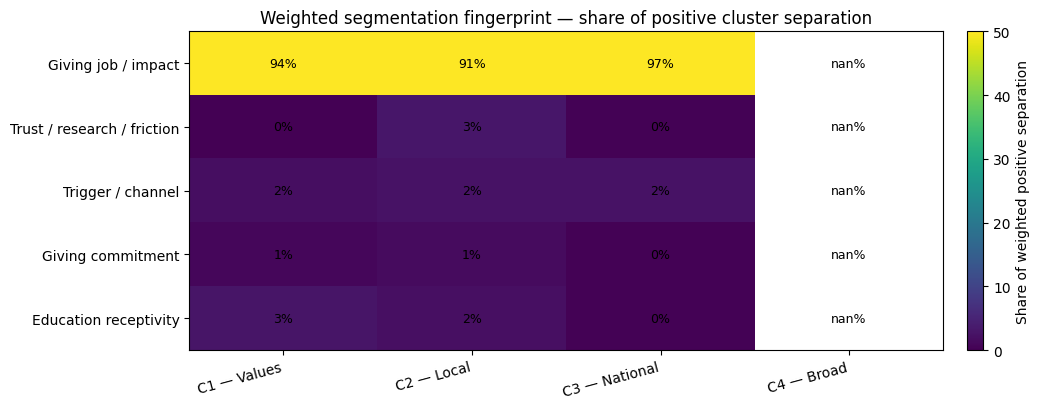

,Top weighted separation units
C1 — Values,Impact scale 92%; Education openness 3%; Giving motivations 2%
C2 — Local,Impact scale 89%; Education openness 2%; Giving motivations 2%
C3 — National,Impact scale 96%; Giving motivations 1%; Social research channels 1%
C4 — Broad,Giving motivations 0%; Trigger messages 0%; Education openness 0%


In [20]:
_show_table(
    _profile_summary_display,
    'PERSONA DECISION PROFILE',
    'Working shorthand only. ▲/▼ = uniquely high/low with a material difference from the prospect base. DC donor fit is a held-out overlay, not a clustering input.',
)

_show_table(
    _giving_detail,
    'GIVING BEHAVIOR — ROBUST / TRANSLATED',
    'Estimated typical gift is an interval-censored fitted median. Donations and organizations per year are median (25th–75th percentile), avoiding raw-mean outlier distortion. Indices use 100 = prospect average.',
)

# Weighted block fingerprint.
fig, ax = plt.subplots(figsize=(10.5, 4.2))
plot_data = (_block_fingerprint * 100).T
im = ax.imshow(plot_data.to_numpy(), aspect='auto', vmin=0, vmax=max(50, float(plot_data.to_numpy().max())))
ax.set_xticks(range(len(_CLUSTER_ORDER)), [_cluster_label(c) for c in _CLUSTER_ORDER], rotation=15, ha='right')
ax.set_yticks(range(len(plot_data.index)), [PROFILE_BLOCK_LABELS.get(b, b) for b in plot_data.index])
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        ax.text(j, i, f'{plot_data.iloc[i, j]:.0f}%', ha='center', va='center', fontsize=9)
ax.set_title('Weighted segmentation fingerprint — share of positive cluster separation')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label='Share of weighted positive separation')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'persona_weighted_segmentation_fingerprint.png', dpi=170, bbox_inches='tight')
plt.show()

_top_unit_display = pd.DataFrame({
    'Top weighted separation units': [_top_units[c] for c in _CLUSTER_ORDER]
}, index=[_cluster_label(c) for c in _CLUSTER_ORDER])
_show_table(
    _top_unit_display,
    'TOP MODEL-SPACE SEPARATORS',
    'Percentages are each unit’s share of the cluster’s positive weighted separation. This is a geometry diagnostic, not a causal importance claim.',
)

## 3.2 Jobs — motivational mix

Top-two job slots show relative motivational emphasis within each persona; family tilt is indexed to the prospect base.


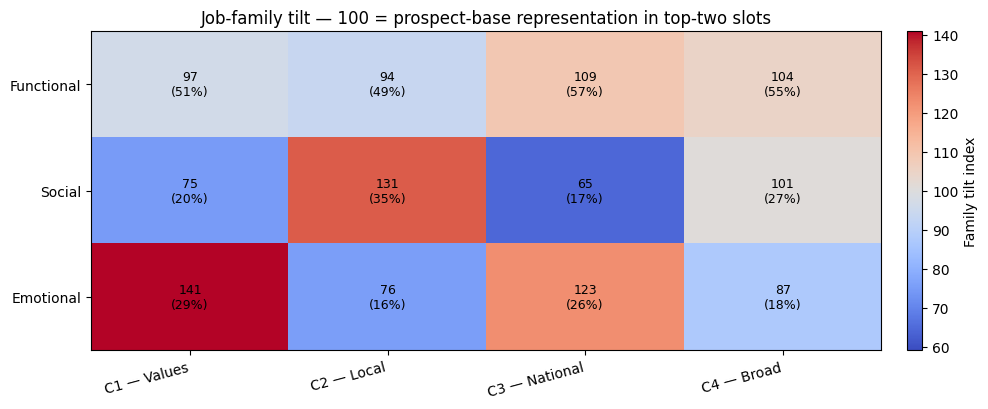

,family_tilt_100_base,standout_job_1,standout_job_2
cluster,,,
C1 — Values,Emotional 141; Functional 97; Social 75,Values obligation 18% (+8% vs base),Confidence and risk reduction 21% (+7% vs base)
C2 — Local,Social 131; Functional 94; Emotional 76,Local stewardship 34% (+20% vs base),Relational support 16% (+3% vs base)
C3 — National,Emotional 123; Functional 109; Social 65,Concrete impact 21% (+10% vs base),Confidence and risk reduction 23% (+8% vs base)
C4 — Broad,Functional 104; Social 101; Emotional 87,Acknowledged contribution 16% (+4% vs base),Sustained giving 17% (+4% vs base)


In [21]:
# Family tilt corrects for unequal numbers of jobs in each family. 100 = prospect-base share of top-two slots.
heat = _job_family_index.T.copy()
fig, ax = plt.subplots(figsize=(10, 4.2))
max_dev = max(20.0, float(np.nanmax(np.abs(heat.to_numpy() - 100))))
norm3 = TwoSlopeNorm(vmin=100 - max_dev, vcenter=100, vmax=100 + max_dev)
im = ax.imshow(heat.to_numpy(), aspect='auto', cmap='coolwarm', norm=norm3)
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=15, ha='right')
ax.set_yticks(range(heat.shape[0]), heat.index)
for i, family in enumerate(heat.index):
    for j, cluster_name in enumerate(heat.columns):
        idx = heat.iloc[i, j]
        share = _job_family_mix.loc[cluster_name, family]
        ax.text(j, i, f'{idx:.0f}\n({share:.0%})', ha='center', va='center', fontsize=9)
ax.set_title('Job-family tilt — 100 = prospect-base representation in top-two slots')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label='Family tilt index')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'persona_job_family_mix.png', dpi=170, bbox_inches='tight')
plt.show()

_show_table(
    _job_standouts,
    'JOB STANDOUTS',
    'Family tilt is indexed to 100 = prospect base, correcting for unequal family size. The two job callouts use top-two-share difference versus the prospect base.',
)

## 3.3 Affinities + activation

Descriptive signals that may change the offer, entry point, or creative hypothesis; they are not causal response estimates.


,standout_highs,standout_lows
cluster,,
C1 — Values,Disaster relief and humanitarian aid organizations 39% (+7% adjusted); Animal shelters and rescue organizations 41% (+5% adjusted),National giving 1% (-35% adjusted); School involvement 50% (-10% adjusted)
C2 — Local,Direct educator support 43% (+7% adjusted); Food banks and hunger relief programs 52% (+6% adjusted),National giving 3% (-33% adjusted); Health and medical research organizations 26% (-7% adjusted)
C3 — National,National giving 95% (+59% adjusted); Health and medical research organizations 42% (+12% adjusted); Veterans and military support groups 34% (+9% adjusted),Education support 38% (-19% adjusted); Food banks and hunger relief programs 30% (-13% adjusted)
C4 — Broad,National giving 67% (+31% adjusted); Education support 70% (+13% adjusted); School involvement 68% (+8% adjusted),Political initiatives 9% (-5% adjusted)


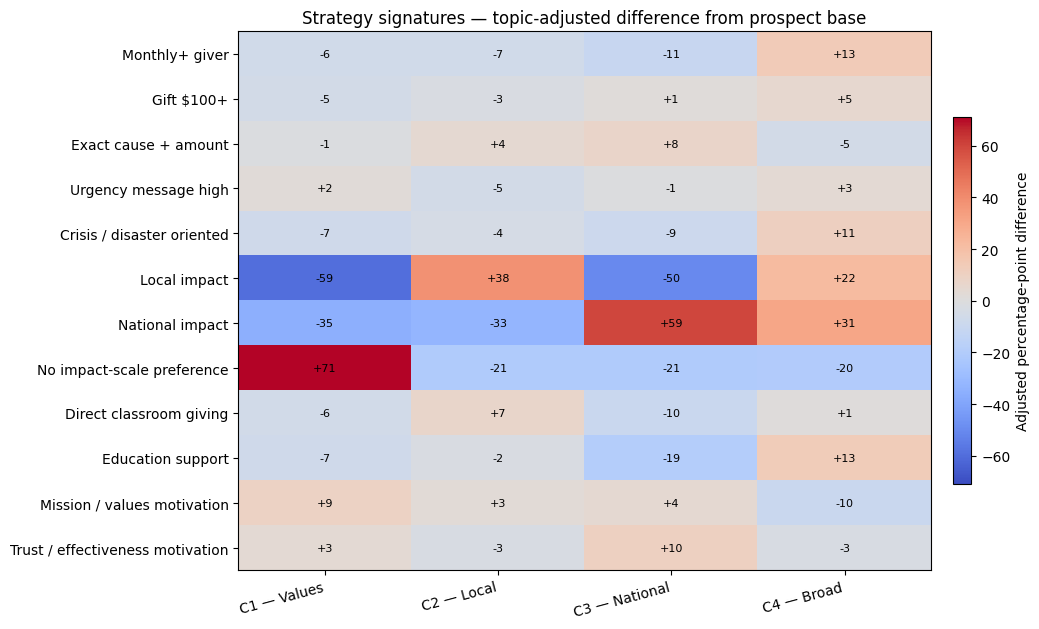

**Reading rule:** positive means the signal is unusually strong for that persona after any applicable battery-level correction; negative means unusually weak. These are profile differences, not causal response estimates.

In [22]:
_show_table(
    _affinity_standouts,
    'AFFINITY STANDOUTS',
    'Only adjusted differences of at least ±5 percentage points are shown. Current-cause, school, and prosocial detail is corrected for broad within-battery selection tendency.',
)

# Curated strategy signatures; values are adjusted percentage-point differences from prospect base.
heat = (_signature_wide * 100).copy()
max_abs = max(8.0, float(np.nanmax(np.abs(heat.to_numpy()))))
fig, ax = plt.subplots(figsize=(10.5, 6.4))
norm2 = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
im = ax.imshow(heat.to_numpy(), aspect='auto', cmap='coolwarm', norm=norm2)
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=15, ha='right')
ax.set_yticks(range(heat.shape[0]), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        ax.text(j, i, f'{value:+.0f}', ha='center', va='center', fontsize=8)
ax.set_title('Strategy signatures — topic-adjusted difference from prospect base')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label='Adjusted percentage-point difference')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'persona_strategy_signature_heatmap.png', dpi=170, bbox_inches='tight')
plt.show()

display(Markdown(
    '**Reading rule:** positive means the signal is unusually strong for that persona after any applicable battery-level correction; '
    'negative means unusually weak. These are profile differences, not causal response estimates.'
))

## 3.4 Demographics, geography + held-out DonorsChoose overlay

Context only. These fields are not clustering inputs or targeting rules; prior-DC fit comes from the held-out donor overlay.


In [23]:
_show_table(
    _demo_display,
    'DEMOGRAPHIC / GEOGRAPHIC CONTEXT',
    '▲/▼ = uniquely high/low and materially different from the prospect base. Top region/setting are descriptive modes. DC donor fit uses the 125 held-out prior-donor respondents.',
)

# Compact saved artifact index for this zone.
_profile_artifacts = pd.DataFrame({
    'artifact': [
        'persona_profile_summary_numeric.csv',
        'persona_profile_summary_display.csv',
        'persona_giving_behavior_compact.csv',
        'persona_weighted_segmentation_unit_fingerprint.csv',
        'persona_weighted_segmentation_block_fingerprint.csv',
        'persona_job_top2_family_mix.csv',
        'persona_job_family_tilt_index.csv',
        'persona_job_standouts.csv',
        'persona_affinity_review_tidy.csv',
        'persona_future_cause_affinity_openness.csv',
        'persona_affinity_standouts.csv',
        'persona_strategy_signatures_tidy.csv',
        'persona_demo_geo_donor_context.csv',
        'persona_weighted_segmentation_fingerprint.png',
        'persona_job_family_mix.png',
        'persona_strategy_signature_heatmap.png',
    ],
    'use': [
        'Numeric executive summary for downstream reporting.',
        'Formatted executive summary shown above.',
        'Outlier-safe / translated giving fields.',
        'Unit-level weighted model-space separation diagnostic.',
        'Block-level weighted model-space separation diagnostic.',
        'Raw Functional / Social / Emotional mix of top-two job slots.',
        'Family tilt indexed to 100 = prospect base.',
        'Most over-represented top-two jobs by cluster.',
        'All named + detailed current affinities with topic-adjusted differences.',
        'Conditional future cause-openness affinities with valid n.',
        'Only material affinity highs/lows surfaced in the notebook.',
        'Curated activation/product signals and adjusted differences.',
        'Collapsed demographics/geography + held-out DC overlay.',
        'Rendered weighted segmentation fingerprint.',
        'Rendered top-two job-family mix.',
        'Rendered strategy signature heatmap.',
    ]
})
_profile_artifacts.to_csv(OUTPUT_DIR / 'persona_profile_zone_artifact_index.csv', index=False)
print(f'Profile zone complete: {len(_profile_artifacts)} focused artifacts written to {OUTPUT_DIR}.')

,Median age,Any kids ≤18,Female,HH income $100k+,BA+,Full-time,Retired,Region signal,Setting signal,DC donor fit,Share of donor overlay
C1 — Values,59,31%,▲ 63%,44%,56%,45%,33%,South 35% (-6%),No ≥5pp signal,▲ 1.39x,31%
C2 — Local,56,34%,54%,47%,61%,50%,31%,No ≥5pp signal,Rural area 22% (+5%),0.99x,30%
C3 — National,▲ 64,▼ 22%,▼ 41%,44%,60%,▼ 43%,▲ 45%,Northeast 13% (-7%),No ≥5pp signal,▼ 0.67x,8%
C4 — Broad,▼ 43,▲ 49%,47%,51%,61%,▲ 60%,▼ 20%,No ≥5pp signal,Urban area 33% (+7%),0.87x,30%


Profile zone complete: 16 focused artifacts written to /Users/matt.fritz/Downloads/persona_outputs_cluster_jtbd_strategy.


## 3.5 Cluster × JTBD counts

Cells show count (within-cluster share). Shading uses share rather than raw count so unequal cluster sizes do not distort the comparison.


In [24]:
# ============================================================================
# Cluster x JTBD count tables — styled display
# Cells show count (within-cluster share); color scale is driven by share,
# not raw count, so unequal cluster sizes don't distort the shading.
# ============================================================================
from IPython.display import display

assignment_frame = selected_assignments[
    [ID_COL, 'persona_cluster']
].copy()
score_table = (
    jtbd_results['score_table']
    .loc[prospect_mask_retained]
    .copy()
)
cluster_job_people = assignment_frame.merge(
    score_table,
    on=ID_COL,
    how='inner',
    validate='one_to_one',
)
assert len(cluster_job_people) == int(prospect_mask_retained.sum())
priority_scores = cluster_job_people[
    [f'priority__{job}' for job in JTBD_JOBS]
].copy()
priority_scores.columns = list(JTBD_JOBS)
priority_z = jtbd_standardize_completed_scores(priority_scores)
# Rank each respondent's jobs relative to their other job scores.
# method='first' makes the result deterministic when exact ties occur.
job_ranks = priority_z.rank(
    axis=1,
    method='first',
    ascending=False,
)
top_1 = job_ranks.eq(1)
top_2 = job_ranks.le(2)
# Existing high-holder rule: within-job threshold from Loop 2.
high_holder = pd.DataFrame(
    {
        job: priority_scores[job].ge(
            jtbd_cards['thresholds'][job]
        )
        for job in JTBD_JOBS
    },
    index=priority_scores.index,
)
job_name = {
    job: JTBD_JOB_DOMAIN_LOOKUP[job]['provisional_name']
    for job in JTBD_JOBS
}
rows = []
for cluster in sorted(
    cluster_job_people['persona_cluster'].unique()
):
    cluster_mask = cluster_job_people[
        'persona_cluster'
    ].eq(cluster)
    cluster_n = int(cluster_mask.sum())
    for job in JTBD_JOBS:
        rows.append(
            {
                'cluster': int(cluster),
                'cluster_n': cluster_n,
                'job_family': job,
                'provisional_name': job_name[job],
                'top_job_n': int(
                    top_1.loc[cluster_mask, job].sum()
                ),
                'top_job_share': float(
                    top_1.loc[cluster_mask, job].mean()
                ),
                'top_two_job_n': int(
                    top_2.loc[cluster_mask, job].sum()
                ),
                'top_two_job_share': float(
                    top_2.loc[cluster_mask, job].mean()
                ),
                'high_holder_n': int(
                    high_holder.loc[cluster_mask, job].sum()
                ),
                'high_holder_share': float(
                    high_holder.loc[cluster_mask, job].mean()
                ),
            }
        )
cluster_job_counts = pd.DataFrame(rows)
cluster_job_counts.to_csv(
    OUTPUT_DIR / 'cluster_job_counts_tidy.csv',
    index=False,
)

COL_ORDER = (
    cluster_job_counts
    .drop_duplicates('job_family')
    .set_index('job_family')
    .reindex(list(JTBD_JOBS))['provisional_name']
    .tolist()
)

CLUSTER_N = (
    cluster_job_counts
    .groupby('cluster')['cluster_n']
    .first()
)


def _pivot_pair(count_col, share_col):
    counts = (
        cluster_job_counts
        .pivot(
            index='cluster',
            columns='provisional_name',
            values=count_col,
        )
        .reindex(columns=COL_ORDER)
        .fillna(0)
        .astype(int)
    )
    shares = (
        cluster_job_counts
        .pivot(
            index='cluster',
            columns='provisional_name',
            values=share_col,
        )
        .reindex(
            index=counts.index,
            columns=counts.columns,
        )
        .astype(float)
    )
    return counts, shares


def _cell_css(share, vmax, rgb=(31, 78, 121)):
    """White-to-base-color ramp with a text-contrast flip."""
    if pd.isna(share) or vmax <= 0:
        return ''
    t = min(max(share / vmax, 0.0), 1.0) ** 0.85
    r, g, b = (
        int(round(255 + (c - 255) * t)) for c in rgb
    )
    fg = '#ffffff' if t > 0.62 else '#1a1a1a'
    return (
        f'background-color: rgb({r},{g},{b}); '
        f'color: {fg};'
    )


BLANK_CELL_CSS = 'background-color: #ffffff; color: #999;'


def _highlight_mask(shares, top_n, axis='row'):
    """True where a cell should keep its color; False -> blanked white.

    axis='row'   -> top_n jobs within each cluster
    axis='table' -> top_n cells across the whole table
    Ties break by column order (method='first'), matching job_ranks.
    """
    if top_n is None or top_n >= shares.shape[1]:
        return pd.DataFrame(
            True, index=shares.index, columns=shares.columns
        )
    if axis == 'row':
        ranks = shares.rank(
            axis=1, method='first', ascending=False
        )
    elif axis == 'table':
        ranks = (
            shares.stack()
            .rank(method='first', ascending=False)
            .unstack()
            .reindex(
                index=shares.index, columns=shares.columns
            )
        )
    else:
        raise ValueError(
            f"axis must be 'row' or 'table', got {axis!r}"
        )
    return ranks.le(top_n)

    
def show_count_table(
    counts,
    shares,
    title,
    subtitle='',
    show_share=True,
    vmax=None,
    rgb=(31, 78, 121),
    highlight_top_n=4,
    highlight_axis='row',
    clusters_as_columns=True,
):
    if vmax is None:
        vmax = float(shares.max().max())
    if show_share:
        text = pd.DataFrame(
            {
                col: [
                    f'{int(n)} ({s:.0%})'
                    for n, s in zip(counts[col], shares[col])
                ]
                for col in counts.columns
            },
            index=counts.index,
            columns=counts.columns,
        )
    else:
        text = counts.astype(str)
    text.insert(
        0,
        'cluster n',
        CLUSTER_N.reindex(text.index).astype(int).astype(str),
    )
    keep = _highlight_mask(
        shares, highlight_top_n, highlight_axis
    )
    css = pd.DataFrame(
        '', index=text.index, columns=text.columns
    )
    for col in counts.columns:
        css[col] = [
            _cell_css(v, vmax, rgb) if k else BLANK_CELL_CSS
            for v, k in zip(shares[col], keep[col])
        ]
    if clusters_as_columns:
        text = text.T
        css = css.T
        labels = [_cluster_label(c) for c in text.columns]
        text.columns = labels
        css.columns = labels
        text.index.name = None
    styler = (
        text.style
        .apply(lambda _: css, axis=None)
        .set_caption(
            f'<span style="font-size:13px;font-weight:700">'
            f'{title}</span><br>'
            f'<span style="font-size:11px;color:#666">'
            f'{subtitle}</span>'
        )
        .set_table_styles([
            {
                'selector': 'caption',
                'props': [
                    ('caption-side', 'top'),
                    ('text-align', 'left'),
                    ('padding', '0 0 8px 0'),
                ],
            },
            {
                'selector': 'th',
                'props': [
                    ('font-size', '11px'),
                    ('font-weight', '600'),
                    ('text-align', 'center'),
                    ('vertical-align', 'bottom'),
                    ('padding', '4px 8px'),
                    ('background-color', '#f5f5f5'),
                    ('color', '#333'),
                ],
            },
            {
                'selector': 'td',
                'props': [
                    ('font-size', '11px'),
                    ('text-align', 'center'),
                    ('padding', '4px 8px'),
                    ('font-variant-numeric', 'tabular-nums'),
                ],
            },
            {
                'selector': '',
                'props': [
                    ('border-collapse', 'separate'),
                    ('border-spacing', '2px'),
                ],
            },
            {
                'selector': 'th.row_heading',
                'props': [
                    ('text-align', 'left'),
                    ('white-space', 'nowrap'),
                ],
            },
        ])
    )
    display(styler)


top_job_counts, top_job_shares = _pivot_pair(
    'top_job_n', 'top_job_share'
)
top_two_counts, top_two_shares = _pivot_pair(
    'top_two_job_n', 'top_two_job_share'
)
high_holder_counts, high_holder_shares = _pivot_pair(
    'high_holder_n', 'high_holder_share'
)

top_job_counts.to_csv(
    OUTPUT_DIR / 'cluster_job_top1_counts.csv'
)
top_two_counts.to_csv(
    OUTPUT_DIR / 'cluster_job_top2_counts.csv'
)
high_holder_counts.to_csv(
    OUTPUT_DIR / 'cluster_job_high_holder_counts.csv'
)

show_count_table(
    top_job_counts,
    top_job_shares,
    'TOP JOB COUNTS',
    'Mutually exclusive — row counts sum to cluster n. '
    'Shade = share of cluster ranking this job first.',
    rgb=(31, 78, 121),
)
show_count_table(
    top_two_counts,
    top_two_shares,
    'TOP-TWO JOB COUNTS',
    'Overlapping — row counts sum to 2 x cluster n. '
    'Shade = share of cluster with this job in their top two.',
    rgb=(24, 98, 74),
)
show_count_table(
    high_holder_counts,
    high_holder_shares,
    'HIGH-HOLDER (TOP QUARTILE) COUNTS',
    'Overlapping — row totals have no fixed sum. '
    'Shade = share of cluster above the Loop-2 within-job threshold.',
    rgb=(140, 62, 24),
)

PRINT_PLAIN_TABLES = False
if PRINT_PLAIN_TABLES:
    print('TOP JOB COUNTS')
    print(top_job_counts.to_string())
    print('\nTOP-TWO JOB COUNTS')
    print(top_two_counts.to_string())
    print('\nHIGH-HOLDER COUNTS')
    print(high_holder_counts.to_string())



,C1 — Values,C2 — Local,C3 — National,C4 — Broad
cluster n,252,343,133,392
Concrete impact,15 (6%),16 (5%),16 (12%),13 (3%)
Directed choice,16 (6%),29 (8%),8 (6%),24 (6%)
Giving leverage,22 (9%),21 (6%),13 (10%),36 (9%)
Tax efficiency,15 (6%),27 (8%),5 (4%),31 (8%)
Sustained giving,13 (5%),19 (6%),4 (3%),27 (7%)
Confidence and risk reduction,25 (10%),10 (3%),14 (11%),18 (5%)
Impact witness,12 (5%),23 (7%),11 (8%),34 (9%)
Active participation,10 (4%),29 (8%),8 (6%),33 (8%)
Relational support,16 (6%),27 (8%),5 (4%),20 (5%)


,C1 — Values,C2 — Local,C3 — National,C4 — Broad
cluster n,252,343,133,392
Concrete impact,32 (13%),37 (11%),28 (21%),26 (7%)
Directed choice,31 (12%),52 (15%),11 (8%),53 (14%)
Giving leverage,36 (14%),38 (11%),24 (18%),61 (16%)
Tax efficiency,31 (12%),43 (13%),20 (15%),54 (14%)
Sustained giving,31 (12%),37 (11%),11 (8%),67 (17%)
Confidence and risk reduction,54 (21%),35 (10%),30 (23%),43 (11%)
Impact witness,22 (9%),39 (11%),13 (10%),58 (15%)
Active participation,18 (7%),56 (16%),15 (11%),67 (17%)
Relational support,35 (14%),55 (16%),13 (10%),48 (12%)


,C1 — Values,C2 — Local,C3 — National,C4 — Broad
cluster n,252,343,133,392
Concrete impact,78 (31%),82 (24%),46 (35%),75 (19%)
Directed choice,66 (26%),107 (31%),28 (21%),100 (26%)
Giving leverage,51 (20%),78 (23%),33 (25%),118 (30%)
Tax efficiency,51 (20%),85 (25%),35 (26%),109 (28%)
Sustained giving,56 (22%),73 (21%),22 (17%),129 (33%)
Confidence and risk reduction,83 (33%),82 (24%),41 (31%),74 (19%)
Impact witness,46 (18%),80 (23%),30 (23%),124 (32%)
Active participation,38 (15%),93 (27%),24 (18%),125 (32%)
Relational support,66 (26%),100 (29%),18 (14%),96 (24%)


## 3.6 Detailed affinity + profile review

Exhaustive supporting tables behind the compact affinity and context readouts above; descriptive only.


In [25]:
# ============================================================================
# Affinity + profile review tables
# Display-only assembly: no upstream clustering/profile engine changes are made here.
# ============================================================================

# Rejoin prospect rows by respondent id; all affinity/profile construction below remains post-fit.
_affinity_people = (
    selected_assignments.loc[prospect_fit_mask, [ID_COL, 'persona_cluster']]
    .merge(
        retained_model.loc[prospect_fit_mask].copy(),
        on=ID_COL,
        how='inner',
        validate='one_to_one',
    )
)
assert len(_affinity_people) == int(prospect_fit_mask.sum())
_cluster_order = sorted(_affinity_people['persona_cluster'].unique())
assert _cluster_order == list(CLUSTER_LABELS)


def _display_cluster_columns(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.rename(columns={c: cluster_label(c) for c in _cluster_order if c in frame.columns})


def _binary_signal(question, item):
    return selected(_affinity_people, question, item).astype(float)


def _likert01(question, item, mapping):
    return jtbd_fixed_scale(_affinity_people[likert_col(item, question)], mapping)


def _simple_styler(frame, caption, subtitle='', percent=False, decimals=2):
    shown = _display_cluster_columns(frame.copy())
    if percent:
        formatter = lambda x: '' if pd.isna(x) else f'{x:.0%}'
    else:
        formatter = lambda x: '' if pd.isna(x) else f'{x:.{decimals}f}'
    styler = (
        shown.style
        .format(formatter)
        .set_caption(
            f'<span style="font-size:13px;font-weight:700">{caption}</span><br>'
            f'<span style="font-size:11px;color:#666">{subtitle}</span>'
        )
        .set_table_styles([
            {'selector': 'caption', 'props': [('caption-side','top'), ('text-align','left'), ('padding','0 0 8px 0')]},
            {'selector': 'th', 'props': [('font-size','11px'), ('font-weight','600'), ('text-align','center'), ('padding','4px 8px'), ('background-color','#f5f5f5')]},
            {'selector': 'td', 'props': [('font-size','11px'), ('text-align','center'), ('padding','4px 8px'), ('font-variant-numeric','tabular-nums')]},
            {'selector': 'th.row_heading', 'props': [('text-align','left'), ('white-space','normal'), ('max-width','420px')]},
        ])
    )
    display(styler)


def _text_styler(frame, caption, subtitle=''):
    shown = _display_cluster_columns(frame.copy())
    display(
        shown.style
        .set_caption(
            f'<span style="font-size:13px;font-weight:700">{caption}</span><br>'
            f'<span style="font-size:11px;color:#666">{subtitle}</span>'
        )
        .set_table_styles([
            {'selector': 'caption', 'props': [('caption-side','top'), ('text-align','left'), ('padding','0 0 8px 0')]},
            {'selector': 'th', 'props': [('font-size','11px'), ('font-weight','600'), ('text-align','center'), ('padding','4px 8px'), ('background-color','#f5f5f5')]},
            {'selector': 'td', 'props': [('font-size','11px'), ('text-align','center'), ('padding','4px 8px'), ('font-variant-numeric','tabular-nums')]},
            {'selector': 'th.row_heading', 'props': [('text-align','left'), ('white-space','normal'), ('max-width','420px')]},
        ])
    )


def _share_by_cluster(values: pd.Series) -> pd.Series:
    temp = pd.DataFrame({
        'cluster': _affinity_people['persona_cluster'].to_numpy(),
        'value': pd.to_numeric(values, errors='coerce'),
    })
    out = temp.groupby('cluster')['value'].mean().reindex(_cluster_order)
    out.loc['Overall'] = temp['value'].mean()
    return out


def _median_iqr_text(values: pd.Series, digits=0) -> pd.Series:
    temp = pd.DataFrame({
        'cluster': _affinity_people['persona_cluster'].to_numpy(),
        'value': pd.to_numeric(values, errors='coerce'),
    })
    def fmt(series):
        series = series.dropna()
        if not len(series):
            return ''
        q1, med, q3 = series.quantile([0.25, 0.50, 0.75]).tolist()
        return f'{med:.{digits}f} ({q1:.{digits}f}–{q3:.{digits}f})'
    out = temp.groupby('cluster')['value'].apply(fmt).reindex(_cluster_order)
    out.loc['Overall'] = fmt(temp['value'])
    return out


def _median_category_text(values: pd.Series, mapping: Mapping[str, float]) -> pd.Series:
    inverse = {float(v): k for k, v in mapping.items()}
    temp = pd.DataFrame({
        'cluster': _affinity_people['persona_cluster'].to_numpy(),
        'code': values.map(mapping),
    })
    def fmt(series):
        series = pd.to_numeric(series, errors='coerce').dropna()
        if not len(series):
            return ''
        med = float(series.quantile(0.50, interpolation='higher'))
        return inverse.get(med, str(med))
    out = temp.groupby('cluster')['code'].apply(fmt).reindex(_cluster_order)
    out.loc['Overall'] = fmt(temp['code'])
    return out


# ---------------------------------------------------------------------------
# Affinity summary — all named affinities plus analyst-added prosocial behavior.
# ---------------------------------------------------------------------------
_school_options = [
    option for option in question_options(Q_SCHOOL_INVOLVEMENT)
    if option not in {'Other', "I do not have children/am not involved in my child(ren)'s school"}
]
_school_any = pd.concat(
    [_binary_signal(Q_SCHOOL_INVOLVEMENT, option) for option in _school_options],
    axis=1,
).max(axis=1)

_education_current = _binary_signal(Q_CURRENT_CAUSES, 'Educational-focused groups')
_education_open = _likert01(Q_OPENNESS, 'Educational-focused groups', OPEN_MAP)
_education_affinity = _education_open.where(_education_current.ne(1), 1.0)

_children_current = _binary_signal(Q_CURRENT_CAUSES, "Children's charities and youth programs")
_children_open = _likert01(Q_OPENNESS, "Children's charities and youth programs", OPEN_MAP)
_children_affinity = _children_open.where(_children_current.ne(1), 1.0)

# Prosocial affinity is intentionally behavioral rather than a JTBD job.
# Q2.5 is one question-level core signal (breadth across six observed actions),
# question-balanced with the independent Q9.8 volunteering behavior.
_prosocial_q25 = pd.DataFrame({
    option: _binary_signal(Q_PRIOR_ACTIONS, option)
    for option in prosocial_action_options
})
_prosocial_q25_breadth = _prosocial_q25.mean(axis=1)
_prosocial_q25_any = _prosocial_q25.max(axis=1)
_prosocial_volunteer_activity = _binary_signal(Q_ACTIVITIES, 'Volunteering for charitable or civic causes')
_prosocial_affinity = pd.concat(
    [_prosocial_q25_breadth, _prosocial_volunteer_activity],
    axis=1,
).mean(axis=1, skipna=True)

_affinity_values = pd.DataFrame({
    'cause_support': pd.concat([
        _likert01(Q_IMPORTANCE, 'Personal connection to the organization/cause', IMPORTANT_MAP),
        _binary_signal(Q_MOTIVATIONS, 'Personal connection to the cause or issue'),
    ], axis=1).mean(axis=1, skipna=True),
    'honor_remembrance': _binary_signal(Q_MOTIVATIONS, "Desire to honor someone's memory or legacy"),
    'personal_fulfillment': _likert01(Q_CHARITY_ATTITUDES, 'I feel a sense of personal satisfaction when I make a charitable donation', AGREE_MAP),
    'direct_educator_support': _binary_signal(Q_EDU_FORMATS, "Direct donation to specific teachers' classrooms"),
    'education_support': _education_affinity,
    'children_youth_support': _children_affinity,
    'national_giving': _binary_signal(Q_IMPACT_SCALE, 'My country'),
    'school_involvement': _school_any,
    'prosocial_participation': _prosocial_affinity,
})
_affinity_values['cluster'] = _affinity_people['persona_cluster'].to_numpy()

_affinity_summary = _affinity_values.groupby('cluster').mean(numeric_only=True).T
_affinity_summary['Overall'] = _affinity_values.drop(columns='cluster').mean(numeric_only=True)
_affinity_summary.index = [JTBD_AFFINITIES[key] for key in _affinity_summary.index]
_affinity_summary.to_csv(OUTPUT_DIR / 'cluster_affinity_summary.csv')
_simple_styler(
    _affinity_summary,
    'AFFINITY SUMMARY',
    'All named affinities. Binary rows are shares; composite rows are normalized 0–1 intensities. Cause affinities are shown separately below because each cause remains its own affinity.',
    percent=True,
)

# Cause affinities: current giving and future openness remain separate.
_cause_options = [option for option in question_options(Q_CURRENT_CAUSES) if option not in {'Other'}]
_cause_current = pd.DataFrame({
    option: _binary_signal(Q_CURRENT_CAUSES, option)
    for option in _cause_options
})
_cause_current['cluster'] = _affinity_people['persona_cluster'].to_numpy()
_cause_current_wide = _cause_current.groupby('cluster').mean().T
_cause_current_wide['Overall'] = _cause_current.drop(columns='cluster').mean()
_cause_current_wide.to_csv(OUTPUT_DIR / 'cluster_cause_affinity_current.csv')
_simple_styler(
    _cause_current_wide,
    'CAUSE AFFINITIES — CURRENT GIVING',
    'Each Q4.3 cause/organization category is a separate current-giving affinity.',
    percent=True,
)

_cause_open_rows = {}
_cause_open_n_rows = {}
for option in _cause_options:
    try:
        values = pd.to_numeric(_affinity_people[likert_col(option, Q_OPENNESS)].map(OPEN_MAP), errors='coerce')
    except KeyError:
        continue
    temp = pd.DataFrame({'cluster': _affinity_people['persona_cluster'].to_numpy(), 'value': values})
    means = temp.groupby('cluster')['value'].mean().reindex(_cluster_order)
    counts = temp.groupby('cluster')['value'].count().reindex(_cluster_order)
    mean_row = means.to_dict(); mean_row['Overall'] = float(values.mean())
    count_row = counts.to_dict(); count_row['Overall'] = int(values.notna().sum())
    _cause_open_rows[option] = mean_row
    _cause_open_n_rows[option] = count_row
_cause_open_wide = pd.DataFrame.from_dict(_cause_open_rows, orient='index').reindex(columns=[*_cluster_order, 'Overall'])
_cause_open_n_wide = pd.DataFrame.from_dict(_cause_open_n_rows, orient='index').reindex(columns=[*_cluster_order, 'Overall'])
_cause_open_wide.to_csv(OUTPUT_DIR / 'cluster_cause_affinity_openness.csv')
_cause_open_n_wide.to_csv(OUTPUT_DIR / 'cluster_cause_affinity_openness_valid_n.csv')
_cause_open_display = pd.DataFrame(index=_cause_open_wide.index, columns=_cause_open_wide.columns, dtype=object)
for col in _cause_open_wide.columns:
    _cause_open_display[col] = [
        '' if pd.isna(v) else f'{v:.2f} (n={int(n)})'
        for v, n in zip(_cause_open_wide[col], _cause_open_n_wide[col])
    ]
_text_styler(
    _cause_open_display,
    'CAUSE AFFINITIES — FUTURE OPENNESS',
    'Mean Q4.5 openness on the original 1–5 scale among respondents asked about that cause; valid n is shown in every cell.',
)

# School-involvement affinity detail, including explicit no-children/not-involved response.
_school_detail_options = [option for option in question_options(Q_SCHOOL_INVOLVEMENT) if option != 'Other']
_school_detail = pd.DataFrame({
    option: _binary_signal(Q_SCHOOL_INVOLVEMENT, option)
    for option in _school_detail_options
})
_school_detail['cluster'] = _affinity_people['persona_cluster'].to_numpy()
_school_detail_wide = _school_detail.groupby('cluster').mean().T
_school_detail_wide['Overall'] = _school_detail.drop(columns='cluster').mean()
_school_detail_wide.to_csv(OUTPUT_DIR / 'cluster_school_involvement_affinity.csv')
_simple_styler(
    _school_detail_wide,
    'SCHOOL INVOLVEMENT AFFINITY — DETAIL',
    'Within-cluster share selecting each Q9.9 response, including the explicit no-children/not-involved response.',
    percent=True,
)

# Prosocial affinity detail.
_prosocial_detail = _prosocial_q25.copy()
_prosocial_detail['Any Q2.5 prosocial action'] = _prosocial_q25_any
_prosocial_detail['Q9.8 volunteering for charitable/civic causes'] = _prosocial_volunteer_activity
_prosocial_detail['cluster'] = _affinity_people['persona_cluster'].to_numpy()
_prosocial_detail_wide = _prosocial_detail.groupby('cluster').mean().T
_prosocial_detail_wide['Overall'] = _prosocial_detail.drop(columns='cluster').mean()
_prosocial_detail_wide.to_csv(OUTPUT_DIR / 'cluster_prosocial_affinity_detail.csv')
_simple_styler(
    _prosocial_detail_wide,
    'PROSOCIAL PARTICIPATION AFFINITY — DETAIL',
    'Observed behavior only. Q2.5 charitable-donation screening response is intentionally excluded; Q9.8 volunteering provides an independent behavioral signal.',
    percent=True,
)

# ---------------------------------------------------------------------------
# Headline collapsed profile: interpretable single attributes instead of forcing
# the analyst to read every one-hot bin. Full bin-level profiles still follow.
# ---------------------------------------------------------------------------
_age = pd.to_numeric(_affinity_people[AGE_COL], errors='coerce')
_orgs = pd.to_numeric(_affinity_people[ORG_COUNT_COL], errors='coerce')
_donations = pd.to_numeric(_affinity_people[DONATION_COUNT_COL], errors='coerce')
_amount_code = _affinity_people[AMOUNT_COL].map(AMOUNT_MAP)
_frequency_code = _affinity_people[FREQUENCY_COL].map(FREQUENCY_MAP)
_any_children = (
    _binary_signal(CHILDREN_QUESTION, 'Children 12 years old or younger').eq(1)
    | _binary_signal(CHILDREN_QUESTION, 'Children between 13-18 years old').eq(1)
).astype(float)
_no_children = _binary_signal(CHILDREN_QUESTION, 'No children live with me')
_income_100k_plus = _affinity_people[INCOME_COL].isin([
    '$100,000 to $124,999', '$125,000 to $149,999', '$150,000 to $174,999',
    '$175,000 to $199,999', '$200,000+',
]).astype(float)
_monthly_plus = _frequency_code.ge(FREQUENCY_MAP['Once a month']).astype(float)
_gift_100_plus = _amount_code.ge(AMOUNT_MAP['$100 - $499']).astype(float)
_urgency_message_high = _affinity_people[
    likert_col('Messages that emphasize the urgency of the situation or need', Q_MESSAGING)
].isin({'Very influential', 'Extremely influential'}).astype(float)
_crisis_oriented = _affinity_people[
    likert_col('I am more likely to donate during times of crisis or disaster', Q_CHARITY_ATTITUDES)
].isin({'Somewhat agree', 'Strongly agree'}).astype(float)
_direct_teacher = _binary_signal(Q_EDU_FORMATS, "Direct donation to specific teachers' classrooms")
_current_edu = _binary_signal(Q_CURRENT_CAUSES, 'Educational-focused groups')

_headline = pd.DataFrame(index=[
    'Age — median (IQR)',
    'Typical gift size — median band',
    'Typical giving frequency — median band',
    'Typical gift $100+',
    'Gives monthly or more often',
    'Organizations supported/year — median (IQR)',
    'Donations/year — median (IQR)',
    'Any children age 18 or younger at home',
    'No children at home',
    'Household income $100k+',
    'Any Q2.5 prosocial action',
    'Urgency message very/extremely influential',
    'Crisis/disaster oriented',
    'Currently gives to education',
    'Prefers direct teacher/classroom giving',
    'Prior DC donors among all assigned respondents',
    'Share of all held-out prior DC donors',
    'Prior DC donor natural-fit index',
], columns=[*_cluster_order, 'Overall'], dtype=object)

_headline.loc['Age — median (IQR)'] = _median_iqr_text(_age, digits=0)
_headline.loc['Typical gift size — median band'] = _median_category_text(_affinity_people[AMOUNT_COL], AMOUNT_MAP)
_headline.loc['Typical giving frequency — median band'] = _median_category_text(_affinity_people[FREQUENCY_COL], FREQUENCY_MAP)
_headline.loc['Typical gift $100+'] = _share_by_cluster(_gift_100_plus).map(lambda x: f'{x:.0%}')
_headline.loc['Gives monthly or more often'] = _share_by_cluster(_monthly_plus).map(lambda x: f'{x:.0%}')
_headline.loc['Organizations supported/year — median (IQR)'] = _median_iqr_text(_orgs, digits=0)
_headline.loc['Donations/year — median (IQR)'] = _median_iqr_text(_donations, digits=0)
_headline.loc['Any children age 18 or younger at home'] = _share_by_cluster(_any_children).map(lambda x: f'{x:.0%}')
_headline.loc['No children at home'] = _share_by_cluster(_no_children).map(lambda x: f'{x:.0%}')
_headline.loc['Household income $100k+'] = _share_by_cluster(_income_100k_plus).map(lambda x: f'{x:.0%}')
_headline.loc['Any Q2.5 prosocial action'] = _share_by_cluster(_prosocial_q25_any).map(lambda x: f'{x:.0%}')
_headline.loc['Urgency message very/extremely influential'] = _share_by_cluster(_urgency_message_high).map(lambda x: f'{x:.0%}')
_headline.loc['Crisis/disaster oriented'] = _share_by_cluster(_crisis_oriented).map(lambda x: f'{x:.0%}')
_headline.loc['Currently gives to education'] = _share_by_cluster(_current_edu).map(lambda x: f'{x:.0%}')
_headline.loc['Prefers direct teacher/classroom giving'] = _share_by_cluster(_direct_teacher).map(lambda x: f'{x:.0%}')

_summary = selected_cluster_summary.copy()
if 'persona_cluster' in _summary.columns:
    _summary = _summary.set_index('persona_cluster')
_summary = _summary.reindex(_cluster_order)
for cluster in _cluster_order:
    _headline.loc['Prior DC donors among all assigned respondents', cluster] = f"{_summary.loc[cluster, 'past_donor_share_of_persona']:.1%}"
    _headline.loc['Share of all held-out prior DC donors', cluster] = f"{_summary.loc[cluster, 'past_donor_share']:.1%}"
    _headline.loc['Prior DC donor natural-fit index', cluster] = f"{_summary.loc[cluster, 'natural_fit_index']:.2f}x"
_total_past = float(_summary['past_donor_n'].sum())
_total_prospect = float(_summary['prospect_n'].sum())
_headline.loc['Prior DC donors among all assigned respondents', 'Overall'] = f'{_total_past / (_total_past + _total_prospect):.1%}'
_headline.loc['Share of all held-out prior DC donors', 'Overall'] = '100%'
_headline.loc['Prior DC donor natural-fit index', 'Overall'] = '1.00x'
_headline.to_csv(OUTPUT_DIR / 'cluster_headline_profile_collapsed.csv')
_text_styler(
    _headline,
    'HEADLINE PROFILE — COLLAPSED ATTRIBUTES',
    'Single interpretable rollups for binned or noisy fields. Raw numeric counts use median (IQR), not means. DC donor measures use the held-out prior-donor overlay.',
)

# ---------------------------------------------------------------------------
# Robust numeric profiling across every numeric profile field.
# No winsorized pseudo-means: display median, IQR, and valid n directly.
# ---------------------------------------------------------------------------
_numeric_features = PROFILE_METADATA.index[PROFILE_METADATA['kind'].eq('numeric')].tolist()
_numeric_profile = PROFILE_VALUES.loc[prospect_fit_mask, _numeric_features].copy()
_numeric_profile['cluster'] = selected_assignments.loc[prospect_fit_mask, 'persona_cluster'].to_numpy()
_numeric_rows = []
for feature in _numeric_features:
    label = PROFILE_METADATA.loc[feature, 'label']
    group = PROFILE_METADATA.loc[feature, 'group']
    for cluster in _cluster_order:
        vals = pd.to_numeric(
            _numeric_profile.loc[_numeric_profile['cluster'].eq(cluster), feature],
            errors='coerce',
        ).dropna()
        numeric_row = {
            'feature': feature, 'label': label, 'group': group, 'cluster': cluster,
            'valid_n': int(len(vals)),
            'q25': float(vals.quantile(.25)) if len(vals) else np.nan,
            'median': float(vals.quantile(.50)) if len(vals) else np.nan,
            'q75': float(vals.quantile(.75)) if len(vals) else np.nan,
        }
        _numeric_rows.append(numeric_row)
    vals = pd.to_numeric(_numeric_profile[feature], errors='coerce').dropna()
    _numeric_rows.append({
        'feature': feature, 'label': label, 'group': group, 'cluster': 'Overall',
        'valid_n': int(len(vals)),
        'q25': float(vals.quantile(.25)) if len(vals) else np.nan,
        'median': float(vals.quantile(.50)) if len(vals) else np.nan,
        'q75': float(vals.quantile(.75)) if len(vals) else np.nan,
    })
_robust_numeric_tidy = pd.DataFrame(_numeric_rows)
_robust_numeric_tidy.to_csv(OUTPUT_DIR / 'cluster_profile_robust_numeric_tidy.csv', index=False)

# Every binary profile feature produced upstream, grouped for review. Numeric means are deliberately suppressed here.
_profile_export = selected_profile.copy()
_profile_export.to_csv(OUTPUT_DIR / 'cluster_full_profile_display_tidy.csv', index=False)
_profile_group_order = list(dict.fromkeys(_profile_export['group'].tolist()))
for _group in _profile_group_order:
    _g = _profile_export.loc[_profile_export['group'].eq(_group)].copy()
    _binary = _g.loc[_g['kind'].eq('binary')].copy()
    if len(_binary):
        _meta = _binary[['feature', 'label']].drop_duplicates('feature').set_index('feature')
        _wide = _binary.pivot(index='feature', columns='cluster', values='cluster_value')
        _wide['Overall'] = _binary.drop_duplicates('feature').set_index('feature')['overall_value']
        _wide = _wide.reindex(_meta.index)
        _wide.index = _meta['label']
        _simple_styler(
            _wide,
            f'PROFILE — {_group.upper()}',
            'All existing binary/categorical profile features in this group; no ranking or filtering applied.',
            percent=True,
        )

    _num = _robust_numeric_tidy.loc[_robust_numeric_tidy['group'].eq(_group)].copy()
    if len(_num):
        _num_display = pd.DataFrame(index=_num['label'].drop_duplicates(), columns=[*_cluster_order, 'Overall'], dtype=object)
        for row in _num.itertuples(index=False):
            col = row.cluster
            _num_display.loc[row.label, col] = (
                '' if pd.isna(row.median)
                else f'{row.median:.1f} ({row.q25:.1f}–{row.q75:.1f}); n={int(row.valid_n)}'
            )
        _text_styler(
            _num_display,
            f'PROFILE — {_group.upper()} — ROBUST NUMERIC',
            'Median (25th–75th percentile); valid n. Raw means are intentionally not displayed for unbounded numeric survey fields.',
        )

# Named charities remain mention-count based in the existing upstream artifact; display all resolved entities here.
if len(charity_entity_profile):
    _charity_wide = (
        charity_entity_profile
        .pivot_table(index='canonical_entity', columns='persona_cluster', values='mention_n', aggfunc='sum', fill_value=0)
        .astype(int)
    )
    _charity_wide['Overall'] = _charity_wide.sum(axis=1)
    _charity_wide = _charity_wide.sort_values('Overall', ascending=False)
    _charity_wide.to_csv(OUTPUT_DIR / 'cluster_named_charity_mentions_wide.csv')
    display(
        _display_cluster_columns(_charity_wide).style
        .set_caption(
            '<span style="font-size:13px;font-weight:700">NAMED CHARITY MENTIONS</span><br>'
            '<span style="font-size:11px;color:#666">All resolved canonical entities; counts are mentions, not deduplicated respondent prevalence.</span>'
        )
        .set_table_styles([
            {'selector': 'caption', 'props': [('caption-side','top'), ('text-align','left'), ('padding','0 0 8px 0')]},
            {'selector': 'th', 'props': [('font-size','11px'), ('font-weight','600'), ('text-align','center'), ('padding','4px 8px'), ('background-color','#f5f5f5')]},
            {'selector': 'td', 'props': [('font-size','11px'), ('text-align','center'), ('padding','4px 8px')]},
            {'selector': 'th.row_heading', 'props': [('text-align','left'), ('white-space','normal'), ('max-width','420px')]},
        ])
    )


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
Support a cause I feel personally connected to,55%,60%,52%,59%,58%
Keep someone important to me present through my giving,28%,25%,22%,37%,29%
Feel good or personally fulfilled by helping others,78%,79%,77%,81%,79%
Prefer to give to a specific teacher or classroom,30%,43%,26%,37%,36%
Prefer to give to education-related causes,50%,54%,38%,70%,57%
Prefer to give to causes serving children and youth,75%,74%,73%,85%,78%
Prefer to give to causes at a national scale,1%,3%,95%,67%,36%
Be involved in my child(ren)'s school,50%,62%,48%,68%,60%
Take prosocial action beyond financial giving,20%,27%,18%,31%,26%


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
Health and medical research organizations,40%,26%,42%,43%,37%
Environmental and wildlife conservation groups,24%,11%,12%,32%,21%
Educational-focused groups,12%,12%,8%,25%,16%
Children's charities and youth programs,45%,39%,44%,53%,46%
Animal shelters and rescue organizations,41%,34%,29%,38%,37%
Homelessness and housing support services,35%,32%,23%,43%,35%
Disaster relief and humanitarian aid organizations,39%,24%,26%,40%,33%
Arts and cultural organizations,8%,9%,3%,15%,10%
Food banks and hunger relief programs,49%,52%,30%,57%,50%
Veterans and military support groups,27%,28%,34%,37%,32%


,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
Health and medical research organizations,2.93 (n=152),2.84 (n=255),2.91 (n=77),3.57 (n=223),3.10 (n=707)
Environmental and wildlife conservation groups,2.90 (n=191),2.87 (n=305),2.69 (n=117),3.30 (n=268),2.99 (n=881)
Educational-focused groups,2.74 (n=223),2.93 (n=302),2.28 (n=122),3.39 (n=293),2.94 (n=940)
Children's charities and youth programs,3.19 (n=138),3.30 (n=208),3.07 (n=74),3.75 (n=186),3.38 (n=606)
Animal shelters and rescue organizations,2.87 (n=149),2.91 (n=226),2.79 (n=94),3.39 (n=242),3.05 (n=711)
Homelessness and housing support services,2.95 (n=165),2.97 (n=234),2.72 (n=102),3.50 (n=224),3.09 (n=725)
Disaster relief and humanitarian aid organizations,3.31 (n=153),3.22 (n=260),3.12 (n=99),3.67 (n=235),3.37 (n=747)
Arts and cultural organizations,2.35 (n=233),2.42 (n=312),2.03 (n=129),2.90 (n=335),2.51 (n=1009)
Food banks and hunger relief programs,3.43 (n=129),3.25 (n=165),3.06 (n=93),3.82 (n=169),3.44 (n=556)
Veterans and military support groups,3.22 (n=184),3.31 (n=247),3.02 (n=88),3.50 (n=248),3.31 (n=767)


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
Attending parent-teacher conferences,39%,43%,33%,39%,39%
Volunteering in the classroom,21%,21%,14%,22%,21%
Participating in school fundraisers,28%,34%,29%,35%,32%
Serving on the school board or committees,3%,7%,7%,15%,9%
"Assisting with extracurricular activities (sports, clubs, etc.)",22%,26%,14%,33%,26%
Chaperoning field trips,25%,28%,16%,26%,25%
"Helping with school events (carnivals, fairs, etc.)",27%,34%,23%,37%,32%
Assisting in the school library or media center,3%,8%,4%,14%,8%
Participating in the Parent Teacher Association (PTA),18%,20%,18%,28%,22%
I do not have children/am not involved in my child(ren)'s school,49%,37%,51%,30%,39%


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
"Donated goods (e.g., clothing, household items, furniture, etc.) (e.g., drop box, staffed drop-off center, etc.)",79%,79%,76%,88%,82%
Volunteered for community service,20%,32%,23%,42%,32%
Donated blood,15%,24%,17%,29%,23%
Planted trees or participated in a community garden,6%,9%,5%,22%,12%
Provided meals or shelter for the unhoused,13%,14%,11%,25%,18%
Volunteered at an animal shelter,4%,10%,9%,15%,10%
Any Q2.5 prosocial action,84%,86%,82%,92%,87%
Q9.8 volunteering for charitable/civic causes,17%,25%,13%,26%,22%


...

cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
label,,,,,
"Donated goods (e.g., clothing, household items, furniture, etc.) (e.g., drop box, staffed drop-off center, etc.)",79%,79%,76%,88%,82%
Volunteered for community service,20%,32%,23%,42%,32%
Donated blood,15%,24%,17%,29%,23%
Planted trees or participated in a community garden,6%,9%,5%,22%,12%
Provided meals or shelter for the unhoused,13%,14%,11%,25%,18%
Volunteered at an animal shelter,4%,10%,9%,15%,10%


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
label,,,,,
Researches organizations thoroughly,64%,70%,62%,72%,68%
Sticks to familiar organizations,71%,77%,77%,69%,73%


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
label,,,,,
Crisis-oriented,54%,57%,52%,71%,60%


cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
label,,,,,
Specific-impact message,65%,66%,69%,71%,68%
Transparency message,65%,64%,70%,77%,69%


persona_cluster,C1 — Values,C2 — Local,C3 — National,C4 — Broad,Overall
canonical_entity,,,,,
St. Jude Children's Research Hospital,47,41,47,95,230
American Red Cross,40,45,17,68,170
Salvation Army,32,42,17,47,138
Church / religious congregation (unspecified),20,45,10,37,112
Goodwill,21,33,7,38,99
ASPCA,19,15,11,17,62
DonorsChoose,19,16,5,17,57
Humane Society,9,23,7,8,47
American Cancer Society,17,5,3,17,42


## 3.7 Jobs — unconditional prevalence + co-occurrence

Cluster-independent view of how strongly jobs are wanted, which jobs win head-to-head, and which jobs co-occur within respondents.


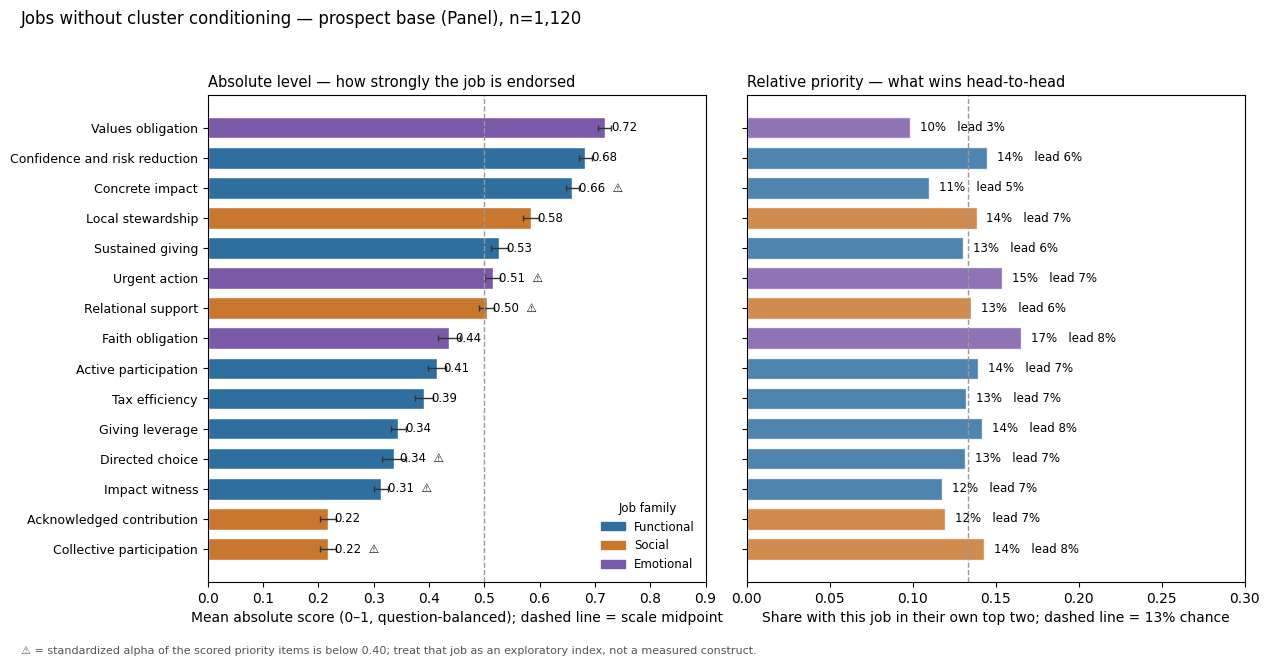

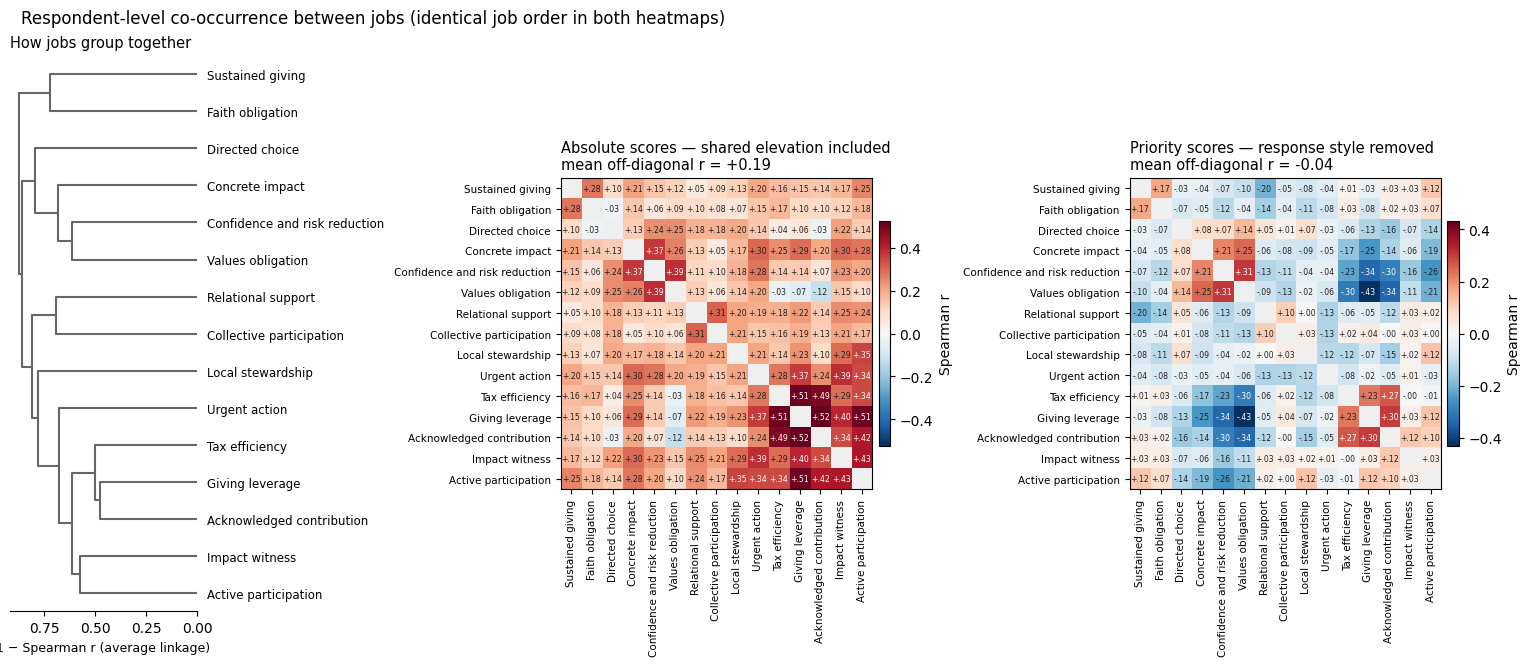

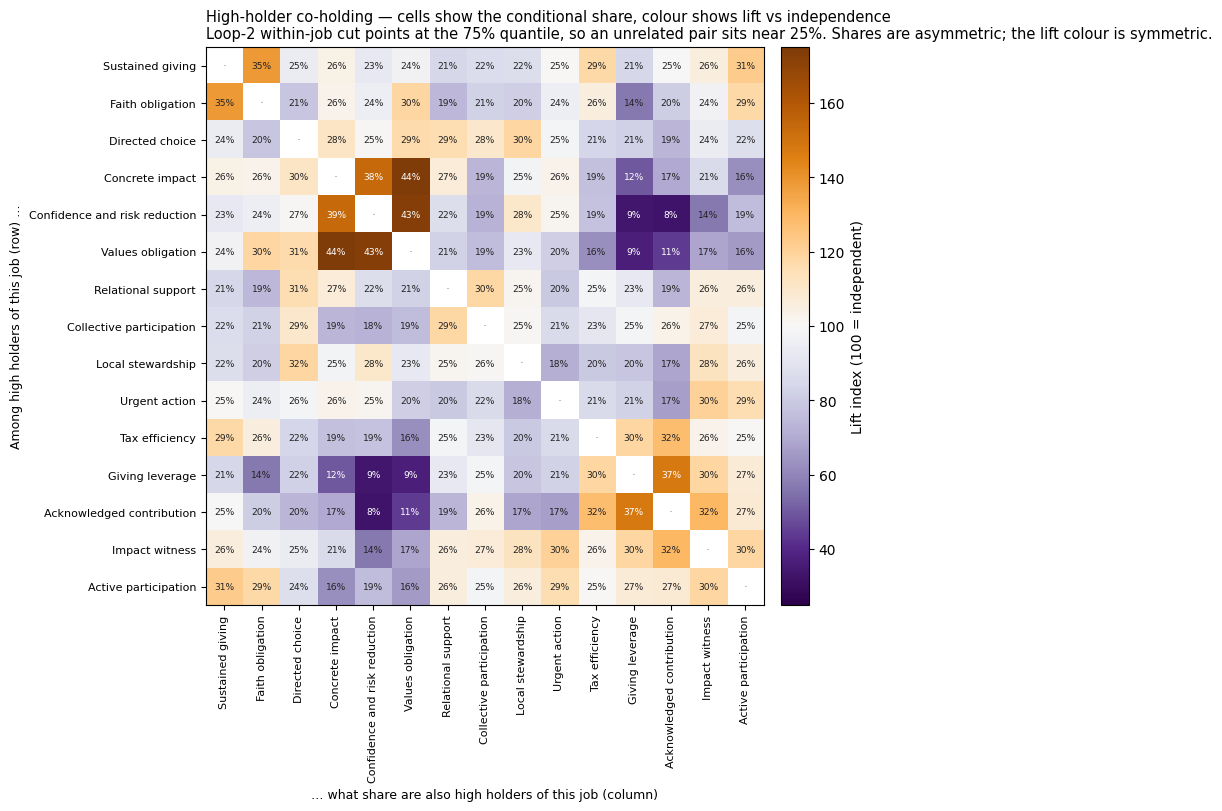

,Family,Items / questions,Absolute mean,95% CI,Above midpoint,Leads,Top two,Rank shift,Alpha (abs items),Alpha (priority items),Analyst confidence
Job (ranked by absolute level),,,,,,,,,,,
Values obligation,Emotional,4 / 3,0.72,0.71–0.73,83%,3%,10%,-14,+0.55,+0.54,well-measured
Confidence and risk reduction,Functional,5 / 4,0.68,0.67–0.69,83%,6%,14%,-1,+0.63,+0.56,well-measured
Concrete impact,Functional,2 / 2,0.66,0.65–0.67,89%,5%,11%,-11,+0.24,+0.14 ⚠,proxy-thin
Local stewardship,Social,4 / 4,0.58,0.57–0.60,71%,7%,14%,-3,+0.50,+0.47,well-measured
Sustained giving,Functional,3 / 3,0.53,0.51–0.54,60%,6%,13%,-6,+0.47,+0.42,well-measured
Urgent action,Emotional,3 / 3,0.51,0.50–0.53,55%,7%,15%,+4,+0.49,+0.34 ⚠,well-measured
Relational support,Social,3 / 2,0.50,0.49–0.52,57%,6%,13%,-1,+0.40,+0.23 ⚠,proxy-thin
Faith obligation,Emotional,2 / 2,0.44,0.42–0.46,42%,8%,17%,+7,+0.55,+0.57,proxy-thin
Active participation,Functional,3 / 3,0.41,0.40–0.43,39%,7%,14%,+3,+0.68,+0.51,well-measured


,Grouping,Families,r (absolute),r (priority),Both top two,Both high holder,Co-hold lift,b | high a / a | high b,Overlap flag
Job pair,,,,,,,,,
Giving leverage × Acknowledged contribution,Most coupled (|r| on absolute),Functional / Social,+0.52,+0.30,1.9%,9.3%,148,37% / 37%,—
Giving leverage × Tax efficiency,Most coupled (|r| on absolute),Functional,+0.51,+0.23,1.2%,7.4%,119,30% / 30%,—
Giving leverage × Active participation,Most coupled (|r| on absolute),Functional,+0.51,+0.12,1.5%,6.7%,107,27% / 27%,—
Tax efficiency × Acknowledged contribution,Most coupled (|r| on absolute),Functional / Social,+0.49,+0.27,1.2%,8.0%,128,32% / 32%,—
Impact witness × Active participation,Most coupled (|r| on absolute),Functional,+0.43,+0.03,0.9%,7.4%,119,30% / 30%,—
Active participation × Acknowledged contribution,Most coupled (|r| on absolute),Functional / Social,+0.42,+0.10,1.1%,6.8%,108,27% / 27%,—
Giving leverage × Impact witness,Most coupled (|r| on absolute),Functional,+0.40,+0.03,1.1%,7.4%,119,30% / 30%,—
Impact witness × Urgent action,Most coupled (|r| on absolute),Emotional / Functional,+0.39,+0.01,1.3%,7.5%,120,30% / 30%,—
Confidence and risk reduction × Values obligation,Most coupled (|r| on absolute),Emotional / Functional,+0.39,+0.31,1.9%,10.8%,173,43% / 43%,—


JOBS UNCONDITIONAL — READ-OUT
Base: prospect base (Panel), n=1,120
Most endorsed (absolute): Values obligation 0.72  |  least endorsed: Collective participation 0.22  |  spread 0.50 on a 0–1 scale
Most often top-two: Faith obligation (17%)  |  least: Values obligation (10%)  |  chance 13%
Absolute-level and top-two rankings agree at Spearman rho = -0.08 (low means "wanted a lot" and "wins head-to-head" are different questions).
Mean off-diagonal r: absolute +0.19 (range -0.12 to +0.52); priority -0.04 (range -0.43 to +0.31). The gap is the shared-elevation / response-style component the priority transform removes.
First eigenvalue share of the 15x15 correlation matrix: absolute 26.2%, priority 17.2%. A high absolute share means one general giving-engagement factor dominates the raw scores.
Composites below alpha 0.40 on priority items (6 of 15): Concrete impact, Urgent action, Relational support, Directed choice, Impact witness, Collective participation. Their prevalence ranks should n

In [26]:
# ============================================================================
# 3.7  Jobs, unconditional — prevalence and respondent-level co-occurrence
# ----------------------------------------------------------------------------
# No cluster split, no refit, no new model. Reads Loop-2 outputs plus the
# JOB_FAMILY / display helpers prepared at the start of Zone 3.
#
# Two prevalence definitions are shown side by side on purpose:
#   absolute__  = question-balanced level     -> "how strongly is this wanted"
#   priority__  = within-question centred     -> "what wins when jobs compete"
# They rank jobs differently. The gap between them is the finding, not noise.
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import squareform

_JOBS_BASE = 'prospects'          # 'prospects' (Panel; Loop-2 card base) | 'all_retained'
_JOBS_ALPHA_FLOOR = 0.40          # below this a composite is not behaving as one construct
_JOBS_HEAT_ANNOT = True           # numeric labels inside the correlation heatmaps

_FAMILY_COLOR = {'Functional': '#2f6f9f', 'Social': '#c9772f', 'Emotional': '#7a5aa8'}

# ---------------------------------------------------------------------------
# Base
# ---------------------------------------------------------------------------
if _JOBS_BASE == 'prospects':
    _jobs_scores = jtbd_results['score_table'].loc[prospect_mask_retained].copy()
    assert _jobs_scores[SOURCE_COL].eq('Panel').all(), 'Prospect base leaked a non-Panel row.'
    _jobs_base_label = f'prospect base (Panel), n={len(_jobs_scores):,}'
elif _JOBS_BASE == 'all_retained':
    _jobs_scores = jtbd_results['score_table'].copy()
    _jobs_base_label = f'all attention-check retained respondents, n={len(_jobs_scores):,}'
else:
    raise ValueError(f'Unknown _JOBS_BASE={_JOBS_BASE!r}')

_jobs_idx = _jobs_scores.index
_jobs_n = len(_jobs_idx)
_jobs_abs = _jobs_scores[[f'absolute__{j}' for j in JTBD_JOBS]].copy()
_jobs_pri = _jobs_scores[[f'priority__{j}' for j in JTBD_JOBS]].copy()
_jobs_abs.columns = list(JTBD_JOBS)
_jobs_pri.columns = list(JTBD_JOBS)
assert _jobs_abs.notna().all().all(), 'Unexpected missing job score on the unconditional base.'

_jobs_label = {j: JTBD_JOB_DOMAIN_LOOKUP[j]['provisional_name'] for j in JTBD_JOBS}
_jobs_family = {j: JOB_FAMILY[j] for j in JTBD_JOBS}

# Relative standing: z within job, then rank each respondent's own 15 jobs.
_jobs_pri_z = jtbd_standardize_completed_scores(_jobs_pri)
_jobs_rank = _jobs_pri_z.rank(axis=1, method='average', ascending=False)
_jobs_top1 = _jobs_rank.le(1.0)
_jobs_top2 = _jobs_rank.le(2.0)

# Loop-2 within-job high-holder cut points, reused unchanged.
_jobs_high = pd.DataFrame(
    {j: _jobs_pri[j].ge(jtbd_cards['thresholds'][j]) for j in JTBD_JOBS},
    index=_jobs_idx,
)

# ---------------------------------------------------------------------------
# Per-job prevalence + reliability of the composite as actually scored
# ---------------------------------------------------------------------------
_jobs_card_summary = jtbd_cards['combined_summary']
if 'job_family' in _jobs_card_summary.columns:
    _jobs_card_summary = _jobs_card_summary.set_index('job_family')

_jobs_rows = []
for _job in JTBD_JOBS:
    _items = core_cfg.loc[core_cfg.job_family.eq(_job), 'feature_id'].tolist()
    _mean = float(_jobs_abs[_job].mean())
    _se = float(_jobs_abs[_job].std(ddof=1) / np.sqrt(_jobs_n))
    _jobs_rows.append({
        'job_family': _job,
        'provisional_name': _jobs_label[_job],
        'family': _jobs_family[_job],
        'n_items': len(_items),
        'n_questions': int(core_cfg.loc[core_cfg.job_family.eq(_job), 'question_group'].nunique()),
        'absolute_mean': _mean,
        'absolute_se': _se,
        'absolute_ci_low': _mean - 1.96 * _se,
        'absolute_ci_high': _mean + 1.96 * _se,
        'absolute_sd': float(_jobs_abs[_job].std(ddof=1)),
        'share_above_midpoint': float(_jobs_abs[_job].ge(0.5).mean()),
        'priority_mean': float(_jobs_pri[_job].mean()),
        'top1_share': float(_jobs_top1[_job].mean()),
        'top2_share': float(_jobs_top2[_job].mean()),
        'high_holder_share': float(_jobs_high[_job].mean()),
        'alpha_scored_absolute_items': standardized_alpha(jtbd_results['raw_items'].loc[_jobs_idx, _items]),
        'alpha_scored_priority_items': standardized_alpha(jtbd_results['priority_items'].loc[_jobs_idx, _items]),
        'card_priority_alpha': (
            float(_jobs_card_summary.loc[_job, 'priority_standardized_alpha'])
            if _job in _jobs_card_summary.index else np.nan
        ),
        'measurement_confidence': JTBD_JOB_DOMAIN_LOOKUP[_job]['measurement_confidence'],
    })

_jobs_prevalence = pd.DataFrame(_jobs_rows).set_index('job_family')
_jobs_prevalence['absolute_rank'] = _jobs_prevalence.absolute_mean.rank(ascending=False).astype(int)
_jobs_prevalence['top2_rank'] = _jobs_prevalence.top2_share.rank(ascending=False).astype(int)
_jobs_prevalence['rank_shift_abs_to_top2'] = _jobs_prevalence.absolute_rank - _jobs_prevalence.top2_rank
_jobs_prevalence['alpha_gap_style_component'] = (
    _jobs_prevalence.alpha_scored_absolute_items - _jobs_prevalence.alpha_scored_priority_items
)
_jobs_prevalence = _jobs_prevalence.sort_values('absolute_mean', ascending=False)
_jobs_prevalence.to_csv(OUTPUT_DIR / 'jobs_unconditional_prevalence.csv')
_jobs_order_abs = _jobs_prevalence.index.tolist()

# ---------------------------------------------------------------------------
# Respondent-level co-occurrence
# ---------------------------------------------------------------------------
_jobs_corr_abs = _jobs_abs.corr(method='spearman')
_jobs_corr_pri = _jobs_pri.corr(method='spearman')
_jobs_corr_top2 = _jobs_top2.astype(float).corr(method='pearson')     # phi on top-two flags

# Order jobs by how they co-vary, not alphabetically and not by prevalence.
_jobs_dist = (1.0 - _jobs_corr_abs.to_numpy()).clip(min=0.0)
np.fill_diagonal(_jobs_dist, 0.0)
_jobs_dist = (_jobs_dist + _jobs_dist.T) / 2.0
_jobs_link = linkage(squareform(_jobs_dist, checks=False), method='average')
_jobs_order_corr = [_jobs_corr_abs.index[i] for i in leaves_list(_jobs_link)]

# Asymmetric co-holding: P(high on column | high on row), indexed to independence = 100.
_jobs_cohold = pd.DataFrame(index=list(JTBD_JOBS), columns=list(JTBD_JOBS), dtype=float)
_jobs_cohold_lift = _jobs_cohold.copy()
for _a in JTBD_JOBS:
    _base_a = _jobs_high[_a]
    for _b in JTBD_JOBS:
        if _a == _b:
            _jobs_cohold.loc[_a, _b] = np.nan
            _jobs_cohold_lift.loc[_a, _b] = np.nan
            continue
        _cond = float(_jobs_high.loc[_base_a, _b].mean()) if _base_a.any() else np.nan
        _marginal = float(_jobs_high[_b].mean())
        _jobs_cohold.loc[_a, _b] = _cond
        _jobs_cohold_lift.loc[_a, _b] = 100.0 * _cond / _marginal if _marginal > 0 else np.nan
_jobs_cohold.to_csv(OUTPUT_DIR / 'jobs_unconditional_coholding_conditional_share.csv')
_jobs_cohold_lift.to_csv(OUTPUT_DIR / 'jobs_unconditional_coholding_lift_index.csv')

_n_pairs = len(JTBD_JOBS) * (len(JTBD_JOBS) - 1) // 2
_top2_pair_chance = 1.0 / _n_pairs
_jobs_pairs = []
for _i, _a in enumerate(JTBD_JOBS):
    for _b in list(JTBD_JOBS)[_i + 1:]:
        _jobs_pairs.append({
            'job_a': _jobs_label[_a],
            'job_b': _jobs_label[_b],
            'family_pair': ' / '.join(sorted({_jobs_family[_a], _jobs_family[_b]})),
            'absolute_spearman_r': float(_jobs_corr_abs.loc[_a, _b]),
            'priority_spearman_r': float(_jobs_corr_pri.loc[_a, _b]),
            'top2_cooccurrence_phi': float(_jobs_corr_top2.loc[_a, _b]),
            'both_top2_share': float((_jobs_top2[_a] & _jobs_top2[_b]).mean()),
            'both_high_holder_share': float((_jobs_high[_a] & _jobs_high[_b]).mean()),
            'coholding_lift': float(_jobs_cohold_lift.loc[_a, _b]),
            'cond_share_b_given_high_a': float(_jobs_cohold.loc[_a, _b]),
            'cond_share_a_given_high_b': float(_jobs_cohold.loc[_b, _a]),
            'overlap_flag_priority': bool(abs(_jobs_corr_pri.loc[_a, _b]) >= JTBD_OVERLAP_THRESHOLD),
            'overlap_flag_absolute': bool(abs(_jobs_corr_abs.loc[_a, _b]) >= JTBD_OVERLAP_THRESHOLD),
        })
_jobs_pair_table = pd.DataFrame(_jobs_pairs)
_jobs_pair_table.to_csv(OUTPUT_DIR / 'jobs_unconditional_pairwise_correlations.csv', index=False)

_high_pair_chance = float(_jobs_prevalence.high_holder_share.mean()) ** 2

_jobs_offdiag_abs = _jobs_corr_abs.to_numpy()[np.triu_indices(len(JTBD_JOBS), k=1)]
_jobs_offdiag_pri = _jobs_corr_pri.to_numpy()[np.triu_indices(len(JTBD_JOBS), k=1)]
_jobs_eig_abs = np.linalg.eigvalsh(_jobs_corr_abs.to_numpy())[::-1]
_jobs_eig_pri = np.linalg.eigvalsh(_jobs_corr_pri.to_numpy())[::-1]

# ---------------------------------------------------------------------------
# Panel 1 — the two prevalence definitions, ranked
# ---------------------------------------------------------------------------
_fig1, _axes = plt.subplots(1, 2, figsize=(12.8, 6.6), sharey=True)
_y = np.arange(len(_jobs_order_abs))[::-1]
_colors = [_FAMILY_COLOR[_jobs_family[j]] for j in _jobs_order_abs]

_ax = _axes[0]
_ax.barh(_y, [_jobs_prevalence.loc[j, 'absolute_mean'] for j in _jobs_order_abs],
         color=_colors, edgecolor='white', height=0.72)
_ax.errorbar(
    [_jobs_prevalence.loc[j, 'absolute_mean'] for j in _jobs_order_abs], _y,
    xerr=[1.96 * _jobs_prevalence.loc[j, 'absolute_se'] for j in _jobs_order_abs],
    fmt='none', ecolor='#333333', elinewidth=1.0, capsize=2.5,
)
_ax.axvline(0.5, color='#999999', ls='--', lw=1.0)
for _pos, _job in zip(_y, _jobs_order_abs):
    _v = _jobs_prevalence.loc[_job, 'absolute_mean']
    _bad = _jobs_prevalence.loc[_job, 'alpha_scored_priority_items']
    _flag = '  ⚠' if not (_bad >= _JOBS_ALPHA_FLOOR) else ''
    _ax.text(_v + 0.012, _pos, f'{_v:.2f}{_flag}', va='center', fontsize=8.5)
_ax.set_yticks(_y, [_jobs_label[j] for j in _jobs_order_abs], fontsize=9)
_ax.set_xlim(0, max(0.9, float(_jobs_prevalence.absolute_mean.max()) + 0.14))
_ax.set_xlabel('Mean absolute score (0–1, question-balanced); dashed line = scale midpoint')
_ax.set_title('Absolute level — how strongly the job is endorsed', fontsize=10.5, loc='left')

_ax = _axes[1]
_ax.barh(_y, [_jobs_prevalence.loc[j, 'top2_share'] for j in _jobs_order_abs],
         color=_colors, edgecolor='white', height=0.72, alpha=0.85)
_ax.axvline(2.0 / len(JTBD_JOBS), color='#999999', ls='--', lw=1.0)
for _pos, _job in zip(_y, _jobs_order_abs):
    _t2 = _jobs_prevalence.loc[_job, 'top2_share']
    _t1 = _jobs_prevalence.loc[_job, 'top1_share']
    _ax.text(_t2 + 0.006, _pos, f'{_t2:.0%}   lead {_t1:.0%}', va='center', fontsize=8.5)
_ax.set_xlim(0, max(0.30, float(_jobs_prevalence.top2_share.max()) + 0.11))
_ax.set_xlabel(f'Share with this job in their own top two; dashed line = {2 / len(JTBD_JOBS):.0%} chance')
_ax.set_title('Relative priority — what wins head-to-head', fontsize=10.5, loc='left')

_handles = [plt.Rectangle((0, 0), 1, 1, color=_FAMILY_COLOR[f]) for f in _FAMILY_COLOR]
_axes[0].legend(_handles, list(_FAMILY_COLOR), title='Job family', fontsize=8.5,
                title_fontsize=8.5, loc='lower right', frameon=False)
_fig1.suptitle(f'Jobs without cluster conditioning — {_jobs_base_label}', fontsize=12, x=0.02, ha='left')
_fig1.text(0.02, 0.004,
           '⚠ = standardized alpha of the scored priority items is below '
           f'{_JOBS_ALPHA_FLOOR:.2f}; treat that job as an exploratory index, not a measured construct.',
           fontsize=8, color='#555555')
_fig1.tight_layout(rect=(0, 0.025, 1, 0.955))
_fig1.savefig(OUTPUT_DIR / 'jobs_unconditional_prevalence.png', dpi=170, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# Panel 2 — co-occurrence structure
# ---------------------------------------------------------------------------
_fig2 = plt.figure(figsize=(15.2, 6.6), layout='constrained')
_gs = _fig2.add_gridspec(1, 3, width_ratios=[0.60, 1.0, 1.0])

_axd = _fig2.add_subplot(_gs[0, 0])
dendrogram(_jobs_link, orientation='left',
           labels=[_jobs_label[j] for j in _jobs_corr_abs.index],
           color_threshold=0.0, above_threshold_color='#666666', ax=_axd)
_axd.invert_yaxis()   # match the top-to-bottom leaf order used by the heatmaps
_axd.set_xlabel('1 − Spearman r (average linkage)', fontsize=9)
_axd.set_title('How jobs group together', fontsize=10.5, loc='left')
_axd.tick_params(axis='y', labelsize=8.5)
_axd.spines[['top', 'right', 'left']].set_visible(False)


def _jobs_heat(ax, corr, title):
    _m = corr.loc[_jobs_order_corr, _jobs_order_corr]
    _values = _m.to_numpy(dtype=float).copy()
    _lim = max(0.30, float(np.nanmax(np.abs(_values - np.eye(len(_m))))))
    np.fill_diagonal(_values, np.nan)          # the diagonal is 1 by definition; do not shade it
    _cmap = plt.get_cmap('RdBu_r').copy()
    _cmap.set_bad('#efefef')
    _im = ax.imshow(_values, cmap=_cmap,
                    norm=TwoSlopeNorm(vmin=-_lim, vcenter=0.0, vmax=_lim))
    _ticks = [_jobs_label[j] for j in _jobs_order_corr]
    ax.set_xticks(range(len(_m)), _ticks, rotation=90, fontsize=7.5)
    ax.set_yticks(range(len(_m)), _ticks, fontsize=7.5)
    if _JOBS_HEAT_ANNOT:
        for _i in range(len(_m)):
            for _j in range(len(_m)):
                if _i == _j:
                    continue
                _r = float(_m.iat[_i, _j])
                ax.text(_j, _i, f'{_r:+.2f}'.replace('0.', '.'), ha='center', va='center',
                        fontsize=5.6, color='white' if abs(_r) > 0.62 * _lim else '#222222')
    ax.set_title(title, fontsize=10.5, loc='left')
    _fig2.colorbar(_im, ax=ax, fraction=0.036, pad=0.02, label='Spearman r')


_jobs_heat(_fig2.add_subplot(_gs[0, 1]),
           _jobs_corr_abs,
           f'Absolute scores — shared elevation included\nmean off-diagonal r = {_jobs_offdiag_abs.mean():+.2f}')
_jobs_heat(_fig2.add_subplot(_gs[0, 2]),
           _jobs_corr_pri,
           f'Priority scores — response style removed\nmean off-diagonal r = {_jobs_offdiag_pri.mean():+.2f}')
_fig2.suptitle('Respondent-level co-occurrence between jobs (identical job order in both heatmaps)',
               fontsize=12, x=0.01, ha='left')
_fig2.savefig(OUTPUT_DIR / 'jobs_unconditional_correlations.png', dpi=170, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# Panel 3 — co-holding: who else is a high holder
# ---------------------------------------------------------------------------
_fig3, _ax3 = plt.subplots(figsize=(9.6, 8.0), layout='constrained')
_cohold_plot = _jobs_cohold_lift.loc[_jobs_order_corr, _jobs_order_corr]
_cohold_share_plot = _jobs_cohold.loc[_jobs_order_corr, _jobs_order_corr]
_cl = max(20.0, float(np.nanmax(np.abs(_cohold_plot.to_numpy() - 100.0))))
_im3 = _ax3.imshow(_cohold_plot.to_numpy(), cmap='PuOr_r',
                   norm=TwoSlopeNorm(vmin=100 - _cl, vcenter=100.0, vmax=100 + _cl))
_ticks3 = [_jobs_label[j] for j in _jobs_order_corr]
_ax3.set_xticks(range(len(_ticks3)), _ticks3, rotation=90, fontsize=8)
_ax3.set_yticks(range(len(_ticks3)), _ticks3, fontsize=8)
for _i in range(len(_cohold_plot)):
    for _j in range(len(_cohold_plot)):
        if _i == _j:
            _ax3.text(_j, _i, '·', ha='center', va='center', fontsize=9, color='#999999')
            continue
        _v = float(_cohold_plot.iat[_i, _j])
        _ax3.text(_j, _i, f'{_cohold_share_plot.iat[_i, _j]:.0%}', ha='center', va='center',
                  fontsize=6.6, color='white' if abs(_v - 100) > 0.62 * _cl else '#222222')
_ax3.set_xlabel('… what share are also high holders of this job (column)', fontsize=9)
_ax3.set_ylabel('Among high holders of this job (row) …', fontsize=9)
_ax3.set_title(
    'High-holder co-holding — cells show the conditional share, colour shows lift vs independence\n'
    f'Loop-2 within-job cut points at the {JTBD_HIGH_HOLDER_QUANTILE:.0%} quantile, so an unrelated pair '
    f'sits near {float(_jobs_prevalence.high_holder_share.mean()):.0%}. Shares are asymmetric; the lift '
    'colour is symmetric.',
    fontsize=10.5, loc='left',
)
_fig3.colorbar(_im3, ax=_ax3, fraction=0.040, pad=0.02, label='Lift index (100 = independent)')
_fig3.savefig(OUTPUT_DIR / 'jobs_unconditional_coholding.png', dpi=170, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# Tables
# ---------------------------------------------------------------------------
_jobs_display = pd.DataFrame({
    'Family': [_jobs_family[j] for j in _jobs_order_abs],
    'Items / questions': [
        f"{int(_jobs_prevalence.loc[j, 'n_items'])} / {int(_jobs_prevalence.loc[j, 'n_questions'])}"
        for j in _jobs_order_abs
    ],
    'Absolute mean': [f"{_jobs_prevalence.loc[j, 'absolute_mean']:.2f}" for j in _jobs_order_abs],
    '95% CI': [
        f"{_jobs_prevalence.loc[j, 'absolute_ci_low']:.2f}–{_jobs_prevalence.loc[j, 'absolute_ci_high']:.2f}"
        for j in _jobs_order_abs
    ],
    'Above midpoint': [f"{_jobs_prevalence.loc[j, 'share_above_midpoint']:.0%}" for j in _jobs_order_abs],
    'Leads': [f"{_jobs_prevalence.loc[j, 'top1_share']:.0%}" for j in _jobs_order_abs],
    'Top two': [f"{_jobs_prevalence.loc[j, 'top2_share']:.0%}" for j in _jobs_order_abs],
    'Rank shift': [f"{int(_jobs_prevalence.loc[j, 'rank_shift_abs_to_top2']):+d}" for j in _jobs_order_abs],
    'Alpha (abs items)': [
        f"{_jobs_prevalence.loc[j, 'alpha_scored_absolute_items']:+.2f}" for j in _jobs_order_abs
    ],
    'Alpha (priority items)': [
        f"{_jobs_prevalence.loc[j, 'alpha_scored_priority_items']:+.2f}"
        + ('  ⚠' if not (_jobs_prevalence.loc[j, 'alpha_scored_priority_items'] >= _JOBS_ALPHA_FLOOR) else '')
        for j in _jobs_order_abs
    ],
    'Analyst confidence': [_jobs_prevalence.loc[j, 'measurement_confidence'] for j in _jobs_order_abs],
}, index=[_jobs_label[j] for j in _jobs_order_abs])
_jobs_display.index.name = 'Job (ranked by absolute level)'

_show_table(
    _jobs_display,
    'JOBS WITHOUT CLUSTER CONDITIONING — PREVALENCE AND RELIABILITY',
    f'{_jobs_base_label}. "Above midpoint" = share scoring ≥0.50 on the 0–1 absolute score. '
    f'"Leads" and "Top two" rank each respondent against their own 15 priority z-scores, so chance is '
    f'{1 / len(JTBD_JOBS):.0%} and {2 / len(JTBD_JOBS):.0%}. "Rank shift" = absolute rank minus top-two rank; '
    'positive means the job wins head-to-head more often than its absolute level would suggest. '
    'Alpha is recomputed here across every item in the scored composite, so it can differ from the Loop-2 '
    'card value, which covers latent-eligible items only. Analyst confidence is a hand-assigned label, '
    'not a function of alpha.',
)

_jobs_strong = _jobs_pair_table.reindex(
    _jobs_pair_table.absolute_spearman_r.abs().sort_values(ascending=False).index
).head(12).assign(_group='Most coupled (|r| on absolute)')
_jobs_weak = _jobs_pair_table.sort_values('absolute_spearman_r').head(6).assign(
    _group='Most negatively coupled'
)
_jobs_pairs_shown = pd.concat([_jobs_strong, _jobs_weak])
_jobs_pair_display = pd.DataFrame({
    'Grouping': _jobs_pairs_shown._group.to_numpy(),
    'Families': _jobs_pairs_shown.family_pair.to_numpy(),
    'r (absolute)': [f'{v:+.2f}' for v in _jobs_pairs_shown.absolute_spearman_r],
    'r (priority)': [f'{v:+.2f}' for v in _jobs_pairs_shown.priority_spearman_r],
    'Both top two': [f'{v:.1%}' for v in _jobs_pairs_shown.both_top2_share],
    'Both high holder': [f'{v:.1%}' for v in _jobs_pairs_shown.both_high_holder_share],
    'Co-hold lift': [f'{v:.0f}' for v in _jobs_pairs_shown.coholding_lift],
    'b | high a  /  a | high b': [
        f'{x:.0%} / {y:.0%}' for x, y in zip(
            _jobs_pairs_shown.cond_share_b_given_high_a, _jobs_pairs_shown.cond_share_a_given_high_b
        )
    ],
    'Overlap flag': np.where(
        _jobs_pairs_shown.overlap_flag_priority, f'|r| ≥ {JTBD_OVERLAP_THRESHOLD:.2f} on priority',
        np.where(_jobs_pairs_shown.overlap_flag_absolute,
                 f'|r| ≥ {JTBD_OVERLAP_THRESHOLD:.2f} on absolute only', '—'),
    ),
}, index=pd.Index(_jobs_pairs_shown.job_a + '  ×  ' + _jobs_pairs_shown.job_b, name='Job pair'))

_show_table(
    _jobs_pair_display,
    'JOB PAIRS — RESPONDENT-LEVEL COUPLING',
    f'Top 12 by |r| on absolute scores, then the 6 most negative, of {_n_pairs} pairs. '
    f'{int(_jobs_pair_table.overlap_flag_priority.sum())} pairs reach the preregistered '
    f'|r| ≥ {JTBD_OVERLAP_THRESHOLD:.2f} threshold on priority scores and '
    f'{int(_jobs_pair_table.overlap_flag_absolute.sum())} on absolute scores. '
    f'"Both top two" chance rate under random ranking is {_top2_pair_chance:.1%}; '
    f'"Both high holder" chance rate is about {_high_pair_chance:.1%}. '
    'Co-hold lift is asymmetric: 100 = independence.',
)

print('JOBS UNCONDITIONAL — READ-OUT')
print(f'Base: {_jobs_base_label}')
print(
    f'Most endorsed (absolute): {_jobs_label[_jobs_order_abs[0]]} '
    f'{_jobs_prevalence.absolute_mean.iloc[0]:.2f}  |  least endorsed: '
    f'{_jobs_label[_jobs_order_abs[-1]]} {_jobs_prevalence.absolute_mean.iloc[-1]:.2f}  |  spread '
    f'{_jobs_prevalence.absolute_mean.iloc[0] - _jobs_prevalence.absolute_mean.iloc[-1]:.2f} on a 0–1 scale'
)
print(
    f'Most often top-two: {_jobs_label[_jobs_prevalence.top2_share.idxmax()]} '
    f'({_jobs_prevalence.top2_share.max():.0%})  |  least: '
    f'{_jobs_label[_jobs_prevalence.top2_share.idxmin()]} ({_jobs_prevalence.top2_share.min():.0%})  |  '
    f'chance {2 / len(JTBD_JOBS):.0%}'
)
print(
    f'Absolute-level and top-two rankings agree at Spearman rho = '
    f'{_jobs_prevalence.absolute_mean.corr(_jobs_prevalence.top2_share, method="spearman"):+.2f} '
    '(low means "wanted a lot" and "wins head-to-head" are different questions).'
)
print(
    f'Mean off-diagonal r: absolute {_jobs_offdiag_abs.mean():+.2f} '
    f'(range {_jobs_offdiag_abs.min():+.2f} to {_jobs_offdiag_abs.max():+.2f}); priority '
    f'{_jobs_offdiag_pri.mean():+.2f} (range {_jobs_offdiag_pri.min():+.2f} to {_jobs_offdiag_pri.max():+.2f}). '
    'The gap is the shared-elevation / response-style component the priority transform removes.'
)
print(
    f'First eigenvalue share of the {len(JTBD_JOBS)}x{len(JTBD_JOBS)} correlation matrix: absolute '
    f'{_jobs_eig_abs[0] / len(JTBD_JOBS):.1%}, priority {_jobs_eig_pri[0] / len(JTBD_JOBS):.1%}. '
    'A high absolute share means one general giving-engagement factor dominates the raw scores.'
)
_jobs_low_alpha = _jobs_prevalence.loc[
    ~(_jobs_prevalence.alpha_scored_priority_items >= _JOBS_ALPHA_FLOOR), 'provisional_name'
].tolist()
print(
    f'Composites below alpha {_JOBS_ALPHA_FLOOR:.2f} on priority items '
    f'({len(_jobs_low_alpha)} of {len(JTBD_JOBS)}): '
    + (', '.join(_jobs_low_alpha) if _jobs_low_alpha else 'none')
    + '. Their prevalence ranks should not be read as construct-level findings.'
)
print('Descriptive only: prevalence does not license a job as a segment or a campaign target.')


## 3.8 Jobs — unconditional strategy diagnostics

Organizes absolute endorsement, relative priority, job bundles, and family-pair composition into descriptive strategy hypotheses.


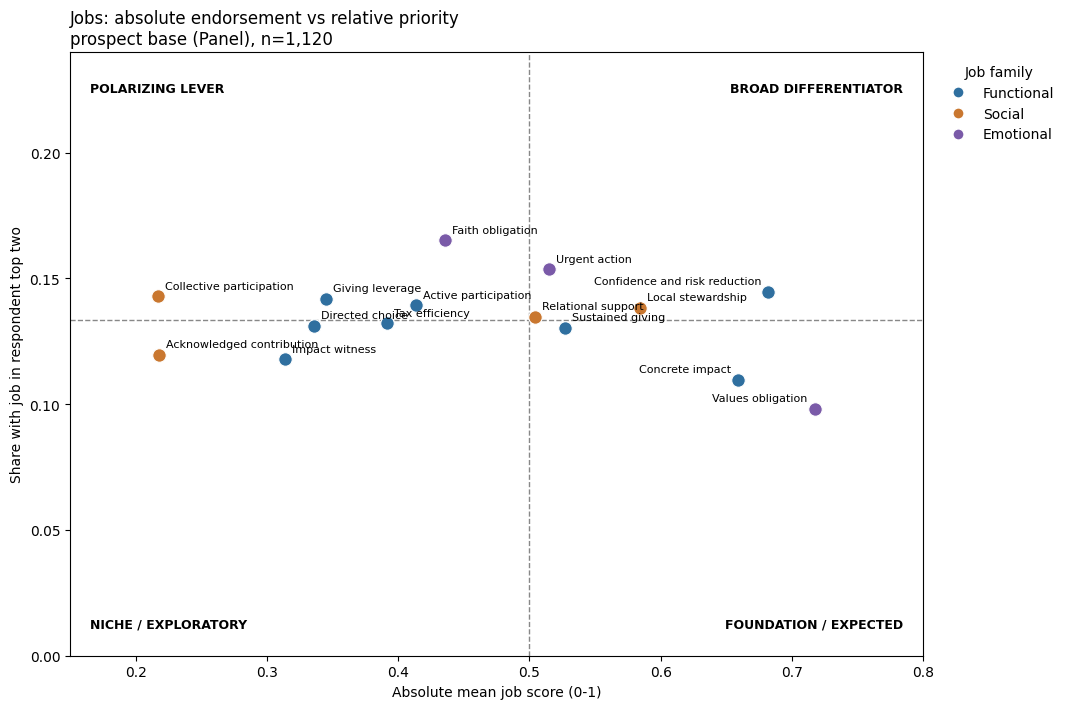

,Family,Quadrant,Absolute mean,Top two,Priority alpha,Measurement
Job,,,,,,
Urgent action,Emotional,Broad differentiator,0.51,15%,+0.34,well-measured
Confidence and risk reduction,Functional,Broad differentiator,0.68,14%,+0.56,well-measured
Local stewardship,Social,Broad differentiator,0.58,14%,+0.47,well-measured
Relational support,Social,Broad differentiator,0.50,13%,+0.23,proxy-thin
Sustained giving,Functional,Foundation / expected,0.53,13%,+0.42,well-measured
Concrete impact,Functional,Foundation / expected,0.66,11%,+0.14,proxy-thin
Values obligation,Emotional,Foundation / expected,0.72,10%,+0.54,well-measured
Faith obligation,Emotional,Polarizing lever,0.44,17%,+0.57,proxy-thin
Collective participation,Social,Polarizing lever,0.22,14%,+0.09,proxy-thin


,Read,Families,Observed,Expected,Difference,Lift,n
Top-two pair,,,,,,,
Concrete impact x Values obligation,nan,nan,nan,nan,nan,nan,nan
Confidence and risk reduction x Values obligation,nan,nan,nan,nan,nan,nan,nan
Sustained giving x Faith obligation,nan,nan,nan,nan,nan,nan,nan
Impact witness x Acknowledged contribution,nan,nan,nan,nan,nan,nan,nan
Concrete impact x Confidence and risk reduction,nan,nan,nan,nan,nan,nan,nan
Giving leverage x Acknowledged contribution,nan,nan,nan,nan,nan,nan,nan
Concrete impact x Local stewardship,nan,nan,nan,nan,nan,nan,nan
Directed choice x Active participation,nan,nan,nan,nan,nan,nan,nan
Impact witness x Values obligation,nan,nan,nan,nan,nan,nan,nan


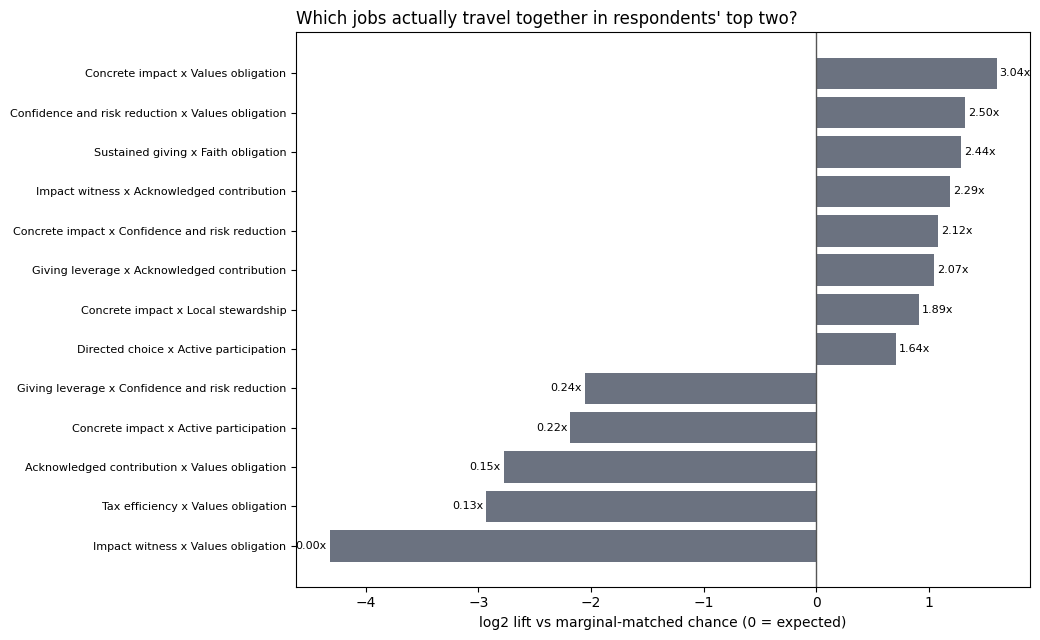

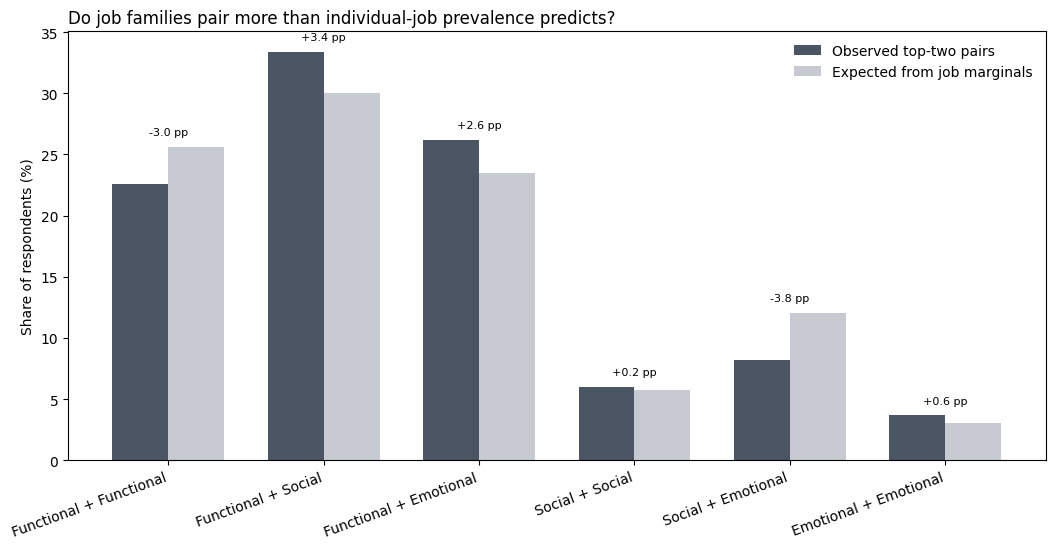

,Observed,Expected,Difference,Lift
Functional + Functional,22.6%,25.6%,-3.0 pp,0.88x
Functional + Social,33.4%,30.0%,+3.4 pp,1.11x
Functional + Emotional,26.2%,23.5%,+2.6 pp,1.11x
Social + Social,6.0%,5.8%,+0.2 pp,1.04x
Social + Emotional,8.2%,12.0%,-3.8 pp,0.68x
Emotional + Emotional,3.7%,3.1%,+0.6 pp,1.19x


JOBS STRATEGY DIAGNOSTICS - READ-OUT
Quadrants: Broad differentiator=4; Foundation / expected=3; Polarizing lever=4; Niche / exploratory=4
Strongest promoted pair: Concrete impact x Values obligation (1.7% vs 0.6%; 3.04x).
Largest family-pair deviation: Social + Emotional (-3.8 pp).
Descriptive only: this organizes strategy hypotheses; it does not create new segments or causal claims.


In [27]:
# ============================================================================
# 3.8 Jobs, unconditional — strategy diagnostics
# Run immediately after 3.7. Display-only: no refit, no cluster conditioning.
# ============================================================================
from matplotlib.lines import Line2D

_REQUIRED = [
    '_jobs_prevalence', '_jobs_pri_z', '_jobs_top2', '_jobs_label',
    '_jobs_family', '_FAMILY_COLOR', '_jobs_base_label', '_show_table',
]
_missing = [x for x in _REQUIRED if x not in globals()]
if _missing:
    raise RuntimeError('Run 3.7 first. Missing: ' + ', '.join(_missing))

# Rare exact ties can make average ranks produce != 2 jobs. Use deterministic
# first-tie ranking only for these pair diagnostics if that happens.
_top2 = _jobs_top2.copy()
if not _top2.sum(axis=1).eq(2).all():
    _top2 = _jobs_pri_z.rank(axis=1, method='first', ascending=False).le(2)
assert _top2.sum(axis=1).eq(2).all()

# ---------------------------------------------------------------------------
# A. Absolute endorsement x relative priority
# Natural cut points: 0.50 scale midpoint; 2 / number-of-jobs top-two chance.
# ---------------------------------------------------------------------------
_ABS_CUT = 0.50
_TOP2_CUT = 2.0 / len(JTBD_JOBS)


def _quadrant(row):
    if row.absolute_mean >= _ABS_CUT and row.top2_share >= _TOP2_CUT:
        return 'Broad differentiator'
    if row.absolute_mean >= _ABS_CUT:
        return 'Foundation / expected'
    if row.top2_share >= _TOP2_CUT:
        return 'Polarizing lever'
    return 'Niche / exploratory'


_quad = _jobs_prevalence.copy()
_quad['Job'] = [_jobs_label[j] for j in _quad.index]
_quad['Family'] = [_jobs_family[j] for j in _quad.index]
_quad['Quadrant'] = _quad.apply(_quadrant, axis=1)
_quad.to_csv(OUTPUT_DIR / 'jobs_unconditional_strategy_quadrant.csv')

fig, ax = plt.subplots(figsize=(10.8, 7.2))

for job, row in _quad.iterrows():
    ax.scatter(
        row.absolute_mean,
        row.top2_share,
        s=95,
        color=_FAMILY_COLOR[row.Family],
        edgecolor='white',
        linewidth=0.8,
        zorder=3,
    )

    dx = 5 if row.absolute_mean < 0.62 else -5
    ax.annotate(
        row.Job,
        (row.absolute_mean, row.top2_share),
        xytext=(dx, 4),
        textcoords='offset points',
        fontsize=8,
        ha='left' if dx > 0 else 'right',
        va='bottom',
    )

ax.axvline(_ABS_CUT, color='#888888', ls='--', lw=1)
ax.axhline(_TOP2_CUT, color='#888888', ls='--', lw=1)

ax.set_xlim(
    0.15,
    max(0.80, float(_quad.absolute_mean.max()) + 0.05),
)
ax.set_ylim(
    0.00,
    max(0.24, float(_quad.top2_share.max()) + 0.035),
)

ax.set_xlabel('Absolute mean job score (0-1)')
ax.set_ylabel('Share with job in respondent top two')
ax.set_title(
    f'Jobs: absolute endorsement vs relative priority\n{_jobs_base_label}',
    loc='left',
)

x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.text(
    x0 + .015, y1 - .012,
    'POLARIZING LEVER',
    fontsize=9, weight='bold', va='top',
)
ax.text(
    x1 - .015, y1 - .012,
    'BROAD DIFFERENTIATOR',
    fontsize=9, weight='bold', ha='right', va='top',
)
ax.text(
    x0 + .015, y0 + .010,
    'NICHE / EXPLORATORY',
    fontsize=9, weight='bold', va='bottom',
)
ax.text(
    x1 - .015, y0 + .010,
    'FOUNDATION / EXPECTED',
    fontsize=9, weight='bold', ha='right', va='bottom',
)

family_legend = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='none',
        markersize=8,
        markerfacecolor=_FAMILY_COLOR[f],
        markeredgecolor='white',
        label=f,
    )
    for f in _FAMILY_COLOR
]

leg = ax.legend(
    handles=family_legend,
    title='Job family',
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    frameon=False,
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'jobs_unconditional_strategy_quadrant.png',
    dpi=170,
    bbox_inches='tight',
)
plt.show()

_quadrant_order = [
    'Broad differentiator',
    'Foundation / expected',
    'Polarizing lever',
    'Niche / exploratory',
]

_quad_display = _quad.assign(
    Quadrant=pd.Categorical(
        _quad.Quadrant,
        _quadrant_order,
        ordered=True,
    ),
    **{
        'Absolute mean': _quad.absolute_mean.map(
            lambda v: f'{v:.2f}'
        ),
        'Top two': _quad.top2_share.map(
            lambda v: f'{v:.0%}'
        ),
        'Priority alpha': _quad.alpha_scored_priority_items.map(
            lambda v: f'{v:+.2f}'
        ),
        'Measurement': _quad.measurement_confidence,
    },
).sort_values(
    ['Quadrant', 'top2_share'],
    ascending=[True, False],
)

_show_table(
    _quad_display.set_index('Job')[
        [
            'Family',
            'Quadrant',
            'Absolute mean',
            'Top two',
            'Priority alpha',
            'Measurement',
        ]
    ],
    'JOB STRATEGY QUADRANTS',
    f'Cut points: absolute midpoint={_ABS_CUT:.2f}; '
    f'top-two chance={_TOP2_CUT:.0%}. '
    'This is a strategy read, not a new taxonomy.',
)

# ---------------------------------------------------------------------------
# B. Top-two job bundles vs a marginal-matched chance model
# ---------------------------------------------------------------------------

def _expected_pair_matrix(top2_frame):
    """
    Maximum-entropy pair null preserving each job's
    observed top-two prevalence.
    """
    p = top2_frame.mean(axis=0).to_numpy(float)

    assert np.isclose(
        p.sum(),
        2.0,
        atol=1e-10,
    )

    q = np.outer(p, p)
    np.fill_diagonal(q, 0.0)

    q /= q[
        np.triu_indices(len(p), 1)
    ].sum()

    for _ in range(10000):
        current = q.sum(axis=1)

        ratio = np.divide(
            p,
            current,
            out=np.ones_like(p),
            where=current > 0,
        )

        q *= np.sqrt(
            np.outer(ratio, ratio)
        )

        np.fill_diagonal(q, 0.0)

        q /= q[
            np.triu_indices(len(p), 1)
        ].sum()

        if np.max(
            np.abs(q.sum(axis=1) - p)
        ) < 1e-12:
            break

    assert np.max(
        np.abs(q.sum(axis=1) - p)
    ) < 1e-8

    return q


_pair_jobs = list(JTBD_JOBS)

_expected = _expected_pair_matrix(
    _top2[_pair_jobs]
)

_pair_rows = []

for i, a in enumerate(_pair_jobs):
    for j in range(i + 1, len(_pair_jobs)):
        b = _pair_jobs[j]

        observed = float(
            (_top2[a] & _top2[b]).mean()
        )

        expected = float(
            _expected[i, j]
        )

        _pair_rows.append({
            'job_a': a,
            'job_b': b,
            'Job A': _jobs_label[a],
            'Job B': _jobs_label[b],
            'Family A': _jobs_family[a],
            'Family B': _jobs_family[b],
            'n': int(
                (_top2[a] & _top2[b]).sum()
            ),
            'observed_share': observed,
            'expected_share': expected,
            'difference_pp': 100 * (
                observed - expected
            ),
            'lift': (
                observed / expected
                if expected > 0
                else np.nan
            ),
        })

_pair_lift = pd.DataFrame(
    _pair_rows
)

_pair_lift.to_csv(
    OUTPUT_DIR /
    'jobs_unconditional_top2_pair_lift.csv',
    index=False,
)

# Keep the compact review out of the tiny-expected-cell noise zone.
_min_expected_n = max(
    5.0,
    .005 * len(_top2),
)

_eligible = _pair_lift.loc[
    _pair_lift.expected_share *
    len(_top2)
    >= _min_expected_n
]

_top_pairs = _eligible.sort_values(
    ['lift', 'difference_pp'],
    ascending=False,
).head(8)

_bottom_pairs = _eligible.sort_values(
    ['lift', 'difference_pp']
).head(5)

_review = pd.concat(
    [
        _top_pairs.assign(
            Read='More often than expected'
        ),
        _bottom_pairs.assign(
            Read='Less often than expected'
        ),
    ],
    ignore_index=True,
)

_review_display = pd.DataFrame({
    'Read': _review.Read,
    'Families': (
        _review['Family A']
        + ' + '
        + _review['Family B']
    ),
    'Observed': _review.observed_share.map(
        lambda v: f'{v:.1%}'
    ),
    'Expected': _review.expected_share.map(
        lambda v: f'{v:.1%}'
    ),
    'Difference': _review.difference_pp.map(
        lambda v: f'{v:+.1f} pp'
    ),
    'Lift': _review.lift.map(
        lambda v: f'{v:.2f}x'
    ),
    'n': _review.n,
}, index=pd.Index(
    _review['Job A']
    + '  x  '
    + _review['Job B'],
    name='Top-two pair',
))

_show_table(
    _review_display,
    'TOP-TWO JOB BUNDLES - OBSERVED VS CHANCE',
    'Expected shares preserve each job\'s observed top-two prevalence '
    'and exactly two slots per respondent. '
    f'Pairs with <~{_min_expected_n:.0f} expected respondents '
    'are not promoted here.',
)

_plot = _review.copy()

_plot['Pair'] = (
    _plot['Job A']
    + ' x '
    + _plot['Job B']
)

# Clip only for plotting so a truly zero observed pair does not create -inf.
_plot['log2_lift'] = np.log2(
    _plot.lift.clip(lower=.05)
)

_plot = _plot.sort_values(
    'log2_lift'
)

fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

y = np.arange(
    len(_plot)
)

ax.barh(
    y,
    _plot.log2_lift,
    color='#6b7280',
)

ax.axvline(
    0,
    color='#555555',
    lw=1,
)

ax.set_yticks(
    y,
    _plot.Pair,
    fontsize=8,
)

ax.set_xlabel(
    'log2 lift vs marginal-matched chance (0 = expected)'
)

ax.set_title(
    "Which jobs actually travel together in respondents' top two?",
    loc='left',
)

for pos, (_, row) in enumerate(
    _plot.iterrows()
):
    x = float(
        row.log2_lift
    )

    ax.text(
        x + (
            .025
            if x >= 0
            else -.025
        ),
        pos,
        f'{row.lift:.2f}x',
        va='center',
        ha=(
            'left'
            if x >= 0
            else 'right'
        ),
        fontsize=8,
    )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    'jobs_unconditional_top2_pair_lift.png',
    dpi=170,
    bbox_inches='tight',
)

plt.show()

# ---------------------------------------------------------------------------
# C. Functional / Social / Emotional family-pair composition vs chance
# ---------------------------------------------------------------------------
_family_order = [
    'Functional',
    'Social',
    'Emotional',
]

_family_rank = {
    f: i
    for i, f in enumerate(
        _family_order
    )
}

_family_pairs = [
    'Functional + Functional',
    'Functional + Social',
    'Functional + Emotional',
    'Social + Social',
    'Social + Emotional',
    'Emotional + Emotional',
]


def _family_pair(a, b):
    x, y = sorted(
        [a, b],
        key=lambda f: _family_rank[f],
    )

    return (
        x
        + ' + '
        + y
    )


observed_family = []

for _, row in _top2.iterrows():

    selected_jobs = [
        j
        for j in _pair_jobs
        if bool(row[j])
    ]

    observed_family.append(
        _family_pair(
            _jobs_family[
                selected_jobs[0]
            ],
            _jobs_family[
                selected_jobs[1]
            ],
        )
    )

observed_family = (
    pd.Series(
        observed_family
    )
    .value_counts(
        normalize=True
    )
)

expected_family = {
    pair: 0.0
    for pair
    in _family_pairs
}

for i, a in enumerate(
    _pair_jobs
):

    for j in range(
        i + 1,
        len(_pair_jobs),
    ):

        b = _pair_jobs[j]

        expected_family[
            _family_pair(
                _jobs_family[a],
                _jobs_family[b],
            )
        ] += float(
            _expected[i, j]
        )

_family = pd.DataFrame(
    index=_family_pairs
)

_family['Observed'] = [
    float(
        observed_family.get(
            p,
            0,
        )
    )
    for p
    in _family_pairs
]

_family['Expected'] = [
    float(
        expected_family[p]
    )
    for p
    in _family_pairs
]

_family['Difference pp'] = 100 * (
    _family.Observed
    - _family.Expected
)

_family['Lift'] = (
    _family.Observed
    / _family.Expected
)

_family.to_csv(
    OUTPUT_DIR /
    'jobs_unconditional_family_pair_composition.csv'
)

x = np.arange(
    len(_family)
)

w = .36

fig, ax = plt.subplots(
    figsize=(10.8, 5.6)
)

ax.bar(
    x - w / 2,
    100 * _family.Observed,
    width=w,
    label='Observed top-two pairs',
    color='#4b5563',
)

ax.bar(
    x + w / 2,
    100 * _family.Expected,
    width=w,
    label='Expected from job marginals',
    color='#c7cbd1',
)

ax.set_xticks(
    x,
    _family.index,
    rotation=20,
    ha='right',
)

ax.set_ylabel(
    'Share of respondents (%)'
)

ax.set_title(
    'Do job families pair more than individual-job prevalence predicts?',
    loc='left',
)

ax.legend(
    frameon=False
)

for i, row in _family.reset_index().iterrows():

    ax.text(
        i,
        100 * max(
            row.Observed,
            row.Expected,
        ) + .8,
        f"{row['Difference pp']:+.1f} pp",
        ha='center',
        va='bottom',
        fontsize=8,
    )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    'jobs_unconditional_family_pair_composition.png',
    dpi=170,
    bbox_inches='tight',
)

plt.show()

_show_table(
    pd.DataFrame({
        'Observed': (
            _family.Observed.map(
                lambda v: f'{v:.1%}'
            )
        ),
        'Expected': (
            _family.Expected.map(
                lambda v: f'{v:.1%}'
            )
        ),
        'Difference': (
            _family['Difference pp'].map(
                lambda v: f'{v:+.1f} pp'
            )
        ),
        'Lift': (
            _family.Lift.map(
                lambda v: f'{v:.2f}x'
            )
        ),
    }),
    'JOB-FAMILY PAIRS - OBSERVED VS EXPECTED',
    'Expected composition preserves the observed popularity '
    'of every individual job.',
)

print(
    'JOBS STRATEGY DIAGNOSTICS - READ-OUT'
)

print(
    'Quadrants: '
    + '; '.join(
        f'{q}={int((_quad.Quadrant == q).sum())}'
        for q
        in _quadrant_order
    )
)

if len(_top_pairs):

    best = _top_pairs.iloc[0]

    print(
        f"Strongest promoted pair: "
        f"{best['Job A']} x {best['Job B']} "
        f"({best.observed_share:.1%} "
        f"vs {best.expected_share:.1%}; "
        f"{best.lift:.2f}x)."
    )

biggest_family = (
    _family[
        'Difference pp'
    ]
    .abs()
    .idxmax()
)

print(
    f"Largest family-pair deviation: "
    f"{biggest_family} "
    f"({_family.loc[biggest_family, 'Difference pp']:+.1f} pp)."
)

print(
    'Descriptive only: this organizes strategy hypotheses; '
    'it does not create new segments or causal claims.'
)


## 3.9 Natural item structure vs the strategic job map

Unsupervised factor structure within the same theory-selected item pool, compared with the 15 strategic jobs on structure, reliability, cluster separation, and education-receptivity prediction.


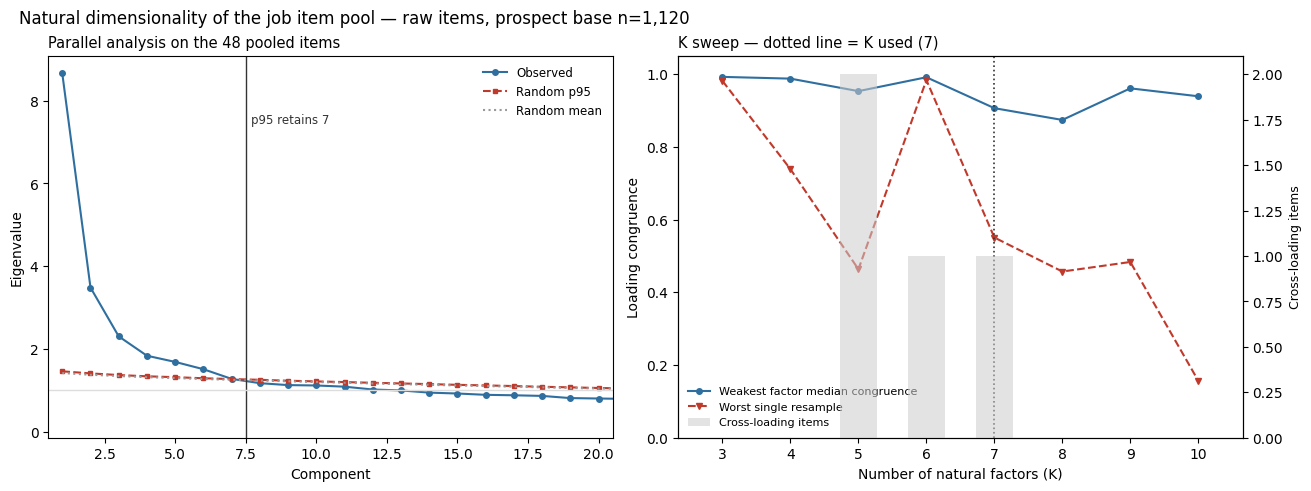

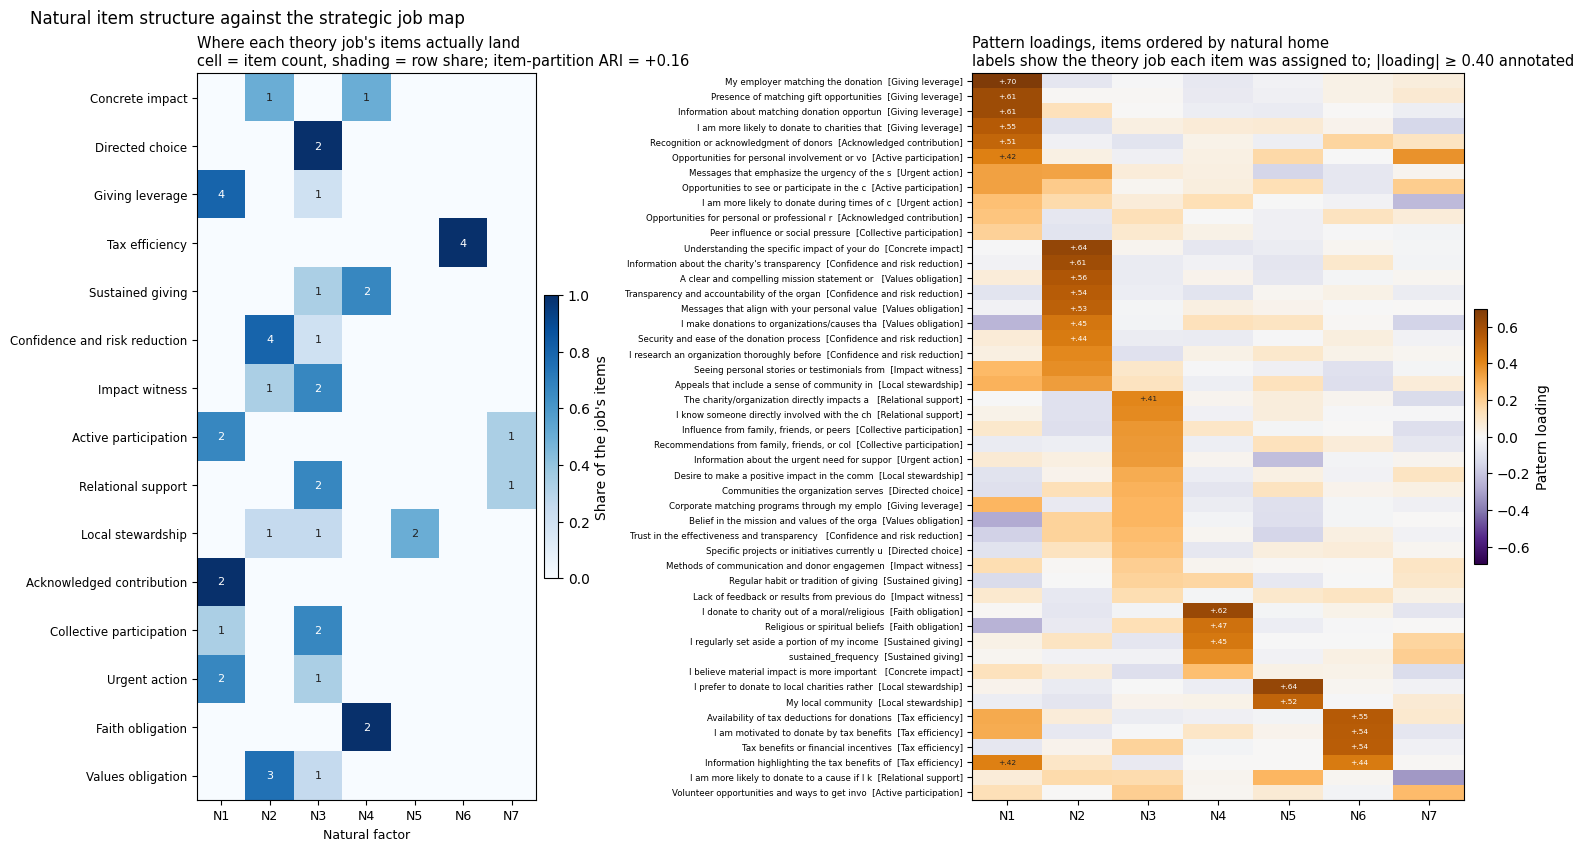

,mean_communality,items_no_salient_loading,items_cross_loading,factors_under_3_salient_items,weakest_factor_median_congruence,worst_single_run_congruence,failed_stability_runs,max_factor_correlation
k,,,,,,,,
3,0.258,29,0,1,0.993,0.981,0,0.57
4,0.283,24,0,1,0.988,0.739,0,0.57
5,0.306,26,2,1,0.953,0.463,0,0.77
6,0.327,24,1,2,0.992,0.984,0,0.66
7,0.341,25,1,3,0.907,0.551,0,0.64
8,0.354,25,0,4,0.874,0.457,0,0.87
9,0.367,24,0,5,0.961,0.483,0,1.21
10,0.379,26,0,7,0.939,0.157,0,1.21


,n_items,n_theory_jobs_represented,modal_theory_job,modal_theory_job_item_share,theory_jobs_contributing_2plus,question_groups,alpha_natural_scale,mean_abs_loading
natural_factor,,,,,,,,
N1,11,5,Giving leverage,36%,Giving leverage | Active participation | Acknowledged contribution | Urgent action,Q3.1 | Q4.1 | Q7.2 | Q8.1 | Q9.1,+0.84,0.43
N2,10,5,Confidence and risk reduction,40%,Confidence and risk reduction | Values obligation,Q3.1 | Q8.1 | Q9.1,+0.84,0.49
N3,14,10,Directed choice,14%,Directed choice | Impact witness | Relational support | Collective participation,Q4.1 | Q5.1 | Q6.2 | Q7.2,+0.62,0.29
N4,5,3,Sustained giving,40%,Sustained giving | Faith obligation,Q2.6 | Q4.1 | Q9.1,+0.61,0.44
N5,2,1,Local stewardship,100%,Local stewardship,Q4.2 | Q9.1,+0.61,0.58
N6,4,1,Tax efficiency,100%,Tax efficiency,Q3.1 | Q4.1 | Q8.1 | Q9.1,+0.78,0.52
N7,2,2,Active participation,50%,—,Q6.2 | Q9.1,+0.13,0.29


,Items (pool / scored),Natural home,Purity,Factors spanned,Alpha as scored,Alpha purified,Gain,Shares factor with,Verdict
Theory job,,,,,,,,,
Concrete impact,2 / 2,N2,50%,2,+0.24,—,—,Confidence and risk reduction | Impact witness | Local stewardship … +1 more,fragmented across 2 factors
Directed choice,2 / 2,N3,100%,1,+0.34,+0.34,+0.00,Collective participation | Confidence and risk reduction | Giving leverage … +6 more,absorbed into N3 with 9 other jobs
Giving leverage,5 / 5,N1,80%,2,+0.81,+0.85,+0.04,Acknowledged contribution | Active participation | Collective participation … +1 more,absorbed into N1 with 4 other jobs
Tax efficiency,4 / 4,N6,100%,1,+0.78,+0.78,+0.00,—,stands alone on N6
Sustained giving,3 / 3,N4,67%,2,+0.47,+0.58,+0.11,Concrete impact | Faith obligation,absorbed into N4 with 2 other jobs
Confidence and risk reduction,5 / 5,N2,80%,2,+0.63,+0.66,+0.04,Concrete impact | Impact witness | Local stewardship … +1 more,absorbed into N2 with 4 other jobs
Impact witness,3 / 3,N3,67%,2,+0.30,+0.27,-0.03,Collective participation | Confidence and risk reduction | Directed choice … +6 more,absorbed into N3 with 9 other jobs
Active participation,3 / 3,N1,67%,2,+0.68,+0.74,+0.06,Acknowledged contribution | Collective participation | Giving leverage … +1 more,absorbed into N1 with 4 other jobs
Relational support,3 / 3,N3,67%,2,+0.40,+0.34,-0.06,Collective participation | Confidence and risk reduction | Directed choice … +6 more,absorbed into N3 with 9 other jobs


,Best theory-job match,|r| best,|r| second,Uniquely represented,Items,Alpha
Natural factor,,,,,,
N1,Giving leverage,0.93,0.65,yes,11,+0.84
N2,Confidence and risk reduction,0.66,0.62,no,10,+0.84
N3,Relational support,0.55,0.54,no,14,+0.62
N4,Faith obligation,0.80,0.60,yes,5,+0.61
N5,Local stewardship,0.71,0.43,yes,2,+0.61
N6,Tax efficiency,0.90,0.36,yes,4,+0.78
N7,Active participation,0.52,0.35,no,2,+0.13


,n,Prevalence,demographics only,theory jobs (15),natural factors (7),theory + demographics,natural + demographics
Education outcome,,,,,,,
current_education_giver,1120,16%,0.602,0.715,0.721,0.703,0.713
education_open_moderate_plus,940,61%,0.721,0.761,0.758,0.774,0.776
direct_teacher,1120,36%,0.616,0.572,0.591,0.620,0.631
after_school,1120,43%,0.606,0.588,0.611,0.620,0.629
scholarship,1120,33%,0.568,0.573,0.583,0.590,0.596
higher_education,1120,17%,0.625,0.663,0.680,0.663,0.678
vocational_adult,1120,21%,0.634,0.606,0.645,0.625,0.653
no_education_interest,1120,13%,0.754,0.780,0.783,0.807,0.813


NATURAL VS STRATEGIC — COMPARISON DIGEST
Item pool: 48 of 48 scored items (0 excluded by Loop-2 eligibility), raw variant, prospect base n=1,120.
Dimensionality: parallel analysis supports 7 factors (p95) / 7 (random mean); the strategy map names 15. K used = 7 via parallel analysis, eigenvalue > random p95.
Item-partition agreement (theory jobs vs natural homes): ARI = +0.161 (0 = no better than chance, 1 = identical). On the priority variant: +0.238. Natural homes agree across variants at ARI +0.121.
Job verdicts: 1 stand alone, 0 share a factor with one other job, 12 absorbed with two or more others, 2 fragmented. Mean purity 76%.
Reliability: mean alpha +0.495 as scored, +0.544 purified, +0.631 for natural scales. Below 0.40: 4 of 15 theory jobs vs 1 of 7 natural factors.
Mean item shared variance with its own scale: theory 0.476 vs natural 0.324.
Natural dimensions the job map does not carry cleanly (no theory job at |r| ≥ 0.70, or two above): 3 of 7.
Cluster separation (eta squar

In [28]:
# ============================================================================
# 3.9  Natural item structure vs the strategic job map
# ----------------------------------------------------------------------------
# Same item pool as the jobs (core_cfg core_score items, eligibility-filtered
# exactly as Loop 2 does). The difference is that nothing here is told which
# job an item belongs to. Items are allowed to group themselves, and the
# resulting "natural" dimensions are then compared against the 15 theory jobs
# on structure, reliability, and downstream usefulness.
#
# IMPORTANT SCOPE LIMIT: "natural" means unsupervised WITHIN this item pool.
# The pool itself is theory-laden — these items were written and retained
# because someone believed they measured these jobs. This cell can show that
# the item map disagrees with the job map; it cannot discover a job that the
# survey never asked about.
#
# Reads Loop-2 frames plus the landed assignments and Zone-3 JOB_FAMILY /
# display helpers. Refits factors only; no reclustering.
#
# The demographic control block is the one place that needs respondent columns
# rather than precomputed scores. Use the engine helper first; retain a frame-local
# rebuild only as a defensive fallback for an unusually altered notebook state.
# ============================================================================
import json

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# --- PARAMS -----------------------------------------------------------------
_NAT_ITEM_VARIANT = 'raw'        # 'raw' (absolute items) | 'priority' (within-question centred)
_NAT_K = None                    # None = use the parallel-analysis p95 retained count
_NAT_K_SWEEP = (3, 4, 5, 6, 7, 8, 9, 10)
_NAT_STABILITY_RUNS = 25         # subsample congruence runs per K in the sweep
_NAT_SALIENT = 0.40              # |pattern loading| at or above this counts as salient
_NAT_CV_FOLDS = 5
_NAT_SEED = JTBD_SEED + 991

_NAT_OUT = OUTPUT_DIR / 'natural_vs_strategic'
_NAT_OUT.mkdir(parents=True, exist_ok=True)

# --- PREFLIGHT --------------------------------------------------------------
_nat_raw_ok = isinstance(globals().get('raw', None), pd.DataFrame)
if not _nat_raw_ok:
    print('PREFLIGHT: global `raw` is not a DataFrame; the demographic block will use its frame-local fallback.')

# ---------------------------------------------------------------------------
# 0. Item pool, and reconciliation against what the job scores actually use
# ---------------------------------------------------------------------------
if _NAT_ITEM_VARIANT == 'raw':
    _nat_items = jtbd_results['latent_raw'].copy()
elif _NAT_ITEM_VARIANT == 'priority':
    _nat_items = jtbd_results['latent_priority'].copy()
else:
    raise ValueError(f'Unknown _NAT_ITEM_VARIANT={_NAT_ITEM_VARIANT!r}')

_nat_idx = _nat_items.index
_nat_features = list(_nat_items.columns)
_nat_n = len(_nat_items)
_nat_p = len(_nat_features)
assert _nat_items.notna().all().all(), 'Latent item matrix carries missing values.'

_nat_cfg = core_cfg.set_index('feature_id')
_nat_theory = {f: _nat_cfg.loc[f, 'job_family'] for f in _nat_features}
_nat_question = {f: _nat_cfg.loc[f, 'question_group'] for f in _nat_features}
_nat_item_text = {
    f: (str(_nat_cfg.loc[f, 'item']) if pd.notna(_nat_cfg.loc[f, 'item']) else f)
    for f in _nat_features
}
_nat_job_label = {j: JTBD_JOB_DOMAIN_LOOKUP[j]['provisional_name'] for j in JTBD_JOBS}

# Items that are inside a scored composite but outside the factor pool.
_nat_scored = core_cfg['feature_id'].tolist()
_nat_excluded = [f for f in _nat_scored if f not in _nat_features]
_nat_audit = jtbd_results['latent_audit'].set_index('feature_id')
_nat_exclusion_rows = [
    {
        'feature_id': f,
        'job_family': _nat_cfg.loc[f, 'job_family'],
        'provisional_name': _nat_job_label[_nat_cfg.loc[f, 'job_family']],
        'exclusion_reason': (
            _nat_audit.loc[f, 'exclusion_reason'] if f in _nat_audit.index else 'not_in_factor_pool'
        ),
    }
    for f in _nat_excluded
]
_nat_exclusions = pd.DataFrame(_nat_exclusion_rows)
_nat_exclusions.to_csv(_NAT_OUT / 'items_scored_but_not_in_factor_pool.csv', index=False)

# ---------------------------------------------------------------------------
# 1. How many dimensions does the item pool actually support
# ---------------------------------------------------------------------------
_nat_parallel = jtbd_results['parallel'].copy()
_nat_k_p95 = int(_nat_parallel['retained_by_p95'].sum())
_nat_k_mean = int((_nat_parallel.observed_eigenvalue > _nat_parallel.random_mean).sum())

_nat_sweep_rows = []
_nat_fits: dict[int, dict] = {}
for _k in _NAT_K_SWEEP:
    if not 2 <= _k <= _nat_p - 1:
        continue
    _fit = jtbd_fit_latent(_nat_items, _k)
    _nat_fits[_k] = _fit
    _load = np.abs(_fit['loadings'])
    _salient = _load >= _NAT_SALIENT
    _stab = jtbd_factor_stability(
        _nat_items, _fit['loadings'], _k, _NAT_STABILITY_RUNS,
        JTBD_STABILITY_FRACTION, _NAT_SEED + 13 * _k,
    )
    _stab_ok = _stab[_stab.status.eq('ok')]
    _per_factor_median = _stab_ok.groupby('factor').congruence.median() if len(_stab_ok) else pd.Series(dtype=float)
    _nat_sweep_rows.append({
        'k': _k,
        'mean_communality': float(_fit['communalities'].mean()),
        'items_no_salient_loading': int((~_salient.any(axis=1)).sum()),
        'items_cross_loading': int((_salient.sum(axis=1) >= 2).sum()),
        'factors_under_3_salient_items': int((_salient.sum(axis=0) < 3).sum()),
        'weakest_factor_median_congruence': float(_per_factor_median.min()) if len(_per_factor_median) else np.nan,
        'worst_single_run_congruence': float(_stab_ok.congruence.min()) if len(_stab_ok) else np.nan,
        'failed_stability_runs': int((~_stab.status.eq('ok')).sum()),
        'max_factor_correlation': float(
            np.abs(_fit['phi'] - np.eye(_k)).max()
        ),
    })
_nat_sweep = pd.DataFrame(_nat_sweep_rows).set_index('k')
_nat_sweep.to_csv(_NAT_OUT / 'natural_dimensionality_sweep.csv')

_NAT_K_USED = int(_NAT_K) if _NAT_K is not None else _nat_k_p95
if _NAT_K_USED not in _nat_fits:
    _nat_fits[_NAT_K_USED] = jtbd_fit_latent(_nat_items, _NAT_K_USED)
assert 2 <= _NAT_K_USED <= _nat_p - 1, f'Unusable natural K={_NAT_K_USED}'
_nat_k_rule = 'analyst override' if _NAT_K is not None else 'parallel analysis, eigenvalue > random p95'

# ---------------------------------------------------------------------------
# 2. The natural solution and its simple structure
# ---------------------------------------------------------------------------
_nat_fit = dict(_nat_fits[_NAT_K_USED])
# Factor sign is arbitrary in EFA; orient each so its loadings read positive.
_nat_signs = np.where(_nat_fit['loadings'].sum(axis=0) < 0, -1.0, 1.0)
_nat_fit['loadings'] = _nat_fit['loadings'] * _nat_signs
_nat_fit['scores'] = _nat_fit['scores'] * _nat_signs
_nat_fit['phi'] = np.diag(_nat_signs) @ _nat_fit['phi'] @ np.diag(_nat_signs)
_nat_factor_names = [f'N{i}' for i in range(1, _NAT_K_USED + 1)]
_nat_loadings = pd.DataFrame(_nat_fit['loadings'], index=_nat_features, columns=_nat_factor_names)
_nat_loadings.to_csv(_NAT_OUT / 'natural_pattern_loadings.csv')
_nat_phi = pd.DataFrame(_nat_fit['phi'], index=_nat_factor_names, columns=_nat_factor_names)
_nat_phi.to_csv(_NAT_OUT / 'natural_factor_correlations.csv')

_nat_scores = pd.DataFrame(_nat_fit['scores'], index=_nat_idx, columns=_nat_factor_names)
_nat_scores_z = jtbd_standardize_completed_scores(_nat_scores)

_nat_abs_load = _nat_loadings.abs()
_nat_home = _nat_abs_load.idxmax(axis=1)                       # natural home = strongest pattern loading
_nat_home_value = _nat_abs_load.max(axis=1)
_nat_salient_n = (_nat_abs_load >= _NAT_SALIENT).sum(axis=1)
_nat_second = _nat_abs_load.apply(lambda r: r.sort_values(ascending=False).iloc[1], axis=1)

_nat_item_map = pd.DataFrame({
    'feature_id': _nat_features,
    'item': [_nat_item_text[f] for f in _nat_features],
    'question_group': [_nat_question[f] for f in _nat_features],
    'theory_job': [_nat_theory[f] for f in _nat_features],
    'theory_job_name': [_nat_job_label[_nat_theory[f]] for f in _nat_features],
    'theory_family': [JOB_FAMILY[_nat_theory[f]] for f in _nat_features],
    'natural_home': _nat_home.to_numpy(),
    'primary_loading': [float(_nat_loadings.loc[f, _nat_home[f]]) for f in _nat_features],
    'primary_abs_loading': _nat_home_value.to_numpy(),
    'second_abs_loading': _nat_second.to_numpy(),
    'loading_gap': (_nat_home_value - _nat_second).to_numpy(),
    'salient_factor_count': _nat_salient_n.to_numpy(),
    'communality': _nat_fit['communalities'],
}).set_index('feature_id')
_nat_item_map['structure_flag'] = np.where(
    _nat_item_map.salient_factor_count.eq(0), 'no_salient_loading',
    np.where(_nat_item_map.salient_factor_count.ge(2), 'cross_loading', 'clean'),
)
_nat_item_map.to_csv(_NAT_OUT / 'natural_item_assignment.csv')

# ---------------------------------------------------------------------------
# 3. Natural factor cards, described by the theory items that landed in them
# ---------------------------------------------------------------------------
_nat_factor_rows = []
for _f in _nat_factor_names:
    _members = _nat_item_map.index[_nat_item_map.natural_home.eq(_f)].tolist()
    _member_jobs = pd.Series([_nat_theory[m] for m in _members])
    _job_counts = _member_jobs.value_counts()
    _defining = (
        _nat_loadings.loc[_members, _f]
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(5)
    )
    _nat_factor_rows.append({
        'natural_factor': _f,
        'n_items': len(_members),
        'n_theory_jobs_represented': int(_member_jobs.nunique()) if len(_members) else 0,
        'modal_theory_job': _nat_job_label[_job_counts.index[0]] if len(_job_counts) else '—',
        'modal_theory_job_item_share': float(_job_counts.iloc[0] / len(_members)) if len(_members) else np.nan,
        'theory_jobs_contributing_2plus': ' | '.join(
            _nat_job_label[j] for j, c in _job_counts.items() if c >= 2
        ) or '—',
        'question_groups': ' | '.join(sorted({_nat_question[m] for m in _members})) or '—',
        'alpha_natural_scale': standardized_alpha(_nat_items[_members]) if len(_members) >= 2 else np.nan,
        'mean_abs_loading': float(_nat_abs_load.loc[_members, _f].mean()) if len(_members) else np.nan,
        'defining_items': ' | '.join(
            f'{_nat_item_text[i]} [{_nat_job_label[_nat_theory[i]]}] ({v:+.2f})'
            for i, v in _defining.items()
        ),
    })
_nat_factor_cards = pd.DataFrame(_nat_factor_rows).set_index('natural_factor')
_nat_factor_cards.to_csv(_NAT_OUT / 'natural_factor_cards.csv')

# ---------------------------------------------------------------------------
# 4. Crosswalk: does the item map agree with the job map
# ---------------------------------------------------------------------------
_nat_cross = pd.crosstab(
    pd.Series([_nat_theory[f] for f in _nat_features], index=_nat_features, name='theory_job'),
    _nat_item_map.natural_home.rename('natural_factor'),
).reindex(index=[j for j in JTBD_JOBS if j in set(_nat_theory.values())],
          columns=_nat_factor_names, fill_value=0)
_nat_cross.index = [_nat_job_label[j] for j in _nat_cross.index]
_nat_cross.to_csv(_NAT_OUT / 'theory_job_by_natural_factor_items.csv')

_nat_theory_codes = pd.Series([_nat_theory[f] for f in _nat_features]).astype('category').cat.codes
_nat_home_codes = _nat_item_map.natural_home.astype('category').cat.codes.to_numpy()
_nat_partition_ari = float(adjusted_rand_score(_nat_theory_codes, _nat_home_codes))

_nat_job_rows = []
for _job in JTBD_JOBS:
    _own = [f for f in _nat_features if _nat_theory[f] == _job]
    if not _own:
        _nat_job_rows.append({
            'job_family': _job, 'provisional_name': _nat_job_label[_job],
            'items_in_factor_pool': 0, 'items_scored': int((core_cfg.job_family == _job).sum()),
            'dominant_natural_factor': '—', 'purity': np.nan, 'n_natural_factors_spanned': 0,
            'alpha_as_scored': np.nan, 'alpha_purified': np.nan, 'items_dropped_for_purity': 0,
            'shares_factor_with': '—', 'verdict': 'no eligible items',
        })
        continue
    _homes = pd.Series([_nat_home[f] for f in _own])
    _counts = _homes.value_counts()
    _dominant = _counts.index[0]
    _purity = float(_counts.iloc[0] / len(_own))
    _pure_items = [f for f in _own if _nat_home[f] == _dominant]
    _alpha_scored = standardized_alpha(_nat_items[_own]) if len(_own) >= 2 else np.nan
    _alpha_pure = standardized_alpha(_nat_items[_pure_items]) if len(_pure_items) >= 2 else np.nan
    _shares_with = sorted({
        _nat_job_label[_nat_theory[g]]
        for g in _nat_features
        if _nat_home[g] == _dominant and _nat_theory[g] != _job
    })
    if _purity < 0.60:
        _verdict = f'fragmented across {_homes.nunique()} factors'
    elif len(_shares_with) >= 2:
        _verdict = f'absorbed into {_dominant} with {len(_shares_with)} other jobs'
    elif len(_shares_with) == 1:
        _verdict = f'shares {_dominant} with {_shares_with[0]}'
    else:
        _verdict = f'stands alone on {_dominant}'
    _nat_job_rows.append({
        'job_family': _job,
        'provisional_name': _nat_job_label[_job],
        'items_in_factor_pool': len(_own),
        'items_scored': int((core_cfg.job_family == _job).sum()),
        'dominant_natural_factor': _dominant,
        'purity': _purity,
        'n_natural_factors_spanned': int(_homes.nunique()),
        'alpha_as_scored': _alpha_scored,
        'alpha_purified': _alpha_pure,
        'items_dropped_for_purity': len(_own) - len(_pure_items),
        'shares_factor_with': ' | '.join(_shares_with) or '—',
        'verdict': _verdict,
    })
_nat_job_diag = pd.DataFrame(_nat_job_rows).set_index('job_family')
_nat_job_diag['alpha_gain_from_purifying'] = _nat_job_diag.alpha_purified - _nat_job_diag.alpha_as_scored
_nat_job_diag.to_csv(_NAT_OUT / 'theory_job_structure_diagnosis.csv')

# ---------------------------------------------------------------------------
# 5. Score-space correspondence: theory job scores vs natural factor scores
# ---------------------------------------------------------------------------
_nat_theory_scores = jtbd_results['score_table'].loc[
    _nat_idx, [f'absolute__{j}' for j in JTBD_JOBS]
].copy()
_nat_theory_scores.columns = list(JTBD_JOBS)
if _NAT_ITEM_VARIANT == 'priority':
    _nat_theory_scores = jtbd_results['score_table'].loc[
        _nat_idx, [f'priority__{j}' for j in JTBD_JOBS]
    ].copy()
    _nat_theory_scores.columns = list(JTBD_JOBS)

_nat_corr_map = pd.DataFrame(index=_nat_factor_names, columns=list(JTBD_JOBS), dtype=float)
for _f in _nat_factor_names:
    for _job in JTBD_JOBS:
        _nat_corr_map.loc[_f, _job] = safe_spearman(_nat_scores[_f], _nat_theory_scores[_job])
_nat_corr_map.columns = [_nat_job_label[j] for j in JTBD_JOBS]
_nat_corr_map.to_csv(_NAT_OUT / 'natural_factor_by_theory_job_score_correlations.csv')

_nat_factor_best = pd.DataFrame({
    'best_theory_job': _nat_corr_map.abs().idxmax(axis=1),
    'best_abs_r': _nat_corr_map.abs().max(axis=1),
    'second_abs_r': _nat_corr_map.abs().apply(lambda r: r.sort_values(ascending=False).iloc[1], axis=1),
})
_nat_factor_best['uniquely_represented'] = (
    _nat_factor_best.best_abs_r.ge(0.70) & _nat_factor_best.second_abs_r.lt(0.70)
)
_nat_job_best = pd.DataFrame({
    'best_natural_factor': _nat_corr_map.abs().idxmax(axis=0),
    'best_abs_r': _nat_corr_map.abs().max(axis=0),
})
_nat_factor_best.to_csv(_NAT_OUT / 'natural_factor_best_theory_match.csv')
_nat_job_best.to_csv(_NAT_OUT / 'theory_job_best_natural_match.csv')

# Shared-variance accounting: how much of each item does its own scale carry.
def _nat_item_scale_r2(item_matrix, assignment, scale_scores):
    _rows = []
    for _feature in item_matrix.columns:
        _scale = assignment[_feature]
        _r = safe_spearman(item_matrix[_feature], scale_scores[_scale])
        _rows.append({'feature_id': _feature, 'scale': _scale, 'r': _r, 'r2': _r ** 2 if pd.notna(_r) else np.nan})
    return pd.DataFrame(_rows).set_index('feature_id')


_nat_r2_natural = _nat_item_scale_r2(_nat_items, _nat_home.to_dict(), _nat_scores)
_nat_r2_theory = _nat_item_scale_r2(_nat_items, _nat_theory, _nat_theory_scores)
_nat_r2_natural.to_csv(_NAT_OUT / 'item_shared_variance_natural.csv')
_nat_r2_theory.to_csv(_NAT_OUT / 'item_shared_variance_theory.csv')

# ---------------------------------------------------------------------------
# 6. Downstream comparison: cluster separation and education receptivity
# ---------------------------------------------------------------------------
_nat_cluster_by_id = selected_assignments.set_index(ID_COL)['persona_cluster']
_nat_cluster = _nat_cluster_by_id.reindex(jtbd_retained.loc[_nat_idx, ID_COL]).to_numpy()
assert not pd.isna(_nat_cluster).any(), 'Cluster label missing for a prospect in the factor pool.'


def _nat_eta_sq(values, groups):
    _s = pd.Series(np.asarray(values, dtype=float))
    _g = pd.Series(np.asarray(groups))
    _ok = _s.notna() & _g.notna()
    _s, _g = _s[_ok], _g[_ok]
    if _s.nunique() < 2:
        return np.nan
    _grand = _s.mean()
    _sst = float(((_s - _grand) ** 2).sum())
    if _sst <= 0:
        return np.nan
    _ssb = float(sum(len(_v) * (_v.mean() - _grand) ** 2 for _, _v in _s.groupby(_g.to_numpy())))
    return _ssb / _sst


_nat_sep_rows = []
for _scheme, _frame in [('natural', _nat_scores), ('theory', _nat_theory_scores)]:
    for _dim in _frame.columns:
        _nat_sep_rows.append({
            'scheme': _scheme,
            'dimension': _dim if _scheme == 'natural' else _nat_job_label[_dim],
            'eta_squared_vs_clusters': _nat_eta_sq(_frame[_dim].to_numpy(), _nat_cluster),
        })
_nat_separation = pd.DataFrame(_nat_sep_rows)
_nat_separation.to_csv(_NAT_OUT / 'cluster_separation_by_dimension.csv', index=False)
_nat_sep_summary = _nat_separation.groupby('scheme').eta_squared_vs_clusters.agg(
    dimensions='count', max_eta_sq='max', mean_eta_sq='mean', median_eta_sq='median',
)

def _nat_demographic_matrix(frame):
    """Frame-local rebuild of the engine's demographic matrix.

    Same construction as jtbd_demographic_matrix (median-filled standardized age,
    any-children-at-home flag, dummy-coded gender and income with the first level
    dropped), except every column is resolved against `frame` instead of the
    global `raw`, and missing columns are skipped rather than raising.
    """
    _demo = pd.DataFrame(index=frame.index)

    if AGE_COL in frame.columns:
        _age = pd.to_numeric(frame[AGE_COL], errors='coerce')
        if _age.notna().any():
            _age = _age.fillna(_age.median())
            _age_sd = _age.std()
            _demo['age'] = (_age - _age.mean()) / (_age_sd if _age_sd else 1.0)

    _child_columns = [
        f'{CHILDREN_QUESTION} - {_band}'
        for _band in ('Children 12 years old or younger', 'Children between 13-18 years old')
        if f'{CHILDREN_QUESTION} - {_band}' in frame.columns
    ]
    if _child_columns:
        _demo['children_at_home'] = frame[_child_columns].notna().any(axis=1).astype(float)

    _cat_columns = [_c for _c in (GENDER_COL, INCOME_COL) if _c in frame.columns]
    if _cat_columns:
        _demo = pd.concat([
            _demo,
            pd.get_dummies(
                frame[_cat_columns].fillna('Missing').astype(str),
                prefix=['gender' if _c == GENDER_COL else 'income' for _c in _cat_columns],
                drop_first=True,
                dtype=float,
            ),
        ], axis=1)

    if _demo.shape[1]:
        _demo = _demo.loc[:, _demo.nunique(dropna=False).gt(1)]
    return _demo.astype(float)


try:
    _nat_demo_full = jtbd_demographic_matrix(jtbd_prospects)
    _nat_demo_source = 'engine jtbd_demographic_matrix'
except Exception as _nat_demo_exc:                       # noqa: BLE001 - reported, not swallowed
    _nat_demo_full = _nat_demographic_matrix(jtbd_prospects)
    _nat_demo_source = (
        f'local frame-resolved rebuild after {type(_nat_demo_exc).__name__} '
        f'from the engine helper: {_nat_demo_exc}'
    )

_nat_demo = _nat_demo_full.loc[_nat_idx]
_nat_demo_usable = bool(_nat_demo.shape[1])
if not _nat_demo_usable:
    print('NOTE: no usable demographic columns were found, so the demographic control blocks are skipped. '
          'The theory-vs-natural comparison is unaffected.')
_nat_edu = jtbd_results['education_outcomes'].loc[_nat_idx]
_nat_outcomes = [
    'current_education_giver', 'education_open_moderate_plus', 'direct_teacher',
    'after_school', 'scholarship', 'higher_education', 'vocational_adult', 'no_education_interest',
]


def _nat_cv_auc(X, y, folds, seed):
    _X = np.asarray(X, dtype=float)
    _y = np.asarray(y, dtype=int)
    if len(np.unique(_y)) < 2 or int(np.bincount(_y).min()) < folds:
        return np.nan
    _skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    _aucs = []
    for _tr, _te in _skf.split(_X, _y):
        if len(np.unique(_y[_te])) < 2:
            continue
        # Reuse the engine's own model configuration so this comparison tracks jtbd_fit_logistic.
        _scaler = StandardScaler().fit(_X[_tr])
        _model = jtbd_fit_logistic(
            pd.DataFrame(_scaler.transform(_X[_tr])), pd.Series(_y[_tr]), seed
        )
        _aucs.append(roc_auc_score(_y[_te], _model.predict_proba(_scaler.transform(_X[_te]))[:, 1]))
    return float(np.mean(_aucs)) if _aucs else np.nan


_nat_pred_rows = []
for _outcome in _nat_outcomes:
    _y_full = pd.to_numeric(_nat_edu[_outcome], errors='coerce')
    _avail = _y_full.notna()
    _y = _y_full[_avail].astype(int)
    if _y.nunique() < 2:
        continue
    _blocks = {
        f'theory jobs ({len(JTBD_JOBS)})': _nat_theory_scores.loc[_avail],
        f'natural factors ({_NAT_K_USED})': _nat_scores.loc[_avail],
    }
    if _nat_demo_usable:
        _blocks = {
            'demographics only': _nat_demo.loc[_avail],
            **_blocks,
            'theory + demographics': pd.concat(
                [_nat_theory_scores.loc[_avail], _nat_demo.loc[_avail]], axis=1),
            'natural + demographics': pd.concat(
                [_nat_scores.loc[_avail], _nat_demo.loc[_avail]], axis=1),
        }
    _row = {'outcome': _outcome, 'n': int(len(_y)), 'prevalence': float(_y.mean())}
    for _name, _X in _blocks.items():
        _row[_name] = _nat_cv_auc(_X, _y, _NAT_CV_FOLDS, _NAT_SEED)
        _row[f'{_name} :: n_predictors'] = int(_X.shape[1])
    _nat_pred_rows.append(_row)
_nat_prediction = pd.DataFrame(_nat_pred_rows).set_index('outcome')
_nat_prediction.to_csv(_NAT_OUT / 'education_outcome_cv_auc.csv')

_nat_auc_cols = [c for c in _nat_prediction.columns if '::' not in c and c not in {'n', 'prevalence'}]
_nat_auc_summary = _nat_prediction[_nat_auc_cols].mean()

# ---------------------------------------------------------------------------
# 7. Robustness: does the other item variant change the verdict
# ---------------------------------------------------------------------------
_nat_alt_variant = 'priority' if _NAT_ITEM_VARIANT == 'raw' else 'raw'
_nat_alt_items = jtbd_results['latent_priority' if _nat_alt_variant == 'priority' else 'latent_raw'][_nat_features]
_nat_alt_fit = jtbd_fit_latent(_nat_alt_items, _NAT_K_USED)
_nat_alt_load = pd.DataFrame(np.abs(_nat_alt_fit['loadings']), index=_nat_features, columns=_nat_factor_names)
_nat_alt_home = _nat_alt_load.idxmax(axis=1)
_nat_alt_ari = float(adjusted_rand_score(
    _nat_theory_codes, _nat_alt_home.astype('category').cat.codes.to_numpy()
))
_nat_variant_ari = float(adjusted_rand_score(
    _nat_home_codes, _nat_alt_home.astype('category').cat.codes.to_numpy()
))

# ---------------------------------------------------------------------------
# 8. Figures
# ---------------------------------------------------------------------------
_fig_n1, _axn = plt.subplots(1, 2, figsize=(13.0, 4.8), layout='constrained')

_ax = _axn[0]
_comp = _nat_parallel['component'].to_numpy()
_ax.plot(_comp, _nat_parallel.observed_eigenvalue, 'o-', color='#2f6f9f', ms=4, label='Observed')
_ax.plot(_comp, _nat_parallel.random_p95, 's--', color='#c0392b', ms=3.5, label='Random p95')
_ax.plot(_comp, _nat_parallel.random_mean, ':', color='#999999', label='Random mean')
_ax.axvline(_nat_k_p95 + 0.5, color='#333333', ls='-', lw=1.0)
_ax.text(_nat_k_p95 + 0.7, _ax.get_ylim()[1] * 0.82,
         f'p95 retains {_nat_k_p95}', fontsize=8.5, color='#333333')
_ax.axhline(1.0, color='#dddddd', lw=1.0)
_ax.set_xlim(0.5, min(len(_comp), 20) + 0.5)
_ax.set_xlabel('Component')
_ax.set_ylabel('Eigenvalue')
_ax.set_title(f'Parallel analysis on the {_nat_p} pooled items', fontsize=10.5, loc='left')
_ax.legend(fontsize=8.5, frameon=False)

_ax = _axn[1]
_ax.plot(_nat_sweep.index, _nat_sweep.weakest_factor_median_congruence, 'o-',
         color='#2f6f9f', ms=4, label='Weakest factor median congruence')
_ax.plot(_nat_sweep.index, _nat_sweep.worst_single_run_congruence, 'v--',
         color='#c0392b', ms=4, label='Worst single resample')
_ax2 = _ax.twinx()
_ax2.bar(_nat_sweep.index, _nat_sweep.items_cross_loading, color='#cccccc', alpha=0.55, width=0.55,
         label='Cross-loading items')
_ax2.set_ylabel('Cross-loading items', fontsize=9)
_ax.axvline(_NAT_K_USED, color='#333333', ls=':', lw=1.2)
_ax.set_xlabel('Number of natural factors (K)')
_ax.set_ylabel('Loading congruence')
_ax.set_ylim(0, 1.05)
_ax.set_title(f'K sweep — dotted line = K used ({_NAT_K_USED})', fontsize=10.5, loc='left')
_h1, _l1 = _ax.get_legend_handles_labels()
_h2, _l2 = _ax2.get_legend_handles_labels()
_ax.legend(_h1 + _h2, _l1 + _l2, fontsize=8, frameon=False, loc='lower left')
_fig_n1.suptitle(
    f'Natural dimensionality of the job item pool — {_NAT_ITEM_VARIANT} items, '
    f'prospect base n={_nat_n:,}', fontsize=12, x=0.01, ha='left',
)
_fig_n1.savefig(_NAT_OUT / 'natural_dimensionality.png', dpi=170, bbox_inches='tight')
plt.show()

_fig_n2 = plt.figure(figsize=(15.4, 8.4), layout='constrained')
_gsn = _fig_n2.add_gridspec(1, 2, width_ratios=[1.0, 1.25])

_axc = _fig_n2.add_subplot(_gsn[0, 0])
_cross_share = _nat_cross.div(_nat_cross.sum(axis=1).replace(0, np.nan), axis=0)
_imc = _axc.imshow(_cross_share.to_numpy(dtype=float), cmap='Blues', vmin=0, vmax=1)
_axc.set_xticks(range(_NAT_K_USED), _nat_factor_names, fontsize=9)
_axc.set_yticks(range(len(_nat_cross)), _nat_cross.index, fontsize=8.5)
for _i in range(_nat_cross.shape[0]):
    for _j in range(_nat_cross.shape[1]):
        _c = int(_nat_cross.iat[_i, _j])
        if _c == 0:
            continue
        _sh = float(_cross_share.iat[_i, _j])
        _axc.text(_j, _i, f'{_c}', ha='center', va='center', fontsize=8,
                  color='white' if _sh > 0.55 else '#222222')
_axc.set_xlabel('Natural factor', fontsize=9)
_axc.set_title(
    'Where each theory job\'s items actually land\n'
    f'cell = item count, shading = row share; item-partition ARI = {_nat_partition_ari:+.2f}',
    fontsize=10.5, loc='left',
)
_fig_n2.colorbar(_imc, ax=_axc, fraction=0.036, pad=0.02, label='Share of the job\'s items')

_axl = _fig_n2.add_subplot(_gsn[0, 1])
_load_order = (
    _nat_item_map.assign(_home_rank=[_nat_factor_names.index(h) for h in _nat_item_map.natural_home])
    .sort_values(['_home_rank', 'primary_abs_loading'], ascending=[True, False])
    .index.tolist()
)
_load_plot = _nat_loadings.loc[_load_order]
_ll = max(0.40, float(np.abs(_load_plot.to_numpy()).max()))
_iml = _axl.imshow(_load_plot.to_numpy(), cmap='PuOr_r', aspect='auto',
                   norm=TwoSlopeNorm(vmin=-_ll, vcenter=0.0, vmax=_ll))
_axl.set_xticks(range(_NAT_K_USED), _nat_factor_names, fontsize=9)
_axl.set_yticks(
    range(len(_load_order)),
    [f'{_nat_item_text[f][:44]}  [{_nat_job_label[_nat_theory[f]]}]' for f in _load_order],
    fontsize=6.2,
)
for _i, _f in enumerate(_load_order):
    for _j, _fac in enumerate(_nat_factor_names):
        _v = float(_nat_loadings.loc[_f, _fac])
        if abs(_v) < _NAT_SALIENT:
            continue
        _axl.text(_j, _i, f'{_v:+.2f}'.replace('0.', '.'), ha='center', va='center',
                  fontsize=5.4, color='white' if abs(_v) > 0.62 * _ll else '#222222')
_axl.set_title(
    'Pattern loadings, items ordered by natural home\n'
    f'labels show the theory job each item was assigned to; |loading| ≥ {_NAT_SALIENT:.2f} annotated',
    fontsize=10.5, loc='left',
)
_fig_n2.colorbar(_iml, ax=_axl, fraction=0.026, pad=0.02, label='Pattern loading')
_fig_n2.suptitle('Natural item structure against the strategic job map', fontsize=12, x=0.01, ha='left')
_fig_n2.savefig(_NAT_OUT / 'natural_vs_strategic_structure.png', dpi=170, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# 9. Displays
# ---------------------------------------------------------------------------
_show_table(
    _nat_sweep.assign(
        mean_communality=lambda d: d.mean_communality.map('{:.3f}'.format),
        weakest_factor_median_congruence=lambda d: d.weakest_factor_median_congruence.map('{:.3f}'.format),
        worst_single_run_congruence=lambda d: d.worst_single_run_congruence.map('{:.3f}'.format),
        max_factor_correlation=lambda d: d.max_factor_correlation.map('{:.2f}'.format),
    ),
    'NATURAL DIMENSIONALITY SWEEP',
    f'{_nat_p} pooled items, {_nat_n:,} prospects, {_NAT_ITEM_VARIANT} variant, '
    f'{_NAT_STABILITY_RUNS} subsample runs per K at {JTBD_STABILITY_FRACTION:.0%}. '
    f'Parallel analysis retains {_nat_k_p95} factors against the random p95 and {_nat_k_mean} against the '
    f'random mean. K used here = {_NAT_K_USED} ({_nat_k_rule}). '
    'Congruence from 80% subsamples against the full-data reference is a weak test by construction; '
    'read the worst-single-run column, not the median.',
)

_nat_cards_display = _nat_factor_cards.assign(
    modal_theory_job_item_share=lambda d: d.modal_theory_job_item_share.map('{:.0%}'.format),
    alpha_natural_scale=lambda d: d.alpha_natural_scale.map('{:+.2f}'.format),
    mean_abs_loading=lambda d: d.mean_abs_loading.map('{:.2f}'.format),
)[['n_items', 'n_theory_jobs_represented', 'modal_theory_job', 'modal_theory_job_item_share',
   'theory_jobs_contributing_2plus', 'question_groups', 'alpha_natural_scale', 'mean_abs_loading']]
_show_table(
    _nat_cards_display,
    'NATURAL FACTORS — WHAT THE ITEMS SAY WITHOUT THE JOB LABELS',
    'Each row is a dimension the item pool produced on its own. "Theory jobs contributing 2+" names the '
    'jobs that this one dimension absorbed. Where that column lists several jobs, the strategy map is '
    'splitting one measured construct into several named jobs. Alpha is over the items whose strongest '
    'loading is on that factor.',
)

_show_table(
    pd.DataFrame({
        'Items (pool / scored)': [
            f"{int(r.items_in_factor_pool)} / {int(r.items_scored)}" for r in _nat_job_diag.itertuples()
        ],
        'Natural home': _nat_job_diag.dominant_natural_factor.to_numpy(),
        'Purity': [f'{v:.0%}' if pd.notna(v) else '—' for v in _nat_job_diag.purity],
        'Factors spanned': _nat_job_diag.n_natural_factors_spanned.to_numpy(),
        'Alpha as scored': [f'{v:+.2f}' if pd.notna(v) else '—' for v in _nat_job_diag.alpha_as_scored],
        'Alpha purified': [f'{v:+.2f}' if pd.notna(v) else '—' for v in _nat_job_diag.alpha_purified],
        'Gain': [
            f'{v:+.2f}' if pd.notna(v) else '—' for v in _nat_job_diag.alpha_gain_from_purifying
        ],
        'Shares factor with': [
            _s if len(_s.split(' | ')) <= 3
            else ' | '.join(_s.split(' | ')[:3]) + f' … +{len(_s.split(" | ")) - 3} more'
            for _s in _nat_job_diag.shares_factor_with.fillna('—')
        ],
        'Verdict': _nat_job_diag.verdict.to_numpy(),
    }, index=_nat_job_diag.provisional_name.to_numpy()).rename_axis(index='Theory job'),
    'THEORY JOBS DIAGNOSED AGAINST THE NATURAL STRUCTURE',
    'The natural factors were fit on these same respondents, so their reliability is optimistic by '
    'construction while the theory map paid no such fitting cost. Read the alpha comparison as an upper '
    'bound on the gap, and use the cross-validated AUC below for the honest version. '
    'Purity = share of the job\'s pooled items whose strongest loading sits on the same natural factor. '
    '"Alpha purified" drops the job\'s off-factor items, so "Gain" is the reliability currently being paid '
    'away to keep the job definition intact. A job that stands alone on its own factor is corroborated; '
    'a fragmented or absorbed job is a naming decision rather than a measured construct.',
)

_show_table(
    pd.DataFrame({
        'Best theory-job match': _nat_factor_best.best_theory_job.to_numpy(),
        '|r| best': [f'{v:.2f}' for v in _nat_factor_best.best_abs_r],
        '|r| second': [f'{v:.2f}' for v in _nat_factor_best.second_abs_r],
        'Uniquely represented': np.where(_nat_factor_best.uniquely_represented, 'yes', 'no'),
        'Items': _nat_factor_cards.loc[_nat_factor_best.index, 'n_items'].to_numpy(),
        'Alpha': [f'{v:+.2f}' for v in _nat_factor_cards.loc[_nat_factor_best.index, 'alpha_natural_scale']],
    }, index=_nat_factor_best.index).rename_axis(index='Natural factor'),
    'DOES THE STRATEGY MAP CARRY EACH NATURAL DIMENSION',
    'A natural factor with no theory job above |r| 0.70 is a real dimension the job map does not '
    'represent cleanly. A factor whose top two matches are both above 0.70 is one dimension that the '
    'job map has split in two.',
)

_show_table(
    pd.DataFrame({
        'n': _nat_prediction.n.to_numpy(),
        'Prevalence': [f'{v:.0%}' for v in _nat_prediction.prevalence],
        **{
            _c: [f'{v:.3f}' if pd.notna(v) else '—' for v in _nat_prediction[_c]]
            for _c in _nat_auc_cols
        },
    }, index=_nat_prediction.index).rename_axis(index='Education outcome'),
    'DOWNSTREAM TEST — CROSS-VALIDATED AUC ON EDUCATION RECEPTIVITY',
    f'{_NAT_CV_FOLDS}-fold stratified CV, L2 logistic, features standardized inside each fold. '
    f'Predictor counts differ ({len(JTBD_JOBS)} theory scores vs {_NAT_K_USED} natural factors), which '
    'favours the wider block; cross-validation penalizes that but does not erase it. Read the gap, not '
    'the third decimal. This is the notebook\'s own downstream use, so it is the fairest single test of '
    'whether the forcing costs anything that matters.',
)

# ---------------------------------------------------------------------------
# 10. Comparison digest
# ---------------------------------------------------------------------------
_nat_digest = {
    'item_variant': _NAT_ITEM_VARIANT,
    'raw_export_healthy': bool(_nat_raw_ok),
    'demographic_block_source': _nat_demo_source,
    'demographic_predictors': int(_nat_demo.shape[1]),
    'prospect_n': int(_nat_n),
    'items_in_factor_pool': int(_nat_p),
    'items_scored_total': int(len(_nat_scored)),
    'items_scored_but_excluded_from_pool': int(len(_nat_excluded)),
    'theory_dimensions': int(len(JTBD_JOBS)),
    'parallel_k_p95': _nat_k_p95,
    'parallel_k_random_mean': _nat_k_mean,
    'natural_k_used': _NAT_K_USED,
    'natural_k_rule': _nat_k_rule,
    'item_partition_ari_theory_vs_natural': round(_nat_partition_ari, 4),
    'item_partition_ari_alt_variant': round(_nat_alt_ari, 4),
    'natural_home_agreement_across_variants_ari': round(_nat_variant_ari, 4),
    'jobs_standing_alone': int(_nat_job_diag.verdict.str.startswith('stands alone').sum()),
    'jobs_fragmented': int(_nat_job_diag.verdict.str.startswith('fragmented').sum()),
    'jobs_absorbed': int(_nat_job_diag.verdict.str.startswith('absorbed').sum()),
    'jobs_sharing_a_factor_pairwise': int(_nat_job_diag.verdict.str.startswith('shares').sum()),
    'mean_job_purity': round(float(_nat_job_diag.purity.mean()), 4),
    'mean_alpha_theory_as_scored': round(float(_nat_job_diag.alpha_as_scored.mean()), 4),
    'mean_alpha_theory_purified': round(float(_nat_job_diag.alpha_purified.mean()), 4),
    'mean_alpha_natural_scales': round(float(_nat_factor_cards.alpha_natural_scale.mean()), 4),
    'theory_scales_below_alpha_0.40': int((_nat_job_diag.alpha_as_scored < 0.40).sum()),
    'natural_scales_below_alpha_0.40': int((_nat_factor_cards.alpha_natural_scale < 0.40).sum()),
    'mean_item_shared_variance_theory': round(float(_nat_r2_theory.r2.mean()), 4),
    'mean_item_shared_variance_natural': round(float(_nat_r2_natural.r2.mean()), 4),
    'natural_factors_not_uniquely_represented': int((~_nat_factor_best.uniquely_represented).sum()),
    'cluster_separation_max_eta_sq': {
        k: round(float(v), 4) for k, v in _nat_sep_summary.max_eta_sq.items()
    },
    'cluster_separation_mean_eta_sq': {
        k: round(float(v), 4) for k, v in _nat_sep_summary.mean_eta_sq.items()
    },
    'mean_cv_auc_by_block': {k: round(float(v), 4) for k, v in _nat_auc_summary.items()},
    'items_no_salient_loading': int(_nat_item_map.structure_flag.eq('no_salient_loading').sum()),
    'items_cross_loading': int(_nat_item_map.structure_flag.eq('cross_loading').sum()),
    'max_natural_factor_intercorrelation': round(
        float(np.abs(_nat_fit['phi'] - np.eye(_NAT_K_USED)).max()), 4
    ),
}
(_NAT_OUT / 'natural_vs_strategic_digest.json').write_text(json.dumps(_nat_digest, indent=2, sort_keys=True))

print('NATURAL VS STRATEGIC — COMPARISON DIGEST')
print(f'Item pool: {_nat_p} of {len(_nat_scored)} scored items ({len(_nat_excluded)} excluded by Loop-2 '
      f'eligibility), {_NAT_ITEM_VARIANT} variant, prospect base n={_nat_n:,}.')
if len(_nat_excluded):
    print('  Excluded from the factor pool but still inside a job score: '
          + ' | '.join(f"{r.feature_id} [{r.provisional_name}: {r.exclusion_reason}]"
                       for r in _nat_exclusions.itertuples()))
print(f'Dimensionality: parallel analysis supports {_nat_k_p95} factors (p95) / {_nat_k_mean} (random mean); '
      f'the strategy map names {len(JTBD_JOBS)}. K used = {_NAT_K_USED} via {_nat_k_rule}.')
print(f'Item-partition agreement (theory jobs vs natural homes): ARI = {_nat_partition_ari:+.3f} '
      f'(0 = no better than chance, 1 = identical). On the {_nat_alt_variant} variant: {_nat_alt_ari:+.3f}. '
      f'Natural homes agree across variants at ARI {_nat_variant_ari:+.3f}.')
print(f'Job verdicts: {_nat_digest["jobs_standing_alone"]} stand alone, '
      f'{_nat_digest["jobs_sharing_a_factor_pairwise"]} share a factor with one other job, '
      f'{_nat_digest["jobs_absorbed"]} absorbed with two or more others, '
      f'{_nat_digest["jobs_fragmented"]} fragmented. Mean purity {_nat_job_diag.purity.mean():.0%}.')
print(f'Reliability: mean alpha {_nat_digest["mean_alpha_theory_as_scored"]:+.3f} as scored, '
      f'{_nat_digest["mean_alpha_theory_purified"]:+.3f} purified, '
      f'{_nat_digest["mean_alpha_natural_scales"]:+.3f} for natural scales. '
      f'Below 0.40: {_nat_digest["theory_scales_below_alpha_0.40"]} of {len(JTBD_JOBS)} theory jobs vs '
      f'{_nat_digest["natural_scales_below_alpha_0.40"]} of {_NAT_K_USED} natural factors.')
print(f'Mean item shared variance with its own scale: theory {_nat_digest["mean_item_shared_variance_theory"]:.3f} '
      f'vs natural {_nat_digest["mean_item_shared_variance_natural"]:.3f}.')
print(f'Natural dimensions the job map does not carry cleanly (no theory job at |r| ≥ 0.70, or two above): '
      f'{_nat_digest["natural_factors_not_uniquely_represented"]} of {_NAT_K_USED}.')
print('Cluster separation (eta squared vs the landed k=4 solution): '
      + ' | '.join(f'{k} max {_nat_sep_summary.max_eta_sq[k]:.3f}, mean {_nat_sep_summary.mean_eta_sq[k]:.3f}'
                   for k in _nat_sep_summary.index))
print('Mean CV AUC across education outcomes: '
      + ' | '.join(f'{k} {v:.3f}' for k, v in _nat_auc_summary.items()))
print(f'Simple structure: {_nat_digest["items_no_salient_loading"]} items load on nothing at '
      f'{_NAT_SALIENT:.2f}, {_nat_digest["items_cross_loading"]} cross-load; max factor '
      f'intercorrelation {_nat_digest["max_natural_factor_intercorrelation"]:.2f}.')
print(f'Demographic controls: {_nat_demo.shape[1]} predictors via {_nat_demo_source}.')
print(f'Artifacts written to {_NAT_OUT} (digest: natural_vs_strategic_digest.json).')
print('Caveats: (1) the item pool is theory-selected, so this compares two readings of the same '
      'instrument and cannot surface a job the survey never asked about; (2) the natural factors were fit '
      'on these same respondents, so alpha, shared variance, and cluster separation favour them by '
      'construction, and only the cross-validated AUC controls for that; (3) principal-axis extraction '
      'with promax rotation is itself a modelling choice, and the K rule is preregistered, not optimised.')
